# Examples for EDSS progression annotation parameter choices

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from tools import visualization_new_annotation_modes as visualization

sns.set_theme(color_codes=True)
sns.set_style("whitegrid", {"grid.color": "gainsboro"})

In [3]:
ACCRUAL_MODE_NAME = "accrual"
IMPROVEMENT_MODE_NAME = "improvement"
SYMMETRIC_MODE_NAME = "symmetric"

## Example of all event types in one follow-up

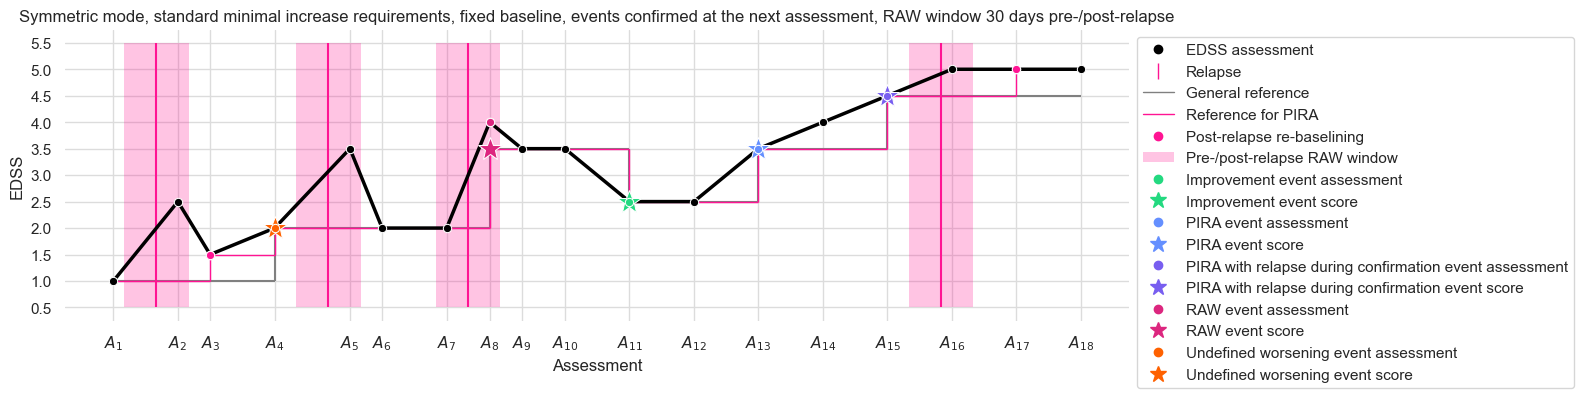

In [4]:
fig, ax = plt.subplots(1, 1, figsize=(16, 4))
example_follow_up = pd.DataFrame(
    [
        {"days_after_baseline": 0, "edss_score": 1.0},
        {"days_after_baseline": 60, "edss_score": 2.5},
        {"days_after_baseline": 90, "edss_score": 1.5},
        {"days_after_baseline": 150, "edss_score": 2.0},
        {"days_after_baseline": 220, "edss_score": 3.5},
        {"days_after_baseline": 250, "edss_score": 2.0},
        {"days_after_baseline": 310, "edss_score": 2.0},
        {"days_after_baseline": 350, "edss_score": 4.0},
        {"days_after_baseline": 380, "edss_score": 3.5},
        {"days_after_baseline": 420, "edss_score": 3.5},
        {"days_after_baseline": 480, "edss_score": 2.5},
        {"days_after_baseline": 540, "edss_score": 2.5},
        {"days_after_baseline": 600, "edss_score": 3.5},
        {"days_after_baseline": 660, "edss_score": 4.0},
        {"days_after_baseline": 720, "edss_score": 4.5},
        {"days_after_baseline": 780, "edss_score": 5.0},
        {"days_after_baseline": 840, "edss_score": 5.0},
        {"days_after_baseline": 900, "edss_score": 5.0},
    ]
)
visualization.annotate_plot_follow_up(
    annotation_mode=SYMMETRIC_MODE_NAME,
    follow_up_dataframe=example_follow_up,
    relapse_timestamps=[40, 200, 330, 770],
    opt_baseline_type="fixed",
    opt_roving_reference_require_confirmation=True,
    opt_roving_reference_confirmation_time=0.5,
    opt_require_confirmation=True,
    opt_confirmation_time=0.5,
    opt_confirmation_included_values="all",
    opt_raw_before_relapse_max_time=30,
    opt_raw_after_relapse_max_time=30,
    show_legend=True,
    move_legend_out=True,
    ax=ax,
)
ax.set_title(
    "Symmetric mode, standard minimal increase requirements, fixed baseline, events confirmed at the next assessment, RAW window 30 days pre-/post-relapse"
)
ax.set_xticklabels(
    [r"$A_{" + str(i + 1) + r"}$" for i, elt in enumerate(ax.get_xticklabels())]
)
ax.set_xlabel("Assessment")
fig.tight_layout()
sns.despine(bottom=True, left=True, right=True, top=True)
plt.show()

**Legend**: Example of multiple events, symmetric mode, fixed baseline, confirmation at the next assessment required, minimal increase + 1.5 from EDSS 0, + 1.0 for EDSS ≤ 5.0, and + 0.5 for EDSS > 5.0. The worsening at $A_2$ after the first relapse is not confirmed, thus it is not classified as RAW. The residual disability measured at the post-relapse re-baselining assessment at $A_3$ is used as new reference for PIRA. The increase at $A_4$ is not in proximity of a relapse but contains a relapse-associated component, thus it is classified as **undefined worsening**. The increase at $A_8$ falls within the RAW window and is confirmed at the next assessment, thus it is classified as **RAW**. The **improvement** at $A_{11}$ is confirmed at the next assessment, thus the baseline is reset (post-event re-baselining). The increase at $A_{13}$ is classified as **PIRA**. The increase at $A_{15}$ is classified as **PIRA with relapse during confirmation**, since the confirmation assessment is in proximity of a relapse.

# **Part 1 - Annotation modes**
The algorithm supports three modes for annotating events:
* Symmetric mode: both accrual and improvement events are annotated (default).
* Accrual mode: only accrual events are annotated.
* Improvement mode: only improvement events are annotated.

## Symmetric mode

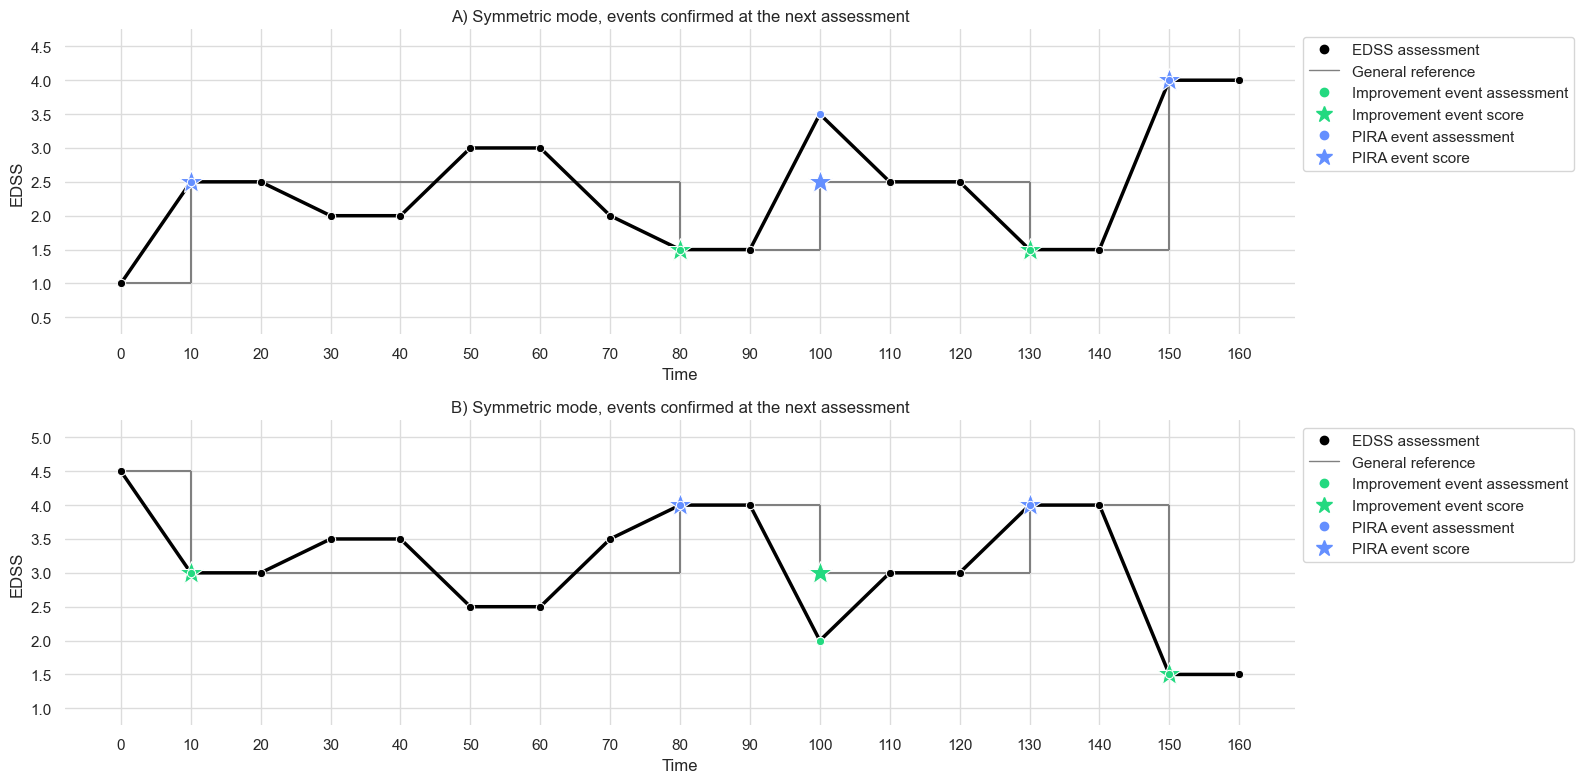

In [8]:
fig, axes = plt.subplots(2, 1, figsize=(16, 8))
timestamps = [10 * i for i in range(17)]
edss_scores = [
    1.0,
    2.5,
    2.5,
    2.0,
    2.0,
    3.0,
    3.0,
    2.0,
    1.5,
    1.5,
    3.5,
    2.5,
    2.5,
    1.5,
    1.5,
    4.0,
    4.0,
]
example_follow_up = pd.DataFrame(
    {"days_after_baseline": timestamps, "edss_score": edss_scores}
)
visualization.annotate_plot_follow_up(
    follow_up_dataframe=example_follow_up,
    annotation_mode=SYMMETRIC_MODE_NAME,
    opt_baseline_type="fixed",
    opt_roving_reference_require_confirmation=True,
    opt_roving_reference_confirmation_time=0.5,
    opt_require_confirmation=True,
    opt_confirmation_time=0.5,
    opt_confirmation_included_values="all",
    show_legend=True,
    move_legend_out=True,
    ax=axes[0],
)
example_follow_up["edss_score"] = 5.5 - example_follow_up["edss_score"]
visualization.annotate_plot_follow_up(
    follow_up_dataframe=example_follow_up,
    annotation_mode=SYMMETRIC_MODE_NAME,
    opt_baseline_type="fixed",
    opt_roving_reference_require_confirmation=True,
    opt_roving_reference_confirmation_time=0.5,
    opt_require_confirmation=True,
    opt_confirmation_time=0.5,
    opt_confirmation_included_values="all",
    show_legend=True,
    move_legend_out=True,
    ax=axes[1],
)
for i, ax in enumerate(axes):
    ax.set_xlabel("Time")
    ax.set_title("AB"[i] + ") Symmetric mode, events confirmed at the next assessment")
fig.tight_layout()
sns.despine(bottom=True, left=True, right=True, top=True)
plt.show()

**Legend**: Symmetric mode. After each event, the baseline is reset to the confirmed event score.

## Accrual only

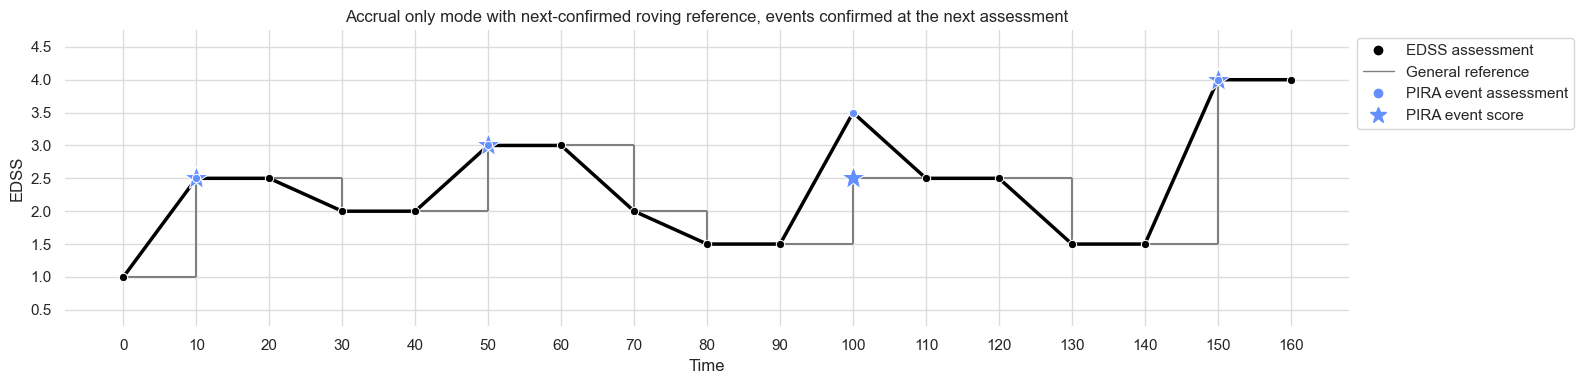

In [10]:
fig, ax = plt.subplots(1, 1, figsize=(16, 4))
timestamps = [10 * i for i in range(17)]
edss_scores = [
    1.0,
    2.5,
    2.5,
    2.0,
    2.0,
    3.0,
    3.0,
    2.0,
    1.5,
    1.5,
    3.5,
    2.5,
    2.5,
    1.5,
    1.5,
    4.0,
    4.0,
]
example_follow_up = pd.DataFrame(
    {"days_after_baseline": timestamps, "edss_score": edss_scores}
)
visualization.annotate_plot_follow_up(
    follow_up_dataframe=example_follow_up,
    annotation_mode=ACCRUAL_MODE_NAME,
    opt_baseline_type="roving",
    opt_roving_reference_require_confirmation=True,
    opt_roving_reference_confirmation_time=0.5,
    opt_require_confirmation=True,
    opt_confirmation_time=0.5,
    opt_confirmation_included_values="all",
    show_legend=True,
    move_legend_out=True,
    ax=ax,
)
ax.set_title(
    "Accrual only mode with next-confirmed roving reference, events confirmed at the next assessment"
)
ax.set_xlabel("Time")
fig.tight_layout()
sns.despine(bottom=True, left=True, right=True, top=True)
plt.show()

**Legend**: Accrual mode. After each event, the baseline is reset to the confirmed event score, and the baseline is also reset in case of a next-confirmed decrease (roving reference).

## Improvement only

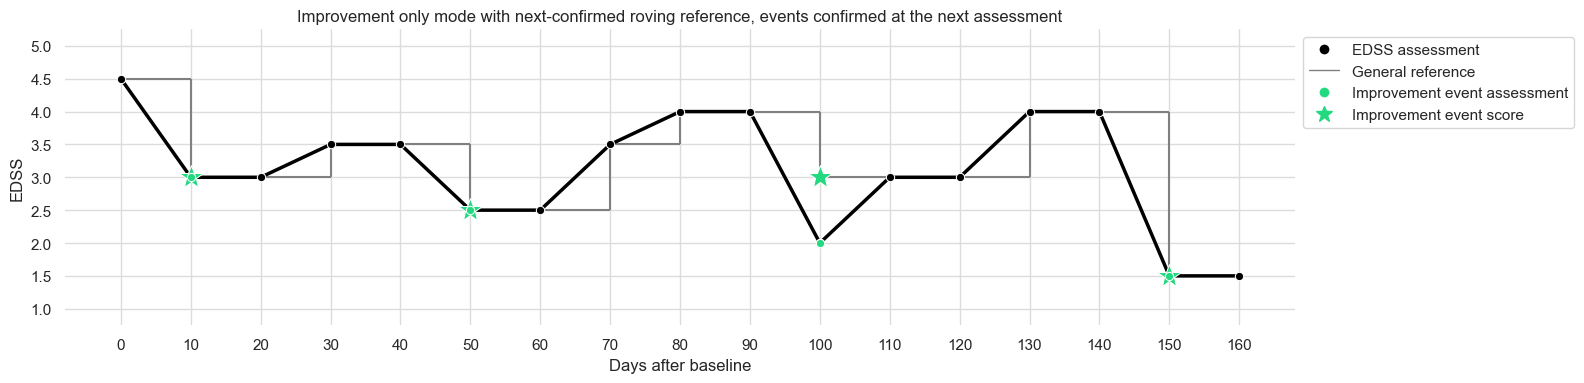

In [11]:
fig, ax = plt.subplots(1, 1, figsize=(16, 4))
timestamps = [10 * i for i in range(17)]
edss_scores = [
    1.0,
    2.5,
    2.5,
    2.0,
    2.0,
    3.0,
    3.0,
    2.0,
    1.5,
    1.5,
    3.5,
    2.5,
    2.5,
    1.5,
    1.5,
    4.0,
    4.0,
]
example_follow_up = pd.DataFrame(
    {"days_after_baseline": timestamps, "edss_score": edss_scores}
)
example_follow_up["edss_score"] = 5.5 - example_follow_up["edss_score"]
visualization.annotate_plot_follow_up(
    follow_up_dataframe=example_follow_up,
    annotation_mode=IMPROVEMENT_MODE_NAME,
    opt_baseline_type="roving",
    opt_roving_reference_require_confirmation=True,
    opt_roving_reference_confirmation_time=0.5,
    opt_require_confirmation=True,
    opt_confirmation_time=0.5,
    opt_confirmation_included_values="all",
    show_legend=True,
    move_legend_out=True,
    ax=ax,
)
ax.set_title(
    "Improvement only mode with next-confirmed roving reference, events confirmed at the next assessment"
)
ax.set_xlabel("Days after baseline")
fig.tight_layout()
sns.despine(bottom=True, left=True, right=True, top=True)
plt.show()

**Legend**: Accrual mode. After each event, the baseline is reset to the confirmed event score, and the baseline is also reset in case of a next-confirmed increase (roving reference).

# **Part 2 - Relapse-Independent Definitions**

# Baselines

## Baseline types
The option to use a roving reference is only available in accrual only or improvement only mode. In symmetric mode, the baseline is only reset in case of a confirmed event.

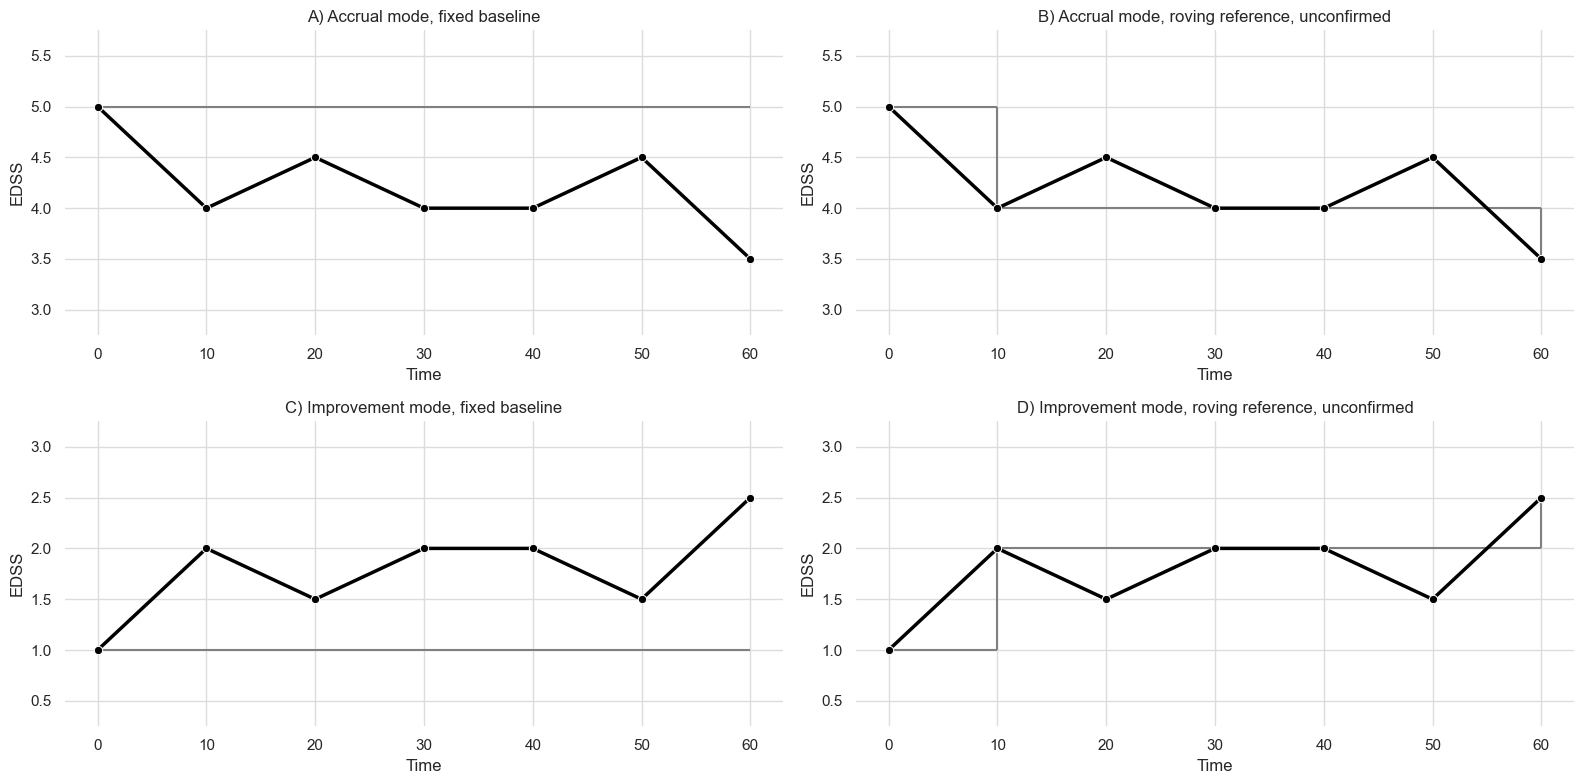

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(16, 8))
example_follow_up = pd.DataFrame(
    {
        "days_after_baseline": [0, 10, 20, 30, 40, 50, 60],
        "edss_score": [5.0, 4.0, 4.5, 4.0, 4.0, 4.5, 3.5],
    }
)

# Accrual mode
for i, baseline_setting in enumerate(
    [
        ("fixed", "A) Accrual mode, fixed baseline"),
        ("roving", "B) Accrual mode, roving reference, unconfirmed"),
    ]
):
    visualization.annotate_plot_follow_up(
        follow_up_dataframe=example_follow_up,
        annotation_mode=ACCRUAL_MODE_NAME,
        opt_baseline_type=baseline_setting[0],
        opt_roving_reference_require_confirmation=False,
        opt_roving_reference_confirmation_time=0,
        show_legend=False,
        move_legend_out=False,
        ax=axes[0][i],
    )
    axes[0][i].set_title(baseline_setting[1])

# Improvement mode
example_follow_up["edss_score"] = 6 - example_follow_up["edss_score"]
for i, baseline_setting in enumerate(
    [
        ("fixed", "C) Improvement mode, fixed baseline"),
        ("roving", "D) Improvement mode, roving reference, unconfirmed"),
    ]
):
    visualization.annotate_plot_follow_up(
        follow_up_dataframe=example_follow_up,
        annotation_mode=IMPROVEMENT_MODE_NAME,
        opt_baseline_type=baseline_setting[0],
        opt_roving_reference_require_confirmation=False,
        opt_roving_reference_confirmation_time=0,
        show_legend=False,
        move_legend_out=False,
        ax=axes[1][i],
    )
    axes[1][i].set_title(baseline_setting[1])

fig.tight_layout()
sns.despine(bottom=True, left=True, right=True, top=True)
plt.show()

**Legend**: **A)**, **C)** Fixed baseline. **B)**, **D)** Roving reference without confirmation requirement. The reference is reset at the
improvements/worsenings at steps 10 and 60.

## Options for roving reference

### Confirmation for roving reference

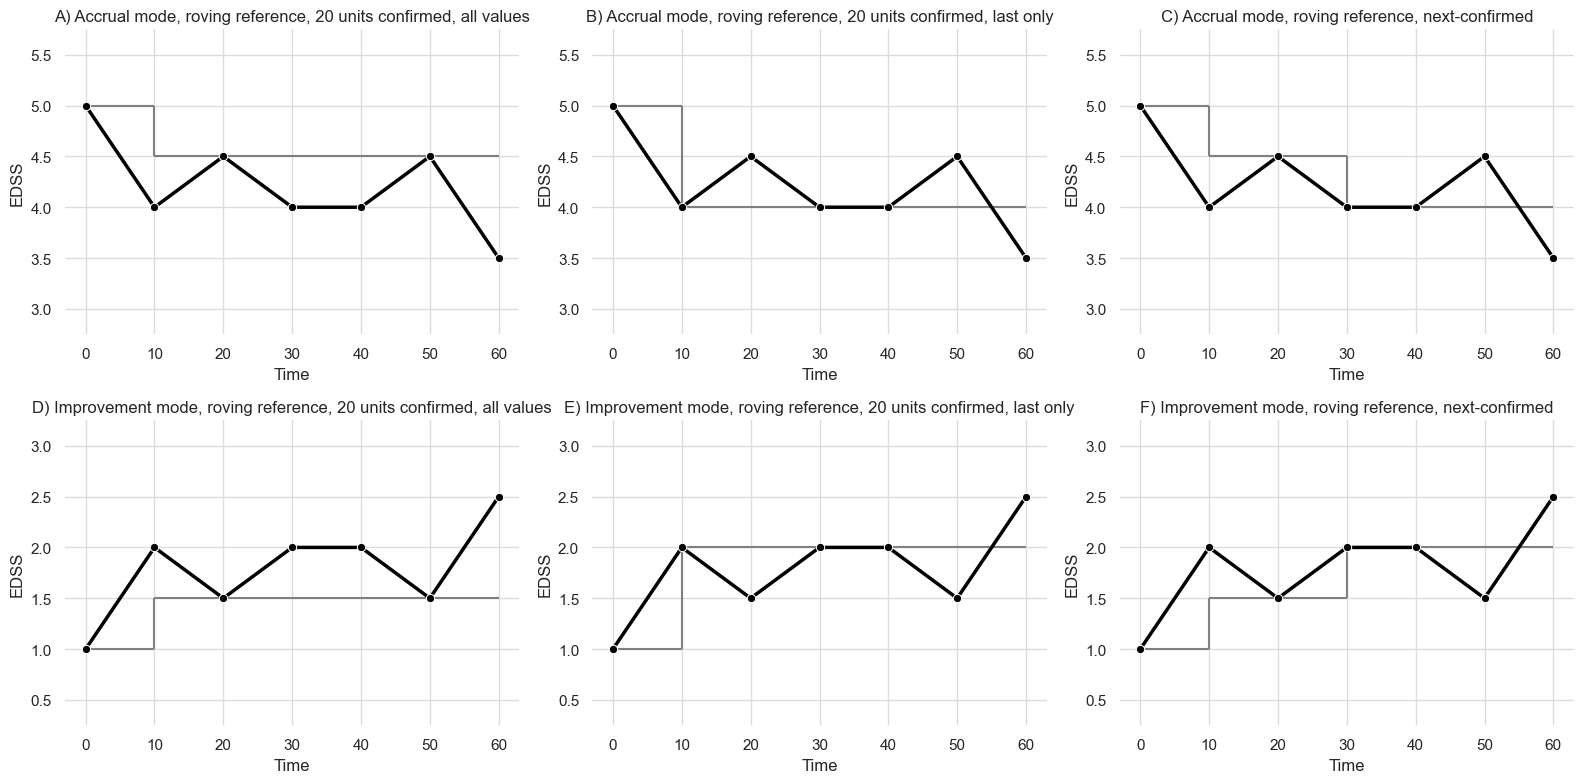

In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(16, 8))
example_follow_up = pd.DataFrame(
    {
        "days_after_baseline": [0, 10, 20, 30, 40, 50, 60],
        "edss_score": [5.0, 4.0, 4.5, 4.0, 4.0, 4.5, 3.5],
    }
)

# Accrual mode
for i, baseline_setting in enumerate(
    [
        (
            20,
            "all",
            "A) Accrual mode, roving reference, 20 units confirmed, all values",
        ),
        (
            20,
            "last",
            "B) Accrual mode, roving reference, 20 units confirmed, last only",
        ),
        (0.5, "all", "C) Accrual mode, roving reference, next-confirmed"),
    ]
):
    visualization.annotate_plot_follow_up(
        follow_up_dataframe=example_follow_up,
        annotation_mode=ACCRUAL_MODE_NAME,
        opt_require_confirmation=True,
        opt_baseline_type="roving",
        opt_roving_reference_require_confirmation=True,
        opt_roving_reference_confirmation_time=baseline_setting[0],
        opt_roving_reference_confirmation_included_values=baseline_setting[1],
        show_legend=False,
        move_legend_out=False,
        ax=axes[0][i],
    )
    axes[0][i].set_title(baseline_setting[2])

# Improvement mode
example_follow_up["edss_score"] = 6 - example_follow_up["edss_score"]
for i, baseline_setting in enumerate(
    [
        (
            20,
            "all",
            "D) Improvement mode, roving reference, 20 units confirmed, all values",
        ),
        (
            20,
            "last",
            "E) Improvement mode, roving reference, 20 units confirmed, last only",
        ),
        (0.5, "all", "F) Improvement mode, roving reference, next-confirmed"),
    ]
):
    visualization.annotate_plot_follow_up(
        follow_up_dataframe=example_follow_up,
        annotation_mode=IMPROVEMENT_MODE_NAME,
        opt_require_confirmation=True,
        opt_baseline_type="roving",
        opt_roving_reference_require_confirmation=True,
        opt_roving_reference_confirmation_time=baseline_setting[0],
        opt_roving_reference_confirmation_included_values=baseline_setting[1],
        show_legend=False,
        move_legend_out=False,
        ax=axes[1][i],
    )
    axes[1][i].set_title(baseline_setting[2])

fig.tight_layout()
sns.despine(bottom=True, left=True, right=True, top=True)
plt.show()

**Legend**: **A)** Roving reference confirmed over a given time interval (20 units), all values included. The
improvement at step 10 is confirmed at steps 20 and 30 with score 4.5, but the improvement at step 30 is not
confirmed at step 50, thus it does not qualify as a new reference. **B)** Roving reference confirmed over a given
time interval (20 units), last only. The confirmation assessment for the improvement at step 10 is the one at step
30 (the one at step 20 is ignored), thus the new reference is 4.0. **C)** Roving reference confirmed at the next
assessment. The improvement at step 10 is confirmed at step 20, but only at 4.5, thus the new roving reference is
4.5. The improvement at step 30 is confirmed at step 40, thus the reference is reset again. The improvement at
step 60 is unconfirmed. **D)** Roving reference confirmed over a given time interval (20 units), all values included.
The increase at step 10 is confirmed at steps 20 and 30 with score 1.5, but the increase at step 30 is not
confirmed at step 50, thus it does not qualify as a new reference. **E)** Roving reference confirmed over a given
time interval (20 units), last only. The confirmation assessment for the increase at step 10 is the one at step
30 (the one at step 20 is ignored), thus the new reference is 2.0. **F)** Roving reference confirmed at the next
assessment. The increase at step 10 is confirmed at step 20, but only at 1.5, thus the new roving reference is
1.5. The increase at step 30 is confirmed at step 40, thus the reference is reset again. The increase at
step 60 is unconfirmed.

### Tolerance for confirming the roving reference

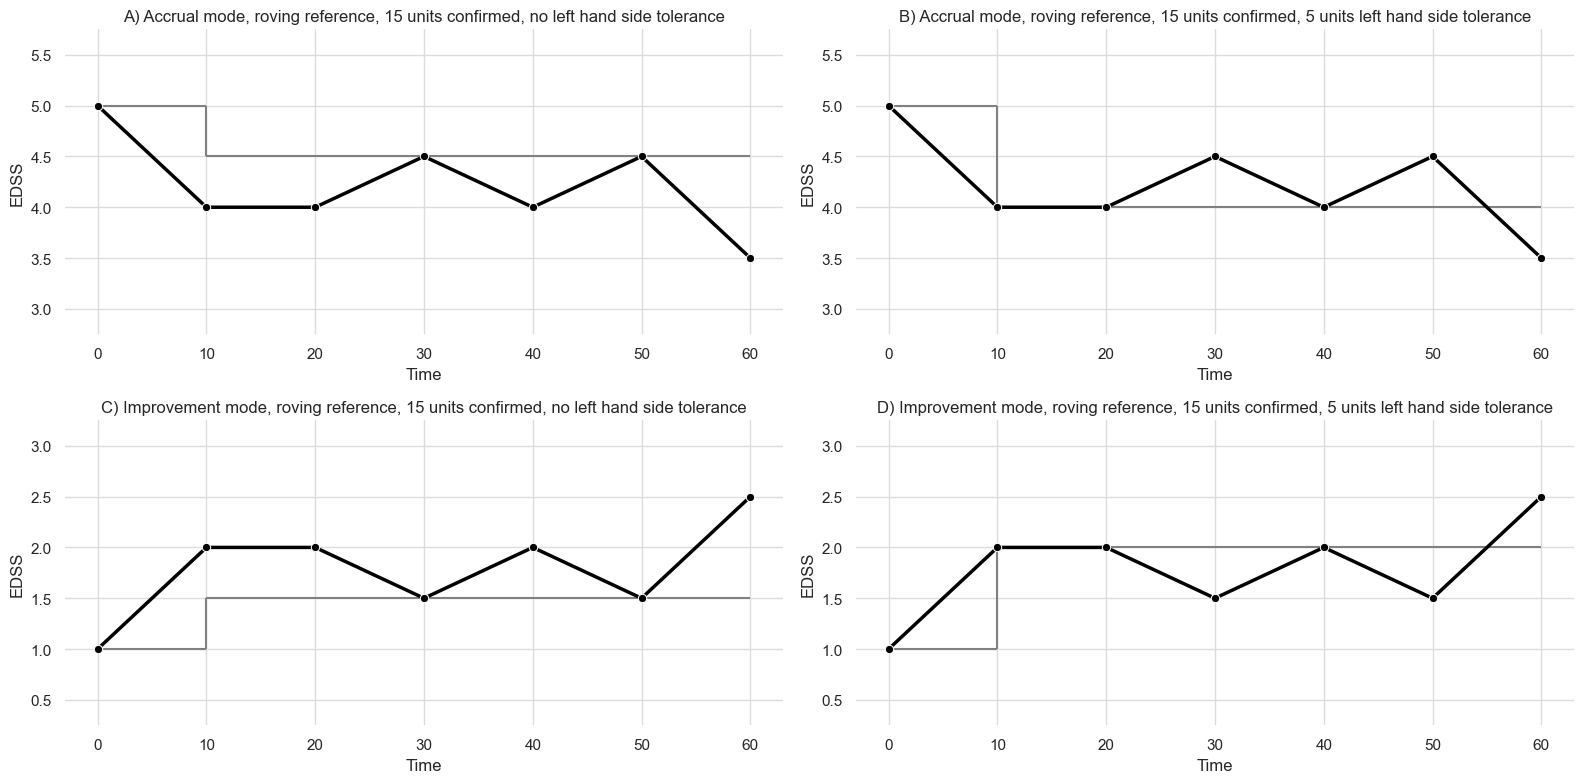

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(16, 8))
example_follow_up = pd.DataFrame(
    {
        "days_after_baseline": [0, 10, 20, 30, 40, 50, 60],
        "edss_score": [5.0, 4.0, 4.0, 4.5, 4.0, 4.5, 3.5],
    }
)
for i, baseline_setting in enumerate(
    [
        (
            0,
            "A) Accrual mode, roving reference, 15 units confirmed, no left hand side tolerance",
        ),
        (
            5,
            "B) Accrual mode, roving reference, 15 units confirmed, 5 units left hand side tolerance",
        ),
    ]
):
    visualization.annotate_plot_follow_up(
        follow_up_dataframe=example_follow_up,
        annotation_mode=ACCRUAL_MODE_NAME,
        opt_require_confirmation=True,
        opt_baseline_type="roving",
        opt_roving_reference_require_confirmation=True,
        opt_roving_reference_confirmation_time=15,
        opt_roving_reference_confirmation_time_left_side_max_tolerance=baseline_setting[
            0
        ],
        opt_roving_reference_confirmation_time_right_side_max_tolerance=np.inf,
        show_legend=False,
        move_legend_out=False,
        ax=axes[0][i],
    )
    axes[0][i].set_title(baseline_setting[1])

# Improvement mode
example_follow_up["edss_score"] = 6 - example_follow_up["edss_score"]
for i, baseline_setting in enumerate(
    [
        (
            0,
            "C) Improvement mode, roving reference, 15 units confirmed, no left hand side tolerance",
        ),
        (
            5,
            "D) Improvement mode, roving reference, 15 units confirmed, 5 units left hand side tolerance",
        ),
    ]
):
    visualization.annotate_plot_follow_up(
        follow_up_dataframe=example_follow_up,
        annotation_mode=IMPROVEMENT_MODE_NAME,
        opt_require_confirmation=True,
        opt_baseline_type="roving",
        opt_roving_reference_require_confirmation=True,
        opt_roving_reference_confirmation_time=15,
        opt_roving_reference_confirmation_time_left_side_max_tolerance=baseline_setting[
            0
        ],
        opt_roving_reference_confirmation_time_right_side_max_tolerance=np.inf,
        show_legend=False,
        move_legend_out=False,
        ax=axes[1][i],
    )
    axes[1][i].set_title(baseline_setting[1])

fig.tight_layout()
sns.despine(bottom=True, left=True, right=True, top=True)
plt.show()

**Legend**: Roving reference, 15 units confirmed, all values included. **A)** No tolerance, i.e. the first score that
satisfies the confirmation distance condition for the improvement at step 10 is the one at step 30 (minimal
timestamp = t<sub>i</sub> + Δt – tolerance = 10 + 15 - 0 = 25). The confirmation scores are thus 4.0 (step 20) and 4.5 (step 30),
and the new reference is thus 4.5. **B)** 5 units tolerance, i.e. the first score that satisfies the confirmation distance
condition is the one at step 20 (minimal timestamp = t<sub>i</sub> + Δt – tolerance = 10 + 15 - 5 = 20). The confirmation score and
the new reference is thus 4.0. **C)** No tolerance, i.e. the first score that
satisfies the confirmation distance condition for the improvement at step 10 is the one at step 30 (minimal
timestamp = t<sub>i</sub> + Δt – tolerance = 10 + 15 - 0 = 25). The confirmation scores are thus 2.0 (step 20) and 1.5 (step 30),
and the new reference is thus 1.5. **D)** 5 units tolerance, i.e. the first score that satisfies the confirmation distance
condition is the one at step 20 (minimal timestamp = t<sub>i</sub> + Δt – tolerance = 10 + 15 - 5 = 20). The confirmation score and
the new reference is thus 2.0.

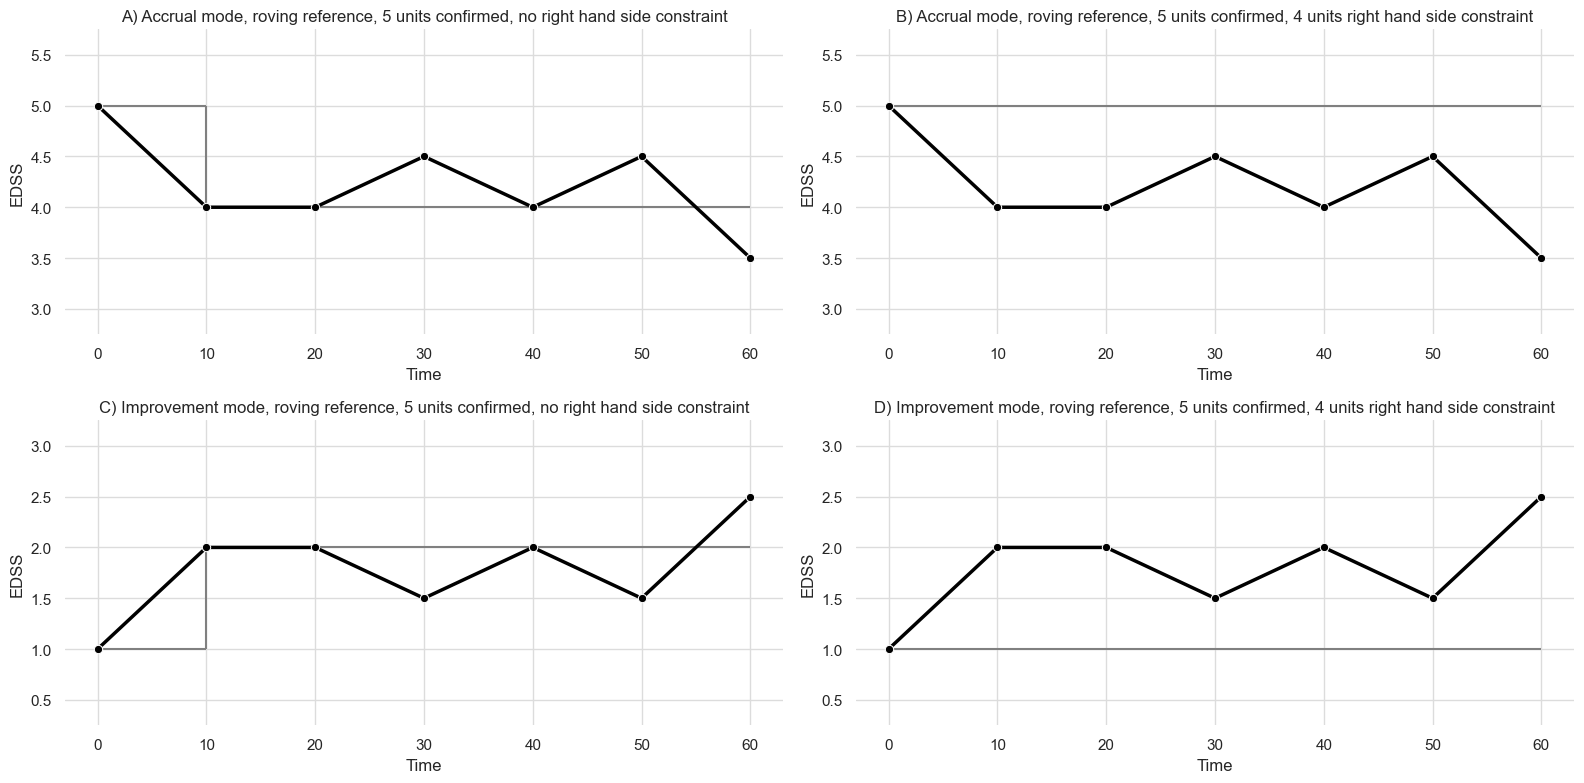

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(16, 8))
example_follow_up = pd.DataFrame(
    {
        "days_after_baseline": [0, 10, 20, 30, 40, 50, 60],
        "edss_score": [5.0, 4.0, 4.0, 4.5, 4.0, 4.5, 3.5],
    }
)
for i, baseline_setting in enumerate(
    [
        (
            np.inf,
            "A) Accrual mode, roving reference, 5 units confirmed, no right hand side constraint",
        ),
        (
            4,
            "B) Accrual mode, roving reference, 5 units confirmed, 4 units right hand side constraint",
        ),
    ]
):
    visualization.annotate_plot_follow_up(
        follow_up_dataframe=example_follow_up,
        annotation_mode=ACCRUAL_MODE_NAME,
        opt_require_confirmation=True,
        opt_baseline_type="roving",
        opt_roving_reference_require_confirmation=True,
        opt_roving_reference_confirmation_time=5,
        opt_roving_reference_confirmation_time_left_side_max_tolerance=0,
        opt_roving_reference_confirmation_time_right_side_max_tolerance=baseline_setting[
            0
        ],
        show_legend=False,
        move_legend_out=False,
        ax=axes[0][i],
    )
    axes[0][i].set_title(baseline_setting[1])

# Improvement mode
example_follow_up["edss_score"] = 6 - example_follow_up["edss_score"]
for i, baseline_setting in enumerate(
    [
        (
            np.inf,
            "C) Improvement mode, roving reference, 5 units confirmed, no right hand side constraint",
        ),
        (
            4,
            "D) Improvement mode, roving reference, 5 units confirmed, 4 units right hand side constraint",
        ),
    ]
):
    visualization.annotate_plot_follow_up(
        follow_up_dataframe=example_follow_up,
        annotation_mode=IMPROVEMENT_MODE_NAME,
        opt_require_confirmation=True,
        opt_baseline_type="roving",
        opt_roving_reference_require_confirmation=True,
        opt_roving_reference_confirmation_time=5,
        opt_roving_reference_confirmation_time_left_side_max_tolerance=0,
        opt_roving_reference_confirmation_time_right_side_max_tolerance=baseline_setting[
            0
        ],
        show_legend=False,
        move_legend_out=False,
        ax=axes[1][i],
    )
    axes[1][i].set_title(baseline_setting[1])

fig.tight_layout()
sns.despine(bottom=True, left=True, right=True, top=True)
plt.show()

**Legend**: Roving reference, 5 units confirmed, all values included. **A)** No right-hand constraint. **B)** Right-hand
constraint of max. 4 units, thus the score at step 20 does not qualify as a confirmation score for step 10 (maximal
timestamp = t<sub>i</sub> + Δt + constraint = 10 + 5 + 4 = 19). **C)** No right-hand constraint. **D)** Right-hand
constraint of max. 4 units, thus the score at step 20 does not qualify as a confirmation score for step 10 (maximal
timestamp = t<sub>i</sub> + Δt + constraint = 10 + 5 + 4 = 19).

# Minimal increase
The ``opt_max_score_that_requires_plus_1`` parameter sets the max. score which requires an increase of + 1.0 (5.0 by default).

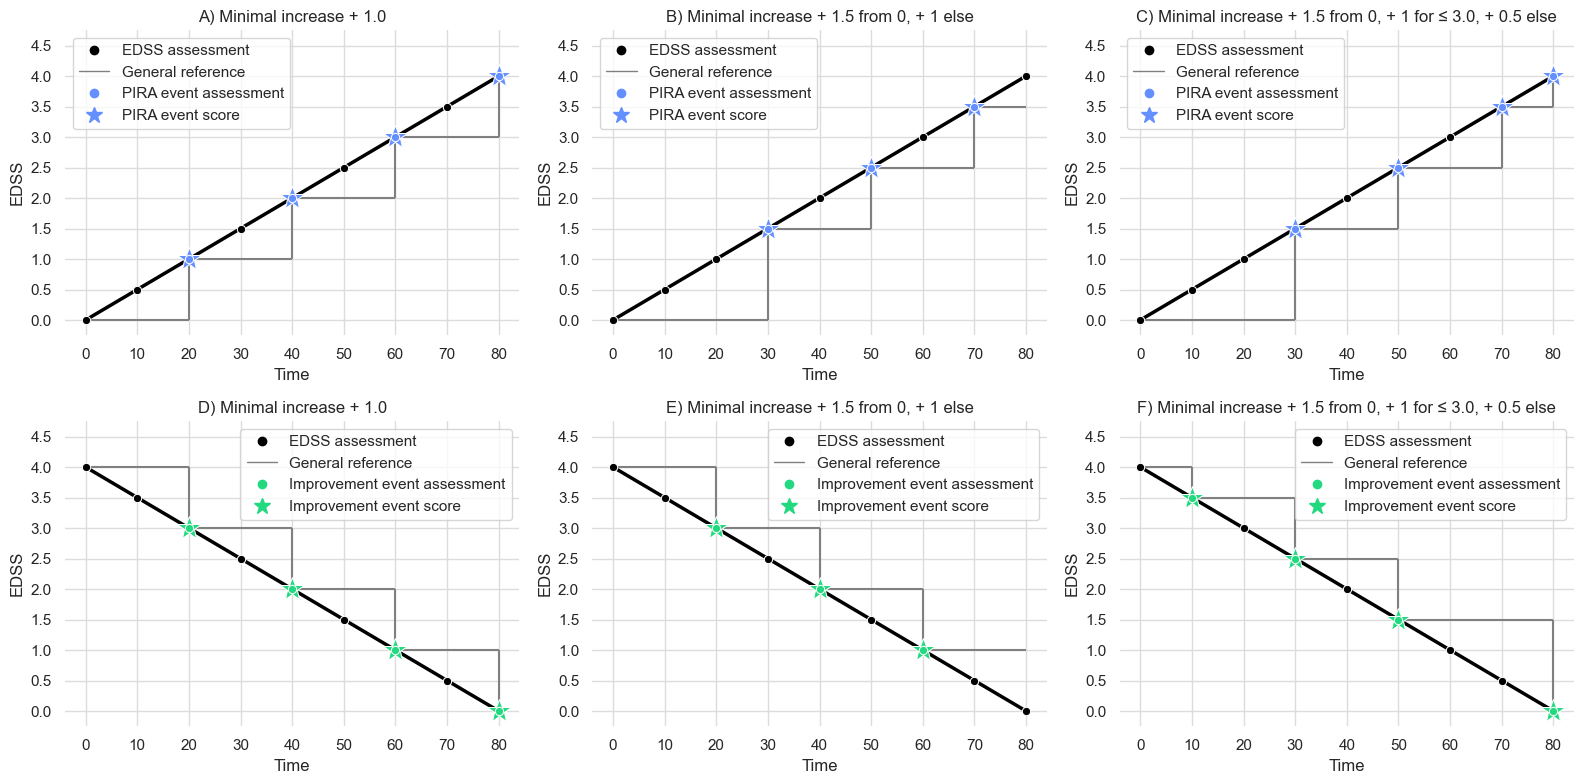

In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(16, 8))

example_follow_up = pd.DataFrame(
    {
        "days_after_baseline": [0, 10, 20, 30, 40, 50, 60, 70, 80],
        "edss_score": [0, 0.5, 1, 1.5, 2.0, 2.5, 3.0, 3.5, 4.0],
    }
)

# Accrual mode
for i, options in enumerate(
    [
        (4.0, False, "A) Minimal increase + 1.0"),
        (4.0, True, "B) Minimal increase + 1.5 from 0, + 1 else"),
        (3.0, True, "C) Minimal increase + 1.5 from 0, + 1 for ≤ 3.0, + 0.5 else"),
    ]
):
    visualization.annotate_plot_follow_up(
        follow_up_dataframe=example_follow_up,
        annotation_mode=ACCRUAL_MODE_NAME,
        opt_baseline_type="fixed",
        opt_max_score_that_requires_plus_1=options[0],
        opt_larger_increment_from_0=options[1],
        show_legend=True,
        move_legend_out=False,
        ax=axes[0][i],
    )
    axes[0][i].set_title(options[2])
    for ax in axes[0]:
        ax.set_ylim((-0.25, 4.75))

# Improvement mode
example_follow_up["edss_score"] = 4.0 - example_follow_up["edss_score"]
for i, options in enumerate(
    [
        (4.0, False, "D) Minimal increase + 1.0"),
        (4.0, True, "E) Minimal increase + 1.5 from 0, + 1 else"),
        (3.0, True, "F) Minimal increase + 1.5 from 0, + 1 for ≤ 3.0, + 0.5 else"),
    ]
):
    visualization.annotate_plot_follow_up(
        follow_up_dataframe=example_follow_up,
        annotation_mode=IMPROVEMENT_MODE_NAME,
        opt_baseline_type="fixed",
        opt_max_score_that_requires_plus_1=options[0],
        opt_larger_increment_from_0=options[1],
        show_legend=True,
        move_legend_out=False,
        ax=axes[1][i],
    )
    axes[1][i].set_title(options[2])
    for ax in axes[1]:
        ax.set_ylim((-0.25, 4.75))

fig.tight_layout()
sns.despine(bottom=True, left=True, right=True, top=True)
plt.show()

**Legend**: Minimal increase options. **A), D)** Minimal increase + 1.0 irrespective of the reference. **B), E)** Minimal increase +
1.5 for reference 0, + 1.0 else. **C), F)** Minimal increase + 1.5 for reference 0, minimal increase + 1.0 for references up
to and including 3.0, and + 0.5 else. The reference is reset after each event.

### Same for symmetric mode

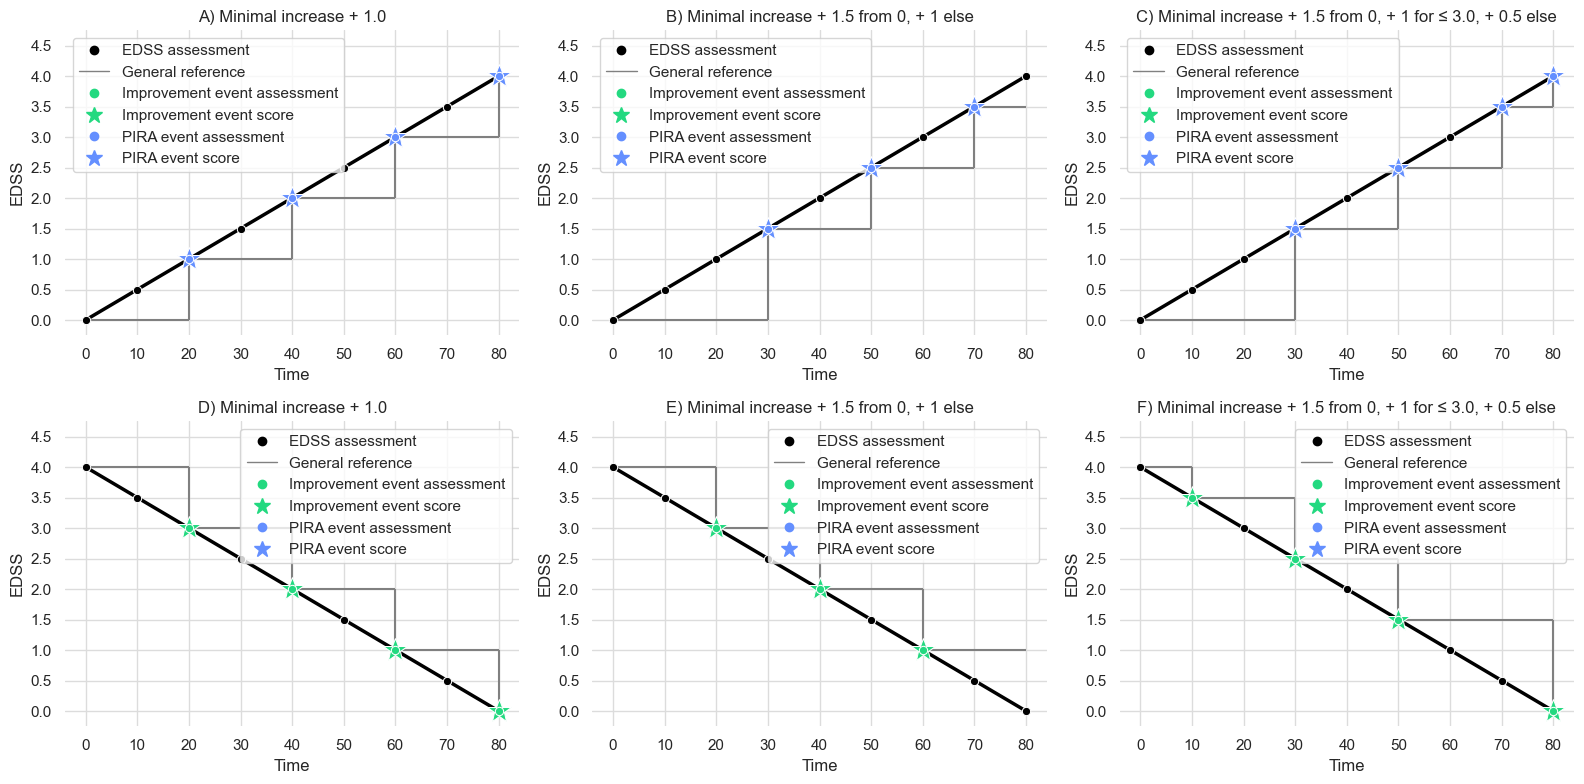

In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(16, 8))

example_follow_up = pd.DataFrame(
    {
        "days_after_baseline": [0, 10, 20, 30, 40, 50, 60, 70, 80],
        "edss_score": [0, 0.5, 1, 1.5, 2.0, 2.5, 3.0, 3.5, 4.0],
    }
)

for i, options in enumerate(
    [
        (4.0, False, "A) Minimal increase + 1.0"),
        (4.0, True, "B) Minimal increase + 1.5 from 0, + 1 else"),
        (3.0, True, "C) Minimal increase + 1.5 from 0, + 1 for ≤ 3.0, + 0.5 else"),
    ]
):
    visualization.annotate_plot_follow_up(
        follow_up_dataframe=example_follow_up,
        annotation_mode=SYMMETRIC_MODE_NAME,
        opt_baseline_type="fixed",
        opt_max_score_that_requires_plus_1=options[0],
        opt_larger_increment_from_0=options[1],
        show_legend=True,
        move_legend_out=False,
        ax=axes[0][i],
    )
    axes[0][i].set_title(options[2])
    for ax in axes[0]:
        ax.set_ylim((-0.25, 4.75))

example_follow_up["edss_score"] = 4.0 - example_follow_up["edss_score"]
for i, options in enumerate(
    [
        (4.0, False, "D) Minimal increase + 1.0"),
        (4.0, True, "E) Minimal increase + 1.5 from 0, + 1 else"),
        (3.0, True, "F) Minimal increase + 1.5 from 0, + 1 for ≤ 3.0, + 0.5 else"),
    ]
):
    visualization.annotate_plot_follow_up(
        follow_up_dataframe=example_follow_up,
        annotation_mode=SYMMETRIC_MODE_NAME,
        opt_baseline_type="fixed",
        opt_max_score_that_requires_plus_1=options[0],
        opt_larger_increment_from_0=options[1],
        show_legend=True,
        move_legend_out=False,
        ax=axes[1][i],
    )
    axes[1][i].set_title(options[2])
    for ax in axes[1]:
        ax.set_ylim((-0.25, 4.75))

fig.tight_layout()
sns.despine(bottom=True, left=True, right=True, top=True)
plt.show()

**Legend**: Minimal increase options. **A), D)** Minimal increase + 1.0 irrespective of the reference. **B), E)** Minimal increase +
1.5 for reference 0, + 1.0 else. **C), F)** Minimal increase + 1.5 for reference 0, minimal increase + 1.0 for references up
to and including 3.0, and + 0.5 else. The reference is reset after each event.

# Event confirmation

## Confirmed score

### In accrual/improvement mode

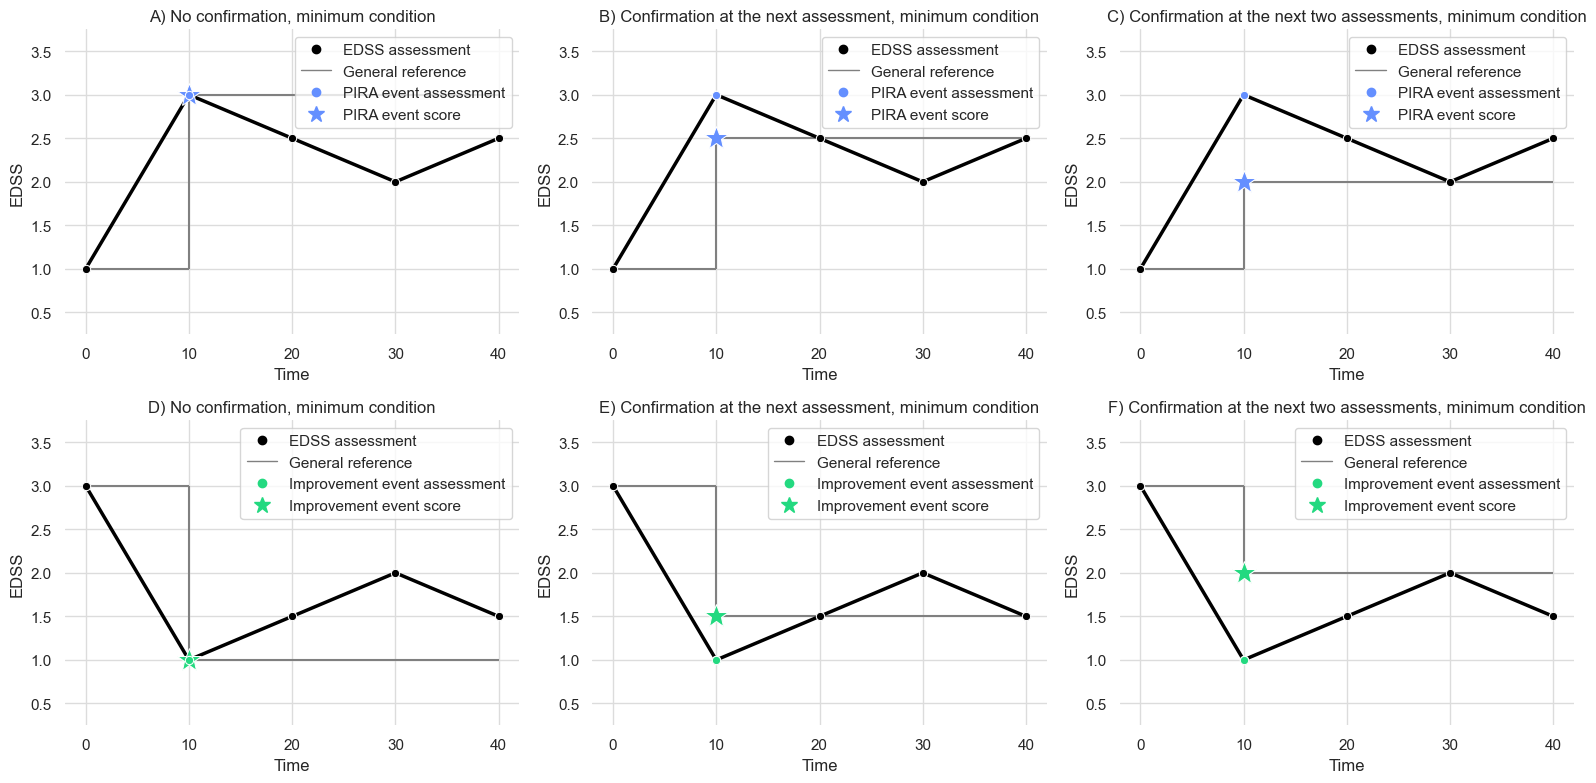

In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(16, 8))
example_follow_up = pd.DataFrame(
    {
        "days_after_baseline": [0, 10, 20, 30, 40],
        "edss_score": [1, 3.0, 2.5, 2.0, 2.5],
    }
)
# Accrual mode
for i, confirmation_setting in enumerate(
    [
        (False, 0, "A) No confirmation, minimum condition"),
        (True, 10, "B) Confirmation at the next assessment, minimum condition"),
        (True, 20, "C) Confirmation at the next two assessments, minimum condition"),
    ]
):
    visualization.annotate_plot_follow_up(
        follow_up_dataframe=example_follow_up,
        annotation_mode=ACCRUAL_MODE_NAME,
        opt_baseline_type="fixed",
        opt_require_confirmation=confirmation_setting[0],
        opt_confirmation_time=confirmation_setting[1],
        opt_confirmation_type="minimum",
        show_legend=True,
        move_legend_out=False,
        ax=axes[0][i],
    )
    axes[0][i].set_title(confirmation_setting[2])

# Improvement mode
example_follow_up["edss_score"] = 4.0 - example_follow_up["edss_score"]
for i, confirmation_setting in enumerate(
    [
        (False, 0, "D) No confirmation, minimum condition"),
        (True, 10, "E) Confirmation at the next assessment, minimum condition"),
        (True, 20, "F) Confirmation at the next two assessments, minimum condition"),
    ]
):
    visualization.annotate_plot_follow_up(
        follow_up_dataframe=example_follow_up,
        annotation_mode=IMPROVEMENT_MODE_NAME,
        opt_baseline_type="fixed",
        opt_require_confirmation=confirmation_setting[0],
        opt_confirmation_time=confirmation_setting[1],
        opt_confirmation_type="minimum",
        show_legend=True,
        move_legend_out=False,
        ax=axes[1][i],
    )
    axes[1][i].set_title(confirmation_setting[2])

fig.tight_layout()
sns.despine(bottom=True, left=True, right=True, top=True)
plt.show()

**Legend**: Confirmed score. **A)** No confirmation required. The event score for the increase at step 10 is 3.0. **B)**
Confirmation at the next assessment required. The score at the next assessment also fulfills the criterion of an
increase of at least + 1.0 with respect to the baseline, so the increase at step 10 is confirmed, but only at 2.5. **C)** 
Confirmation at the next two assessments required. The scores at the next two assessment also fulfill the criterion
of an increase of at least + 1.0 with respect to the baseline, so the increase at step 10 is confirmed, but only at
2.0. Minimal increase + 1.0. **D)** No confirmation required. The event score for the improvement at step 10 is 1.0. **E)**
Confirmation at the next assessment required. The score at the next assessment also fulfills the criterion of an
improvement of at least + 1.0 with respect to the baseline, so the improvement at step 10 is confirmed, but only at 1.5. **F)** 
Confirmation at the next two assessments required. The scores at the next two assessment also fulfill the criterion
of an improvement of at least + 1.0 with respect to the baseline, so the improvement at step 10 is confirmed, but only at
2.0. Minimal improvement + 1.0.

### Symmetric mode

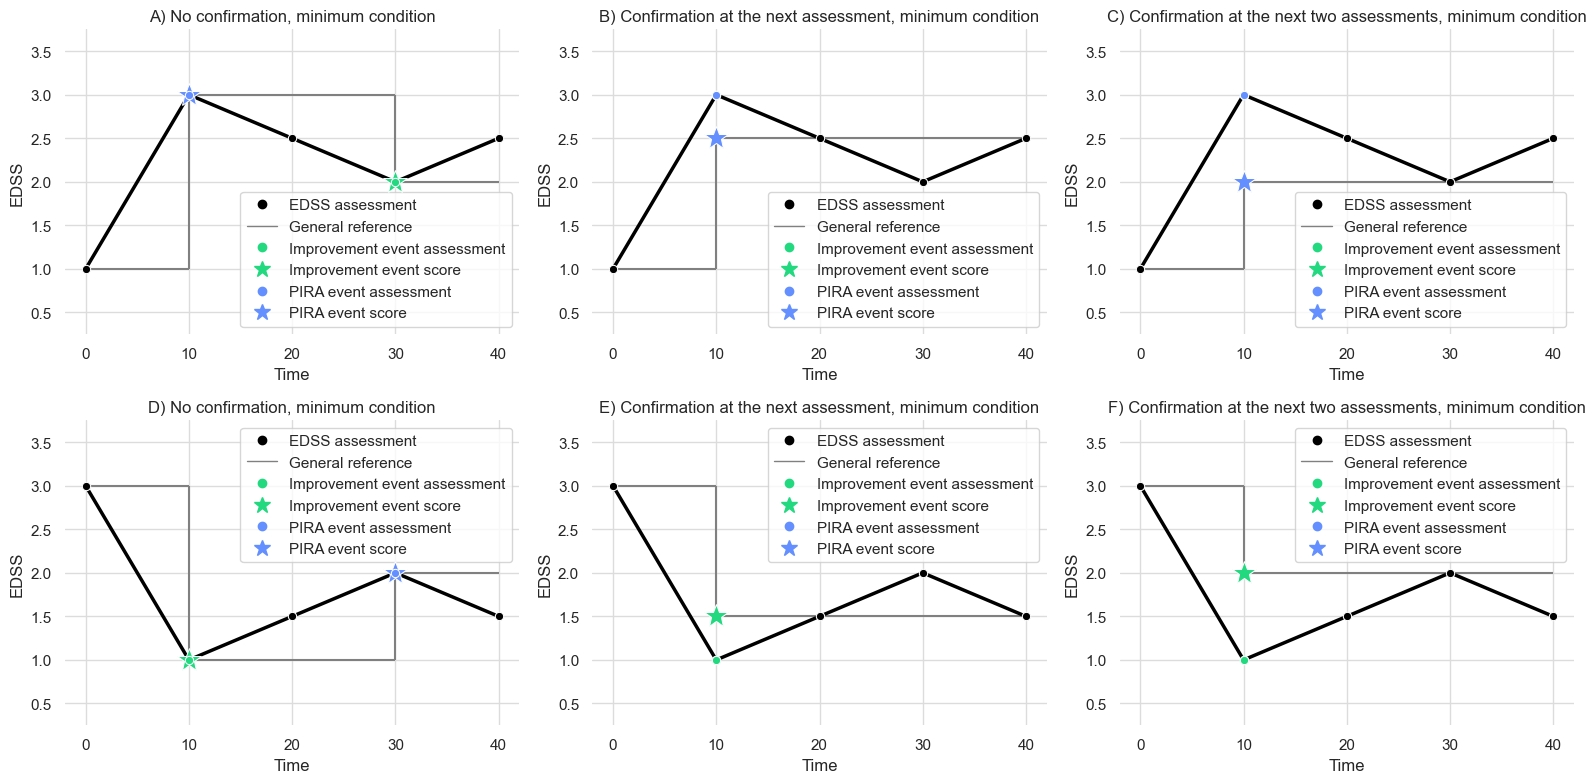

In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(16, 8))
example_follow_up = pd.DataFrame(
    {
        "days_after_baseline": [0, 10, 20, 30, 40],
        "edss_score": [1, 3.0, 2.5, 2.0, 2.5],
    }
)
for i, confirmation_setting in enumerate(
    [
        (False, 0, "A) No confirmation, minimum condition"),
        (True, 10, "B) Confirmation at the next assessment, minimum condition"),
        (True, 20, "C) Confirmation at the next two assessments, minimum condition"),
    ]
):
    visualization.annotate_plot_follow_up(
        follow_up_dataframe=example_follow_up,
        annotation_mode=SYMMETRIC_MODE_NAME,
        opt_baseline_type="fixed",
        opt_require_confirmation=confirmation_setting[0],
        opt_confirmation_time=confirmation_setting[1],
        opt_confirmation_type="minimum",
        show_legend=True,
        move_legend_out=False,
        ax=axes[0][i],
    )
    axes[0][i].set_title(confirmation_setting[2])

example_follow_up["edss_score"] = 4.0 - example_follow_up["edss_score"]
for i, confirmation_setting in enumerate(
    [
        (False, 0, "D) No confirmation, minimum condition"),
        (True, 10, "E) Confirmation at the next assessment, minimum condition"),
        (True, 20, "F) Confirmation at the next two assessments, minimum condition"),
    ]
):
    visualization.annotate_plot_follow_up(
        follow_up_dataframe=example_follow_up,
        annotation_mode=SYMMETRIC_MODE_NAME,
        opt_baseline_type="fixed",
        opt_require_confirmation=confirmation_setting[0],
        opt_confirmation_time=confirmation_setting[1],
        opt_confirmation_type="minimum",
        show_legend=True,
        move_legend_out=False,
        ax=axes[1][i],
    )
    axes[1][i].set_title(confirmation_setting[2])

fig.tight_layout()
sns.despine(bottom=True, left=True, right=True, top=True)
plt.show()

**Legend**: Confirmed score. **A)** No confirmation required. The event score for the increase at step 10 is 3.0, 
and the improvement at step 30 is an improvement event. **B)** Confirmation at the next assessment required. The 
score at the next assessment also fulfills the criterion of an increase of at least + 1.0 with respect to the baseline, 
so the increase at step 10 is confirmed, but only at 2.5. The improvement at step 30 is not confirmed and would also not
satisfy the minimal decrease condition. **C)** Confirmation at the next two assessments required. The scores at the next
two assessment also fulfill the criterion of an increase of at least + 1.0 with respect to the baseline, so the increase
at step 10 is confirmed, but only at 2.0. Minimal increase + 1.0. **D)** No confirmation required. The event score for the
improvement at step 10 is 1.0, and the increase at step 30 is an accrual event. **E)** Confirmation at the next assessment
required. The score at the next assessment also fulfills the criterion of an improvement of at least + 1.0 with respect to
the baseline, so the improvement at step 10 is confirmed, but only at 1.5. The accrual does not satisfy the minimal increase
criterion and would not be confirmed. **F)** Confirmation at the next two assessments required. The scores at the next two
assessment also fulfill the criterion of an improvement of at least + 1.0 with respect to the baseline, so the improvement
at step 10 is confirmed, but only at 2.0. Minimal improvement + 1.0.

## Confirmation condition

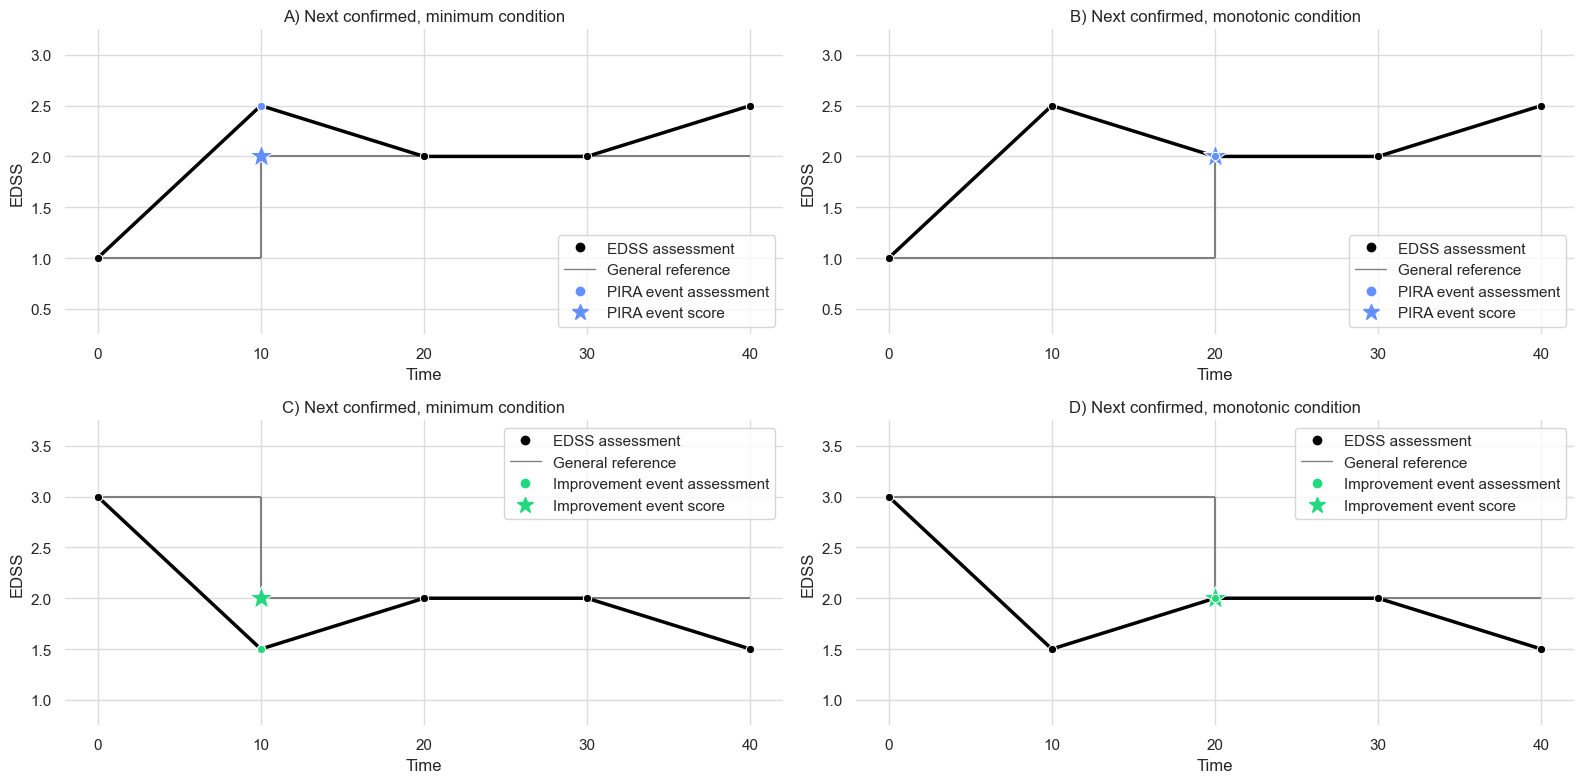

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(16, 8))
example_follow_up = pd.DataFrame(
    {
        "days_after_baseline": [0, 10, 20, 30, 40],
        "edss_score": [1, 2.5, 2.0, 2.0, 2.5],
    }
)
for i, confirmation_setting in enumerate(
    [
        ("minimum", "A) Next confirmed, minimum condition"),
        ("monotonic", "B) Next confirmed, monotonic condition"),
    ]
):
    visualization.annotate_plot_follow_up(
        follow_up_dataframe=example_follow_up,
        annotation_mode=ACCRUAL_MODE_NAME,
        opt_baseline_type="fixed",
        opt_require_confirmation=True,
        opt_confirmation_time=0.5,
        opt_confirmation_type=confirmation_setting[0],
        show_legend=True,
        move_legend_out=False,
        ax=axes[0][i],
    )
    axes[0][i].set_title(confirmation_setting[1])

# Improvement mode
example_follow_up["edss_score"] = 4.0 - example_follow_up["edss_score"]
for i, confirmation_setting in enumerate(
    [
        ("minimum", "C) Next confirmed, minimum condition"),
        ("monotonic", "D) Next confirmed, monotonic condition"),
    ]
):
    visualization.annotate_plot_follow_up(
        follow_up_dataframe=example_follow_up,
        annotation_mode=IMPROVEMENT_MODE_NAME,
        opt_baseline_type="fixed",
        opt_require_confirmation=True,
        opt_confirmation_time=0.5,
        opt_confirmation_type=confirmation_setting[0],
        show_legend=True,
        move_legend_out=False,
        ax=axes[1][i],
    )
    axes[1][i].set_title(confirmation_setting[1])


fig.tight_layout()
sns.despine(bottom=True, left=True, right=True, top=True)
plt.show()

**Legend**: Confirmation conditions. **A)** Minimum condition. The score at step 20 fulfills the confirmation criterion,
so the increase at step 10 is a confirmed event with event score 2.0. **B)** Monotonic condition. The increase at step
10 is not a confirmed event because the confirmation score at step 20 is lower. However, the increase at step 20
is confirmed by the score at step 30. Minimal increase + 1.0, confirmation at the next assessment required. **C)** Minimum
condition. The score at step 20 fulfills the confirmation criterion, so the improvement at step 10 is a confirmed event with
event score 2.0. **D)** Monotonic condition. The increase at step 10 is not a confirmed event because the confirmation score
at step 20 is higher. However, the increase at step 20 is confirmed by the score at step 30. Minimal decrease + 1.0,
confirmation at the next assessment required.

### Same for symmetric mode

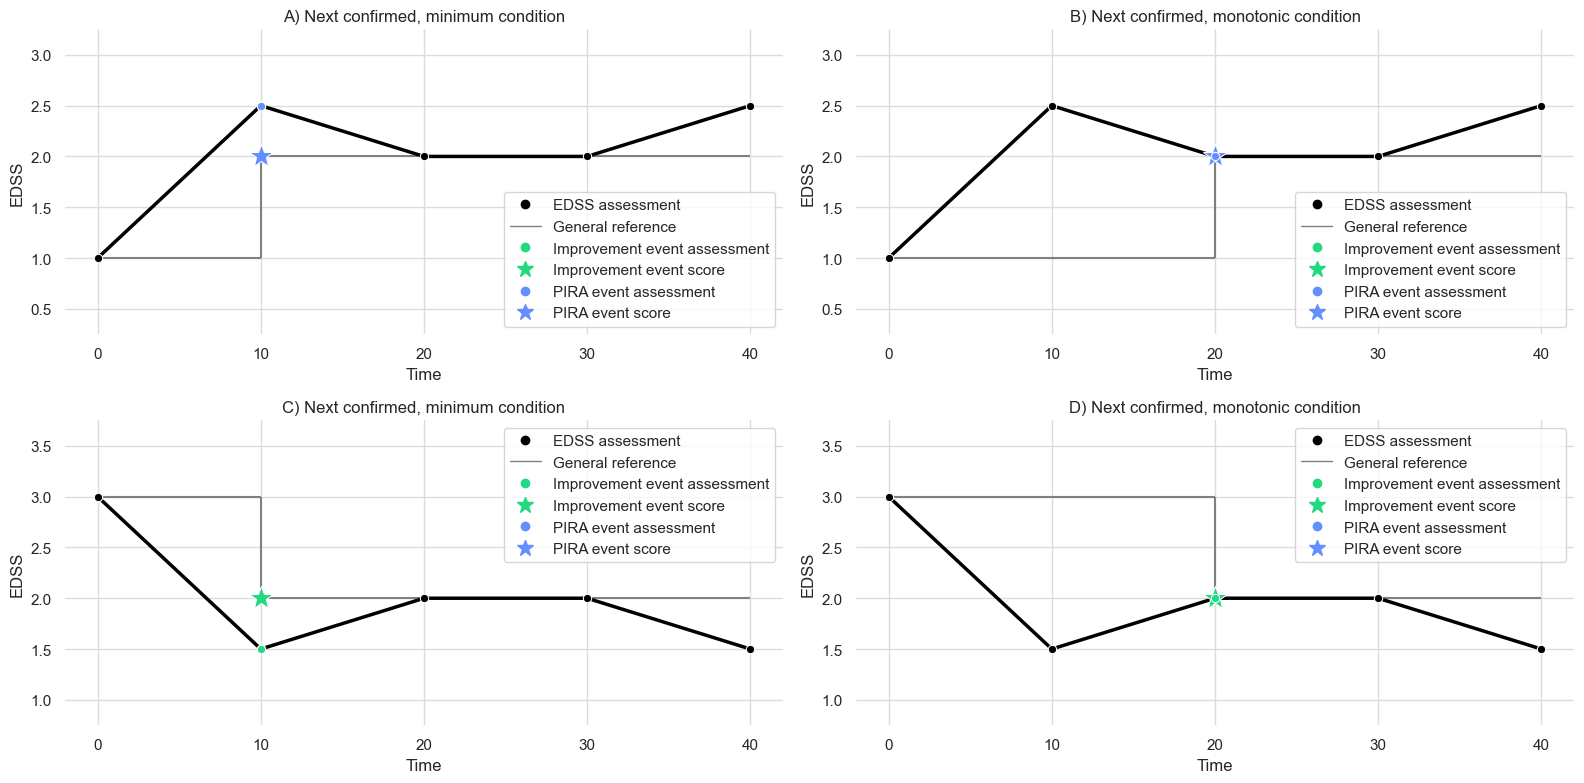

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(16, 8))
example_follow_up = pd.DataFrame(
    {
        "days_after_baseline": [0, 10, 20, 30, 40],
        "edss_score": [1, 2.5, 2.0, 2.0, 2.5],
    }
)
for i, confirmation_setting in enumerate(
    [
        ("minimum", "A) Next confirmed, minimum condition"),
        ("monotonic", "B) Next confirmed, monotonic condition"),
    ]
):
    visualization.annotate_plot_follow_up(
        follow_up_dataframe=example_follow_up,
        annotation_mode=SYMMETRIC_MODE_NAME,
        opt_baseline_type="fixed",
        opt_require_confirmation=True,
        opt_confirmation_time=0.5,
        opt_confirmation_type=confirmation_setting[0],
        show_legend=True,
        move_legend_out=False,
        ax=axes[0][i],
    )
    axes[0][i].set_title(confirmation_setting[1])

example_follow_up["edss_score"] = 4.0 - example_follow_up["edss_score"]
for i, confirmation_setting in enumerate(
    [
        ("minimum", "C) Next confirmed, minimum condition"),
        ("monotonic", "D) Next confirmed, monotonic condition"),
    ]
):
    visualization.annotate_plot_follow_up(
        follow_up_dataframe=example_follow_up,
        annotation_mode=SYMMETRIC_MODE_NAME,
        opt_baseline_type="fixed",
        opt_require_confirmation=True,
        opt_confirmation_time=0.5,
        opt_confirmation_type=confirmation_setting[0],
        show_legend=True,
        move_legend_out=False,
        ax=axes[1][i],
    )
    axes[1][i].set_title(confirmation_setting[1])


fig.tight_layout()
sns.despine(bottom=True, left=True, right=True, top=True)
plt.show()

**Legend**: Confirmation conditions. **A)** Minimum condition. The score at step 20 fulfills the confirmation criterion,
so the increase at step 10 is a confirmed event with event score 2.0. **B)** Monotonic condition. The increase at step
10 is not a confirmed event because the confirmation score at step 20 is lower. However, the increase at step 20
is confirmed by the score at step 30. Minimal increase + 1.0, confirmation at the next assessment required. **C)** Minimum
condition. The score at step 20 fulfills the confirmation criterion, so the improvement at step 10 is a confirmed event with
event score 2.0. **D)** Monotonic condition. The increase at step 10 is not a confirmed event because the confirmation score
at step 20 is higher. However, the increase at step 20 is confirmed by the score at step 30. Minimal decrease + 1.0,
confirmation at the next assessment required.

## Confirmation interval

### All vs. last

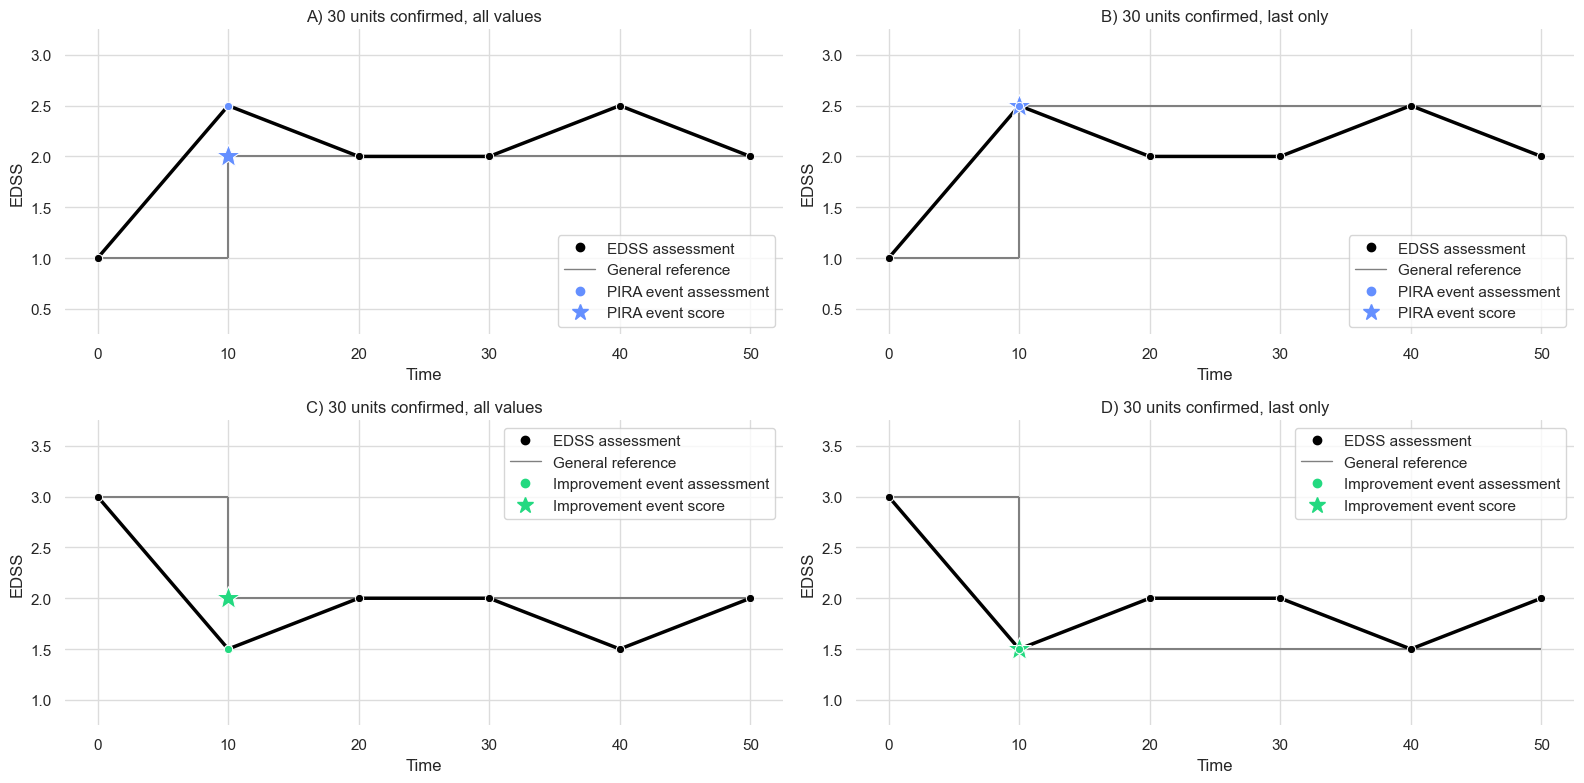

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(16, 8))
example_follow_up = pd.DataFrame(
    {
        "days_after_baseline": [0, 10, 20, 30, 40, 50],
        "edss_score": [1, 2.5, 2.0, 2.0, 2.5, 2.0],
    }
)
for i, confirmation_setting in enumerate(
    [
        ("all", "A) 30 units confirmed, all values"),
        ("last", "B) 30 units confirmed, last only"),
    ]
):
    visualization.annotate_plot_follow_up(
        follow_up_dataframe=example_follow_up,
        annotation_mode=ACCRUAL_MODE_NAME,
        opt_baseline_type="fixed",
        opt_require_confirmation=True,
        opt_confirmation_time=30,
        opt_confirmation_included_values=confirmation_setting[0],
        show_legend=True,
        move_legend_out=False,
        ax=axes[0][i],
    )
    axes[0][i].set_title(confirmation_setting[1])

# Improvement mode
example_follow_up["edss_score"] = 4.0 - example_follow_up["edss_score"]
for i, confirmation_setting in enumerate(
    [
        ("all", "C) 30 units confirmed, all values"),
        ("last", "D) 30 units confirmed, last only"),
    ]
):
    visualization.annotate_plot_follow_up(
        follow_up_dataframe=example_follow_up,
        annotation_mode=IMPROVEMENT_MODE_NAME,
        opt_baseline_type="fixed",
        opt_require_confirmation=True,
        opt_confirmation_time=30,
        opt_confirmation_included_values=confirmation_setting[0],
        show_legend=True,
        move_legend_out=False,
        ax=axes[1][i],
    )
    axes[1][i].set_title(confirmation_setting[1])

fig.tight_layout()
sns.despine(bottom=True, left=True, right=True, top=True)
plt.show()

**Legend**: Confirmation value inclusion options. **A)** All scores within the confirmation interval must satisfy the
confirmation condition. For a confirmation over 30 units, the confirmation scores for the event at step 10 are thus
the scores at steps 20, 30, and 40, and the confirmed event score is 2.0. **B)** Only the first score at or after the
required confirmation time must satisfy the confirmation condition. The confirmation score for the event at step 10
is thus the score at step 40, and the confirmed event score is 2.5. Minimal increase + 1.0, minimum confirmation
condition. **C)** All scores within the confirmation interval must satisfy the confirmation condition. For a confirmation
over 30 units, the confirmation scores for the event at step 10 are thus the scores at steps 20, 30, and 40, and the
confirmed event score is 2.0. **D)** Only the first score at or after the required confirmation time must satisfy the
confirmation condition. The confirmation score for the event at step 10 is thus the score at step 40, and the confirmed
event score is 1.5.

### Confirmation duration types - no confirmation, next, interval, sustained

#### Accrual/improvement mode

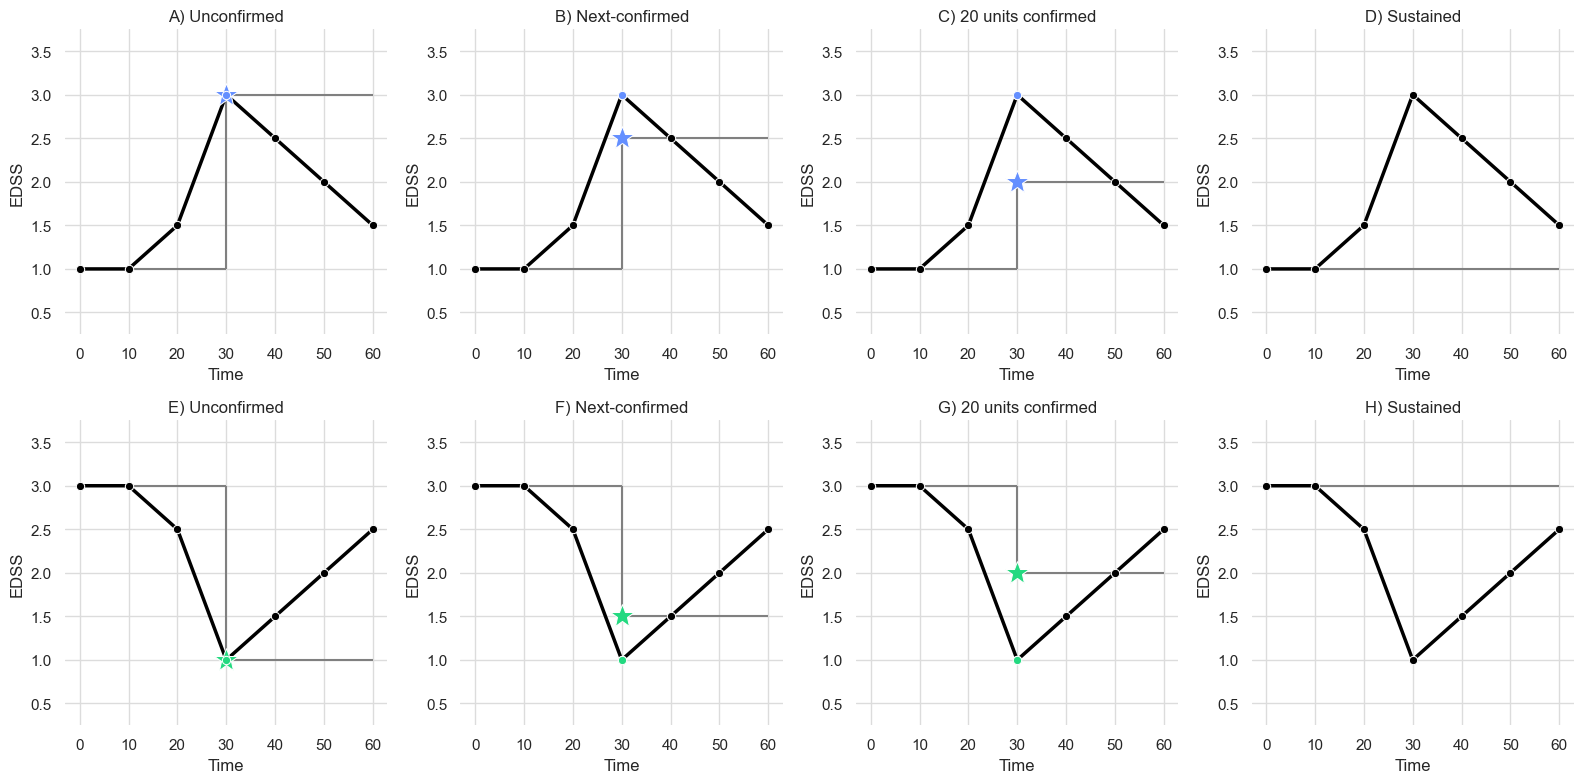

In [ ]:
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
example_follow_up = pd.DataFrame(
    {
        "days_after_baseline": [0, 10, 20, 30, 40, 50, 60],
        "edss_score": [1, 1, 1.5, 3.0, 2.5, 2.0, 1.5],
    }
)
for i, confirmation_setting in enumerate(
    [
        (False, 0, "A) Unconfirmed"),
        (True, 0.5, "B) Next-confirmed"),
        (True, 20, "C) 20 units confirmed"),
        (True, -1, "D) Sustained"),
    ]
):
    visualization.annotate_plot_follow_up(
        follow_up_dataframe=example_follow_up,
        annotation_mode=ACCRUAL_MODE_NAME,
        opt_baseline_type="fixed",
        opt_require_confirmation=confirmation_setting[0],
        opt_confirmation_time=confirmation_setting[1],
        show_legend=False,
        move_legend_out=False,
        ax=axes[0][i],
    )
    axes[0][i].set_title(confirmation_setting[2])

# Improvement mode
example_follow_up["edss_score"] = 4.0 - example_follow_up["edss_score"]
for i, confirmation_setting in enumerate(
    [
        (False, 0, "E) Unconfirmed"),
        (True, 0.5, "F) Next-confirmed"),
        (True, 20, "G) 20 units confirmed"),
        (True, -1, "H) Sustained"),
    ]
):
    visualization.annotate_plot_follow_up(
        follow_up_dataframe=example_follow_up,
        annotation_mode=IMPROVEMENT_MODE_NAME,
        opt_baseline_type="fixed",
        opt_require_confirmation=confirmation_setting[0],
        opt_confirmation_time=confirmation_setting[1],
        show_legend=False,
        move_legend_out=False,
        ax=axes[1][i],
    )
    axes[1][i].set_title(confirmation_setting[2])

fig.tight_layout()
sns.despine(bottom=True, left=True, right=True, top=True)
plt.show()

**Legend**: Confirmation distance types. **A), E)** Unconfirmed disability accrual/improvement, event at step 30 with event
score 3.0/1.0, respectively. **B), F)** Next-confirmed disability accrual, event at step 30 with event score 2.5/1.5. **C), G)**
20 units confirmed, event at step 30 with event score 2.0. **D), H)** Sustained, i.e. there is no event because the last score
of the follow-up is not sufficiently larger than the reference. Minimum increase/decrease + 1.0, minimum condition.

#### Symmetric mode

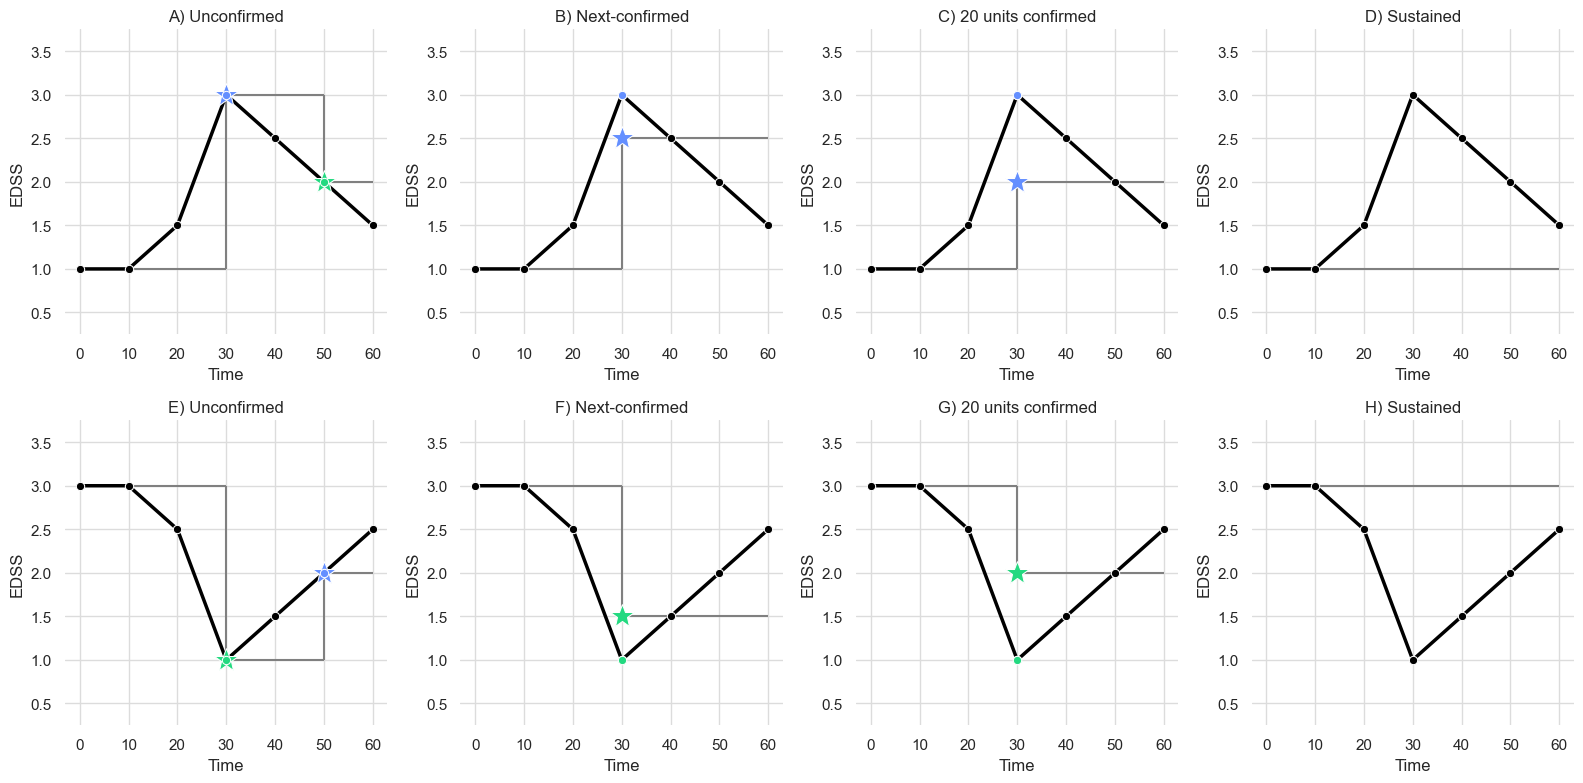

In [ ]:
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
example_follow_up = pd.DataFrame(
    {
        "days_after_baseline": [0, 10, 20, 30, 40, 50, 60],
        "edss_score": [1, 1, 1.5, 3.0, 2.5, 2.0, 1.5],
    }
)
for i, confirmation_setting in enumerate(
    [
        (False, 0, "A) Unconfirmed"),
        (True, 0.5, "B) Next-confirmed"),
        (True, 20, "C) 20 units confirmed"),
        (True, -1, "D) Sustained"),
    ]
):
    visualization.annotate_plot_follow_up(
        follow_up_dataframe=example_follow_up,
        annotation_mode=SYMMETRIC_MODE_NAME,
        opt_baseline_type="fixed",
        opt_require_confirmation=confirmation_setting[0],
        opt_confirmation_time=confirmation_setting[1],
        show_legend=False,
        move_legend_out=False,
        ax=axes[0][i],
    )
    axes[0][i].set_title(confirmation_setting[2])

example_follow_up["edss_score"] = 4.0 - example_follow_up["edss_score"]
for i, confirmation_setting in enumerate(
    [
        (False, 0, "E) Unconfirmed"),
        (True, 0.5, "F) Next-confirmed"),
        (True, 20, "G) 20 units confirmed"),
        (True, -1, "H) Sustained"),
    ]
):
    visualization.annotate_plot_follow_up(
        follow_up_dataframe=example_follow_up,
        annotation_mode=SYMMETRIC_MODE_NAME,
        opt_baseline_type="fixed",
        opt_require_confirmation=confirmation_setting[0],
        opt_confirmation_time=confirmation_setting[1],
        show_legend=False,
        move_legend_out=False,
        ax=axes[1][i],
    )
    axes[1][i].set_title(confirmation_setting[2])

fig.tight_layout()
sns.despine(bottom=True, left=True, right=True, top=True)
plt.show()

**Legend**: Confirmation distance types. **A), E)** Unconfirmed disability accrual/improvement, event at step 30 with event
score 3.0/1.0, respectively. Additional improvement/accrual event at step 50 with confirmed score 2.0 **B), F)** Next-confirmed
disability accrual, event at step 30 with event score 2.5/1.5. **C), G)** 20 units confirmed, event at step 30 with event score
2.0. **D), H)** Sustained, i.e. there is no event because the last score of the follow-up is not sufficiently larger than the
reference. Minimum increase/decrease + 1.0, minimum condition.

### Left hand tolerance

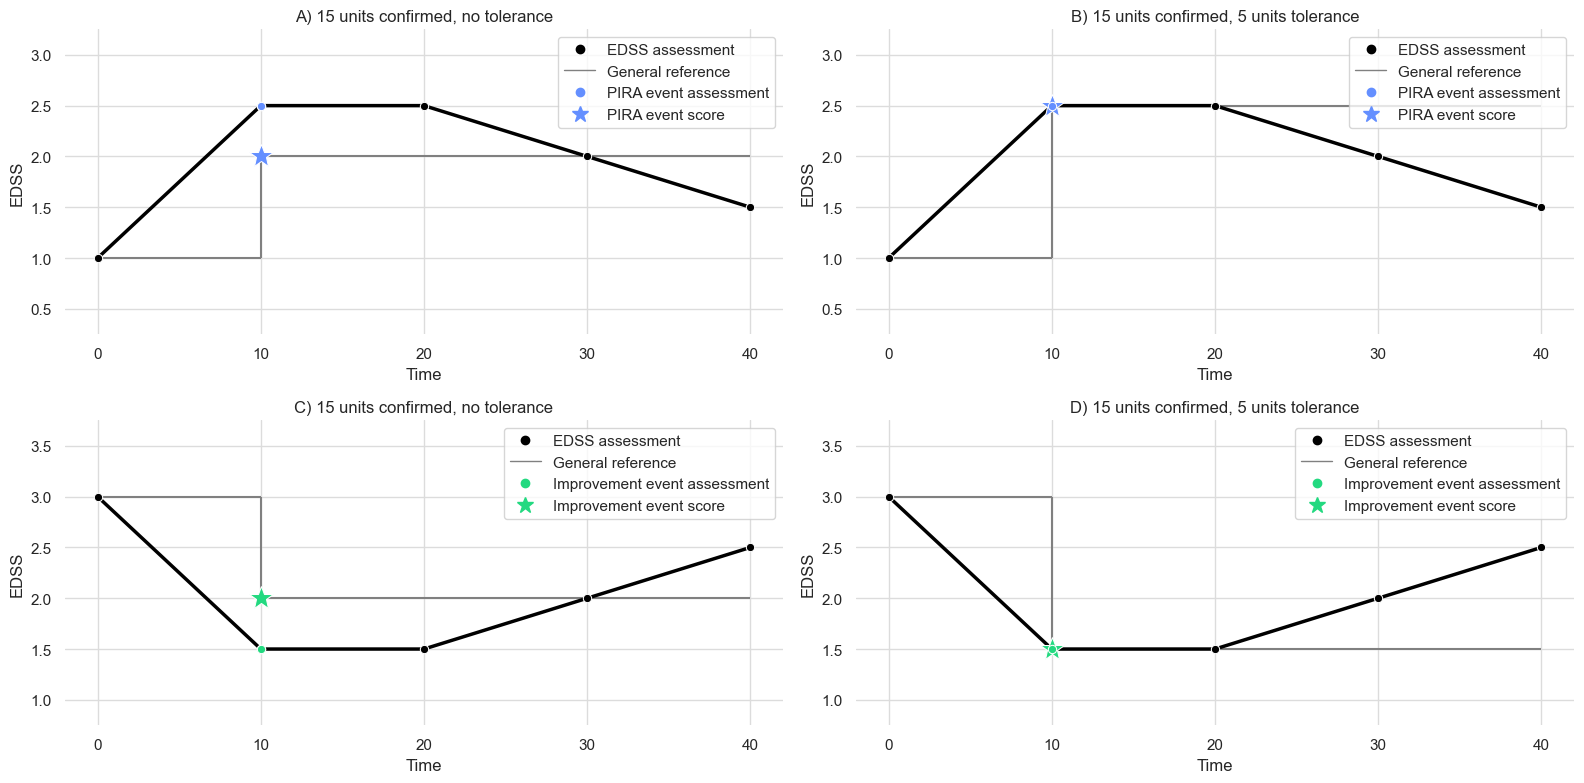

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(16, 8))
example_follow_up = pd.DataFrame(
    {
        "days_after_baseline": [0, 10, 20, 30, 40],
        "edss_score": [1, 2.5, 2.5, 2.0, 1.5],
    }
)
# Accrual mode
for i, confirmation_setting in enumerate(
    [
        (0, "A) 15 units confirmed, no tolerance"),
        (5, "B) 15 units confirmed, 5 units tolerance"),
    ]
):
    visualization.annotate_plot_follow_up(
        follow_up_dataframe=example_follow_up,
        annotation_mode=ACCRUAL_MODE_NAME,
        opt_baseline_type="fixed",
        opt_require_confirmation=True,
        opt_confirmation_time=15,
        opt_confirmation_time_left_side_max_tolerance=confirmation_setting[0],
        show_legend=True,
        move_legend_out=False,
        ax=axes[0][i],
    )
    axes[0][i].set_title(confirmation_setting[1])

# Improvement mode
example_follow_up["edss_score"] = 4.0 - example_follow_up["edss_score"]
for i, confirmation_setting in enumerate(
    [
        (0, "C) 15 units confirmed, no tolerance"),
        (5, "D) 15 units confirmed, 5 units tolerance"),
    ]
):
    visualization.annotate_plot_follow_up(
        follow_up_dataframe=example_follow_up,
        annotation_mode=IMPROVEMENT_MODE_NAME,
        opt_baseline_type="fixed",
        opt_require_confirmation=True,
        opt_confirmation_time=15,
        opt_confirmation_time_left_side_max_tolerance=confirmation_setting[0],
        show_legend=True,
        move_legend_out=False,
        ax=axes[1][i],
    )
    axes[1][i].set_title(confirmation_setting[1])

fig.tight_layout()
sns.despine(bottom=True, left=True, right=True, top=True)
plt.show()

**Legend**: Left-hand tolerance for event confirmation, 15 units confirmation required. **A), C)** No tolerance, i.e. the
confirmation scores for the event at step 10 are the scores at steps 20 and 30 (the first one that satisfies t<sub>j</sub> ≥ t<sub>i</sub> +
Δt), thus the confirmed event score is 2.0. **B), D)** 5 units tolerance, thus the score at step 20 already satisfies the t<sub>j</sub> ≥ t<sub>i</sub> + 
Δt - tolerance condition, and the score at step 30 is not required for confirmation anymore. Minimum increase/decrease + 1.0, minimum condition.

### Right-hand constraint

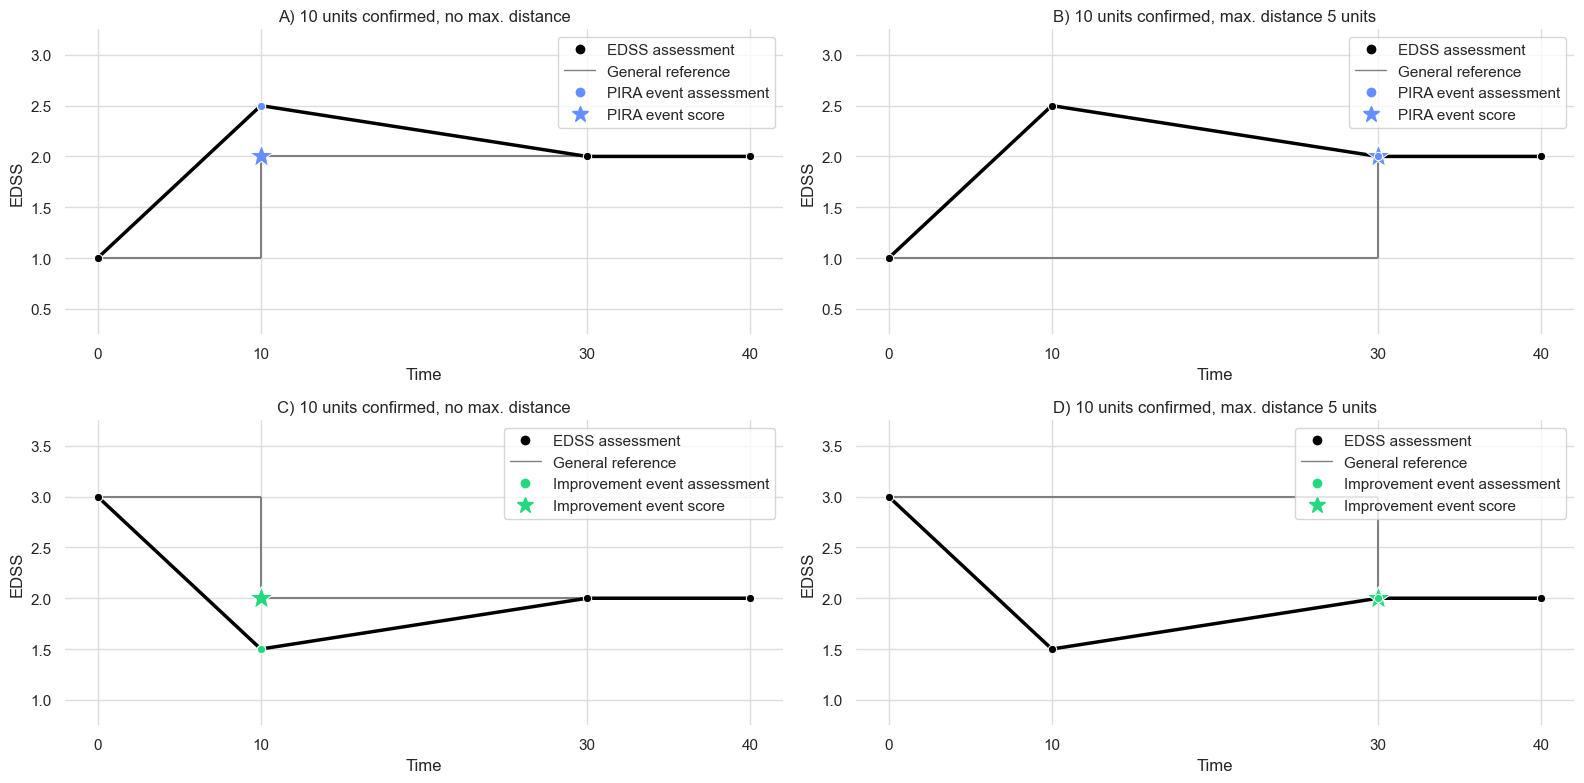

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(16, 8))
example_follow_up = pd.DataFrame(
    {
        "days_after_baseline": [0, 10, 30, 40],
        "edss_score": [1, 2.5, 2.0, 2.0],
    }
)
# Accrual mode
for i, confirmation_setting in enumerate(
    [
        (np.inf, "A) 10 units confirmed, no max. distance"),
        (5, "B) 10 units confirmed, max. distance 5 units"),
    ]
):
    visualization.annotate_plot_follow_up(
        follow_up_dataframe=example_follow_up,
        annotation_mode=ACCRUAL_MODE_NAME,
        opt_baseline_type="fixed",
        opt_require_confirmation=True,
        opt_confirmation_time=10,
        opt_confirmation_time_right_side_max_tolerance=confirmation_setting[0],
        show_legend=True,
        move_legend_out=False,
        ax=axes[0][i],
    )
    axes[0][i].set_title(confirmation_setting[1])

# Improvement mode
example_follow_up["edss_score"] = 4.0 - example_follow_up["edss_score"]
for i, confirmation_setting in enumerate(
    [
        (np.inf, "C) 10 units confirmed, no max. distance"),
        (5, "D) 10 units confirmed, max. distance 5 units"),
    ]
):
    visualization.annotate_plot_follow_up(
        follow_up_dataframe=example_follow_up,
        annotation_mode=IMPROVEMENT_MODE_NAME,
        opt_baseline_type="fixed",
        opt_require_confirmation=True,
        opt_confirmation_time=10,
        opt_confirmation_time_right_side_max_tolerance=confirmation_setting[0],
        show_legend=True,
        move_legend_out=False,
        ax=axes[1][i],
    )
    axes[1][i].set_title(confirmation_setting[1])

fig.tight_layout()
sns.despine(bottom=True, left=True, right=True, top=True)
plt.show()

**Legend**: Confirmation over 10 units required. **A), C)** No right-hand constraint, i.e. the event at step 10 is confirmed
by the score at step 30. **B), D)** Maximal distance from the minimal confirmation distance of 5 units. The score at step
30, which is the first to satisfy the 10 units minimal distance, is more than 10 + 5 units from the event, thus it does
not qualify as confirmation score. However, the score at step 30 is a confirmed disability accrual/improvement with respect to
the baseline at step 0 since the score at step 40 satisfies the minimal and maximal confirmation distance requirements.

### Left-hand tolerance with right-hand constraint

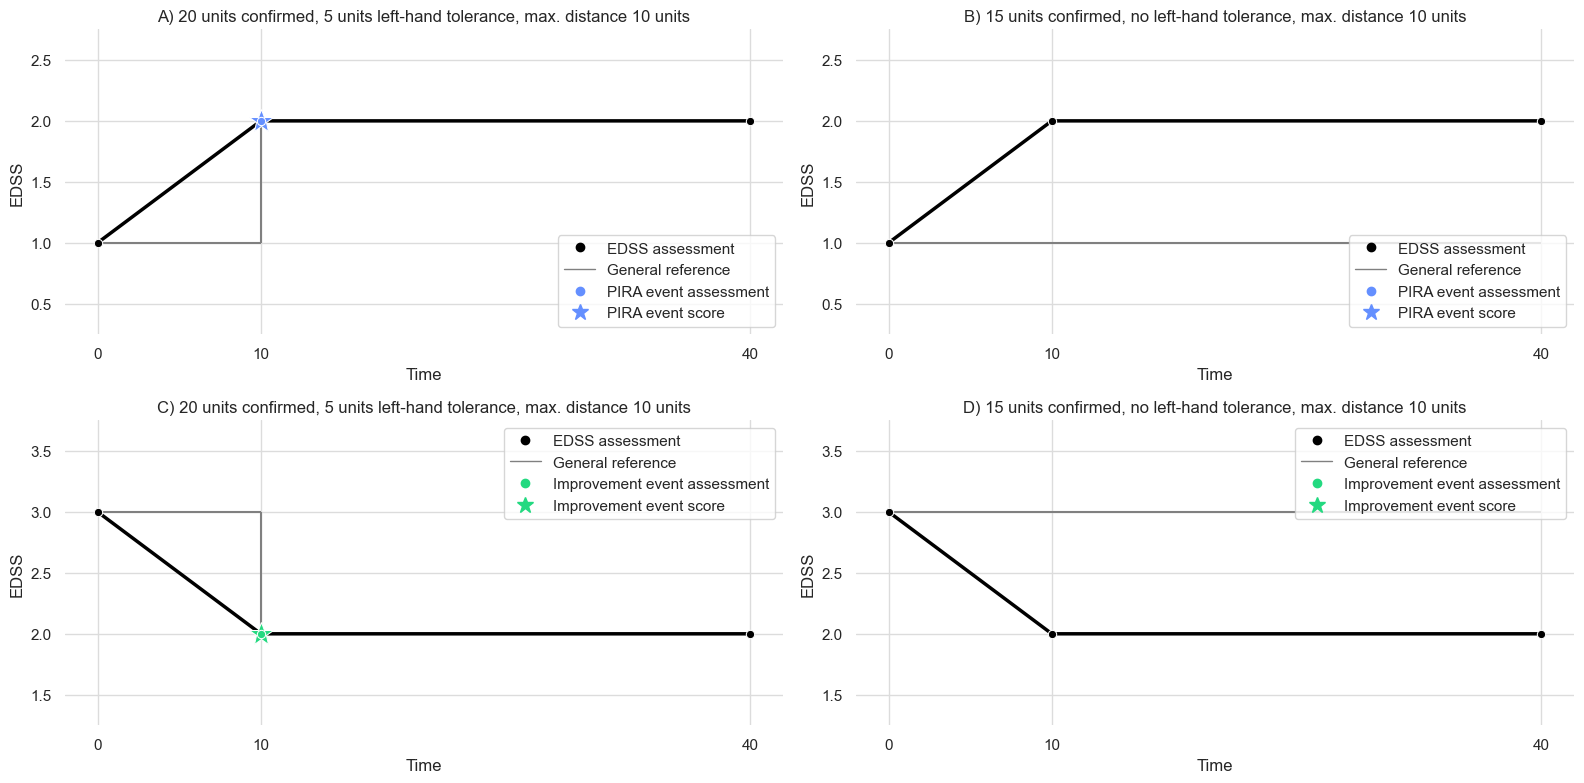

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(16, 8))
example_follow_up = pd.DataFrame(
    {
        "days_after_baseline": [0, 10, 40],
        "edss_score": [1, 2.0, 2.0],
    }
)
# Accrual mode
for i, confirmation_setting in enumerate(
    [
        (
            20,
            5,
            "A) 20 units confirmed, 5 units left-hand tolerance, max. distance 10 units",
        ),
        (
            15,
            0,
            "B) 15 units confirmed, no left-hand tolerance, max. distance 10 units",
        ),
    ]
):
    visualization.annotate_plot_follow_up(
        follow_up_dataframe=example_follow_up,
        annotation_mode=ACCRUAL_MODE_NAME,
        opt_baseline_type="fixed",
        opt_require_confirmation=True,
        opt_confirmation_time=confirmation_setting[0],
        opt_confirmation_time_left_side_max_tolerance=confirmation_setting[1],
        opt_confirmation_time_right_side_max_tolerance=10,
        show_legend=True,
        move_legend_out=False,
        ax=axes[0][i],
    )
    axes[0][i].set_title(confirmation_setting[2])

# Improvement mode
example_follow_up["edss_score"] = 4.0 - example_follow_up["edss_score"]
for i, confirmation_setting in enumerate(
    [
        (
            20,
            5,
            "C) 20 units confirmed, 5 units left-hand tolerance, max. distance 10 units",
        ),
        (
            15,
            0,
            "D) 15 units confirmed, no left-hand tolerance, max. distance 10 units",
        ),
    ]
):
    visualization.annotate_plot_follow_up(
        follow_up_dataframe=example_follow_up,
        annotation_mode=IMPROVEMENT_MODE_NAME,
        opt_baseline_type="fixed",
        opt_require_confirmation=True,
        opt_confirmation_time=confirmation_setting[0],
        opt_confirmation_time_left_side_max_tolerance=confirmation_setting[1],
        opt_confirmation_time_right_side_max_tolerance=10,
        show_legend=True,
        move_legend_out=False,
        ax=axes[1][i],
    )
    axes[1][i].set_title(confirmation_setting[2])

fig.tight_layout()
sns.despine(bottom=True, left=True, right=True, top=True)
plt.show()

**Legend**: Combination of left-hand tolerance and right-hand constraint. **A), C)** 20 units confirmation with 5 units
tolerance. The maximal timestamp (right-hand constraint) for a confirmation assessment for an event at step 10 is
t<sub>i</sub> + Δt + constraint = 10 + 20 + 10 = 40, i.e. the assessment at step 40 is a valid confirmation assessment.
**B), D)** Reducing the minimal distance instead of allowing a left-hand tolerance yields a maximal timestamp t<sub>i</sub> + Δt +
constraint = 10 + 15 + 10 = 35, i.e. the assessment at step 40 is not a valid confirmation assessment.

### Sustained minimal duration

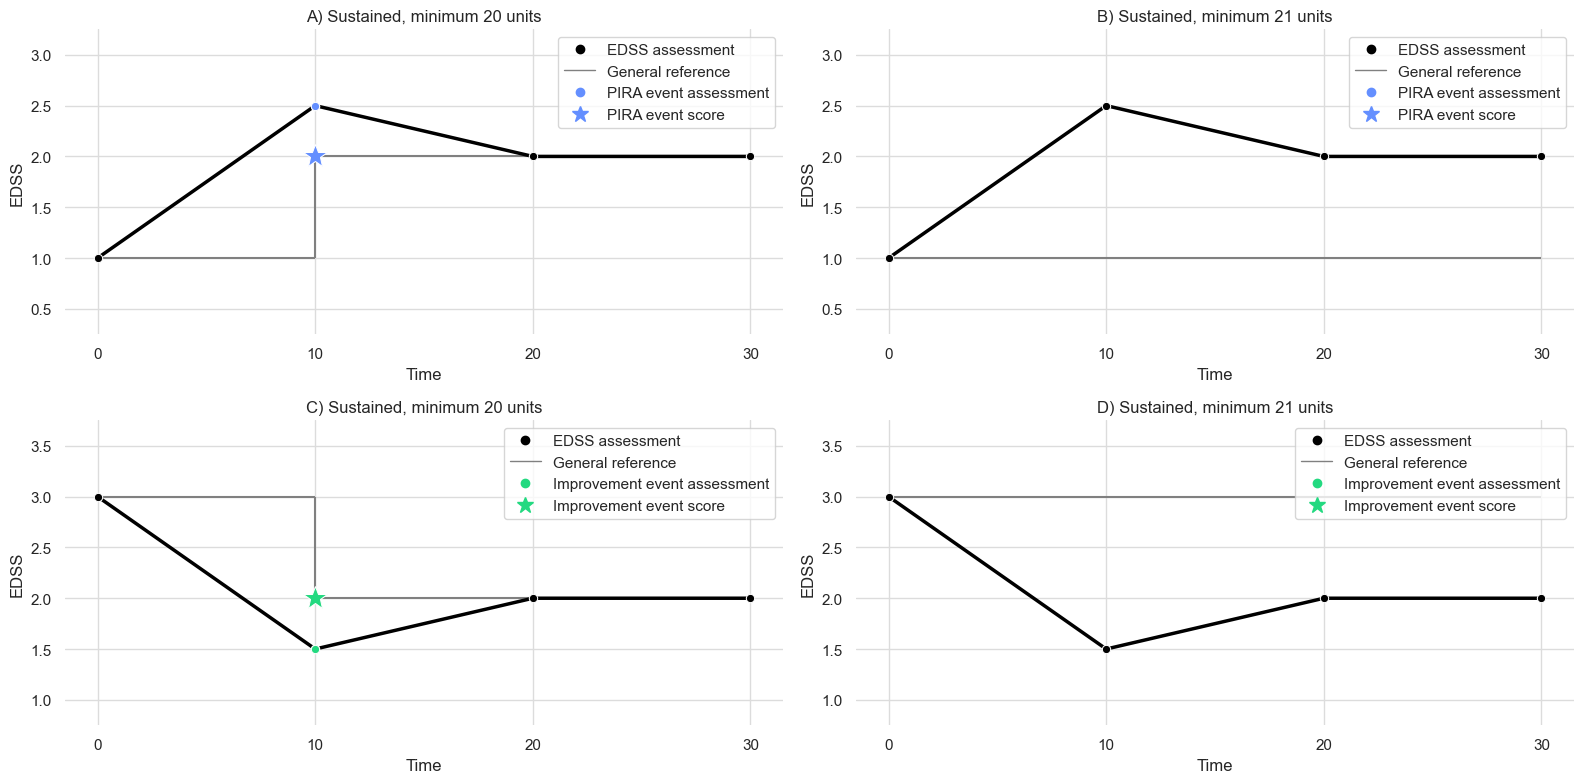

In [28]:
fig, axes = plt.subplots(2, 2, figsize=(16, 8))
example_follow_up = pd.DataFrame(
    {
        "days_after_baseline": [0, 10, 20, 30],
        "edss_score": [1, 2.5, 2.0, 2.0],
    }
)
# Accrual mode
for i, confirmation_setting in enumerate(
    [
        (20, "A) Sustained, minimum 20 units"),
        (21, "B) Sustained, minimum 21 units"),
    ]
):
    visualization.annotate_plot_follow_up(
        follow_up_dataframe=example_follow_up,
        annotation_mode=ACCRUAL_MODE_NAME,
        opt_baseline_type="fixed",
        opt_require_confirmation=True,
        opt_confirmation_time=-1,
        opt_confirmation_sustained_minimal_distance=confirmation_setting[0],
        show_legend=True,
        move_legend_out=False,
        ax=axes[0][i],
    )
    axes[0][i].set_title(confirmation_setting[1])

# Improvement mode
example_follow_up["edss_score"] = 4.0 - example_follow_up["edss_score"]
for i, confirmation_setting in enumerate(
    [
        (20, "C) Sustained, minimum 20 units"),
        (21, "D) Sustained, minimum 21 units"),
    ]
):
    visualization.annotate_plot_follow_up(
        follow_up_dataframe=example_follow_up,
        annotation_mode=IMPROVEMENT_MODE_NAME,
        opt_baseline_type="fixed",
        opt_require_confirmation=True,
        opt_confirmation_time=-1,
        opt_confirmation_sustained_minimal_distance=confirmation_setting[0],
        show_legend=True,
        move_legend_out=False,
        ax=axes[1][i],
    )
    axes[1][i].set_title(confirmation_setting[1])

fig.tight_layout()
sns.despine(bottom=True, left=True, right=True, top=True)
plt.show()

**Legend**: Minimal duration requirement for sustained disability accrual. **A), C)** Minimum duration 20 units. This
condition is satisfied for the increase/decrease at step 10 as the assessment at step 30 satisfies t<sub>j</sub> ≥ t<sub>i</sub> + 
minimum duration = 10 + 20 = 30. **B), D)** Minimum duration 21 units. The increase/decrease at step 10 is not confirmed since there is 
no assessment with a timestamp t<sub>j</sub> that satisfies t<sub>j</sub> ≥ t<sub>i</sub> + minimum duration = 10 + 21 = 31. 
Minimum increase + 1.0, minimum condition.

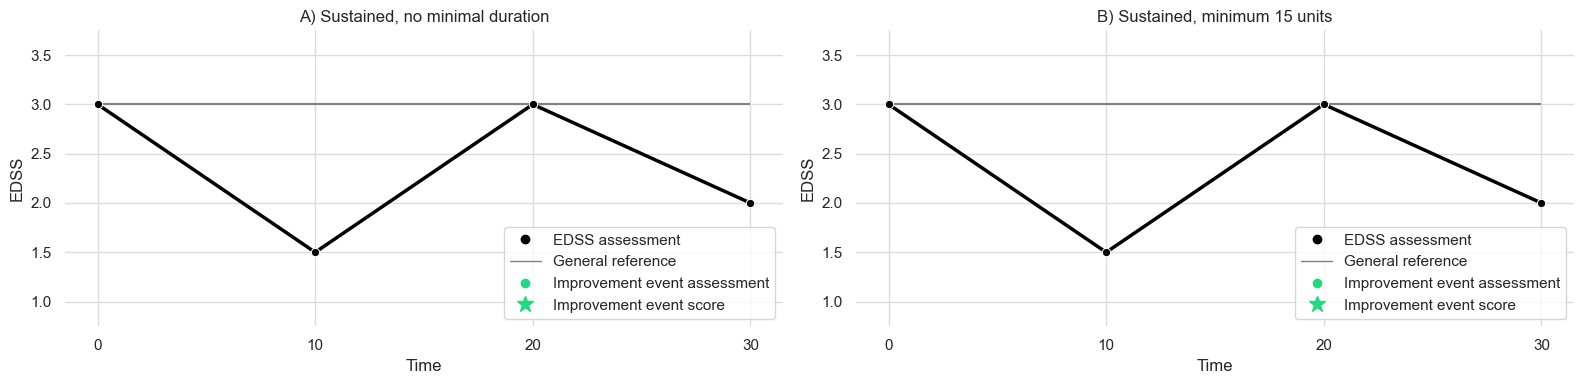

In [26]:
fig, axes = plt.subplots(1, 2, figsize=(16, 4))
example_follow_up = pd.DataFrame(
    {
        "days_after_baseline": [0, 10, 20, 30],
        "edss_score": [3.0, 1.5, 3.0, 2.0],
    }
)
for i, confirmation_setting in enumerate(
    [
        (0, "A) Sustained, no minimal duration"),
        (15, "B) Sustained, minimum 15 units"),
    ]
):
    visualization.annotate_plot_follow_up(
        follow_up_dataframe=example_follow_up,
        annotation_mode=IMPROVEMENT_MODE_NAME,
        opt_baseline_type="fixed",
        opt_require_confirmation=True,
        opt_confirmation_time=-1,
        opt_confirmation_sustained_minimal_distance=confirmation_setting[0],
        show_legend=True,
        move_legend_out=False,
        ax=axes[i],
    )
    axes[i].set_title(confirmation_setting[1])

fig.tight_layout()
sns.despine(bottom=True, left=True, right=True, top=True)
plt.show()

**Legend**: Minimal duration requirement for sustained disability accrual, sanity check. **A)** No minimum duration.
**B)** Minimum duration 21 units. Assessments between event candidate and minimum duration also need to satisfy the
confirmation condition.

### Why "last" is disabled for sustained, and a tale of caution when using "last" and a long confirmation interval

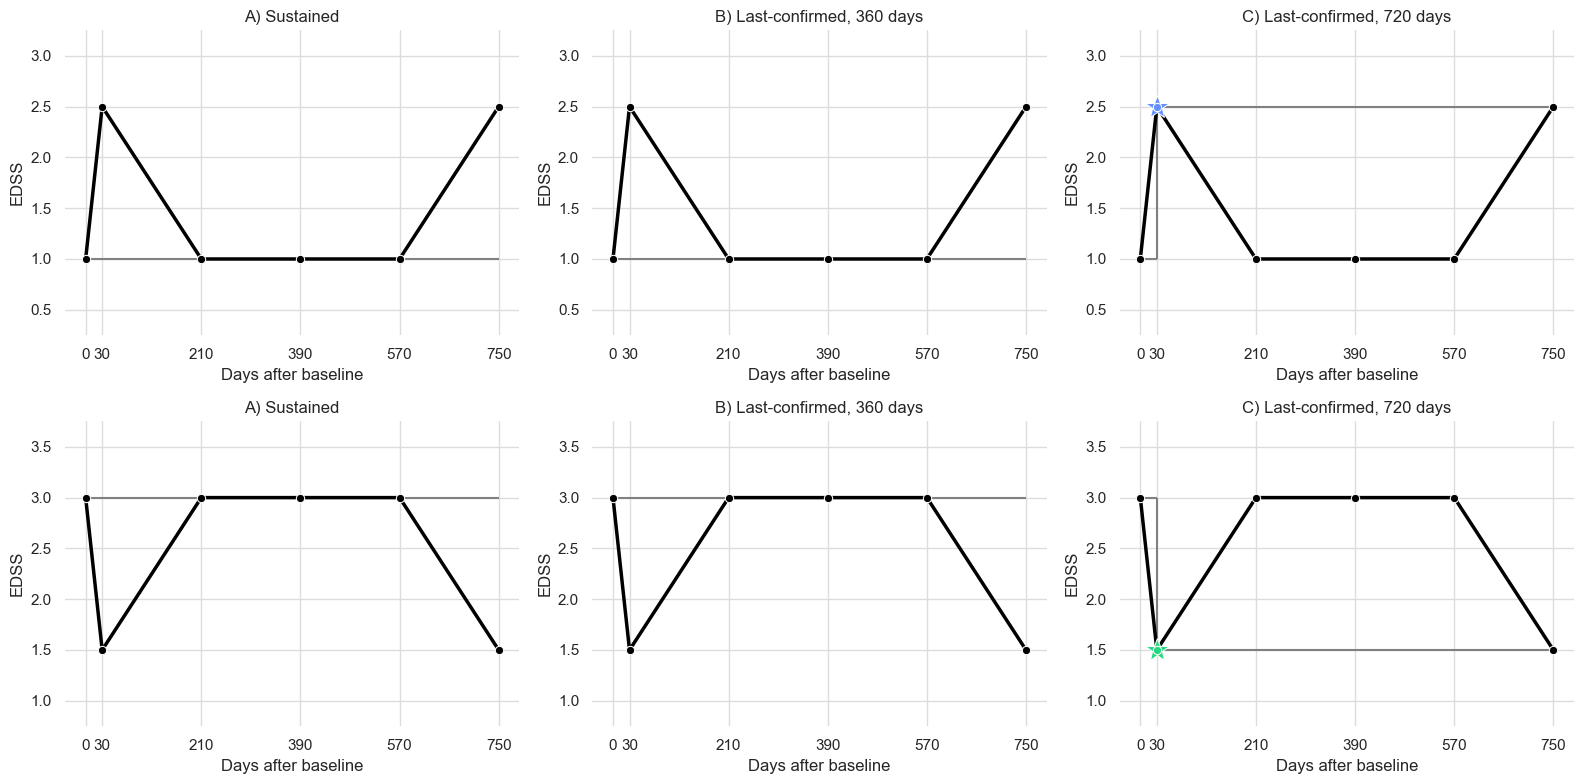

In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(16, 8))
example_follow_up = pd.DataFrame(
    {
        "days_after_baseline": [0, 30, 210, 390, 570, 750],
        "edss_score": [1, 2.5, 1, 1, 1, 2.5],
    }
)
for i, confirmation_setting in enumerate(
    [
        (-1, "all", "A) Sustained"),
        (360, "last", "B) Last-confirmed, 360 days"),
        (720, "last", "C) Last-confirmed, 720 days"),
    ]
):
    visualization.annotate_plot_follow_up(
        follow_up_dataframe=example_follow_up,
        annotation_mode=ACCRUAL_MODE_NAME,
        opt_baseline_type="fixed",
        opt_require_confirmation=True,
        opt_confirmation_time=confirmation_setting[0],
        opt_confirmation_included_values=confirmation_setting[1],
        show_legend=False,
        move_legend_out=False,
        ax=axes[0][i],
    )
    axes[0][i].set_title(confirmation_setting[2])
    axes[0][i].set_xlabel("Days after baseline")

# Improvement mode
example_follow_up["edss_score"] = 4.0 - example_follow_up["edss_score"]
for i, confirmation_setting in enumerate(
    [
        (-1, "all", "D) Sustained"),
        (360, "last", "E) Last-confirmed, 360 days"),
        (720, "last", "F) Last-confirmed, 720 days"),
    ]
):
    visualization.annotate_plot_follow_up(
        follow_up_dataframe=example_follow_up,
        annotation_mode=IMPROVEMENT_MODE_NAME,
        opt_baseline_type="fixed",
        opt_require_confirmation=True,
        opt_confirmation_time=confirmation_setting[0],
        opt_confirmation_included_values=confirmation_setting[1],
        show_legend=False,
        move_legend_out=False,
        ax=axes[1][i],
    )
    axes[1][i].set_title(confirmation_setting[2])
    axes[1][i].set_xlabel("Days after baseline")

fig.tight_layout()
sns.despine(bottom=True, left=True, right=True, top=True)
plt.show()

**Legend**: Last-confirmation is not recommended for long confirmation intervals (not really recommended at all, actually, only to emulate sparse follow-up).

## Last exempt

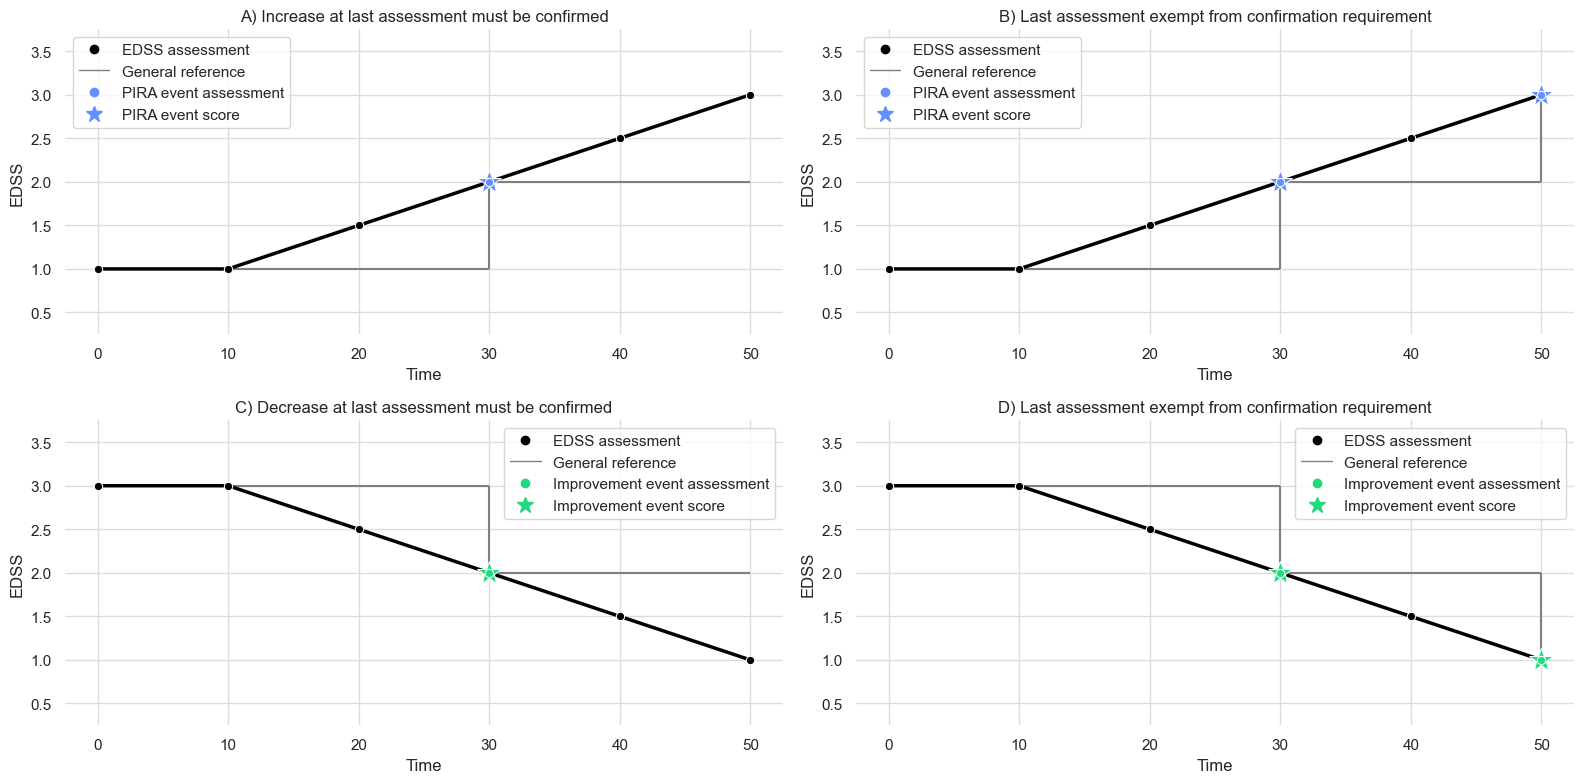

In [30]:
fig, axes = plt.subplots(2, 2, figsize=(16, 8))
test_dataframe = pd.DataFrame(
    {
        "days_after_baseline": [0, 10, 20, 30, 40, 50],
        "edss_score": [1, 1, 1.5, 2.0, 2.5, 3.0],
    }
)
for i, option in enumerate(
    [
        (True, "A) Increase at last assessment must be confirmed"),
        (False, "B) Last assessment exempt from confirmation requirement"),
    ]
):
    visualization.annotate_plot_follow_up(
        follow_up_dataframe=test_dataframe,
        annotation_mode=ACCRUAL_MODE_NAME,
        opt_require_confirmation=True,
        opt_confirmation_time=0.5,
        opt_confirmation_require_confirmation_for_last_visit=option[0],
        show_legend=True,
        move_legend_out=False,
        ax=axes[0][i],
    )
    axes[0][i].set_title(option[1])

# Improvement mode
test_dataframe["edss_score"] = 4.0 - test_dataframe["edss_score"]
for i, option in enumerate(
    [
        (True, "C) Decrease at last assessment must be confirmed"),
        (False, "D) Last assessment exempt from confirmation requirement"),
    ]
):
    visualization.annotate_plot_follow_up(
        follow_up_dataframe=test_dataframe,
        annotation_mode=IMPROVEMENT_MODE_NAME,
        opt_require_confirmation=True,
        opt_confirmation_time=0.5,
        opt_confirmation_require_confirmation_for_last_visit=option[0],
        show_legend=True,
        move_legend_out=False,
        ax=axes[1][i],
    )
    axes[1][i].set_title(option[1])

fig.tight_layout()
sns.despine(bottom=True, left=True, right=True, top=True)
plt.show()

**Legend**: **A), C)** All increases/decreases must be confirmed, thus the increase/decrease at step 50 does not
qualify as disability accrual/improvement. **B), D)** The last assessment is exempt from the confirmation requirement,
thus the increase/decrease at step 50 qualifies as disability accrual/improvement. Minimum increase/decrease + 1.0, next-confirmed.

### Same for symmetric mode of course

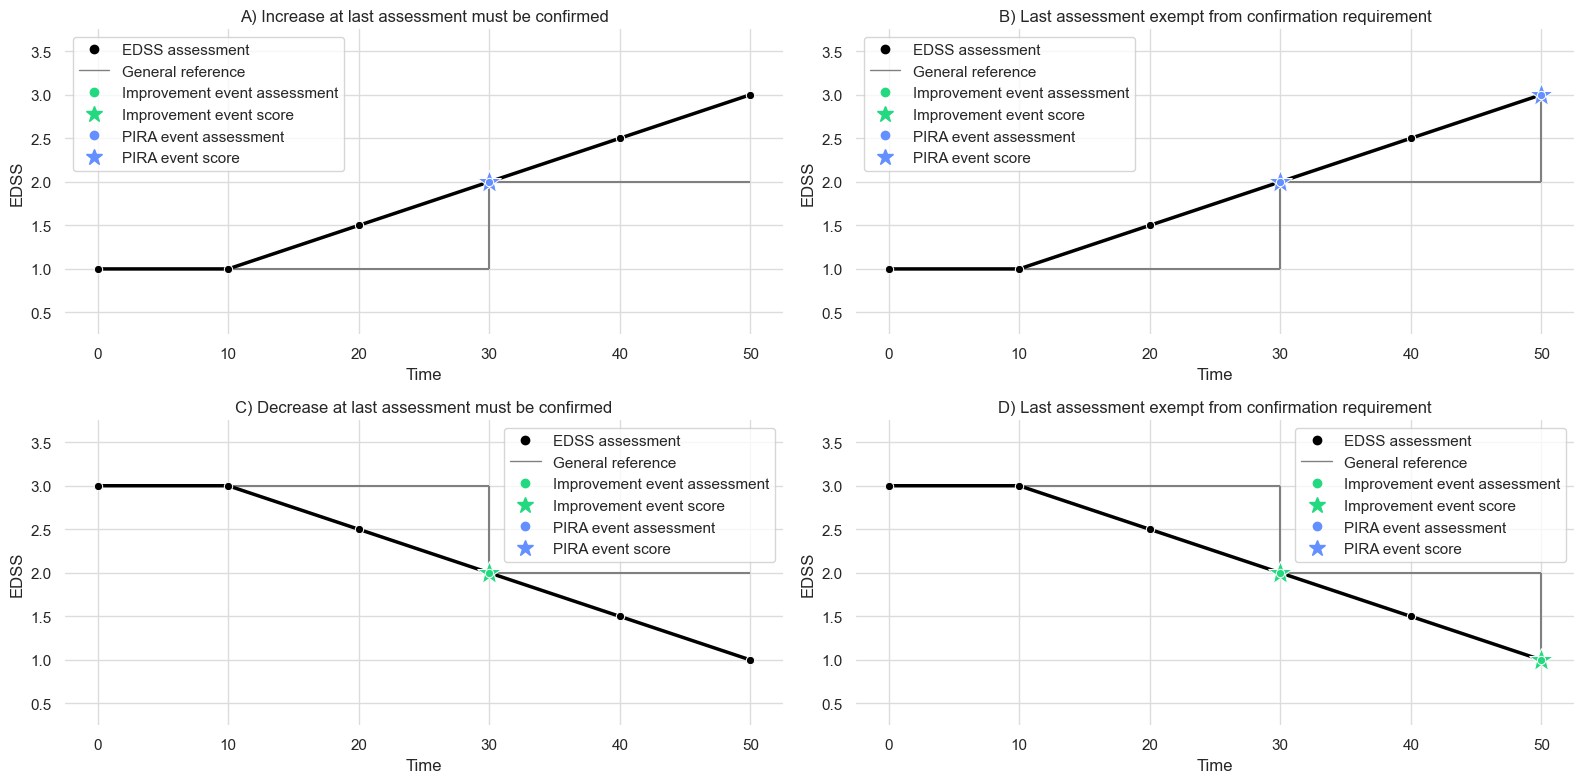

In [31]:
fig, axes = plt.subplots(2, 2, figsize=(16, 8))
test_dataframe = pd.DataFrame(
    {
        "days_after_baseline": [0, 10, 20, 30, 40, 50],
        "edss_score": [1, 1, 1.5, 2.0, 2.5, 3.0],
    }
)
for i, option in enumerate(
    [
        (True, "A) Increase at last assessment must be confirmed"),
        (False, "B) Last assessment exempt from confirmation requirement"),
    ]
):
    visualization.annotate_plot_follow_up(
        follow_up_dataframe=test_dataframe,
        annotation_mode=SYMMETRIC_MODE_NAME,
        opt_baseline_type="fixed",
        opt_require_confirmation=True,
        opt_confirmation_time=0.5,
        opt_confirmation_require_confirmation_for_last_visit=option[0],
        show_legend=True,
        move_legend_out=False,
        ax=axes[0][i],
    )
    axes[0][i].set_title(option[1])

# Experimental inverted mode
test_dataframe["edss_score"] = 4.0 - test_dataframe["edss_score"]
for i, option in enumerate(
    [
        (True, "C) Decrease at last assessment must be confirmed"),
        (False, "D) Last assessment exempt from confirmation requirement"),
    ]
):
    visualization.annotate_plot_follow_up(
        follow_up_dataframe=test_dataframe,
        annotation_mode=SYMMETRIC_MODE_NAME,
        opt_baseline_type="fixed",
        opt_require_confirmation=True,
        opt_confirmation_time=0.5,
        opt_confirmation_require_confirmation_for_last_visit=option[0],
        show_legend=True,
        move_legend_out=False,
        ax=axes[1][i],
    )
    axes[1][i].set_title(option[1])

fig.tight_layout()
sns.despine(bottom=True, left=True, right=True, top=True)
plt.show()

**Legend**: **A), C)** All increases/decreases must be confirmed, thus the increase/decrease at step 50 does not
qualify as disability accrual/improvement. **B), D)** The last assessment is exempt from the confirmation requirement,
thus the increase/decrease at step 50 qualifies as disability accrual/improvement. Minimum increase/decrease + 1.0, next-confirmed.

# Minimal distance

## To previous

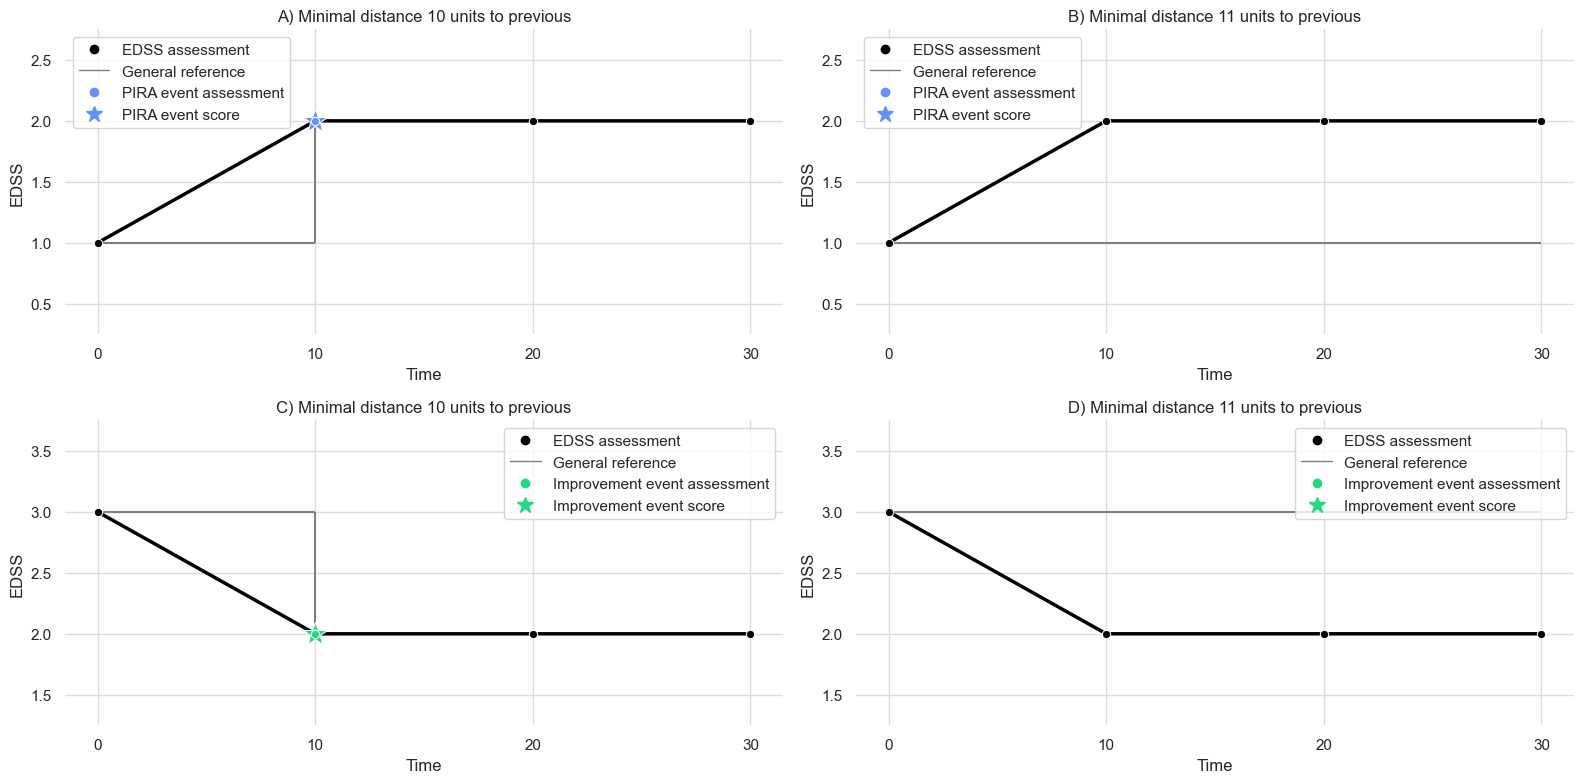

In [32]:
fig, axes = plt.subplots(2, 2, figsize=(16, 8))
example_follow_up = pd.DataFrame(
    {
        "days_after_baseline": [0, 10, 20, 30],
        "edss_score": [1, 2.0, 2.0, 2.0],
    }
)
for i, distance_setting in enumerate(
    [
        (10, "A) Minimal distance 10 units to previous"),
        (11, "B) Minimal distance 11 units to previous"),
    ]
):
    visualization.annotate_plot_follow_up(
        follow_up_dataframe=example_follow_up,
        annotation_mode=ACCRUAL_MODE_NAME,
        opt_baseline_type="fixed",
        opt_minimal_distance_time=distance_setting[0],
        opt_minimal_distance_type="previous",
        show_legend=True,
        move_legend_out=False,
        ax=axes[0][i],
    )
    axes[0][i].set_title(distance_setting[1])

# Improvement mode
example_follow_up["edss_score"] = 4.0 - example_follow_up["edss_score"]
for i, distance_setting in enumerate(
    [
        (10, "C) Minimal distance 10 units to previous"),
        (11, "D) Minimal distance 11 units to previous"),
    ]
):
    visualization.annotate_plot_follow_up(
        follow_up_dataframe=example_follow_up,
        annotation_mode=IMPROVEMENT_MODE_NAME,
        opt_baseline_type="fixed",
        opt_minimal_distance_time=distance_setting[0],
        opt_minimal_distance_type="previous",
        show_legend=True,
        move_legend_out=False,
        ax=axes[1][i],
    )
    axes[1][i].set_title(distance_setting[1])


fig.tight_layout()
sns.despine(bottom=True, left=True, right=True, top=True)
plt.show()

**Legend**: Minimal distance to the previous assessment. **A), C)** The increase/decrease at step 10 is ≥ 10 units from the last
assessment (step 0), thus it qualifies as a disability accrual/improvement event. **B), D)** The increase/decrease at step 10 is < 11
units from the last assessment (step 0), thus it does not qualify as a disability accrual event.

## To reference

### Unconfirmed

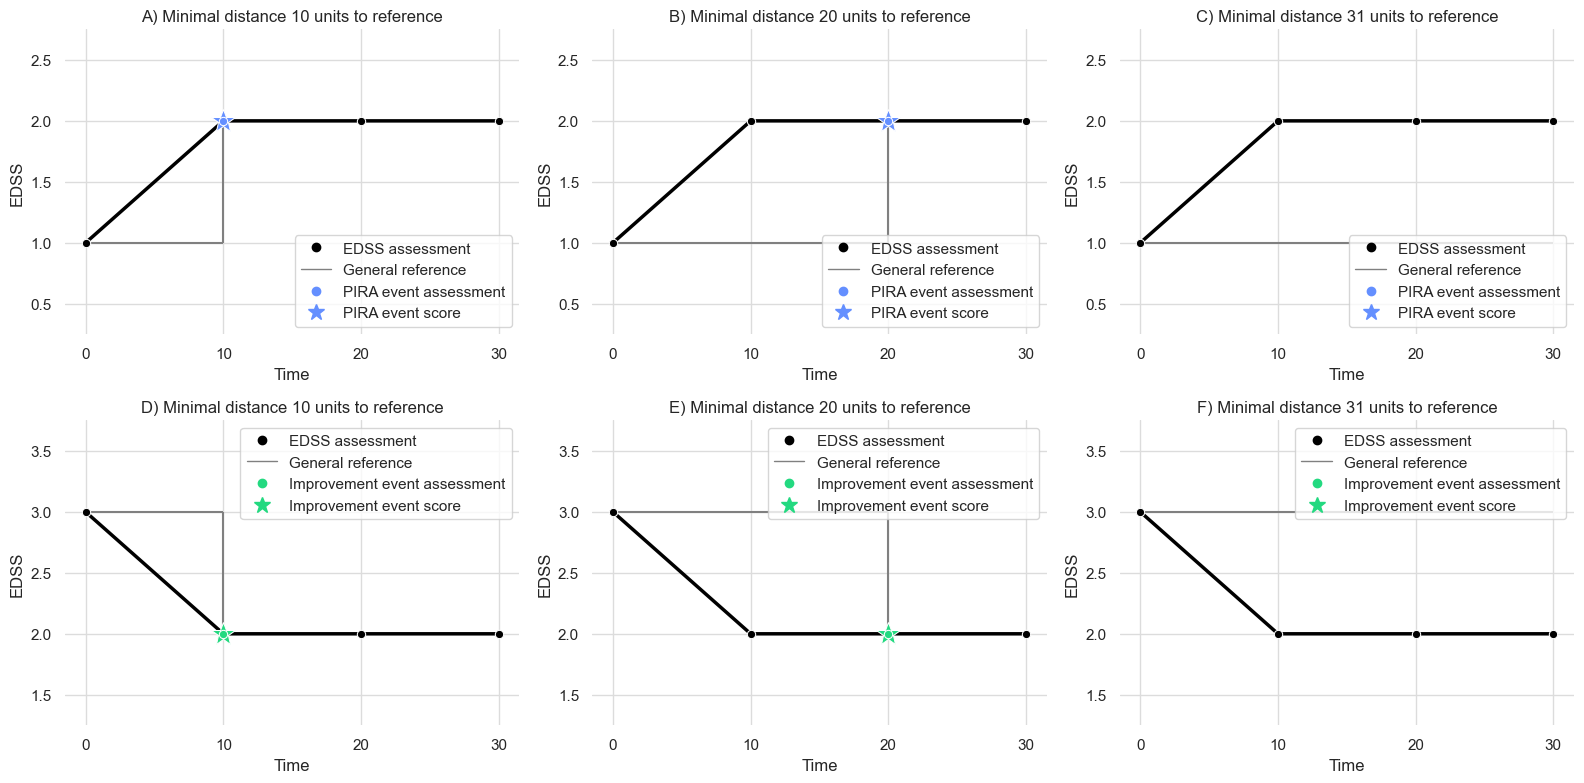

In [33]:
fig, axes = plt.subplots(2, 3, figsize=(16, 8))
example_follow_up = pd.DataFrame(
    {
        "days_after_baseline": [0, 10, 20, 30],
        "edss_score": [1, 2.0, 2.0, 2.0],
    }
)
for i, distance_setting in enumerate(
    [
        (10, "A) Minimal distance 10 units to reference"),
        (20, "B) Minimal distance 20 units to reference"),
        (31, "C) Minimal distance 31 units to reference"),
    ]
):
    visualization.annotate_plot_follow_up(
        follow_up_dataframe=example_follow_up,
        annotation_mode=ACCRUAL_MODE_NAME,
        opt_baseline_type="fixed",
        opt_minimal_distance_time=distance_setting[0],
        opt_minimal_distance_type="reference",
        show_legend=True,
        move_legend_out=False,
        ax=axes[0][i],
    )
    axes[0][i].set_title(distance_setting[1])

# Improvement mode
example_follow_up["edss_score"] = 4.0 - example_follow_up["edss_score"]
for i, distance_setting in enumerate(
    [
        (10, "D) Minimal distance 10 units to reference"),
        (20, "E) Minimal distance 20 units to reference"),
        (31, "F) Minimal distance 31 units to reference"),
    ]
):
    visualization.annotate_plot_follow_up(
        follow_up_dataframe=example_follow_up,
        annotation_mode=IMPROVEMENT_MODE_NAME,
        opt_baseline_type="fixed",
        opt_minimal_distance_time=distance_setting[0],
        opt_minimal_distance_type="reference",
        show_legend=True,
        move_legend_out=False,
        ax=axes[1][i],
    )
    axes[1][i].set_title(distance_setting[1])

fig.tight_layout()
sns.despine(bottom=True, left=True, right=True, top=True)
plt.show()

**Legend**: Minimal distance to the reference, no confirmation requirement. **A), D)** Minimal distance 10 units. The
increase/decrease at step 10 is ≥ 10 units from the reference (step 0), thus it qualifies as a disability accrual/improvement
event. **B), E)** Minimal distance 20 units. The increase/decrease at step 10 is < 20 units from the last assessment (step 0),
thus it does not qualify as a disability accrual/improvement event. However, the score at step 20 satisfies the minimal increment
and minimal distance condition, thus it is a disability accrual/improvement event. **C), F)** Minimal distance 31 units. No assessment
satisfies the minimal distance to reference condition, thus there are no disability accrual/improvement events.

### Minimal distance to reference with confirmation

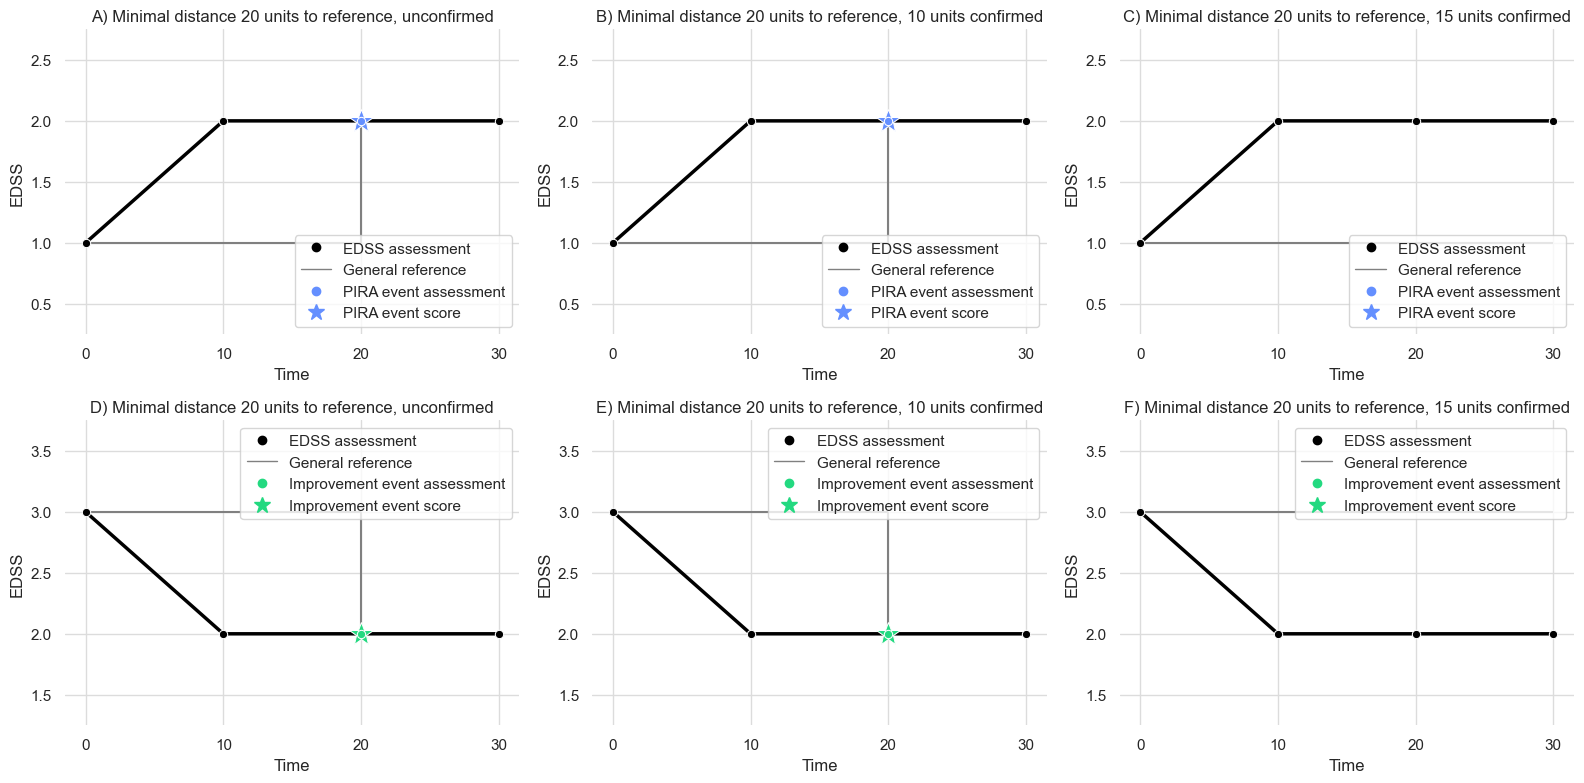

In [34]:
fig, axes = plt.subplots(2, 3, figsize=(16, 8))
example_follow_up = pd.DataFrame(
    {
        "days_after_baseline": [0, 10, 20, 30],
        "edss_score": [1, 2.0, 2.0, 2.0],
    }
)
for i, distance_setting in enumerate(
    [
        (False, 0, "A) Minimal distance 20 units to reference, unconfirmed"),
        (True, 10, "B) Minimal distance 20 units to reference, 10 units confirmed"),
        (True, 15, "C) Minimal distance 20 units to reference, 15 units confirmed"),
    ]
):
    visualization.annotate_plot_follow_up(
        follow_up_dataframe=example_follow_up,
        annotation_mode=ACCRUAL_MODE_NAME,
        opt_baseline_type="fixed",
        opt_minimal_distance_time=20,
        opt_minimal_distance_type="reference",
        opt_require_confirmation=distance_setting[0],
        opt_confirmation_time=distance_setting[1],
        show_legend=True,
        move_legend_out=False,
        ax=axes[0][i],
    )
    axes[0][i].set_title(distance_setting[2])

# Improvement mode
example_follow_up["edss_score"] = 4.0 - example_follow_up["edss_score"]
for i, distance_setting in enumerate(
    [
        (False, 0, "D) Minimal distance 20 units to reference, unconfirmed"),
        (True, 10, "E) Minimal distance 20 units to reference, 10 units confirmed"),
        (True, 15, "F) Minimal distance 20 units to reference, 15 units confirmed"),
    ]
):
    visualization.annotate_plot_follow_up(
        follow_up_dataframe=example_follow_up,
        annotation_mode=IMPROVEMENT_MODE_NAME,
        opt_baseline_type="fixed",
        opt_minimal_distance_time=20,
        opt_minimal_distance_type="reference",
        opt_require_confirmation=distance_setting[0],
        opt_confirmation_time=distance_setting[1],
        show_legend=True,
        move_legend_out=False,
        ax=axes[1][i],
    )
    axes[1][i].set_title(distance_setting[2])

fig.tight_layout()
sns.despine(bottom=True, left=True, right=True, top=True)
plt.show()

**Legend**: Minimal distance to reference (20 units) and confirmation condition. **A), D)** The assessment at step 20 is
the first increase/decrease that satisfies the minimal distance condition. It does not require confirmation, thus it qualifies as
disability accrual/improvement. **B), E)** The assessment at step 20 is the first increase/decrease that satisfies the minimal
distance condition, and the assessment at step 30 satisfies the confirmation requirement of 10 units. **C), F)** The assessment
at step 20 is the first increase/decrease that satisfies the minimal distance condition, but it is not confirmed since there is
no assessment at time ≥ 20 + 15.

### Minimal distance to reference without backtracking
This is only relevant when using a roving reference. Combining distance to reference with a roving reference may lead to counterintuitive annotations (below).

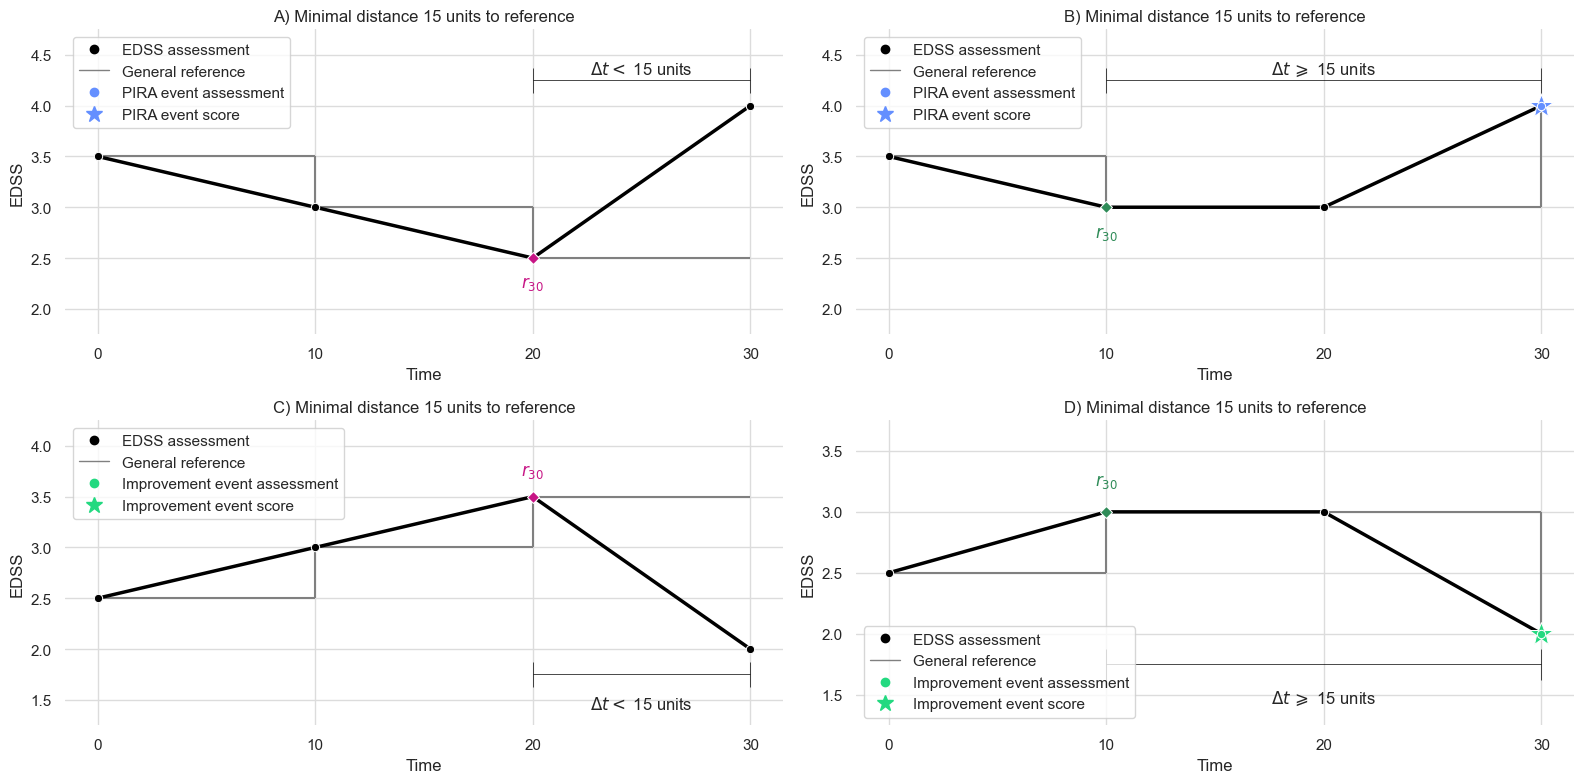

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(16, 8))
example_follow_ups = [
    pd.DataFrame(
        {
            "days_after_baseline": [0, 10, 20, 30],
            "edss_score": [3.5, 3.0, 2.5, 4.0],
        }
    ),
    pd.DataFrame(
        {
            "days_after_baseline": [0, 10, 20, 30],
            "edss_score": [3.5, 3.0, 3.0, 4.0],
        }
    ),
]
for i, distance_setting in enumerate(
    [
        "A) Minimal distance 15 units to reference",
        "B) Minimal distance 15 units to reference",
    ]
):
    visualization.annotate_plot_follow_up(
        follow_up_dataframe=example_follow_ups[i],
        annotation_mode=ACCRUAL_MODE_NAME,
        opt_baseline_type="roving",
        opt_roving_reference_require_confirmation=False,
        opt_minimal_distance_time=15,
        opt_minimal_distance_type="reference",
        opt_minimal_distance_backtrack_decrease=False,
        show_legend=True,
        move_legend_out=False,
        ax=axes[0][i],
    )
    axes[0][i].set_title(distance_setting)
    axes[0][i].set_yticks([2.0, 2.5, 3.0, 3.5, 4.0, 4.5])
    axes[0][i].set_ylim((1.75, 4.75))

axes[0][0].hlines(y=4.25, xmin=20, xmax=30, linewidth=0.5, color="black")
axes[0][0].vlines(x=20, ymin=4.125, ymax=4.375, linewidth=0.5, color="black")
axes[0][0].vlines(x=30, ymin=4.125, ymax=4.375, linewidth=0.5, color="black")
axes[0][0].text(
    x=25,
    y=4.45,
    s=r"$\Delta t <$ 15 units",
    horizontalalignment="center",
    verticalalignment="top",
)
axes[0][0].text(
    x=20,
    y=2.25,
    s=r"$r_{30}$",
    horizontalalignment="center",
    verticalalignment="center",
    color="mediumvioletred",
)
sns.lineplot(
    data=example_follow_ups[0].query("days_after_baseline == 20"),
    x="days_after_baseline",
    y="edss_score",
    color="mediumvioletred",
    marker="D",
    legend=False,
    zorder=50,
    ax=axes[0][0],
)


axes[0][1].hlines(y=4.25, xmin=10, xmax=30, linewidth=0.5, color="black")
axes[0][1].vlines(x=10, ymin=4.125, ymax=4.375, linewidth=0.5, color="black")
axes[0][1].vlines(x=30, ymin=4.125, ymax=4.375, linewidth=0.5, color="black")
axes[0][1].text(
    x=20,
    y=4.45,
    s=r"$\Delta t\, \geqslant$ 15 units",
    horizontalalignment="center",
    verticalalignment="top",
)
axes[0][1].text(
    x=10,
    y=2.75,
    s=r"$r_{30}$",
    horizontalalignment="center",
    verticalalignment="center",
    color="seagreen",
)
sns.lineplot(
    data=example_follow_ups[1].query("days_after_baseline == 10"),
    x="days_after_baseline",
    y="edss_score",
    color="seagreen",
    marker="D",
    legend=False,
    zorder=50,
    ax=axes[0][1],
)

# Improvement mode
for example_follow_up in example_follow_ups:
    example_follow_up["edss_score"] = 6.0 - example_follow_up["edss_score"]
for i, distance_setting in enumerate(
    [
        "C) Minimal distance 15 units to reference",
        "D) Minimal distance 15 units to reference",
    ]
):
    visualization.annotate_plot_follow_up(
        follow_up_dataframe=example_follow_ups[i],
        annotation_mode=IMPROVEMENT_MODE_NAME,
        opt_baseline_type="roving",
        opt_roving_reference_require_confirmation=False,
        opt_minimal_distance_time=15,
        opt_minimal_distance_type="reference",
        opt_minimal_distance_backtrack_decrease=False,
        show_legend=True,
        move_legend_out=False,
        ax=axes[1][i],
    )
    axes[1][i].set_title(distance_setting)

axes[1][0].hlines(y=6 - 4.25, xmin=20, xmax=30, linewidth=0.5, color="black")
axes[1][0].vlines(x=20, ymin=6 - 4.125, ymax=6 - 4.375, linewidth=0.5, color="black")
axes[1][0].vlines(x=30, ymin=6 - 4.125, ymax=6 - 4.375, linewidth=0.5, color="black")
axes[1][0].text(
    x=25,
    y=6 - 4.45,
    s=r"$\Delta t <$ 15 units",
    horizontalalignment="center",
    verticalalignment="top",
)
axes[1][0].text(
    x=20,
    y=6 - 2.25,
    s=r"$r_{30}$",
    horizontalalignment="center",
    verticalalignment="center",
    color="mediumvioletred",
)
sns.lineplot(
    data=example_follow_ups[0].query("days_after_baseline == 20"),
    x="days_after_baseline",
    y="edss_score",
    color="mediumvioletred",
    marker="D",
    legend=False,
    zorder=50,
    ax=axes[1][0],
)

axes[1][1].hlines(y=6 - 4.25, xmin=10, xmax=30, linewidth=0.5, color="black")
axes[1][1].vlines(x=10, ymin=6 - 4.125, ymax=6 - 4.375, linewidth=0.5, color="black")
axes[1][1].vlines(x=30, ymin=6 - 4.125, ymax=6 - 4.375, linewidth=0.5, color="black")
axes[1][1].text(
    x=20,
    y=6 - 4.45,
    s=r"$\Delta t\, \geqslant$ 15 units",
    horizontalalignment="center",
    verticalalignment="top",
)
axes[1][1].text(
    x=10,
    y=6 - 2.75,
    s=r"$r_{30}$",
    horizontalalignment="center",
    verticalalignment="center",
    color="seagreen",
)
sns.lineplot(
    data=example_follow_ups[1].query("days_after_baseline == 10"),
    x="days_after_baseline",
    y="edss_score",
    color="seagreen",
    marker="D",
    legend=False,
    zorder=50,
    ax=axes[1][1],
)


fig.tight_layout()
sns.despine(bottom=True, left=True, right=True, top=True)
plt.show()

**Legend**: Minimal distance to reference with an unconfirmed roving reference. **A), C)** The score at step 20 qualifies
as a new roving reference for the event at step 30, thus the distance between the increase/decrease at step 30 and the
reference does not satisfy the minimal distance condition, and the increase/decrease at step 30 does not qualify as event.
**B), D)** The roving reference is last reset at step 10, thus the distance between the reference and the event candidate
at step 30 satisfies the minimal distance condition and the increase/decrease at step 30 qualifies as an event.

### Minimal distance to reference with backtracking
This option fixes the inconsistency shown above (active by default).

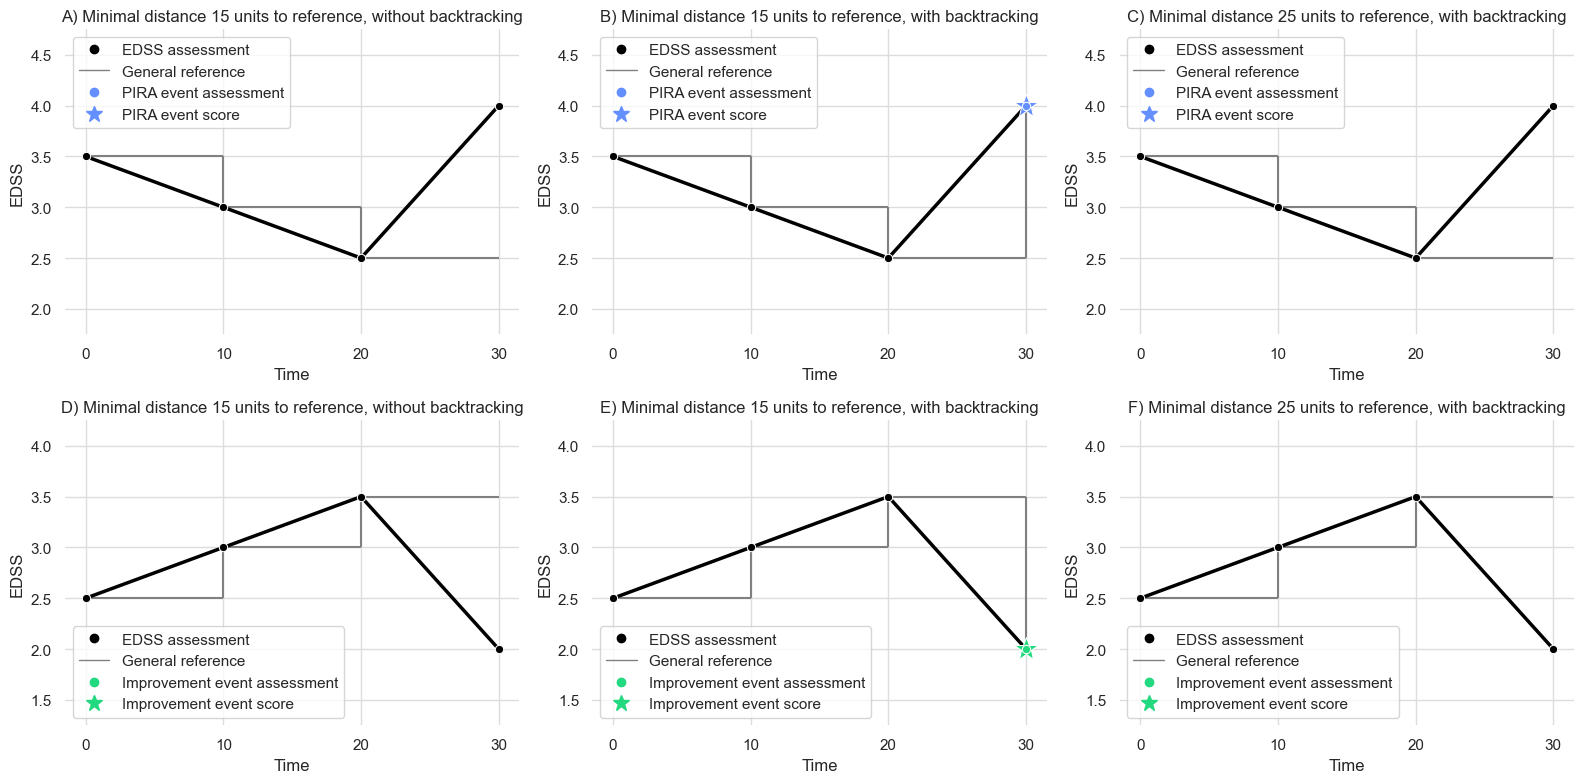

In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(16, 8))
example_follow_up = pd.DataFrame(
    {
        "days_after_baseline": [0, 10, 20, 30],
        "edss_score": [3.5, 3.0, 2.5, 4.0],
    }
)
for i, distance_setting in enumerate(
    [
        (15, False, "A) Minimal distance 15 units to reference, without backtracking"),
        (15, True, "B) Minimal distance 15 units to reference, with backtracking"),
        (25, True, "C) Minimal distance 25 units to reference, with backtracking"),
    ]
):
    visualization.annotate_plot_follow_up(
        follow_up_dataframe=example_follow_up,
        annotation_mode=ACCRUAL_MODE_NAME,
        opt_baseline_type="roving",
        opt_roving_reference_require_confirmation=False,
        opt_minimal_distance_time=distance_setting[0],
        opt_minimal_distance_type="reference",
        opt_minimal_distance_backtrack_decrease=distance_setting[1],
        show_legend=True,
        move_legend_out=False,
        ax=axes[0][i],
    )
    axes[0][i].set_title(distance_setting[2])

# Improvement mode
example_follow_up["edss_score"] = 6.0 - example_follow_up["edss_score"]
for i, distance_setting in enumerate(
    [
        (15, False, "D) Minimal distance 15 units to reference, without backtracking"),
        (15, True, "E) Minimal distance 15 units to reference, with backtracking"),
        (25, True, "F) Minimal distance 25 units to reference, with backtracking"),
    ]
):
    visualization.annotate_plot_follow_up(
        follow_up_dataframe=example_follow_up,
        annotation_mode=IMPROVEMENT_MODE_NAME,
        opt_baseline_type="roving",
        opt_roving_reference_require_confirmation=False,
        opt_minimal_distance_time=distance_setting[0],
        opt_minimal_distance_type="reference",
        opt_minimal_distance_backtrack_decrease=distance_setting[1],
        show_legend=True,
        move_legend_out=False,
        ax=axes[1][i],
    )
    axes[1][i].set_title(distance_setting[2])

fig.tight_layout()
sns.despine(bottom=True, left=True, right=True, top=True)
plt.show()

**Legend**: Minimal distance to reference with a roving reference. **A), D)** The score at step 20 qualifies as a new
roving reference, thus the distance between the increase/decrease at step 30 and the reference does not satisfy the
minimal distance condition. However, the increase/decrease at step 30 would be an event if the score at step 20 was 3.0
instead of 2.5/3.5, because in this case the reference would be the score at step 10 (counterintuitive). **B), E)** With
backtracking, if there is a reference assessment with a score low/high enough for the increase/decrease at 30 to be an event
and that satisfies the minimal distance condition, the increase/decrease at step 30 qualifies as an event. This is the case for
the assessment at step 10. **C), F)** The last reference that would satisfy the minimal distance condition (the assessment at
step 0) is not low/high enough for the score at step 30 to count as an event.

### Minimal distance to reference with backtracking and confirmation

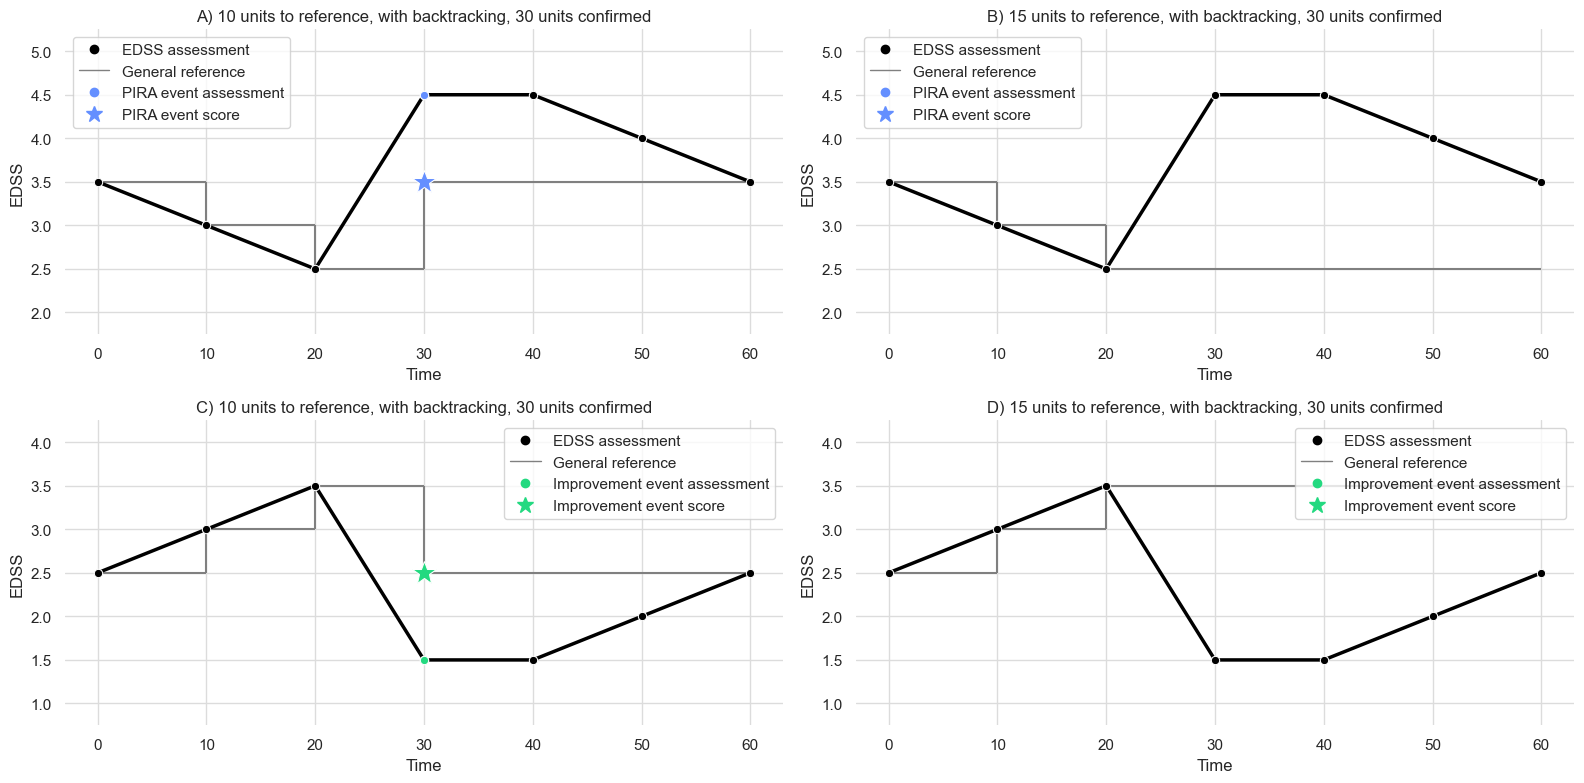

In [37]:
fig, axes = plt.subplots(2, 2, figsize=(16, 8))
example_follow_up = pd.DataFrame(
    {
        "days_after_baseline": [0, 10, 20, 30, 40, 50, 60],
        "edss_score": [3.5, 3.0, 2.5, 4.5, 4.5, 4.0, 3.5],
    }
)
for i, distance_setting in enumerate(
    [
        (10, "A) 10 units to reference, with backtracking, 30 units confirmed"),
        (15, "B) 15 units to reference, with backtracking, 30 units confirmed"),
    ]
):
    visualization.annotate_plot_follow_up(
        follow_up_dataframe=example_follow_up,
        annotation_mode=ACCRUAL_MODE_NAME,
        opt_baseline_type="roving",
        opt_roving_reference_require_confirmation=False,
        opt_minimal_distance_time=distance_setting[0],
        opt_minimal_distance_type="reference",
        opt_minimal_distance_backtrack_decrease=True,
        opt_require_confirmation=True,
        opt_confirmation_time=30,
        show_legend=True,
        move_legend_out=False,
        ax=axes[0][i],
    )
    axes[0][i].set_title(distance_setting[1])

# Improvement mode
example_follow_up["edss_score"] = 6.0 - example_follow_up["edss_score"]
for i, distance_setting in enumerate(
    [
        (10, "C) 10 units to reference, with backtracking, 30 units confirmed"),
        (15, "D) 15 units to reference, with backtracking, 30 units confirmed"),
    ]
):
    visualization.annotate_plot_follow_up(
        follow_up_dataframe=example_follow_up,
        annotation_mode=IMPROVEMENT_MODE_NAME,
        opt_baseline_type="roving",
        opt_roving_reference_require_confirmation=False,
        opt_minimal_distance_time=distance_setting[0],
        opt_minimal_distance_type="reference",
        opt_minimal_distance_backtrack_decrease=True,
        opt_require_confirmation=True,
        opt_confirmation_time=30,
        show_legend=True,
        move_legend_out=False,
        ax=axes[1][i],
    )
    axes[1][i].set_title(distance_setting[1])

fig.tight_layout()
sns.despine(bottom=True, left=True, right=True, top=True)
plt.show()

**Legend**: Minimal distance to reference with backtracking and confirmation over 30 units, minimal increase +
1.0. **A), C)** Minimal distance 10 units, thus the score 2.5/3.5 at step 20 is the reference for the increase/decrease
at step 30. The confirmation scores at steps 40, 50, and 60 all satisfy the confirmation condition score ≥ 2.5 + 1 for
increase/≤ 3.5 - 1 for decrease, thus the increase/decrease at step 30 is confirmed disability accrual. **B), D)** Minimal
distance 15 units, thus the reference for the increase/decrease is the assessment at step 10 with score 3.0. Since the
assessment at step 60 does not satisfy the confirmation condition score ≥ 3.0 + 1/≤ 3.0 - 1, the increase/decrease at step
30 is not confirmed.

### Events stop backtracking

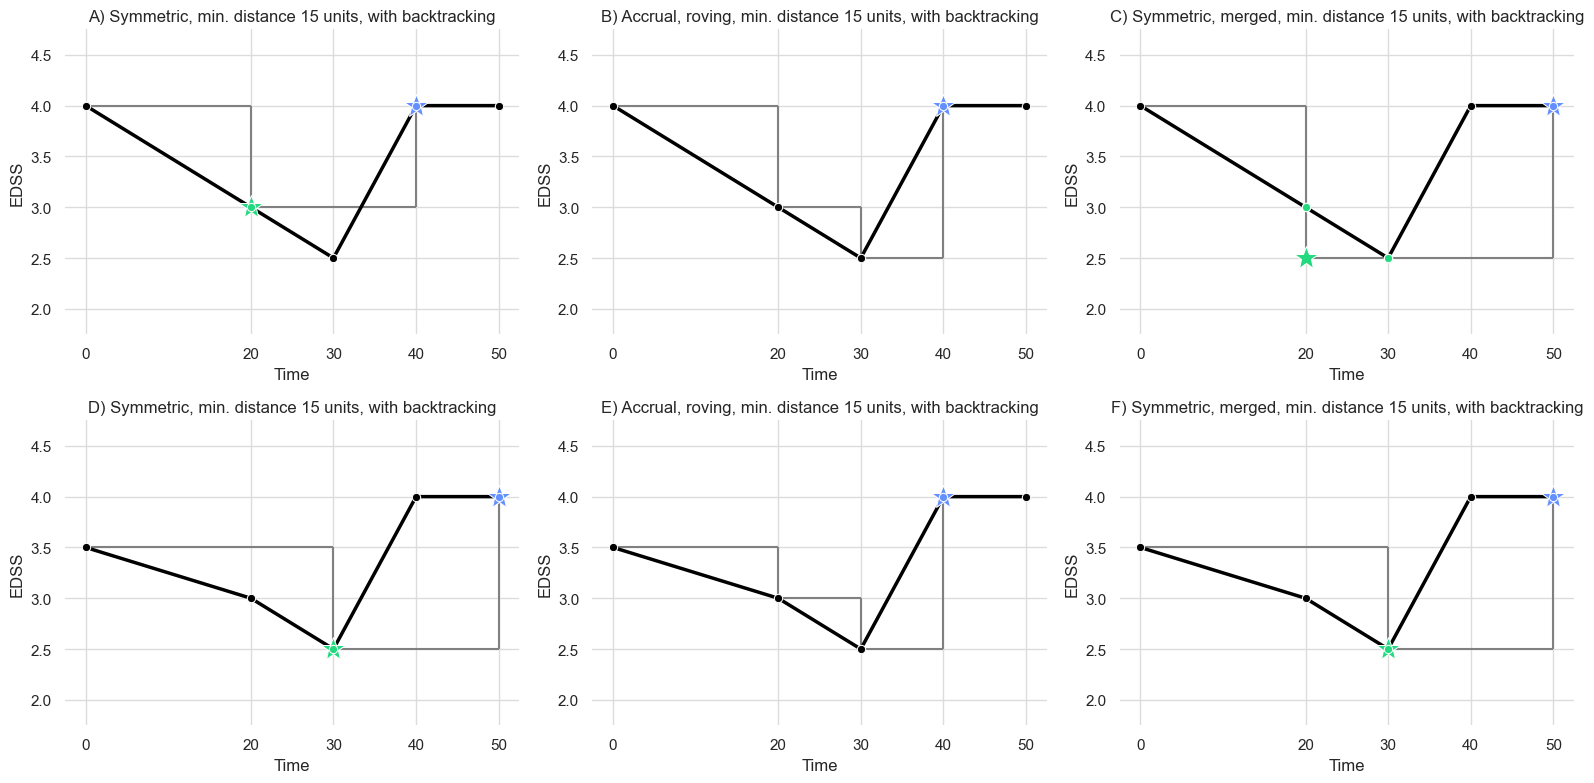

In [38]:
fig, axes = plt.subplots(2, 3, figsize=(16, 8))
example_follow_up = pd.DataFrame(
    {
        "days_after_baseline": [0, 20, 30, 40, 50],
        "edss_score": [4.0, 3.0, 2.5, 4.0, 4.0],
    }
)

visualization.annotate_plot_follow_up(
    follow_up_dataframe=example_follow_up,
    annotation_mode=SYMMETRIC_MODE_NAME,
    opt_baseline_type="fixed",
    opt_roving_reference_require_confirmation=False,
    opt_minimal_distance_time=15,
    opt_minimal_distance_type="reference",
    opt_minimal_distance_backtrack_decrease=True,
    opt_require_confirmation=False,
    show_legend=False,
    move_legend_out=False,
    ax=axes[0][0],
)

visualization.annotate_plot_follow_up(
    follow_up_dataframe=example_follow_up,
    annotation_mode=ACCRUAL_MODE_NAME,
    opt_baseline_type="roving",
    opt_roving_reference_require_confirmation=False,
    opt_minimal_distance_time=15,
    opt_minimal_distance_type="reference",
    opt_minimal_distance_backtrack_decrease=True,
    opt_require_confirmation=False,
    show_legend=False,
    move_legend_out=False,
    ax=axes[0][1],
)

visualization.annotate_plot_follow_up(
    follow_up_dataframe=example_follow_up,
    annotation_mode=SYMMETRIC_MODE_NAME,
    opt_baseline_type="fixed",
    opt_roving_reference_require_confirmation=False,
    opt_minimal_distance_time=15,
    opt_minimal_distance_type="reference",
    opt_minimal_distance_backtrack_decrease=True,
    opt_require_confirmation=False,
    merge_continuous_events=True,
    show_legend=False,
    move_legend_out=False,
    ax=axes[0][2],
)

example_follow_up = pd.DataFrame(
    {
        "days_after_baseline": [0, 20, 30, 40, 50],
        "edss_score": [3.5, 3.0, 2.5, 4.0, 4.0],
    }
)
visualization.annotate_plot_follow_up(
    follow_up_dataframe=example_follow_up,
    annotation_mode=SYMMETRIC_MODE_NAME,
    opt_baseline_type="fixed",
    opt_roving_reference_require_confirmation=False,
    opt_minimal_distance_time=15,
    opt_minimal_distance_type="reference",
    opt_minimal_distance_backtrack_decrease=True,
    opt_require_confirmation=False,
    show_legend=False,
    move_legend_out=False,
    ax=axes[1][0],
)

visualization.annotate_plot_follow_up(
    follow_up_dataframe=example_follow_up,
    annotation_mode=ACCRUAL_MODE_NAME,
    opt_baseline_type="roving",
    opt_roving_reference_require_confirmation=False,
    opt_minimal_distance_time=15,
    opt_minimal_distance_type="reference",
    opt_minimal_distance_backtrack_decrease=True,
    opt_require_confirmation=False,
    show_legend=False,
    move_legend_out=False,
    ax=axes[1][1],
)

visualization.annotate_plot_follow_up(
    follow_up_dataframe=example_follow_up,
    annotation_mode=SYMMETRIC_MODE_NAME,
    opt_baseline_type="fixed",
    opt_roving_reference_require_confirmation=False,
    opt_minimal_distance_time=15,
    opt_minimal_distance_type="reference",
    opt_minimal_distance_backtrack_decrease=True,
    opt_require_confirmation=False,
    merge_continuous_events=True,
    show_legend=False,
    move_legend_out=False,
    ax=axes[1][2],
)

axes[0][0].set_title("A) Symmetric, min. distance 15 units, with backtracking")
axes[0][1].set_title("B) Accrual, roving, min. distance 15 units, with backtracking")
axes[0][2].set_title("C) Symmetric, merged, min. distance 15 units, with backtracking")
axes[1][0].set_title("D) Symmetric, min. distance 15 units, with backtracking")
axes[1][1].set_title("E) Accrual, roving, min. distance 15 units, with backtracking")
axes[1][2].set_title("F) Symmetric, merged, min. distance 15 units, with backtracking")


fig.tight_layout()
sns.despine(bottom=True, left=True, right=True, top=True)
plt.show()

**Legend**: The baseline is reset after a confirmed event, and backtracking does not extend to scores recorded before an event to ensure consistency with how study baselines are handled. **A)** Symmetric mode, event confirmation at the next assessment required. Confirmed improvement at step 20. The increase at step 40 fulfills the minimal distance to reference condition. **B)** Accrual mode with roving reference. The increase at step 40 satisfies the minimal distance condition with respect to the backtracked reference at step 20. **C)** Symmetric mode with event merging, no event confirmation required. The decrease at step 30 is part of the merged event, thus the post-event re-baselining happens at step 30. The increase at step 40 is too close to this new reference, thus step 50 is considered the accrual event. **D), F)** Symmetric mode, no event confirmation reauired. Improvement event at 30, no backtracking to 20. **E)** Roving allows backtracking to 20.

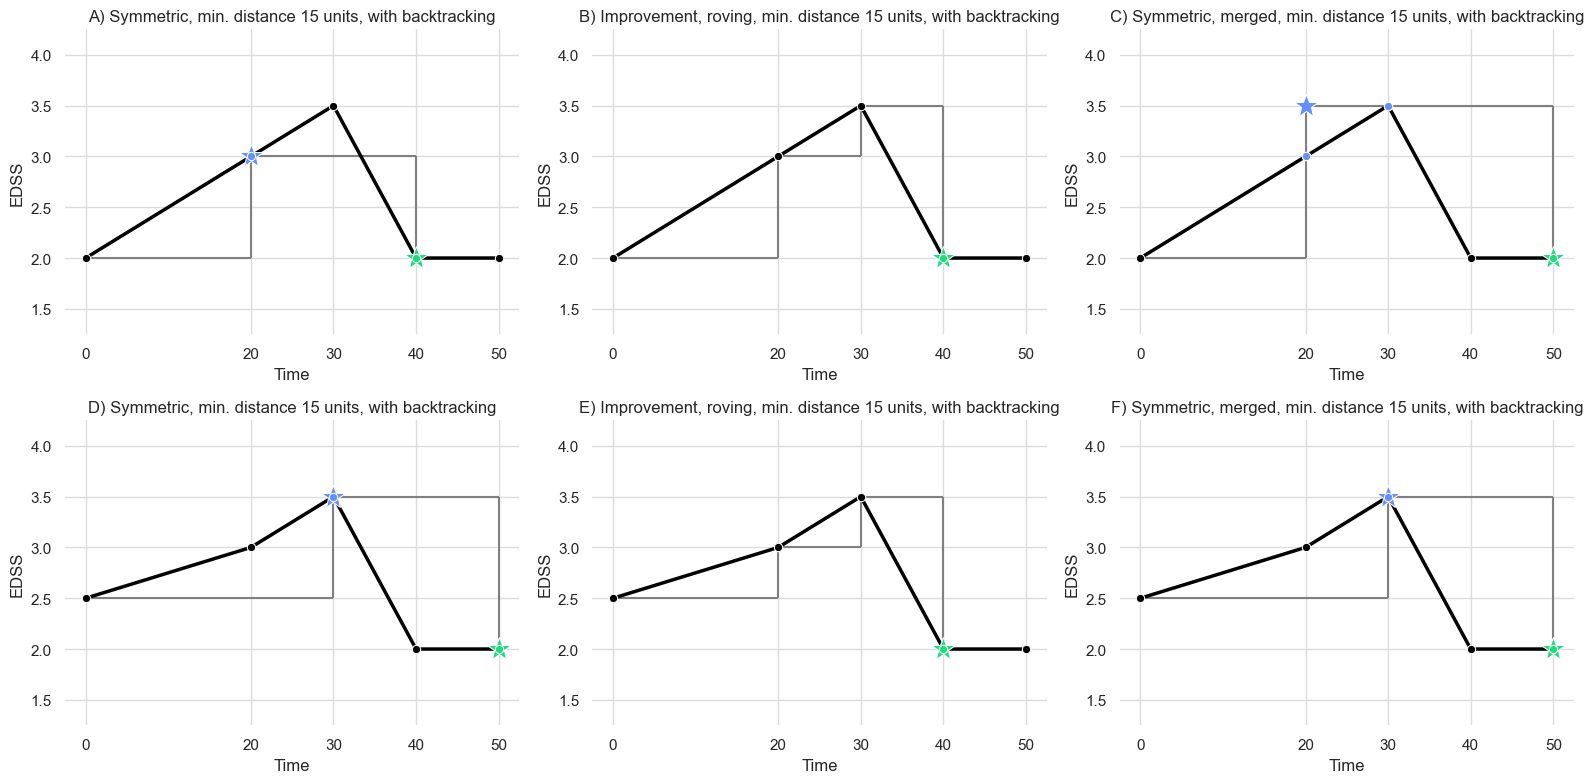

In [39]:
fig, axes = plt.subplots(2, 3, figsize=(16, 8))
example_follow_up = pd.DataFrame(
    {
        "days_after_baseline": [0, 20, 30, 40, 50],
        "edss_score": [4.0, 3.0, 2.5, 4.0, 4.0],
    }
)

example_follow_up["edss_score"] = 6.0 - example_follow_up["edss_score"]
visualization.annotate_plot_follow_up(
    follow_up_dataframe=example_follow_up,
    annotation_mode=SYMMETRIC_MODE_NAME,
    opt_baseline_type="fixed",
    opt_roving_reference_require_confirmation=False,
    opt_minimal_distance_time=15,
    opt_minimal_distance_type="reference",
    opt_minimal_distance_backtrack_decrease=True,
    opt_require_confirmation=False,
    show_legend=False,
    move_legend_out=False,
    ax=axes[0][0],
)
visualization.annotate_plot_follow_up(
    follow_up_dataframe=example_follow_up,
    annotation_mode=IMPROVEMENT_MODE_NAME,
    opt_baseline_type="roving",
    opt_roving_reference_require_confirmation=False,
    opt_minimal_distance_time=15,
    opt_minimal_distance_type="reference",
    opt_minimal_distance_backtrack_decrease=True,
    opt_require_confirmation=False,
    show_legend=False,
    move_legend_out=False,
    ax=axes[0][1],
)
visualization.annotate_plot_follow_up(
    follow_up_dataframe=example_follow_up,
    annotation_mode=SYMMETRIC_MODE_NAME,
    opt_baseline_type="fixed",
    opt_roving_reference_require_confirmation=False,
    opt_minimal_distance_time=15,
    opt_minimal_distance_type="reference",
    opt_minimal_distance_backtrack_decrease=True,
    opt_require_confirmation=False,
    merge_continuous_events=True,
    show_legend=False,
    move_legend_out=False,
    ax=axes[0][2],
)

example_follow_up = pd.DataFrame(
    {
        "days_after_baseline": [0, 20, 30, 40, 50],
        "edss_score": [3.5, 3.0, 2.5, 4.0, 4.0],
    }
)
example_follow_up["edss_score"] = 6.0 - example_follow_up["edss_score"]
visualization.annotate_plot_follow_up(
    follow_up_dataframe=example_follow_up,
    annotation_mode=SYMMETRIC_MODE_NAME,
    opt_baseline_type="fixed",
    opt_roving_reference_require_confirmation=False,
    opt_minimal_distance_time=15,
    opt_minimal_distance_type="reference",
    opt_minimal_distance_backtrack_decrease=True,
    opt_require_confirmation=False,
    show_legend=False,
    move_legend_out=False,
    ax=axes[1][0],
)

visualization.annotate_plot_follow_up(
    follow_up_dataframe=example_follow_up,
    annotation_mode=IMPROVEMENT_MODE_NAME,
    opt_baseline_type="roving",
    opt_roving_reference_require_confirmation=False,
    opt_minimal_distance_time=15,
    opt_minimal_distance_type="reference",
    opt_minimal_distance_backtrack_decrease=True,
    opt_require_confirmation=False,
    show_legend=False,
    move_legend_out=False,
    ax=axes[1][1],
)

visualization.annotate_plot_follow_up(
    follow_up_dataframe=example_follow_up,
    annotation_mode=SYMMETRIC_MODE_NAME,
    opt_baseline_type="fixed",
    opt_roving_reference_require_confirmation=False,
    opt_minimal_distance_time=15,
    opt_minimal_distance_type="reference",
    opt_minimal_distance_backtrack_decrease=True,
    opt_require_confirmation=False,
    merge_continuous_events=True,
    show_legend=False,
    move_legend_out=False,
    ax=axes[1][2],
)

axes[0][0].set_title("A) Symmetric, min. distance 15 units, with backtracking")
axes[0][1].set_title(
    "B) Improvement, roving, min. distance 15 units, with backtracking"
)
axes[0][2].set_title("C) Symmetric, merged, min. distance 15 units, with backtracking")
axes[1][0].set_title("D) Symmetric, min. distance 15 units, with backtracking")
axes[1][1].set_title(
    "E) Improvement, roving, min. distance 15 units, with backtracking"
)
axes[1][2].set_title("F) Symmetric, merged, min. distance 15 units, with backtracking")


fig.tight_layout()
sns.despine(bottom=True, left=True, right=True, top=True)
plt.show()

**Legend**: The baseline is reset after a confirmed event, and backtracking does not extend to scores recorded before an event to ensure consistency with how study baselines are handled. **A)** Symmetric mode, event confirmation at the next assessment required. Confirmed increase at step 20. The decrease at step 40 fulfills the minimal distance to reference condition. **B)** Accrual mode with roving reference. The decrease at step 40 satisfies the minimal distance condition with respect to the backtracked reference at step 20. **C)** Symmetric mode with event merging, no event confirmation required. The increase at step 30 is part of the merged event, thus the post-event re-baselining happens at step 30. The decrease at step 40 is too close to this new reference, thus step 50 is considered the improvement event. **D), F)** No event confirmation required. Accrual event at 30, no backtracking to 20. **E)** Roving allows backtracking to 20.

# Post-event re-baselining

## With fixed baseline

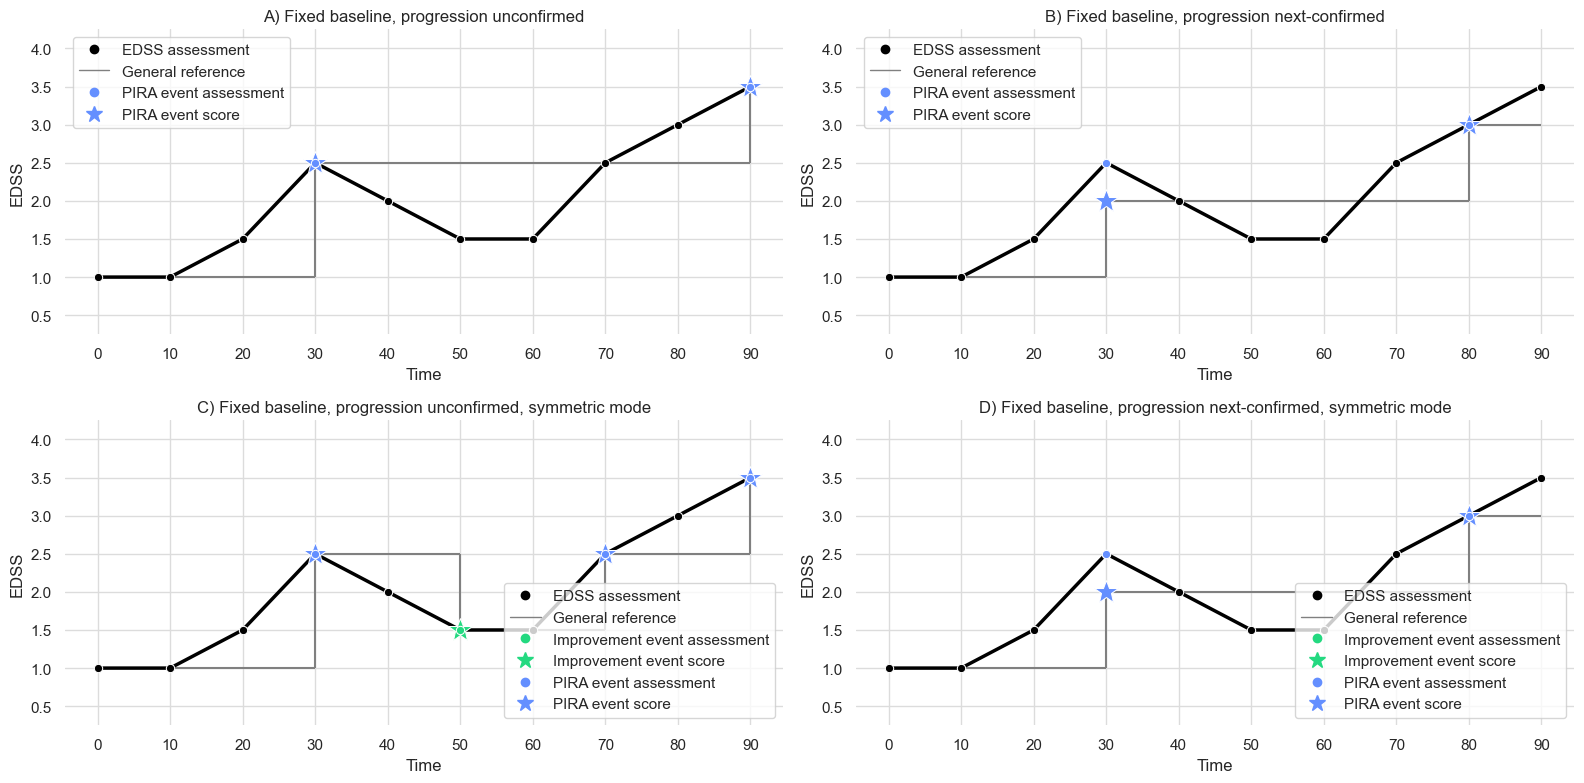

In [40]:
fig, axes = plt.subplots(2, 2, figsize=(16, 8))
example_follow_up = pd.DataFrame(
    {
        "days_after_baseline": [0, 10, 20, 30, 40, 50, 60, 70, 80, 90],
        "edss_score": [1, 1, 1.5, 2.5, 2.0, 1.5, 1.5, 2.5, 3.0, 3.5],
    }
)

# Accrual
for i, baseline_setting in enumerate(
    [
        (False, 0, "A) Fixed baseline, progression unconfirmed"),
        (True, 0.5, "B) Fixed baseline, progression next-confirmed"),
    ]
):
    visualization.annotate_plot_follow_up(
        follow_up_dataframe=example_follow_up,
        annotation_mode=ACCRUAL_MODE_NAME,
        opt_baseline_type="fixed",
        opt_roving_reference_require_confirmation=False,
        opt_require_confirmation=baseline_setting[0],
        opt_confirmation_time=baseline_setting[1],
        show_legend=True,
        move_legend_out=False,
        ax=axes[0][i],
    )
    axes[0][i].set_title(baseline_setting[2])

# Symmetric
for i, baseline_setting in enumerate(
    [
        (False, 0, "C) Fixed baseline, progression unconfirmed, symmetric mode"),
        (True, 0.5, "D) Fixed baseline, progression next-confirmed, symmetric mode"),
    ]
):
    visualization.annotate_plot_follow_up(
        follow_up_dataframe=example_follow_up,
        annotation_mode=SYMMETRIC_MODE_NAME,
        opt_baseline_type="fixed",
        opt_roving_reference_require_confirmation=False,
        opt_require_confirmation=baseline_setting[0],
        opt_confirmation_time=baseline_setting[1],
        show_legend=True,
        move_legend_out=False,
        ax=axes[1][i],
    )
    axes[1][i].set_title(baseline_setting[2])

fig.tight_layout()
sns.despine(bottom=True, left=True, right=True, top=True)
plt.show()

**Legend**: Post-event re-baselining. After a disability accrual or improvement event, the reference is reset to the confirmed event
score. **A)** No confirmation requirement, thus the event score of the PIRA event at day 30 is 2.5. **B)** The event
must be confirmed at the next assessment, thus the confirmed event score is 2.0. **C)** Symmetric mode, no confirmation requirement.
**D)** Symmetric mode, confirmation at the next assessment required.

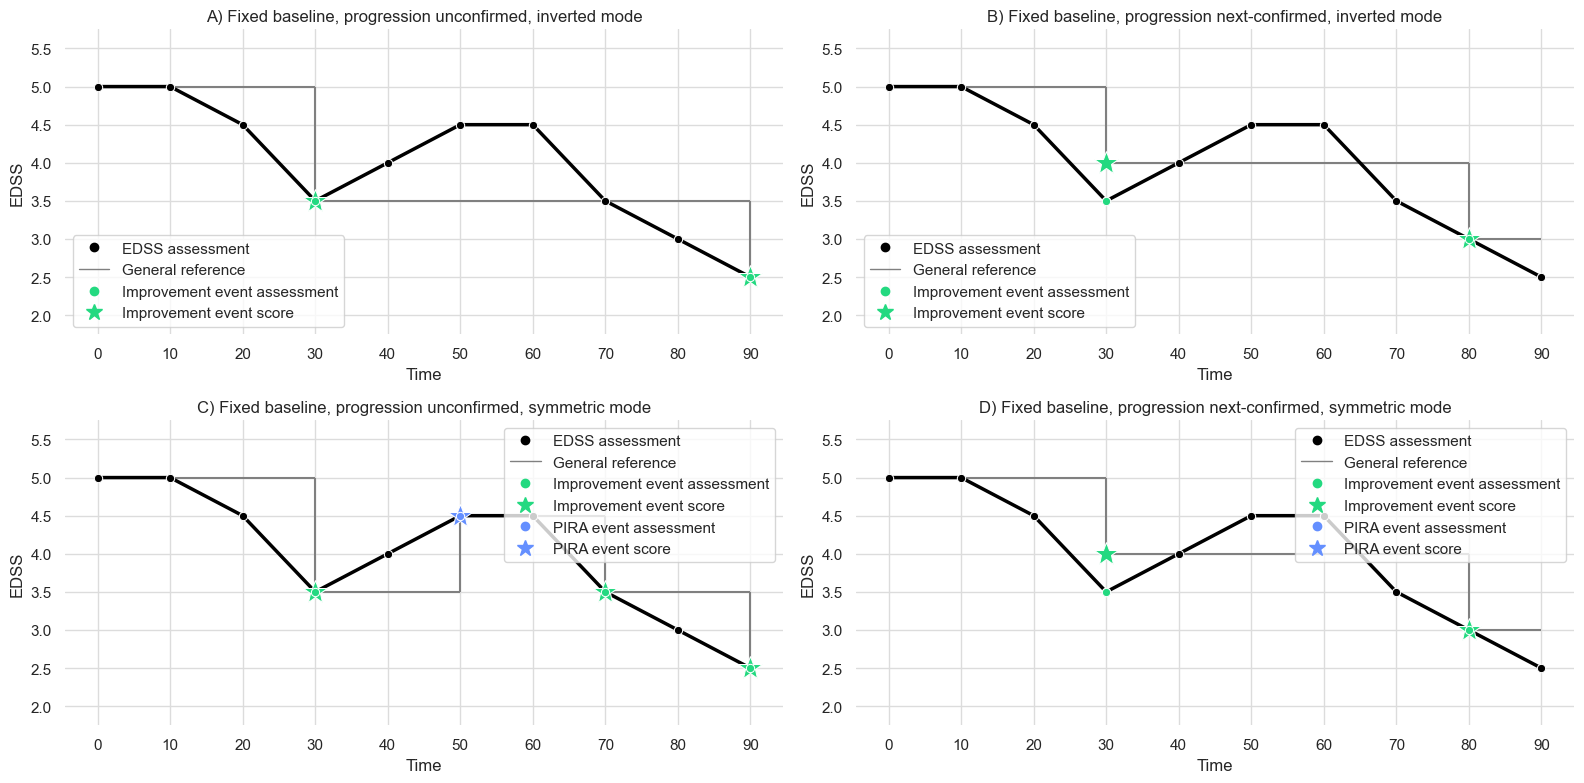

In [41]:
fig, axes = plt.subplots(2, 2, figsize=(16, 8))
example_follow_up = pd.DataFrame(
    {
        "days_after_baseline": [0, 10, 20, 30, 40, 50, 60, 70, 80, 90],
        "edss_score": [1, 1, 1.5, 2.5, 2.0, 1.5, 1.5, 2.5, 3.0, 3.5],
    }
)
example_follow_up["edss_score"] = 6.0 - example_follow_up["edss_score"]

# Improvement
for i, baseline_setting in enumerate(
    [
        (False, 0, "A) Fixed baseline, progression unconfirmed, inverted mode"),
        (True, 0.5, "B) Fixed baseline, progression next-confirmed, inverted mode"),
    ]
):
    visualization.annotate_plot_follow_up(
        follow_up_dataframe=example_follow_up,
        annotation_mode=IMPROVEMENT_MODE_NAME,
        opt_baseline_type="fixed",
        opt_roving_reference_require_confirmation=False,
        opt_require_confirmation=baseline_setting[0],
        opt_confirmation_time=baseline_setting[1],
        show_legend=True,
        move_legend_out=False,
        ax=axes[0][i],
    )
    axes[0][i].set_title(baseline_setting[2])

# Symmetric
for i, baseline_setting in enumerate(
    [
        (False, 0, "C) Fixed baseline, progression unconfirmed, symmetric mode"),
        (True, 0.5, "D) Fixed baseline, progression next-confirmed, symmetric mode"),
    ]
):
    visualization.annotate_plot_follow_up(
        follow_up_dataframe=example_follow_up,
        annotation_mode=SYMMETRIC_MODE_NAME,
        opt_baseline_type="fixed",
        opt_roving_reference_require_confirmation=False,
        opt_require_confirmation=baseline_setting[0],
        opt_confirmation_time=baseline_setting[1],
        show_legend=True,
        move_legend_out=False,
        ax=axes[1][i],
    )
    axes[1][i].set_title(baseline_setting[2])

fig.tight_layout()
sns.despine(bottom=True, left=True, right=True, top=True)
plt.show()

**Legend**: Post-event re-baselining. After a disability accrual or improvement event, the reference is reset to the confirmed event
score. **A)** No confirmation requirement, thus the event score of the Improvement event at day 30 is 3.5. **B)** The event
must be confirmed at the next assessment, thus the confirmed event score is 4.0. **C)** Symmetric mode, no confirmation requirement.
**D)** Symmetric mode, confirmation at the next assessment required.

## With roving reference
Only for accrual/improvement modes.

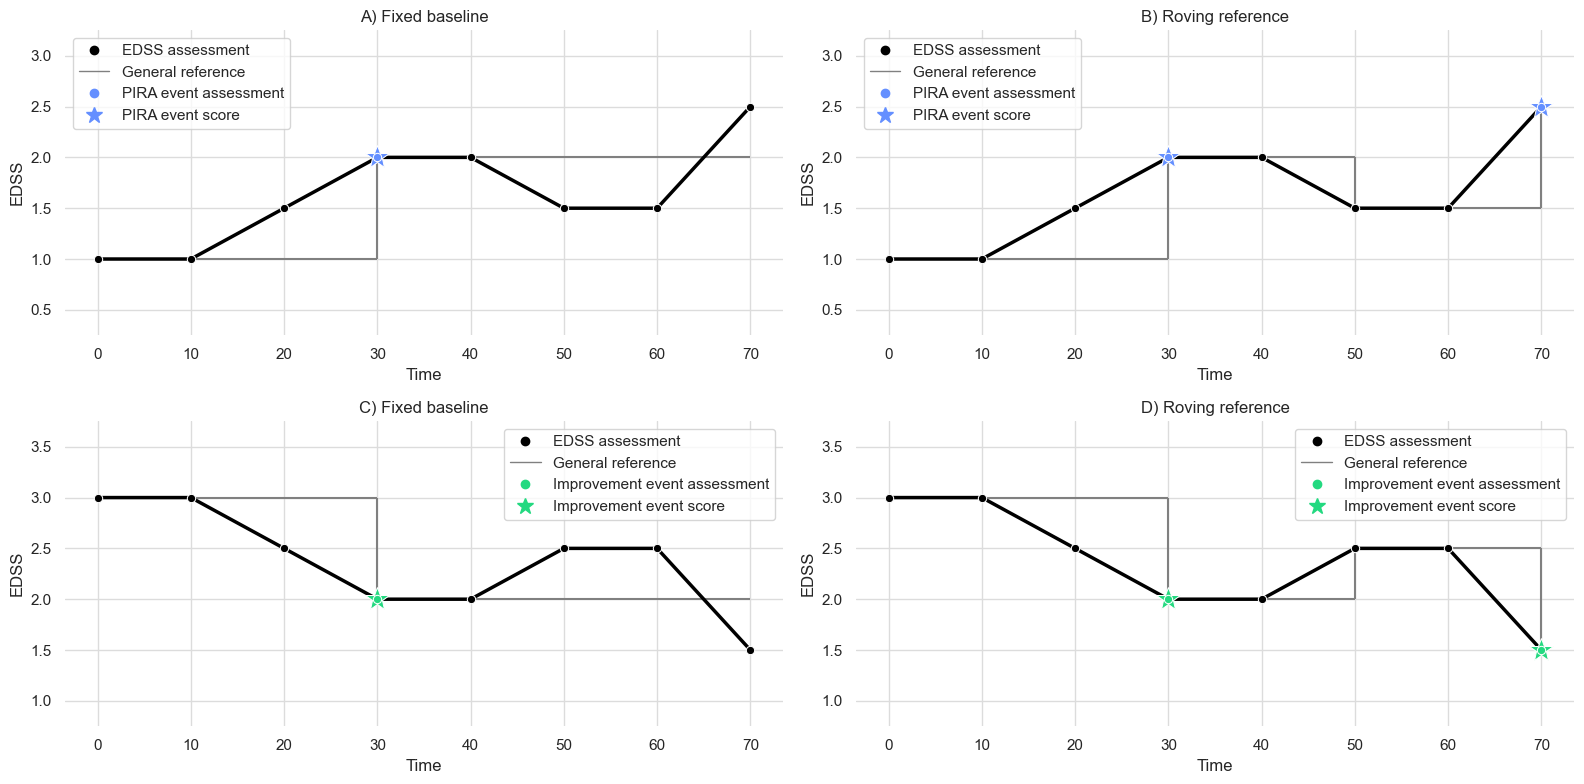

In [42]:
fig, axes = plt.subplots(2, 2, figsize=(16, 8))
example_follow_up = pd.DataFrame(
    {
        "days_after_baseline": [0, 10, 20, 30, 40, 50, 60, 70],
        "edss_score": [1, 1, 1.5, 2.0, 2.0, 1.5, 1.5, 2.5],
    }
)
for i, baseline_setting in enumerate(
    [
        ("fixed", "A) Fixed baseline"),
        ("roving", "B) Roving reference"),
    ]
):
    visualization.annotate_plot_follow_up(
        follow_up_dataframe=example_follow_up,
        annotation_mode=ACCRUAL_MODE_NAME,
        opt_baseline_type=baseline_setting[0],
        opt_roving_reference_require_confirmation=False,
        show_legend=True,
        move_legend_out=False,
        ax=axes[0][i],
    )
    axes[0][i].set_title(baseline_setting[1])

# Improvement mode
example_follow_up["edss_score"] = 4.0 - example_follow_up["edss_score"]
for i, baseline_setting in enumerate(
    [
        ("fixed", "C) Fixed baseline"),
        ("roving", "D) Roving reference"),
    ]
):
    visualization.annotate_plot_follow_up(
        follow_up_dataframe=example_follow_up,
        annotation_mode=IMPROVEMENT_MODE_NAME,
        opt_baseline_type=baseline_setting[0],
        opt_roving_reference_require_confirmation=False,
        show_legend=True,
        move_legend_out=False,
        ax=axes[1][i],
    )
    axes[1][i].set_title(baseline_setting[1])

fig.tight_layout()
sns.despine(bottom=True, left=True, right=True, top=True)
plt.show()

**Legend**: Post-event re-baselining. **A)** Fixed baseline. The post-event reference stays at the confirmed event
score 2.0. **B)** Roving reference. The score at step 50 qualifies as a new roving reference, thus the reference for
subsequent event candidates is 1.5. **C)** Fixed baseline. The post-event reference stays at the confirmed event
score 2.0. **D)** Roving reference. The score at step 50 qualifies as a new roving reference, thus the reference for
subsequent event candidates is 2.5. Minimal increase/decrease + 1.0, next-confirmed roving reference, no confirmation for
events required.

### Minimal distance and backtracking

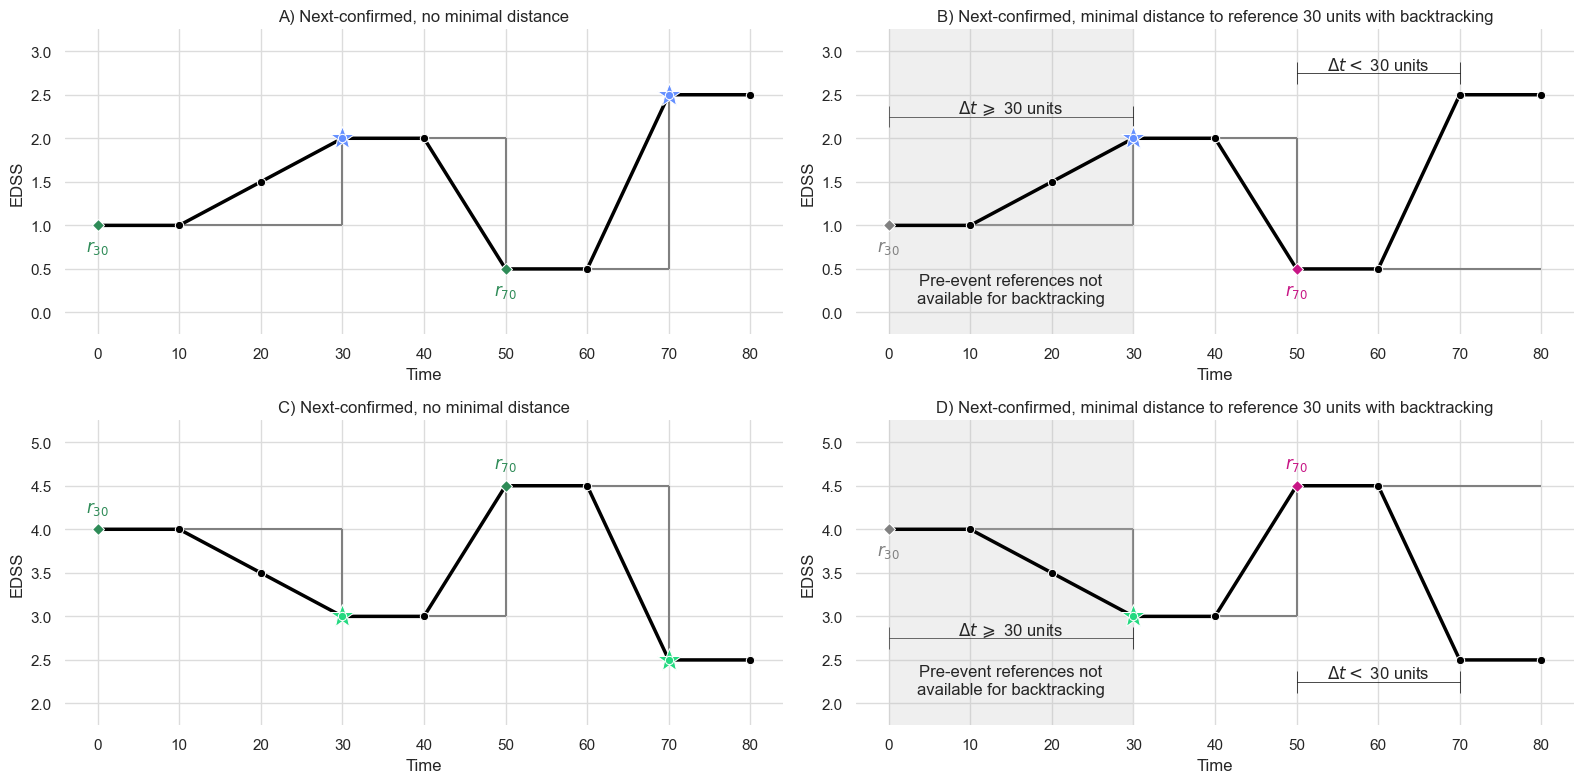

In [50]:
fig, axes = plt.subplots(2, 2, figsize=(16, 8))
example_follow_up = pd.DataFrame(
    {
        "days_after_baseline": [0, 10, 20, 30, 40, 50, 60, 70, 80],
        "edss_score": [1, 1, 1.5, 2.0, 2.0, 0.5, 0.5, 2.5, 2.5],
    }
)
for i, baseline_setting in enumerate(
    [
        (0, "A) Next-confirmed, no minimal distance"),
        (
            30,
            "B) Next-confirmed, minimal distance to reference 30 units with backtracking",
        ),
    ]
):
    visualization.annotate_plot_follow_up(
        follow_up_dataframe=example_follow_up,
        annotation_mode=ACCRUAL_MODE_NAME,
        opt_baseline_type="roving",
        opt_roving_reference_require_confirmation=False,
        opt_require_confirmation=True,
        opt_confirmation_time=0.5,
        opt_minimal_distance_type="reference",
        opt_minimal_distance_time=baseline_setting[0],
        opt_minimal_distance_backtrack_decrease=True,
        show_legend=False,
        move_legend_out=False,
        ax=axes[0][i],
    )
    axes[0][i].set_title(baseline_setting[1])

axes[0][0].text(
    x=0,
    y=0.75,
    s=r"$r_{30}$",
    horizontalalignment="center",
    verticalalignment="center",
    color="seagreen",
)
axes[0][0].text(
    x=50,
    y=0.25,
    s=r"$r_{70}$",
    horizontalalignment="center",
    verticalalignment="center",
    color="seagreen",
)
sns.lineplot(
    data=example_follow_up.query(
        "days_after_baseline == 0 or days_after_baseline == 50"
    ),
    x="days_after_baseline",
    y="edss_score",
    color="seagreen",
    marker="D",
    legend=False,
    linewidth=0,
    zorder=50,
    ax=axes[0][0],
)

axes[0][1].hlines(y=2.25, xmin=0, xmax=30, linewidth=0.5, color="black")
axes[0][1].vlines(x=0, ymin=2.125, ymax=2.375, linewidth=0.5, color="black")
axes[0][1].vlines(x=30, ymin=2.125, ymax=2.375, linewidth=0.5, color="black")
axes[0][1].text(
    x=15,
    y=2.45,
    s=r"$\Delta t\, \geqslant$ 30 units",
    horizontalalignment="center",
    verticalalignment="top",
)

axes[0][1].hlines(y=2.75, xmin=50, xmax=70, linewidth=0.5, color="black")
axes[0][1].vlines(x=50, ymin=2.625, ymax=2.875, linewidth=0.5, color="black")
axes[0][1].vlines(x=70, ymin=2.625, ymax=2.875, linewidth=0.5, color="black")
axes[0][1].text(
    x=60,
    y=2.95,
    s=r"$\Delta t <$ 30 units",
    horizontalalignment="center",
    verticalalignment="top",
)

axes[0][1].text(
    x=0,
    y=0.75,
    s=r"$r_{30}$",
    horizontalalignment="center",
    verticalalignment="center",
    color="grey",
)
axes[0][1].text(
    x=50,
    y=0.25,
    s=r"$r_{70}$",
    horizontalalignment="center",
    verticalalignment="center",
    color="mediumvioletred",
    zorder=51,
)
sns.lineplot(
    data=example_follow_up.query("days_after_baseline == 0"),
    x="days_after_baseline",
    y="edss_score",
    color="grey",
    marker="D",
    legend=False,
    linewidth=0,
    zorder=50,
    ax=axes[0][1],
)
sns.lineplot(
    data=example_follow_up.query("days_after_baseline == 50"),
    x="days_after_baseline",
    y="edss_score",
    color="mediumvioletred",
    marker="D",
    legend=False,
    linewidth=0,
    zorder=50,
    ax=axes[0][1],
)
axes[0][1].axvspan(
    0,
    30,
    ymin=0.0,
    ymax=3.0,
    linewidth=0,
    alpha=0.25,
    color="silver",
    zorder=2,
)
axes[0][1].text(
    x=15,
    y=0.45,
    s="Pre-event references not\navailable for backtracking",
    horizontalalignment="center",
    verticalalignment="top",
)


# Experimental inverted mode
example_follow_up["edss_score"] = 5.0 - example_follow_up["edss_score"]
for i, baseline_setting in enumerate(
    [
        (0, "C) Next-confirmed, no minimal distance"),
        (
            30,
            "D) Next-confirmed, minimal distance to reference 30 units with backtracking",
        ),
    ]
):
    visualization.annotate_plot_follow_up(
        follow_up_dataframe=example_follow_up,
        annotation_mode=IMPROVEMENT_MODE_NAME,
        opt_baseline_type="roving",
        opt_roving_reference_require_confirmation=False,
        opt_require_confirmation=True,
        opt_confirmation_time=0.5,
        opt_minimal_distance_type="reference",
        opt_minimal_distance_time=baseline_setting[0],
        opt_minimal_distance_backtrack_decrease=True,
        show_legend=False,
        move_legend_out=False,
        ax=axes[1][i],
    )
    axes[1][i].set_title(baseline_setting[1])

axes[1][0].text(
    x=0,
    y=4.25,
    s=r"$r_{30}$",
    horizontalalignment="center",
    verticalalignment="center",
    color="seagreen",
)
axes[1][0].text(
    x=50,
    y=4.75,
    s=r"$r_{70}$",
    horizontalalignment="center",
    verticalalignment="center",
    color="seagreen",
)
sns.lineplot(
    data=example_follow_up.query(
        "days_after_baseline == 0 or days_after_baseline == 50"
    ),
    x="days_after_baseline",
    y="edss_score",
    color="seagreen",
    marker="D",
    legend=False,
    linewidth=0,
    zorder=50,
    ax=axes[1][0],
)

axes[1][1].hlines(y=2.75, xmin=0, xmax=30, linewidth=0.5, color="black")
axes[1][1].vlines(x=0, ymin=2.625, ymax=2.875, linewidth=0.5, color="black")
axes[1][1].vlines(x=30, ymin=2.625, ymax=2.875, linewidth=0.5, color="black")
axes[1][1].text(
    x=15,
    y=2.95,
    s=r"$\Delta t\, \geqslant$ 30 units",
    horizontalalignment="center",
    verticalalignment="top",
)

axes[1][1].hlines(y=2.25, xmin=50, xmax=70, linewidth=0.5, color="black")
axes[1][1].vlines(x=50, ymin=2.125, ymax=2.375, linewidth=0.5, color="black")
axes[1][1].vlines(x=70, ymin=2.125, ymax=2.375, linewidth=0.5, color="black")
axes[1][1].text(
    x=60,
    y=2.45,
    s=r"$\Delta t <$ 30 units",
    horizontalalignment="center",
    verticalalignment="top",
)

axes[1][1].text(
    x=0,
    y=3.75,
    s=r"$r_{30}$",
    horizontalalignment="center",
    verticalalignment="center",
    color="grey",
)
axes[1][1].text(
    x=50,
    y=4.75,
    s=r"$r_{70}$",
    horizontalalignment="center",
    verticalalignment="center",
    color="mediumvioletred",
    zorder=51,
)
sns.lineplot(
    data=example_follow_up.query("days_after_baseline == 0"),
    x="days_after_baseline",
    y="edss_score",
    color="grey",
    marker="D",
    legend=False,
    linewidth=0,
    zorder=50,
    ax=axes[1][1],
)
sns.lineplot(
    data=example_follow_up.query("days_after_baseline == 50"),
    x="days_after_baseline",
    y="edss_score",
    color="mediumvioletred",
    marker="D",
    legend=False,
    linewidth=0,
    zorder=50,
    ax=axes[1][1],
)
axes[1][1].axvspan(
    0,
    30,
    ymin=0.0,
    ymax=3.0,
    linewidth=0,
    alpha=0.25,
    color="silver",
    zorder=2,
)
axes[1][1].text(
    x=15,
    y=2.45,
    s="Pre-event references not\navailable for backtracking",
    horizontalalignment="center",
    verticalalignment="top",
)


fig.tight_layout()
sns.despine(bottom=True, left=True, right=True, top=True)
plt.show()

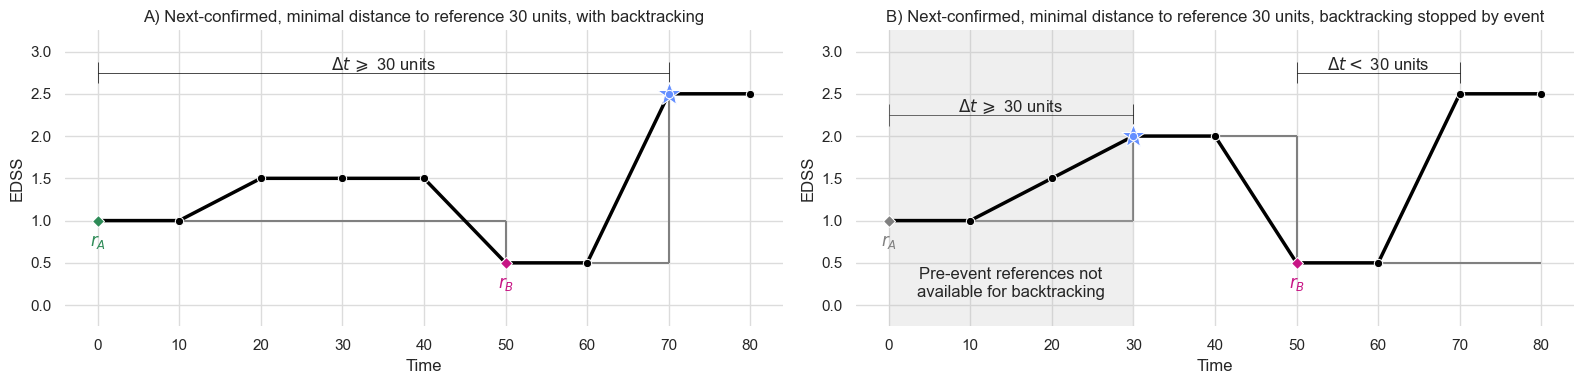

In [45]:
fig, axes = plt.subplots(1, 2, figsize=(16, 4))
example_follow_ups = [
    pd.DataFrame(
        {
            "days_after_baseline": [0, 10, 20, 30, 40, 50, 60, 70, 80],
            "edss_score": [1, 1, 1.5, 1.5, 1.5, 0.5, 0.5, 2.5, 2.5],
        }
    ),
    pd.DataFrame(
        {
            "days_after_baseline": [0, 10, 20, 30, 40, 50, 60, 70, 80],
            "edss_score": [1, 1, 1.5, 2.0, 2.0, 0.5, 0.5, 2.5, 2.5],
        }
    ),
]
for i, baseline_setting in enumerate(
    [
        "A) Next-confirmed, minimal distance to reference 30 units, with backtracking",
        "B) Next-confirmed, minimal distance to reference 30 units, backtracking stopped by event",
    ]
):
    visualization.annotate_plot_follow_up(
        follow_up_dataframe=example_follow_ups[i],
        annotation_mode=ACCRUAL_MODE_NAME,
        opt_baseline_type="roving",
        opt_roving_reference_require_confirmation=False,
        opt_require_confirmation=True,
        opt_confirmation_time=0.5,
        opt_minimal_distance_type="reference",
        opt_minimal_distance_time=30,
        opt_minimal_distance_backtrack_decrease=True,
        show_legend=False,
        move_legend_out=False,
        ax=axes[i],
    )
    axes[i].set_title(baseline_setting)

axes[0].hlines(y=2.75, xmin=0, xmax=70, linewidth=0.5, color="black")
axes[0].vlines(x=0, ymin=2.625, ymax=2.875, linewidth=0.5, color="black")
axes[0].vlines(x=70, ymin=2.625, ymax=2.875, linewidth=0.5, color="black")
axes[0].text(
    x=35,
    y=2.95,
    s=r"$\Delta t\, \geqslant$ 30 units",
    horizontalalignment="center",
    verticalalignment="top",
)
axes[0].text(
    x=0,
    y=0.75,
    s=r"$r_{A}$",
    horizontalalignment="center",
    verticalalignment="center",
    color="seagreen",
)
axes[0].text(
    x=50,
    y=0.25,
    s=r"$r_{B}$",
    horizontalalignment="center",
    verticalalignment="center",
    color="mediumvioletred",
)
sns.lineplot(
    data=example_follow_ups[0].query("days_after_baseline == 0"),
    x="days_after_baseline",
    y="edss_score",
    color="seagreen",
    marker="D",
    legend=False,
    linewidth=0,
    zorder=50,
    ax=axes[0],
)
sns.lineplot(
    data=example_follow_ups[0].query("days_after_baseline == 50"),
    x="days_after_baseline",
    y="edss_score",
    color="mediumvioletred",
    marker="D",
    legend=False,
    linewidth=0,
    zorder=50,
    ax=axes[0],
)

axes[1].hlines(y=2.25, xmin=0, xmax=30, linewidth=0.5, color="black")
axes[1].vlines(x=0, ymin=2.125, ymax=2.375, linewidth=0.5, color="black")
axes[1].vlines(x=30, ymin=2.125, ymax=2.375, linewidth=0.5, color="black")
axes[1].text(
    x=15,
    y=2.45,
    s=r"$\Delta t\, \geqslant$ 30 units",
    horizontalalignment="center",
    verticalalignment="top",
)

axes[1].hlines(y=2.75, xmin=50, xmax=70, linewidth=0.5, color="black")
axes[1].vlines(x=50, ymin=2.625, ymax=2.875, linewidth=0.5, color="black")
axes[1].vlines(x=70, ymin=2.625, ymax=2.875, linewidth=0.5, color="black")
axes[1].text(
    x=60,
    y=2.95,
    s=r"$\Delta t <$ 30 units",
    horizontalalignment="center",
    verticalalignment="top",
)

axes[1].text(
    x=0,
    y=0.75,
    s=r"$r_{A}$",
    horizontalalignment="center",
    verticalalignment="center",
    color="grey",
)
axes[1].text(
    x=50,
    y=0.25,
    s=r"$r_{B}$",
    horizontalalignment="center",
    verticalalignment="center",
    color="mediumvioletred",
    zorder=51,
)
sns.lineplot(
    data=example_follow_ups[1].query("days_after_baseline == 0"),
    x="days_after_baseline",
    y="edss_score",
    color="grey",
    marker="D",
    legend=False,
    linewidth=0,
    zorder=50,
    ax=axes[1],
)
sns.lineplot(
    data=example_follow_ups[1].query("days_after_baseline == 50"),
    x="days_after_baseline",
    y="edss_score",
    color="mediumvioletred",
    marker="D",
    legend=False,
    linewidth=0,
    zorder=50,
    ax=axes[1],
)
axes[1].axvspan(
    0,
    30,
    ymin=0.0,
    ymax=3.0,
    linewidth=0,
    alpha=0.25,
    color="silver",
    zorder=2,
)
axes[1].text(
    x=15,
    y=0.45,
    s="Pre-event references not\navailable for backtracking",
    horizontalalignment="center",
    verticalalignment="top",
)

fig.tight_layout()
sns.despine(bottom=True, left=True, right=True, top=True)
plt.show()

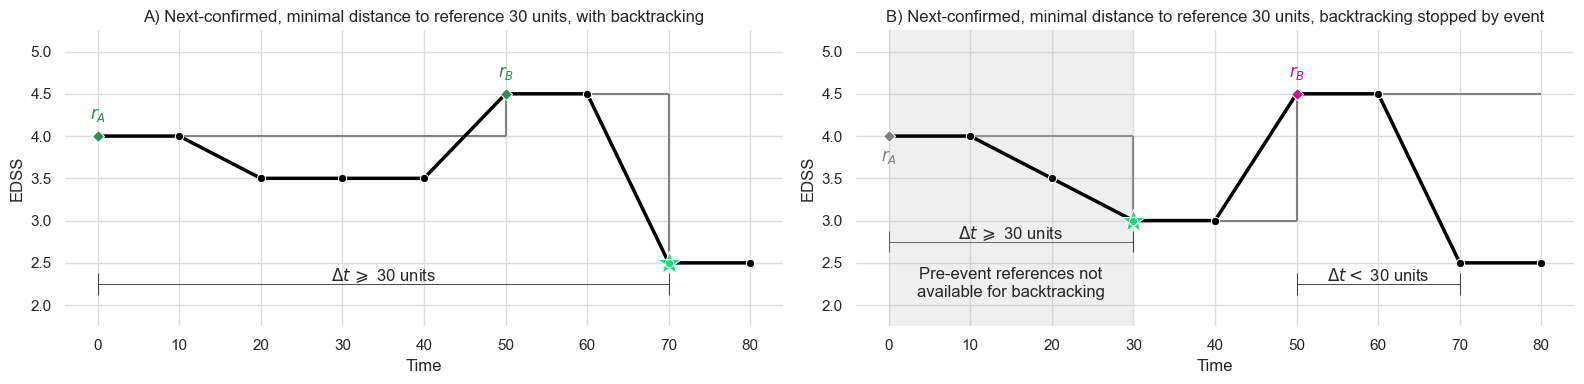

In [47]:
fig, axes = plt.subplots(1, 2, figsize=(16, 4))
example_follow_ups = [
    pd.DataFrame(
        {
            "days_after_baseline": [0, 10, 20, 30, 40, 50, 60, 70, 80],
            "edss_score": [1, 1, 1.5, 1.5, 1.5, 0.5, 0.5, 2.5, 2.5],
        }
    ),
    pd.DataFrame(
        {
            "days_after_baseline": [0, 10, 20, 30, 40, 50, 60, 70, 80],
            "edss_score": [1, 1, 1.5, 2.0, 2.0, 0.5, 0.5, 2.5, 2.5],
        }
    ),
]

# Experimental inverted mode
for example_follow_up in example_follow_ups:
    example_follow_up["edss_score"] = 5.0 - example_follow_up["edss_score"]
for i, baseline_setting in enumerate(
    [
        "A) Next-confirmed, minimal distance to reference 30 units, with backtracking",
        "B) Next-confirmed, minimal distance to reference 30 units, backtracking stopped by event",
    ]
):
    visualization.annotate_plot_follow_up(
        follow_up_dataframe=example_follow_ups[i],
        annotation_mode=IMPROVEMENT_MODE_NAME,
        opt_baseline_type="roving",
        opt_roving_reference_require_confirmation=False,
        opt_require_confirmation=True,
        opt_confirmation_time=0.5,
        opt_minimal_distance_type="reference",
        opt_minimal_distance_time=30,
        opt_minimal_distance_backtrack_decrease=True,
        show_legend=False,
        move_legend_out=False,
        ax=axes[i],
    )
    axes[i].set_title(baseline_setting)

axes[0].hlines(y=2.25, xmin=0, xmax=70, linewidth=0.5, color="black")
axes[0].vlines(x=0, ymin=2.125, ymax=2.375, linewidth=0.5, color="black")
axes[0].vlines(x=70, ymin=2.125, ymax=2.375, linewidth=0.5, color="black")
axes[0].text(
    x=35,
    y=2.45,
    s=r"$\Delta t\, \geqslant$ 30 units",
    horizontalalignment="center",
    verticalalignment="top",
)

axes[0].text(
    x=0,
    y=4.25,
    s=r"$r_{A}$",
    horizontalalignment="center",
    verticalalignment="center",
    color="seagreen",
)
axes[0].text(
    x=50,
    y=4.75,
    s=r"$r_{B}$",
    horizontalalignment="center",
    verticalalignment="center",
    color="seagreen",
)
sns.lineplot(
    data=example_follow_ups[0].query(
        "days_after_baseline == 0 or days_after_baseline == 50"
    ),
    x="days_after_baseline",
    y="edss_score",
    color="seagreen",
    marker="D",
    legend=False,
    linewidth=0,
    zorder=50,
    ax=axes[0],
)

axes[1].hlines(y=2.75, xmin=0, xmax=30, linewidth=0.5, color="black")
axes[1].vlines(x=0, ymin=2.625, ymax=2.875, linewidth=0.5, color="black")
axes[1].vlines(x=30, ymin=2.625, ymax=2.875, linewidth=0.5, color="black")
axes[1].text(
    x=15,
    y=2.95,
    s=r"$\Delta t\, \geqslant$ 30 units",
    horizontalalignment="center",
    verticalalignment="top",
)

axes[1].hlines(y=2.25, xmin=50, xmax=70, linewidth=0.5, color="black")
axes[1].vlines(x=50, ymin=2.125, ymax=2.375, linewidth=0.5, color="black")
axes[1].vlines(x=70, ymin=2.125, ymax=2.375, linewidth=0.5, color="black")
axes[1].text(
    x=60,
    y=2.45,
    s=r"$\Delta t <$ 30 units",
    horizontalalignment="center",
    verticalalignment="top",
)

axes[1].text(
    x=0,
    y=3.75,
    s=r"$r_{A}$",
    horizontalalignment="center",
    verticalalignment="center",
    color="grey",
)
axes[1].text(
    x=50,
    y=4.75,
    s=r"$r_{B}$",
    horizontalalignment="center",
    verticalalignment="center",
    color="mediumvioletred",
    zorder=51,
)
sns.lineplot(
    data=example_follow_ups[1].query("days_after_baseline == 0"),
    x="days_after_baseline",
    y="edss_score",
    color="grey",
    marker="D",
    legend=False,
    linewidth=0,
    zorder=50,
    ax=axes[1],
)
sns.lineplot(
    data=example_follow_ups[1].query("days_after_baseline == 50"),
    x="days_after_baseline",
    y="edss_score",
    color="mediumvioletred",
    marker="D",
    legend=False,
    linewidth=0,
    zorder=50,
    ax=axes[1],
)
axes[1].axvspan(
    0,
    30,
    ymin=0.0,
    ymax=3.0,
    linewidth=0,
    alpha=0.25,
    color="silver",
    zorder=2,
)
axes[1].text(
    x=15,
    y=2.45,
    s="Pre-event references not\navailable for backtracking",
    horizontalalignment="center",
    verticalalignment="top",
)

fig.tight_layout()
sns.despine(bottom=True, left=True, right=True, top=True)
plt.show()

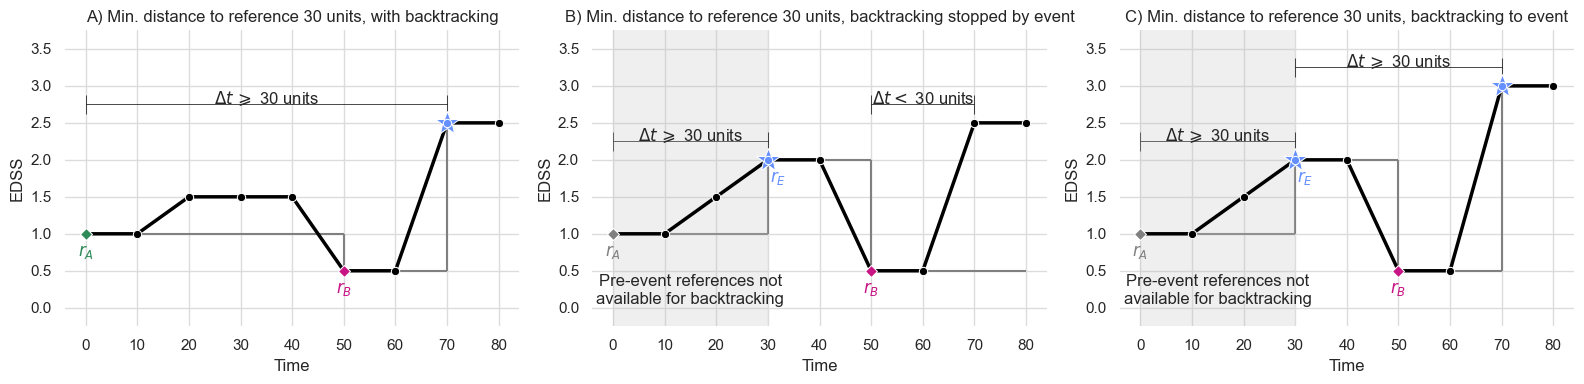

In [49]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
example_follow_ups = [
    pd.DataFrame(
        {
            "days_after_baseline": [0, 10, 20, 30, 40, 50, 60, 70, 80],
            "edss_score": [1, 1, 1.5, 1.5, 1.5, 0.5, 0.5, 2.5, 2.5],
        }
    ),
    pd.DataFrame(
        {
            "days_after_baseline": [0, 10, 20, 30, 40, 50, 60, 70, 80],
            "edss_score": [1, 1, 1.5, 2.0, 2.0, 0.5, 0.5, 2.5, 2.5],
        }
    ),
    pd.DataFrame(
        {
            "days_after_baseline": [0, 10, 20, 30, 40, 50, 60, 70, 80],
            "edss_score": [1, 1, 1.5, 2.0, 2.0, 0.5, 0.5, 3.0, 3.0],
        }
    ),
]
for i, baseline_setting in enumerate(
    [
        "A) Min. distance to reference 30 units, with backtracking",
        "B) Min. distance to reference 30 units, backtracking stopped by event",
        "C) Min. distance to reference 30 units, backtracking to event",
    ]
):
    visualization.annotate_plot_follow_up(
        follow_up_dataframe=example_follow_ups[i],
        annotation_mode=ACCRUAL_MODE_NAME,
        opt_baseline_type="roving",
        opt_roving_reference_require_confirmation=False,
        opt_require_confirmation=True,
        opt_confirmation_time=0.5,
        opt_minimal_distance_type="reference",
        opt_minimal_distance_time=30,
        opt_minimal_distance_backtrack_decrease=True,
        show_legend=False,
        move_legend_out=False,
        ax=axes[i],
    )
    axes[i].set_title(baseline_setting)
    axes[i].set_ylim((-0.25, 3.75))
    axes[i].set_yticks([0.0, 0.5, 1.0, 1.5, 2.0, 2.5, 3.0, 3.5])

axes[0].hlines(y=2.75, xmin=0, xmax=70, linewidth=0.5, color="black")
axes[0].vlines(x=0, ymin=2.625, ymax=2.875, linewidth=0.5, color="black")
axes[0].vlines(x=70, ymin=2.625, ymax=2.875, linewidth=0.5, color="black")
axes[0].text(
    x=35,
    y=2.95,
    s=r"$\Delta t\, \geqslant$ 30 units",
    horizontalalignment="center",
    verticalalignment="top",
)
axes[0].text(
    x=0,
    y=0.75,
    s=r"$r_{A}$",
    horizontalalignment="center",
    verticalalignment="center",
    color="seagreen",
)
axes[0].text(
    x=50,
    y=0.25,
    s=r"$r_{B}$",
    horizontalalignment="center",
    verticalalignment="center",
    color="mediumvioletred",
)
sns.lineplot(
    data=example_follow_ups[0].query("days_after_baseline == 0"),
    x="days_after_baseline",
    y="edss_score",
    color="seagreen",
    marker="D",
    legend=False,
    linewidth=0,
    zorder=50,
    ax=axes[0],
)
sns.lineplot(
    data=example_follow_ups[0].query("days_after_baseline == 50"),
    x="days_after_baseline",
    y="edss_score",
    color="mediumvioletred",
    marker="D",
    legend=False,
    linewidth=0,
    zorder=50,
    ax=axes[0],
)

axes[1].hlines(y=2.25, xmin=0, xmax=30, linewidth=0.5, color="black")
axes[1].vlines(x=0, ymin=2.125, ymax=2.375, linewidth=0.5, color="black")
axes[1].vlines(x=30, ymin=2.125, ymax=2.375, linewidth=0.5, color="black")
axes[1].text(
    x=15,
    y=2.45,
    s=r"$\Delta t\, \geqslant$ 30 units",
    horizontalalignment="center",
    verticalalignment="top",
)

axes[1].hlines(y=2.75, xmin=50, xmax=70, linewidth=0.5, color="black")
axes[1].vlines(x=50, ymin=2.625, ymax=2.875, linewidth=0.5, color="black")
axes[1].vlines(x=70, ymin=2.625, ymax=2.875, linewidth=0.5, color="black")
axes[1].text(
    x=60,
    y=2.95,
    s=r"$\Delta t <$ 30 units",
    horizontalalignment="center",
    verticalalignment="top",
)

axes[1].text(
    x=0,
    y=0.75,
    s=r"$r_{A}$",
    horizontalalignment="center",
    verticalalignment="center",
    color="grey",
)
axes[1].text(
    x=32,
    y=1.75,
    s=r"$r_{E}$",
    horizontalalignment="center",
    verticalalignment="center",
    color="#648FFF",
    zorder=51,
)
axes[1].text(
    x=50,
    y=0.25,
    s=r"$r_{B}$",
    horizontalalignment="center",
    verticalalignment="center",
    color="mediumvioletred",
    zorder=51,
)
sns.lineplot(
    data=example_follow_ups[1].query("days_after_baseline == 0"),
    x="days_after_baseline",
    y="edss_score",
    color="grey",
    marker="D",
    legend=False,
    linewidth=0,
    zorder=50,
    ax=axes[1],
)
sns.lineplot(
    data=example_follow_ups[1].query("days_after_baseline == 50"),
    x="days_after_baseline",
    y="edss_score",
    color="mediumvioletred",
    marker="D",
    legend=False,
    linewidth=0,
    zorder=50,
    ax=axes[1],
)
axes[1].axvspan(
    0,
    30,
    ymin=0.0,
    ymax=3.0,
    linewidth=0,
    alpha=0.25,
    color="silver",
    zorder=2,
)
axes[1].text(
    x=15,
    y=0.45,
    s="Pre-event references not\navailable for backtracking",
    horizontalalignment="center",
    verticalalignment="top",
)

axes[2].hlines(y=2.25, xmin=0, xmax=30, linewidth=0.5, color="black")
axes[2].vlines(x=0, ymin=2.125, ymax=2.375, linewidth=0.5, color="black")
axes[2].vlines(x=30, ymin=2.125, ymax=2.375, linewidth=0.5, color="black")
axes[2].text(
    x=15,
    y=2.45,
    s=r"$\Delta t\, \geqslant$ 30 units",
    horizontalalignment="center",
    verticalalignment="top",
)

axes[2].hlines(y=3.25, xmin=30, xmax=70, linewidth=0.5, color="black")
axes[2].vlines(x=30, ymin=3.125, ymax=3.375, linewidth=0.5, color="black")
axes[2].vlines(x=70, ymin=3.125, ymax=3.375, linewidth=0.5, color="black")
axes[2].text(
    x=50,
    y=3.45,
    s=r"$\Delta t\, \geqslant$ 30 units",
    horizontalalignment="center",
    verticalalignment="top",
)

axes[2].text(
    x=0,
    y=0.75,
    s=r"$r_{A}$",
    horizontalalignment="center",
    verticalalignment="center",
    color="grey",
)
axes[2].text(
    x=32,
    y=1.75,
    s=r"$r_{E}$",
    horizontalalignment="center",
    verticalalignment="center",
    color="#648FFF",
    zorder=51,
)
axes[2].text(
    x=50,
    y=0.25,
    s=r"$r_{B}$",
    horizontalalignment="center",
    verticalalignment="center",
    color="mediumvioletred",
    zorder=51,
)
sns.lineplot(
    data=example_follow_ups[2].query("days_after_baseline == 0"),
    x="days_after_baseline",
    y="edss_score",
    color="grey",
    marker="D",
    legend=False,
    linewidth=0,
    zorder=50,
    ax=axes[2],
)
sns.lineplot(
    data=example_follow_ups[2].query("days_after_baseline == 50"),
    x="days_after_baseline",
    y="edss_score",
    color="mediumvioletred",
    marker="D",
    legend=False,
    linewidth=0,
    zorder=50,
    ax=axes[2],
)
axes[2].axvspan(
    0,
    30,
    ymin=0.0,
    ymax=3.0,
    linewidth=0,
    alpha=0.25,
    color="silver",
    zorder=2,
)
axes[2].text(
    x=15,
    y=0.45,
    s="Pre-event references not\navailable for backtracking",
    horizontalalignment="center",
    verticalalignment="top",
)

fig.tight_layout()
sns.despine(bottom=True, left=True, right=True, top=True)
plt.show()

**Legend**: Minimal distance to reference 30 units with backtracking, next-confirmed event, minimal increase over
reference + 1.0. **A)** The new reference r<sub>B</sub> at step 50 is too close to the increase at step 70, but backtracking allows
using the previous reference r<sub>A</sub>, thus the increase at step 70 qualifies as an event. **B)** The increase at step 30
qualifies as confirmed disability accrual with respect to the initial baseline r<sub>A</sub>, thus the baseline is set to the
confirmed event score 2.0. The references available for the increase at step 70 are r<sub>B</sub> and r<sub>E</sub> (the reference set at
the event), but r<sub>B</sub> is too close and r<sub>E</sub> is not low enough, thus the increase at step 70 does not qualify as an event.
**C)** The increase at step 30 qualifies as confirmed disability accrual with respect to the initial baseline r<sub>A</sub>, thus the
baseline is set to the confirmed event score 2.0. The references available for the increase at step 70 are r<sub>B</sub> and r<sub>E</sub>
(the reference set at the event). While r<sub>B</sub> is too close, r<sub>E</sub> satisfies the minimal distance condition and is low
enough, thus the increase at step 70 qualifies as an event.

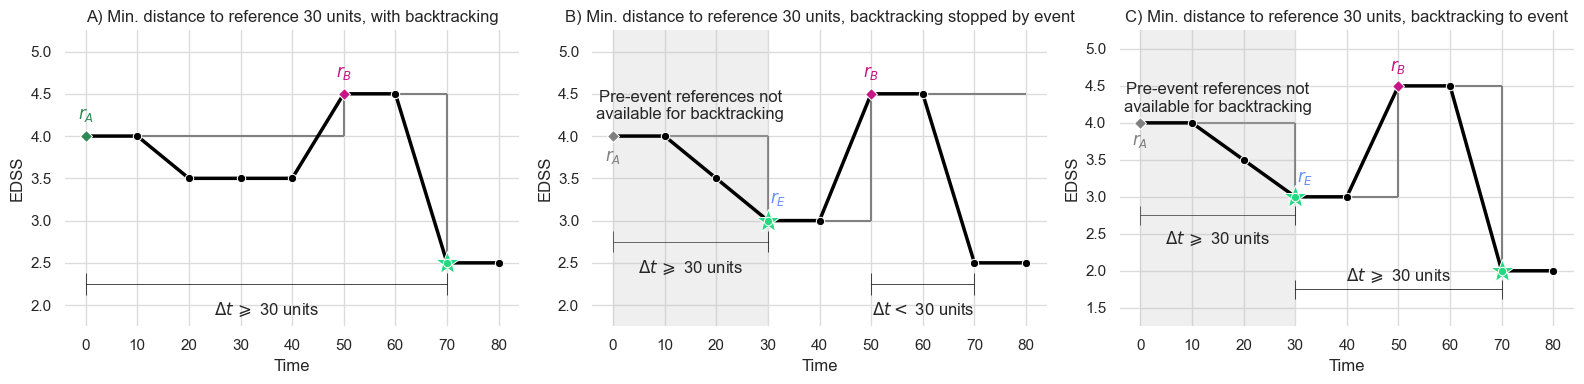

In [51]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
example_follow_ups = [
    pd.DataFrame(
        {
            "days_after_baseline": [0, 10, 20, 30, 40, 50, 60, 70, 80],
            "edss_score": [1, 1, 1.5, 1.5, 1.5, 0.5, 0.5, 2.5, 2.5],
        }
    ),
    pd.DataFrame(
        {
            "days_after_baseline": [0, 10, 20, 30, 40, 50, 60, 70, 80],
            "edss_score": [1, 1, 1.5, 2.0, 2.0, 0.5, 0.5, 2.5, 2.5],
        }
    ),
    pd.DataFrame(
        {
            "days_after_baseline": [0, 10, 20, 30, 40, 50, 60, 70, 80],
            "edss_score": [1, 1, 1.5, 2.0, 2.0, 0.5, 0.5, 3.0, 3.0],
        }
    ),
]

# Improvement mode
for example_follow_up in example_follow_ups:
    example_follow_up["edss_score"] = 5.0 - example_follow_up["edss_score"]

for i, baseline_setting in enumerate(
    [
        "A) Min. distance to reference 30 units, with backtracking",
        "B) Min. distance to reference 30 units, backtracking stopped by event",
        "C) Min. distance to reference 30 units, backtracking to event",
    ]
):
    visualization.annotate_plot_follow_up(
        follow_up_dataframe=example_follow_ups[i],
        annotation_mode=IMPROVEMENT_MODE_NAME,
        opt_baseline_type="roving",
        opt_roving_reference_require_confirmation=False,
        opt_require_confirmation=True,
        opt_confirmation_time=0.5,
        opt_minimal_distance_type="reference",
        opt_minimal_distance_time=30,
        opt_minimal_distance_backtrack_decrease=True,
        show_legend=False,
        move_legend_out=False,
        ax=axes[i],
    )
    axes[i].set_title(baseline_setting)


axes[0].hlines(y=5.0 - 2.75, xmin=0, xmax=70, linewidth=0.5, color="black")
axes[0].vlines(x=0, ymin=5.0 - 2.625, ymax=5.0 - 2.875, linewidth=0.5, color="black")
axes[0].vlines(x=70, ymin=5.0 - 2.625, ymax=5.0 - 2.875, linewidth=0.5, color="black")
axes[0].text(
    x=35,
    y=5.0 - 2.95,
    s=r"$\Delta t\, \geqslant$ 30 units",
    horizontalalignment="center",
    verticalalignment="top",
)
axes[0].text(
    x=0,
    y=5.0 - 0.75,
    s=r"$r_{A}$",
    horizontalalignment="center",
    verticalalignment="center",
    color="seagreen",
)
axes[0].text(
    x=50,
    y=5.0 - 0.25,
    s=r"$r_{B}$",
    horizontalalignment="center",
    verticalalignment="center",
    color="mediumvioletred",
)
sns.lineplot(
    data=example_follow_ups[0].query("days_after_baseline == 0"),
    x="days_after_baseline",
    y="edss_score",
    color="seagreen",
    marker="D",
    legend=False,
    linewidth=0,
    zorder=50,
    ax=axes[0],
)
sns.lineplot(
    data=example_follow_ups[0].query("days_after_baseline == 50"),
    x="days_after_baseline",
    y="edss_score",
    color="mediumvioletred",
    marker="D",
    legend=False,
    linewidth=0,
    zorder=50,
    ax=axes[0],
)

axes[1].hlines(y=5.0 - 2.25, xmin=0, xmax=30, linewidth=0.5, color="black")
axes[1].vlines(x=0, ymin=5.0 - 2.125, ymax=5.0 - 2.375, linewidth=0.5, color="black")
axes[1].vlines(x=30, ymin=5.0 - 2.125, ymax=5.0 - 2.375, linewidth=0.5, color="black")
axes[1].text(
    x=15,
    y=5.0 - 2.45,
    s=r"$\Delta t\, \geqslant$ 30 units",
    horizontalalignment="center",
    verticalalignment="top",
)

axes[1].hlines(y=5.0 - 2.75, xmin=50, xmax=70, linewidth=0.5, color="black")
axes[1].vlines(x=50, ymin=5.0 - 2.625, ymax=5.0 - 2.875, linewidth=0.5, color="black")
axes[1].vlines(x=70, ymin=5.0 - 2.625, ymax=5.0 - 2.875, linewidth=0.5, color="black")
axes[1].text(
    x=60,
    y=5.0 - 2.95,
    s=r"$\Delta t <$ 30 units",
    horizontalalignment="center",
    verticalalignment="top",
)

axes[1].text(
    x=0,
    y=4.5 - 0.75,
    s=r"$r_{A}$",
    horizontalalignment="center",
    verticalalignment="center",
    color="grey",
)
axes[1].text(
    x=32,
    y=5.0 - 1.75,
    s=r"$r_{E}$",
    horizontalalignment="center",
    verticalalignment="center",
    color="#648FFF",
    zorder=51,
)
axes[1].text(
    x=50,
    y=5.0 - 0.25,
    s=r"$r_{B}$",
    horizontalalignment="center",
    verticalalignment="center",
    color="mediumvioletred",
    zorder=51,
)
sns.lineplot(
    data=example_follow_ups[1].query("days_after_baseline == 0"),
    x="days_after_baseline",
    y="edss_score",
    color="grey",
    marker="D",
    legend=False,
    linewidth=0,
    zorder=50,
    ax=axes[1],
)
sns.lineplot(
    data=example_follow_ups[1].query("days_after_baseline == 50"),
    x="days_after_baseline",
    y="edss_score",
    color="mediumvioletred",
    marker="D",
    legend=False,
    linewidth=0,
    zorder=50,
    ax=axes[1],
)
axes[1].axvspan(
    0,
    30,
    ymin=0,
    ymax=1,
    linewidth=0,
    alpha=0.25,
    color="silver",
    zorder=2,
)
axes[1].text(
    x=15,
    y=5.0 - 0.45,
    s="Pre-event references not\navailable for backtracking",
    horizontalalignment="center",
    verticalalignment="top",
)

axes[2].hlines(y=5.0 - 2.25, xmin=0, xmax=30, linewidth=0.5, color="black")
axes[2].vlines(x=0, ymin=5.0 - 2.125, ymax=5.0 - 2.375, linewidth=0.5, color="black")
axes[2].vlines(x=30, ymin=5.0 - 2.125, ymax=5.0 - 2.375, linewidth=0.5, color="black")
axes[2].text(
    x=15,
    y=5.0 - 2.45,
    s=r"$\Delta t\, \geqslant$ 30 units",
    horizontalalignment="center",
    verticalalignment="top",
)

axes[2].hlines(y=5.0 - 3.25, xmin=30, xmax=70, linewidth=0.5, color="black")
axes[2].vlines(x=30, ymin=5.0 - 3.125, ymax=5.0 - 3.375, linewidth=0.5, color="black")
axes[2].vlines(x=70, ymin=5.0 - 3.125, ymax=5.0 - 3.375, linewidth=0.5, color="black")
axes[2].text(
    x=50,
    y=5.5 - 3.45,
    s=r"$\Delta t\, \geqslant$ 30 units",
    horizontalalignment="center",
    verticalalignment="top",
)

axes[2].text(
    x=0,
    y=4.5 - 0.75,
    s=r"$r_{A}$",
    horizontalalignment="center",
    verticalalignment="center",
    color="grey",
)
axes[2].text(
    x=32,
    y=5.0 - 1.75,
    s=r"$r_{E}$",
    horizontalalignment="center",
    verticalalignment="center",
    color="#648FFF",
    zorder=51,
)
axes[2].text(
    x=50,
    y=5.0 - 0.25,
    s=r"$r_{B}$",
    horizontalalignment="center",
    verticalalignment="center",
    color="mediumvioletred",
    zorder=51,
)
sns.lineplot(
    data=example_follow_ups[2].query("days_after_baseline == 0"),
    x="days_after_baseline",
    y="edss_score",
    color="grey",
    marker="D",
    legend=False,
    linewidth=0,
    zorder=50,
    ax=axes[2],
)
sns.lineplot(
    data=example_follow_ups[2].query("days_after_baseline == 50"),
    x="days_after_baseline",
    y="edss_score",
    color="mediumvioletred",
    marker="D",
    legend=False,
    linewidth=0,
    zorder=50,
    ax=axes[2],
)
axes[2].axvspan(
    0,
    30,
    ymin=0,
    ymax=1,
    linewidth=0,
    alpha=0.25,
    color="silver",
    zorder=2,
)
axes[2].text(
    x=15,
    y=5.0 - 0.45,
    s="Pre-event references not\navailable for backtracking",
    horizontalalignment="center",
    verticalalignment="top",
)

fig.tight_layout()
sns.despine(bottom=True, left=True, right=True, top=True)
plt.show()

# Event merging

## Maximal merging distance

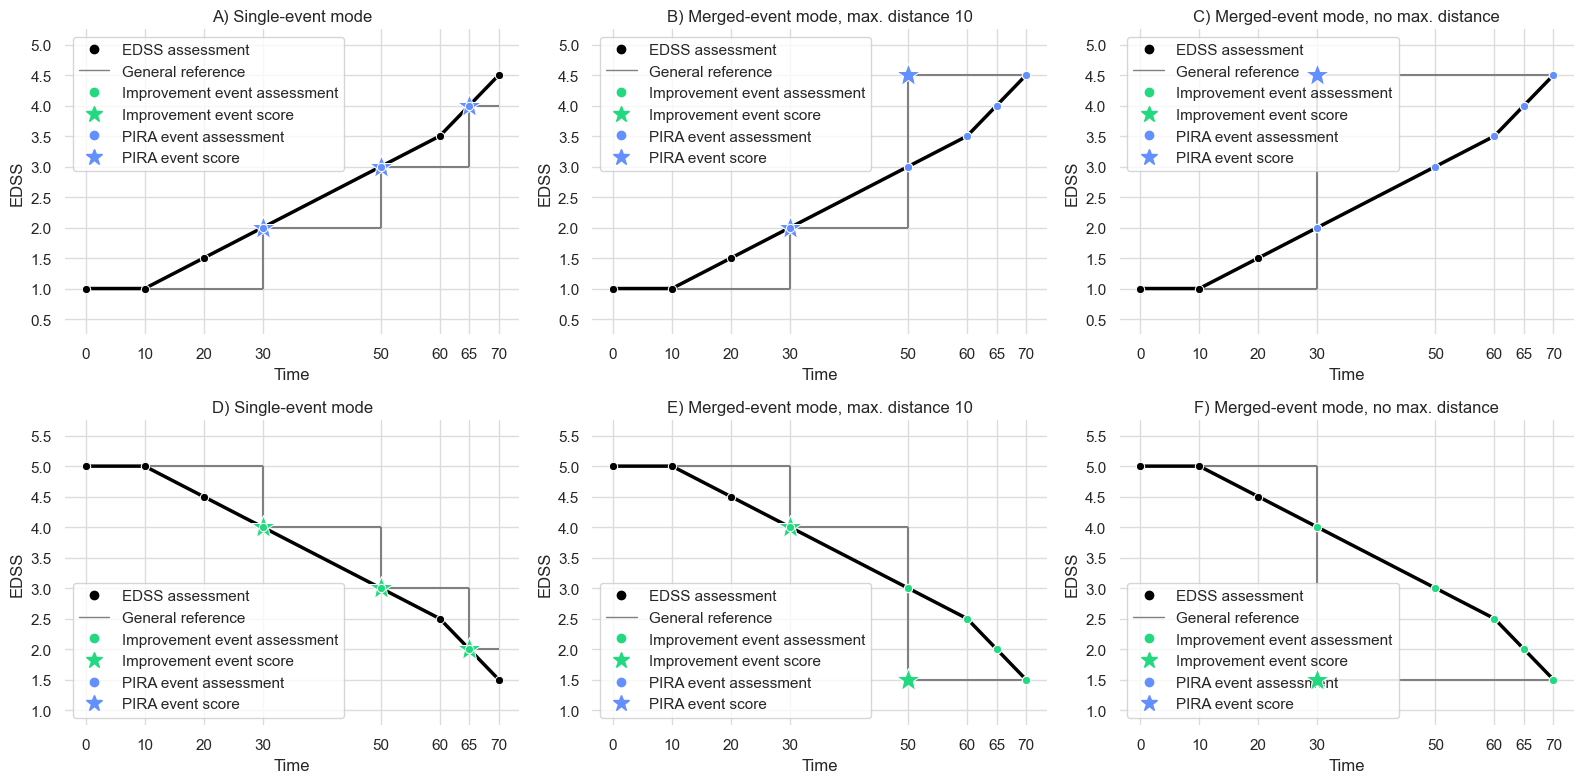

In [52]:
fig, axes = plt.subplots(2, 3, figsize=(16, 8))

example_follow_up = pd.DataFrame(
    {
        "days_after_baseline": [0, 10, 20, 30, 50, 60, 65, 70],
        "edss_score": [1, 1, 1.5, 2.0, 3.0, 3.5, 4.0, 4.5],
    }
)

for i, elt in enumerate(
    [
        (False, 0, "A) Single-event mode"),
        (True, 10, "B) Merged-event mode, max. distance 10"),
        (True, np.inf, "C) Merged-event mode, no max. distance"),
    ]
):
    visualization.annotate_plot_follow_up(
        follow_up_dataframe=example_follow_up,
        annotation_mode=SYMMETRIC_MODE_NAME,
        opt_baseline_type="fixed",
        merge_continuous_events=elt[0],
        continuous_events_max_repetition_time=5,
        continuous_events_max_merge_distance=elt[1],
        opt_require_confirmation=False,
        opt_confirmation_time=0.5,
        show_legend=True,
        move_legend_out=False,
        ax=axes[0][i],
    )
    axes[0][i].set_title(elt[2])

# Improvement mode
example_follow_up["edss_score"] = 6.0 - example_follow_up["edss_score"]
for i, elt in enumerate(
    [
        (False, 0, "D) Single-event mode"),
        (True, 10, "E) Merged-event mode, max. distance 10"),
        (True, np.inf, "F) Merged-event mode, no max. distance"),
    ]
):
    visualization.annotate_plot_follow_up(
        follow_up_dataframe=example_follow_up,
        annotation_mode=SYMMETRIC_MODE_NAME,
        opt_baseline_type="fixed",
        merge_continuous_events=elt[0],
        continuous_events_max_repetition_time=5,
        continuous_events_max_merge_distance=elt[1],
        opt_require_confirmation=False,
        opt_confirmation_time=0.5,
        show_legend=True,
        move_legend_out=False,
        ax=axes[1][i],
    )
    axes[1][i].set_title(elt[2])

fig.tight_layout()
sns.despine(bottom=True, left=True, right=True, top=True)
plt.show()

**Legend**: Examples for merging events. **A), D)** Single-event mode, i.e. no merging. Three events with an absolute
event ΔEDSS of 1.0 each. **B), E)** Merged mode with a maximal merge distance of 10 units. Two events, one with absolute
event ΔEDSS 1.0, one with absolute event ΔEDSS 2.5 points. **C), F)** Merged mode without maximal merge distance. One
event with absolute ΔEDSS 3.5 points.

## Maximal repetition distance

### One stagnation event

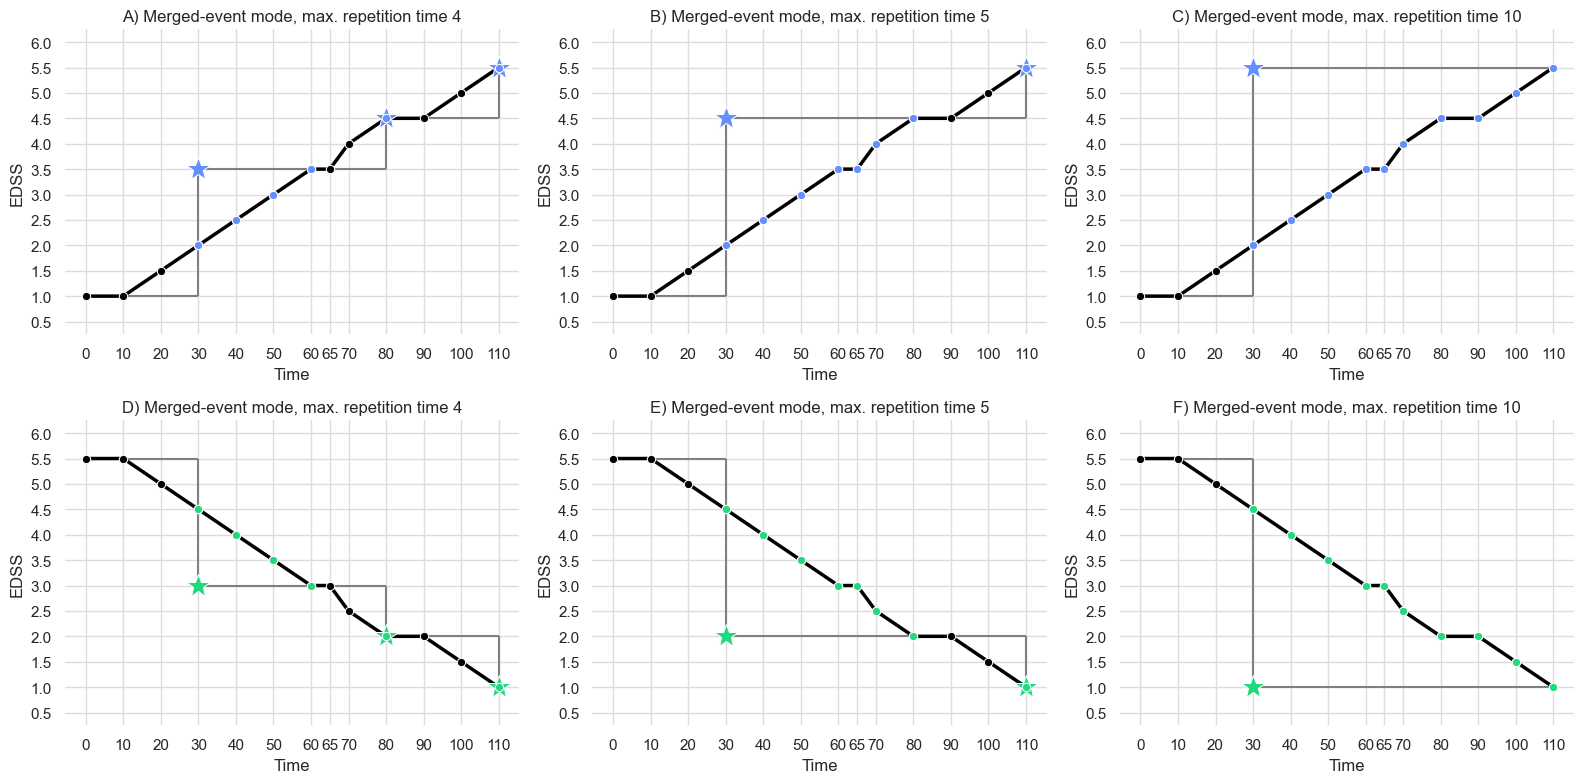

In [53]:
fig, axes = plt.subplots(2, 3, figsize=(16, 8))

example_follow_up = pd.DataFrame(
    {
        "days_after_baseline": [0, 10, 20, 30, 40, 50, 60, 65, 70, 80, 90, 100, 110],
        "edss_score": [1, 1, 1.5, 2.0, 2.5, 3.0, 3.5, 3.5, 4.0, 4.5, 4.5, 5.0, 5.5],
    }
)

for i, elt in enumerate(
    [
        (4, "A) Merged-event mode, max. repetition time 4"),
        (5, "B) Merged-event mode, max. repetition time 5"),
        (10, "C) Merged-event mode, max. repetition time 10"),
    ]
):
    visualization.annotate_plot_follow_up(
        follow_up_dataframe=example_follow_up,
        annotation_mode=SYMMETRIC_MODE_NAME,
        opt_baseline_type="fixed",
        merge_continuous_events=True,
        continuous_events_max_repetition_time=elt[0],
        show_legend=False,
        move_legend_out=False,
        ax=axes[0][i],
    )
    axes[0][i].set_title(elt[1])

example_follow_up["edss_score"] = 6.5 - example_follow_up["edss_score"]
for i, elt in enumerate(
    [
        (4, "D) Merged-event mode, max. repetition time 4"),
        (5, "E) Merged-event mode, max. repetition time 5"),
        (10, "F) Merged-event mode, max. repetition time 10"),
    ]
):
    visualization.annotate_plot_follow_up(
        follow_up_dataframe=example_follow_up,
        annotation_mode=SYMMETRIC_MODE_NAME,
        opt_baseline_type="fixed",
        merge_continuous_events=True,
        continuous_events_max_repetition_time=elt[0],
        show_legend=False,
        move_legend_out=False,
        ax=axes[1][i],
    )
    axes[1][i].set_title(elt[1])

fig.tight_layout()
sns.despine(bottom=True, left=True, right=True, top=True)
plt.show()

**Legend**: Maximal repetition time. **A), D)** Assessments with a distance &gt; 4 units are treated as stabilization, thus the
event merging ends at step 60. **B), E)** Assessments with a distance &gt; 5 units are treated as stabilization, thus the
event merging ends at step 80. **C), F)** Assessments with a distance &gt; 10 units are treated as stabilization, thus all
events are merged into one.

### Multiple stagnation events

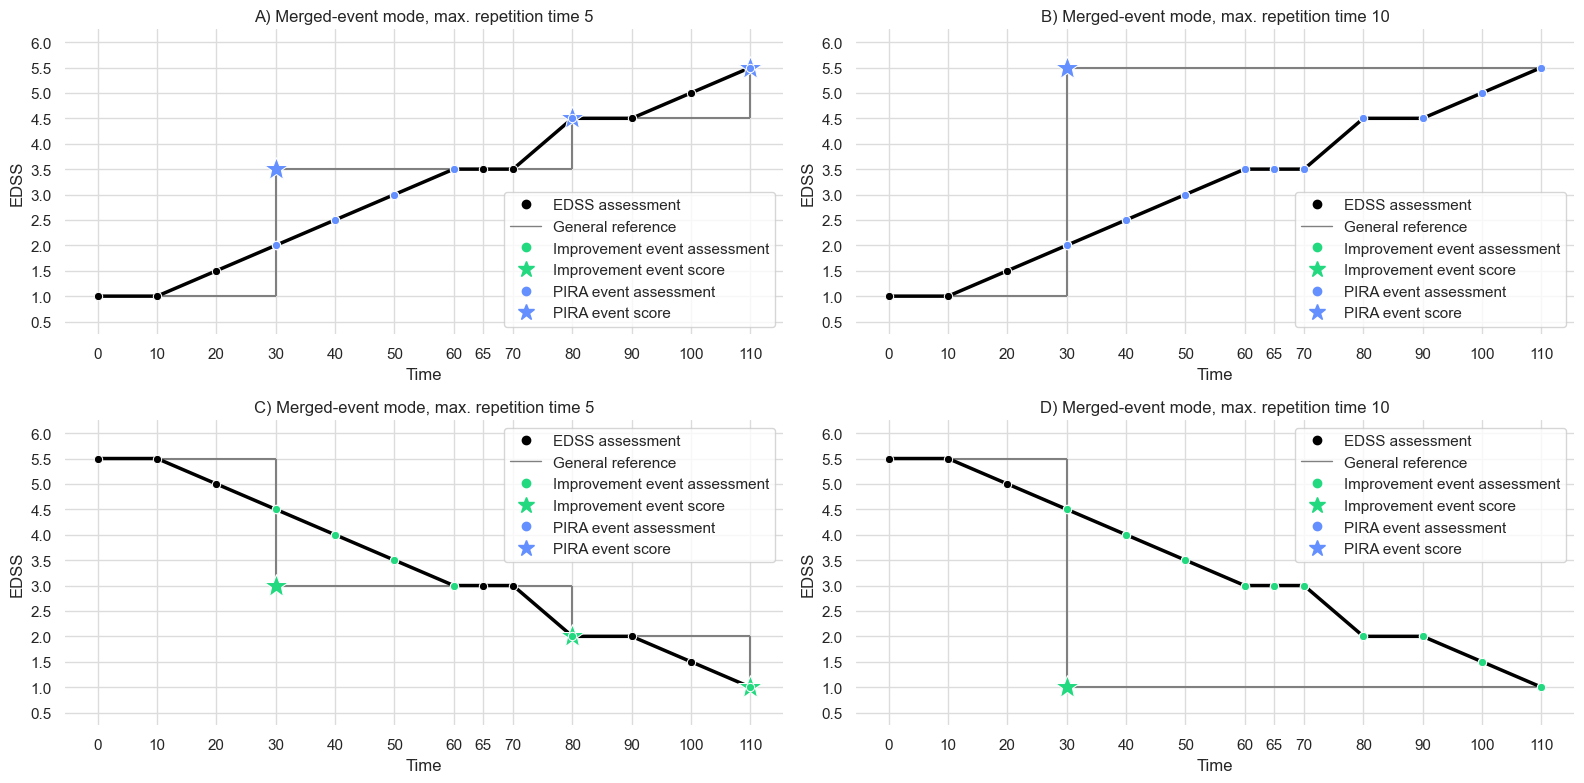

In [55]:
fig, axes = plt.subplots(2, 2, figsize=(16, 8))

example_follow_up = pd.DataFrame(
    {
        "days_after_baseline": [0, 10, 20, 30, 40, 50, 60, 65, 70, 80, 90, 100, 110],
        "edss_score": [1, 1, 1.5, 2.0, 2.5, 3.0, 3.5, 3.5, 3.5, 4.5, 4.5, 5.0, 5.5],
    }
)

for i, elt in enumerate(
    [
        (5, "A) Merged-event mode, max. repetition time 5"),
        (10, "B) Merged-event mode, max. repetition time 10"),
    ]
):
    visualization.annotate_plot_follow_up(
        follow_up_dataframe=example_follow_up,
        annotation_mode=SYMMETRIC_MODE_NAME,
        opt_baseline_type="fixed",
        merge_continuous_events=True,
        continuous_events_max_repetition_time=elt[0],
        show_legend=True,
        move_legend_out=False,
        ax=axes[0][i],
    )
    axes[0][i].set_title(elt[1])

example_follow_up["edss_score"] = 6.5 - example_follow_up["edss_score"]
for i, elt in enumerate(
    [
        (5, "C) Merged-event mode, max. repetition time 5"),
        (10, "D) Merged-event mode, max. repetition time 10"),
    ]
):
    visualization.annotate_plot_follow_up(
        follow_up_dataframe=example_follow_up,
        annotation_mode=SYMMETRIC_MODE_NAME,
        opt_baseline_type="fixed",
        merge_continuous_events=True,
        continuous_events_max_repetition_time=elt[0],
        show_legend=True,
        move_legend_out=False,
        ax=axes[1][i],
    )
    axes[1][i].set_title(elt[1])

fig.tight_layout()
sns.despine(bottom=True, left=True, right=True, top=True)
plt.show()

**Legend**: Event merging. **A), C)** Max. repetition time 5 units. The assessment at step 65 qualifies as a repetition
measurement for the event at step 60, but the assessment at step 70 does not, thus the merging process ends.
**B), D)** Max. repetition time 10 units. The assessments at steps 65 and 70 both qualify as repetition measurement,
and the next score is again an increase with respect to the previous confirmed score, so the merging continues.

### Stagnation at the end

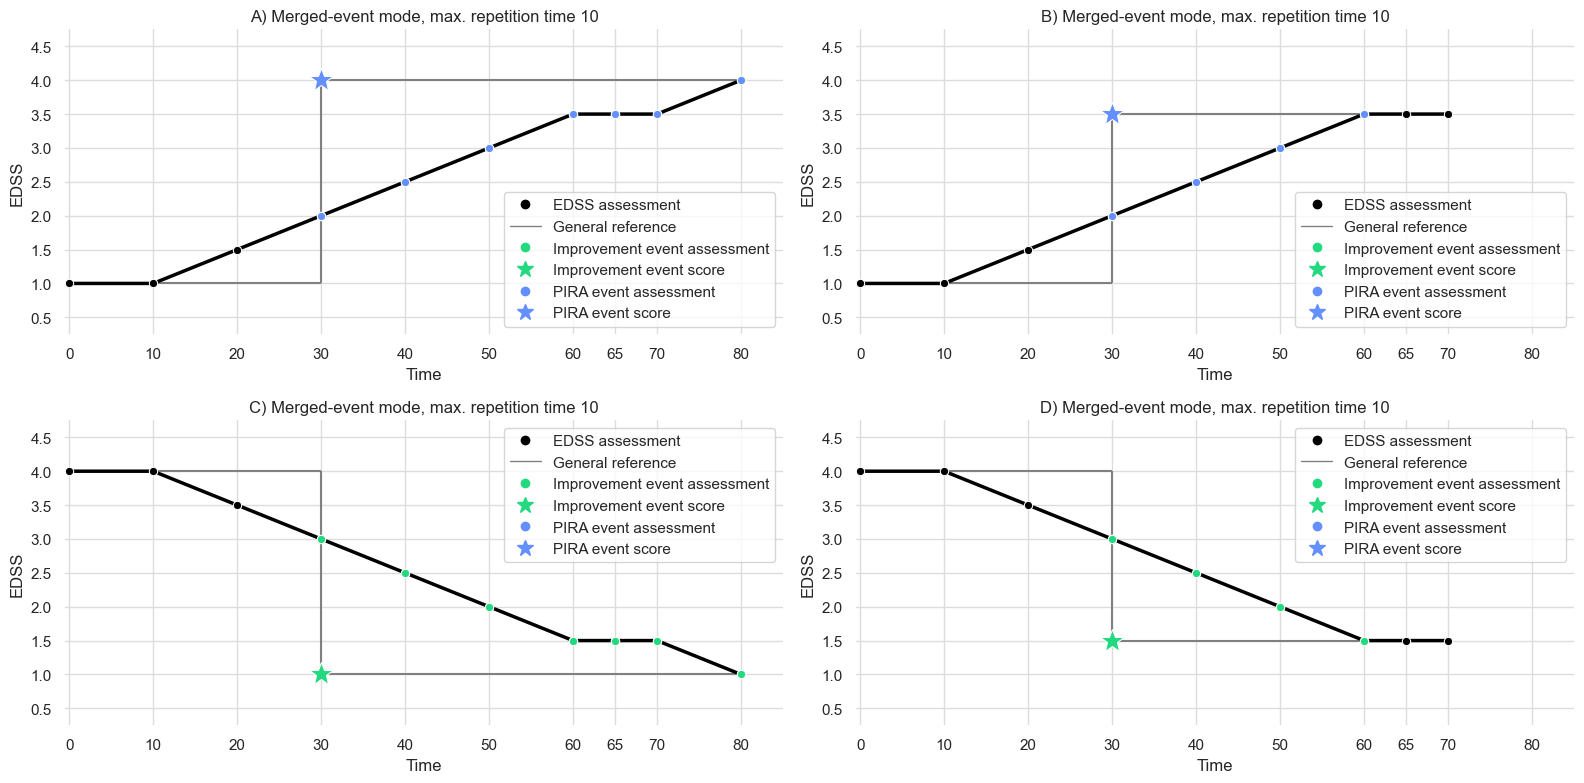

In [56]:
fig, axes = plt.subplots(2, 2, figsize=(16, 8))
example_follow_ups = [
    pd.DataFrame(
        {
            "days_after_baseline": [0, 10, 20, 30, 40, 50, 60, 65, 70, 80],
            "edss_score": [1, 1, 1.5, 2.0, 2.5, 3.0, 3.5, 3.5, 3.5, 4.0],
        }
    ),
    pd.DataFrame(
        {
            "days_after_baseline": [0, 10, 20, 30, 40, 50, 60, 65, 70],
            "edss_score": [1, 1, 1.5, 2.0, 2.5, 3.0, 3.5, 3.5, 3.5],
        }
    ),
]
for i, elt in enumerate(
    [
        "A) Merged-event mode, max. repetition time 10",
        "B) Merged-event mode, max. repetition time 10",
    ]
):
    visualization.annotate_plot_follow_up(
        follow_up_dataframe=example_follow_ups[i],
        annotation_mode=SYMMETRIC_MODE_NAME,
        opt_baseline_type="fixed",
        merge_continuous_events=True,
        continuous_events_max_repetition_time=10,
        show_legend=True,
        move_legend_out=False,
        ax=axes[0][i],
    )
    axes[0][i].set_title(elt)
    axes[0][i].set_ylim((0.25, 4.75))
    axes[0][i].set_yticks([0.5 * i for i in range(1, 10)])
    axes[0][i].set_xlim((-0.5, 85))
    axes[0][i].set_xticks([0, 10, 20, 30, 40, 50, 60, 65, 70, 80])

for example_follow_up in example_follow_ups:
    example_follow_up["edss_score"] = 5.0 - example_follow_up["edss_score"]
for i, elt in enumerate(
    [
        "C) Merged-event mode, max. repetition time 10",
        "D) Merged-event mode, max. repetition time 10",
    ]
):
    visualization.annotate_plot_follow_up(
        follow_up_dataframe=example_follow_ups[i],
        annotation_mode=SYMMETRIC_MODE_NAME,
        opt_baseline_type="fixed",
        merge_continuous_events=True,
        continuous_events_max_repetition_time=10,
        show_legend=True,
        move_legend_out=False,
        ax=axes[1][i],
    )
    axes[1][i].set_title(elt)
    axes[1][i].set_ylim((0.25, 4.75))
    axes[1][i].set_yticks([0.5 * i for i in range(1, 10)])
    axes[1][i].set_xlim((-0.5, 85))
    axes[1][i].set_xticks([0, 10, 20, 30, 40, 50, 60, 65, 70, 80])

fig.tight_layout()
sns.despine(bottom=True, left=True, right=True, top=True)
plt.show()

**Legend**: Event merging, max. repetition time 10 units. **A), C)** The assessments at steps 65 and 70 both qualify as
repetition measurement, and the score at the next assessment is again an increase/decrease with respect to the previous
confirmed score, so the merging continues. **B), D)** The assessments at steps 65 and 70 both qualify as repetition
measurement, but they are not followed by an increase/decrease, so the merging terminates at the last increase/decrease
at step 60.

## Short-term improvements

### With and without confirmation

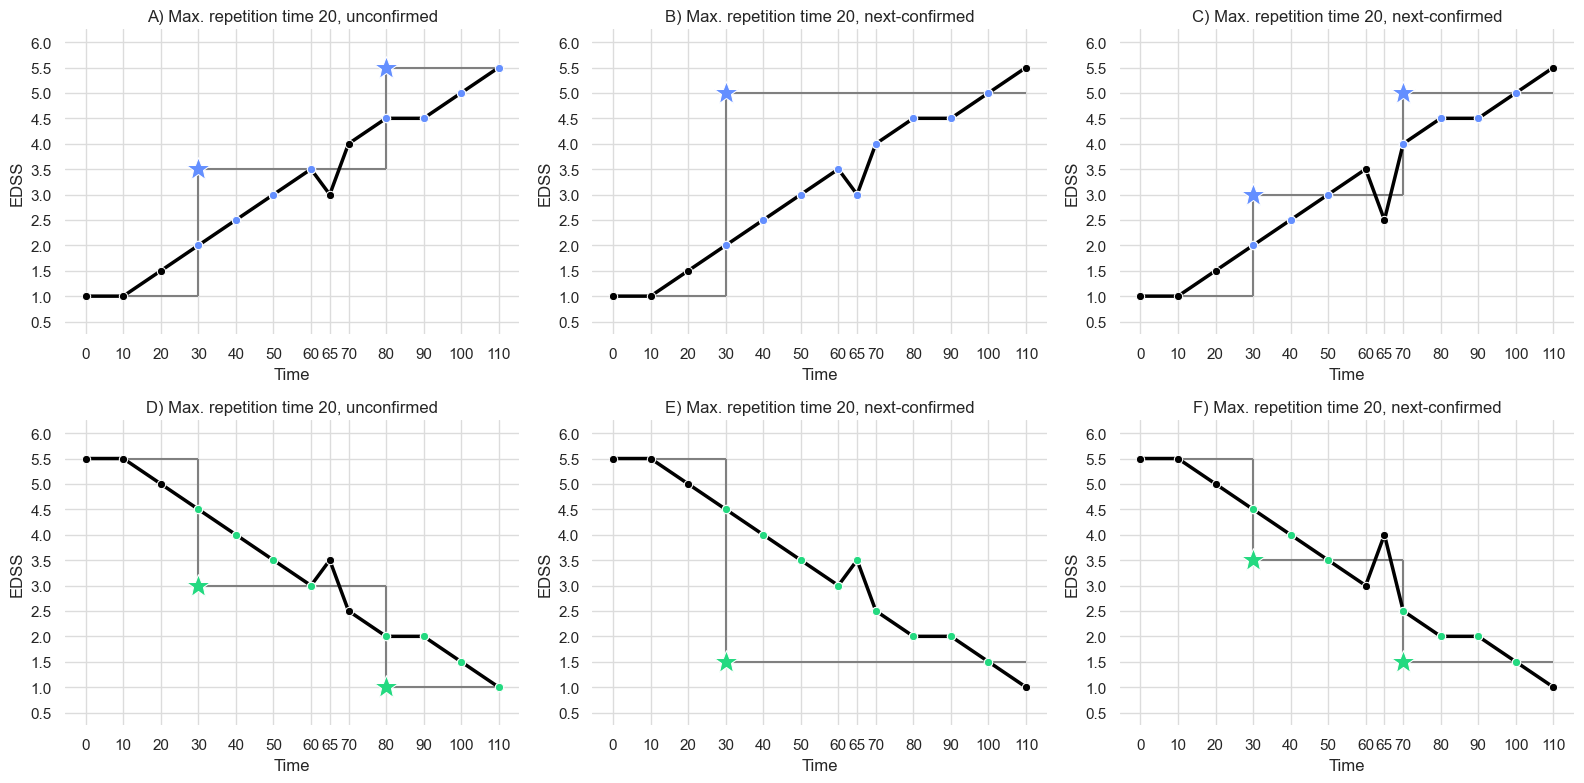

In [58]:
fig, axes = plt.subplots(2, 3, figsize=(16, 8))
example_follow_ups = [
    pd.DataFrame(
        {
            "days_after_baseline": [
                0,
                10,
                20,
                30,
                40,
                50,
                60,
                65,
                70,
                80,
                90,
                100,
                110,
            ],
            "edss_score": [1, 1, 1.5, 2.0, 2.5, 3.0, 3.5, 3.0, 4.0, 4.5, 4.5, 5.0, 5.5],
        }
    ),
    pd.DataFrame(
        {
            "days_after_baseline": [
                0,
                10,
                20,
                30,
                40,
                50,
                60,
                65,
                70,
                80,
                90,
                100,
                110,
            ],
            "edss_score": [1, 1, 1.5, 2.0, 2.5, 3.0, 3.5, 3.0, 4.0, 4.5, 4.5, 5.0, 5.5],
        }
    ),
    pd.DataFrame(
        {
            "days_after_baseline": [
                0,
                10,
                20,
                30,
                40,
                50,
                60,
                65,
                70,
                80,
                90,
                100,
                110,
            ],
            "edss_score": [1, 1, 1.5, 2.0, 2.5, 3.0, 3.5, 2.5, 4.0, 4.5, 4.5, 5.0, 5.5],
        }
    ),
]
for i, elt in enumerate(
    [
        (False, 0, "A) Max. repetition time 20, unconfirmed"),
        (True, 0.5, "B) Max. repetition time 20, next-confirmed"),
        (True, 0.5, "C) Max. repetition time 20, next-confirmed"),
    ]
):
    visualization.annotate_plot_follow_up(
        follow_up_dataframe=example_follow_ups[i],
        annotation_mode=SYMMETRIC_MODE_NAME,
        opt_baseline_type="fixed",
        merge_continuous_events=True,
        continuous_events_max_repetition_time=20,
        opt_require_confirmation=elt[0],
        opt_confirmation_time=elt[1],
        show_legend=False,
        move_legend_out=False,
        ax=axes[0][i],
    )
    axes[0][i].set_title(elt[2])

for example_follow_up in example_follow_ups:
    example_follow_up["edss_score"] = 6.5 - example_follow_up["edss_score"]
for i, elt in enumerate(
    [
        (False, 0, "D) Max. repetition time 20, unconfirmed"),
        (True, 0.5, "E) Max. repetition time 20, next-confirmed"),
        (True, 0.5, "F) Max. repetition time 20, next-confirmed"),
    ]
):
    visualization.annotate_plot_follow_up(
        follow_up_dataframe=example_follow_ups[i],
        annotation_mode=SYMMETRIC_MODE_NAME,
        opt_baseline_type="fixed",
        merge_continuous_events=True,
        continuous_events_max_repetition_time=20,
        opt_require_confirmation=elt[0],
        opt_confirmation_time=elt[1],
        show_legend=False,
        move_legend_out=False,
        ax=axes[1][i],
    )
    axes[1][i].set_title(elt[2])

fig.tight_layout()
sns.despine(bottom=True, left=True, right=True, top=True)
plt.show()

**Legend**: Event merging, max. repetition distance 20 units. **A), D)** No confirmation required. The event score
at step 60 is thus 3.5/3.0, respectively, and the merging stops because the following score is lower/higher.
**B), E)** Events must ne confirmed at the next assessment. The confirmed score at step 60 is 3.0, thus the event
at step 65 with confirmed score 3.0 is considered a repetition measurement and the merging continues. **C), F)**
The score at step 65 is lower/higher, respectively, than the confirmed score from step 60, so the merging is terminated.

### Effect of confirmed score

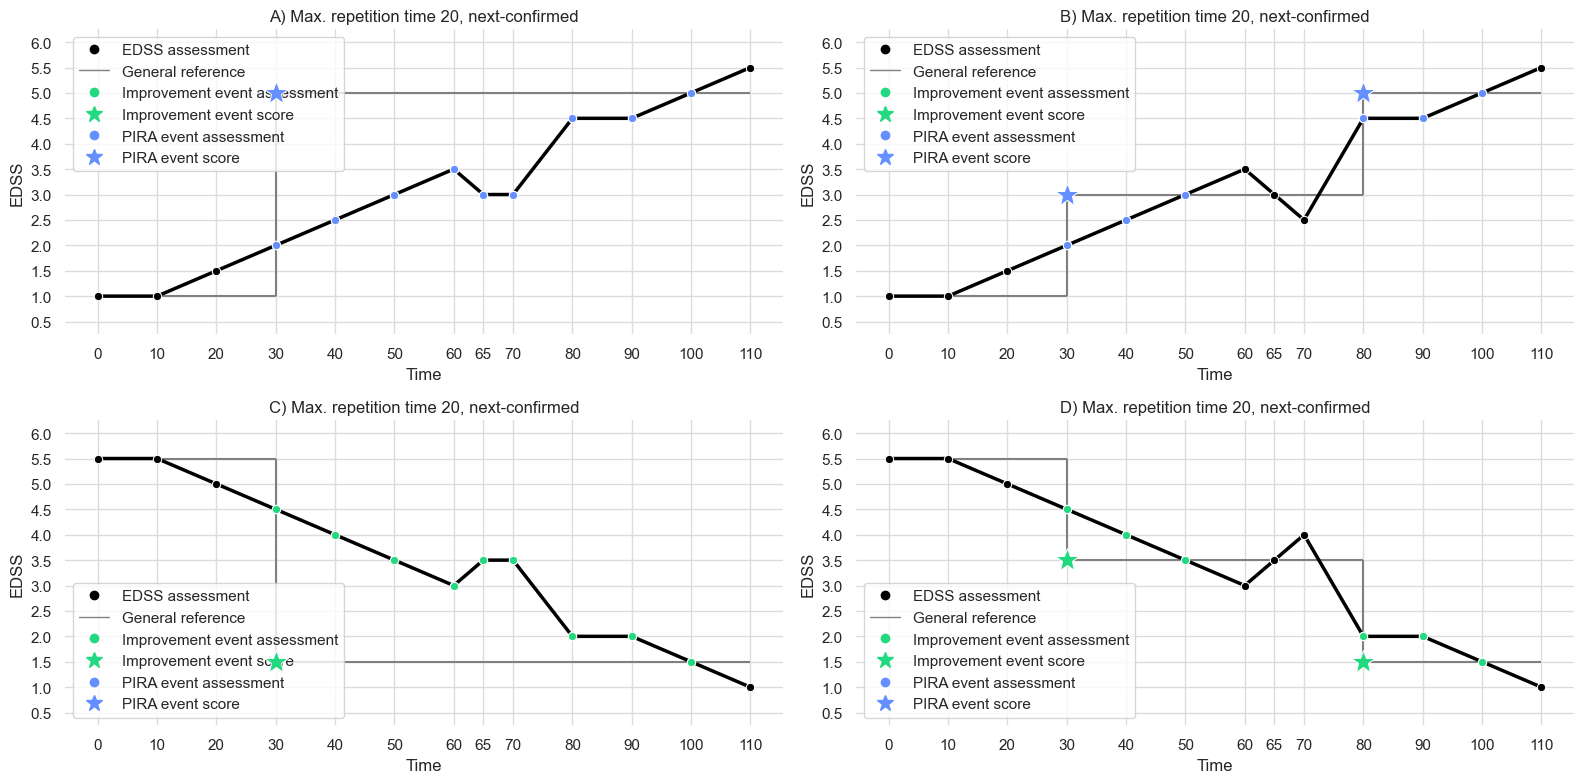

In [59]:
fig, axes = plt.subplots(2, 2, figsize=(16, 8))
example_follow_ups = [
    pd.DataFrame(
        {
            "days_after_baseline": [
                0,
                10,
                20,
                30,
                40,
                50,
                60,
                65,
                70,
                80,
                90,
                100,
                110,
            ],
            "edss_score": [1, 1, 1.5, 2.0, 2.5, 3.0, 3.5, 3.0, 3.0, 4.5, 4.5, 5.0, 5.5],
        }
    ),
    pd.DataFrame(
        {
            "days_after_baseline": [
                0,
                10,
                20,
                30,
                40,
                50,
                60,
                65,
                70,
                80,
                90,
                100,
                110,
            ],
            "edss_score": [1, 1, 1.5, 2.0, 2.5, 3.0, 3.5, 3.0, 2.5, 4.5, 4.5, 5.0, 5.5],
        }
    ),
]
for i, elt in enumerate(
    [
        "A) Max. repetition time 20, next-confirmed",
        "B) Max. repetition time 20, next-confirmed",
    ]
):
    visualization.annotate_plot_follow_up(
        follow_up_dataframe=example_follow_ups[i],
        annotation_mode=SYMMETRIC_MODE_NAME,
        opt_baseline_type="fixed",
        merge_continuous_events=True,
        continuous_events_max_repetition_time=20,
        opt_require_confirmation=True,
        opt_confirmation_time=0.5,
        show_legend=True,
        move_legend_out=False,
        ax=axes[0][i],
    )
    axes[0][i].set_title(elt)

for example_follow_up in example_follow_ups:
    example_follow_up["edss_score"] = 6.5 - example_follow_up["edss_score"]
for i, elt in enumerate(
    [
        "C) Max. repetition time 20, next-confirmed",
        "D) Max. repetition time 20, next-confirmed",
    ]
):
    visualization.annotate_plot_follow_up(
        follow_up_dataframe=example_follow_ups[i],
        annotation_mode=SYMMETRIC_MODE_NAME,
        opt_baseline_type="fixed",
        merge_continuous_events=True,
        continuous_events_max_repetition_time=20,
        opt_require_confirmation=True,
        opt_confirmation_time=0.5,
        show_legend=True,
        move_legend_out=False,
        ax=axes[1][i],
    )
    axes[1][i].set_title(elt)

fig.tight_layout()
sns.despine(bottom=True, left=True, right=True, top=True)
plt.show()

**Legend**: Event merging, max. repetition distance 20 units, event confirmation at the next assessment required.
**A)** Next-confirmed disability accrual. The confirmed score at step 60 is 3.0, thus the events at steps 65 and
70 with confirmed score 3.0 are considered repetition measurements and the merging continues. **B)** The confirmed
event score at step 65 is 2.5. This is lower than the confirmed score from step 60, so the merging is terminated.
**C)** Next-confirmed disability improvement. The confirmed score at step 60 is 3.5, thus the events at steps 65 and
70 with confirmed score 3.0 are considered repetition measurements and the merging continues. **D)** The confirmed
event score at step 65 is 4.0. This is higher than the confirmed score from step 60, so the merging is terminated.

### Effect of last confirmed, with roving reference

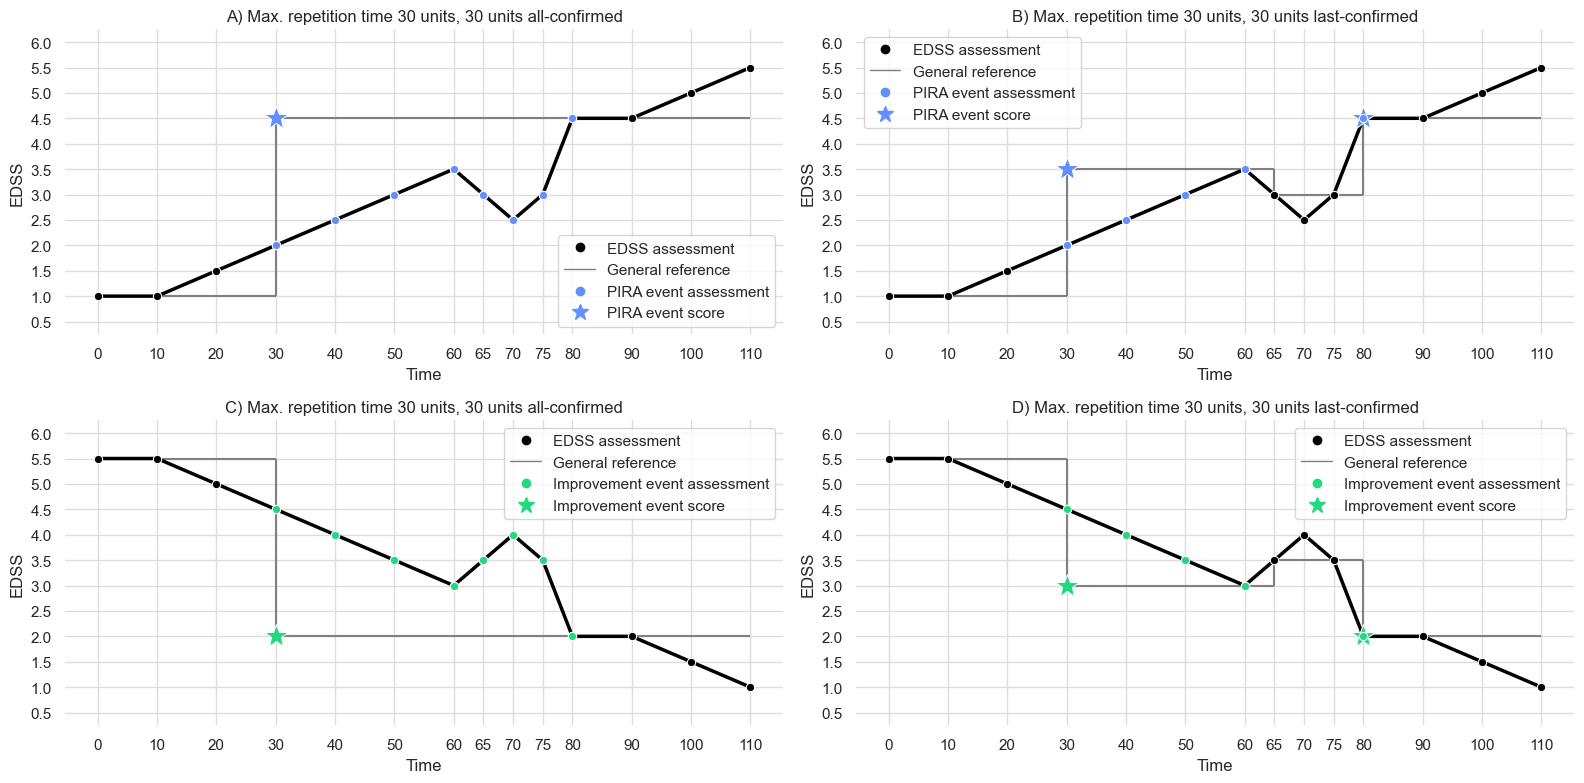

In [60]:
fig, axes = plt.subplots(2, 2, figsize=(16, 8))
example_follow_up = pd.DataFrame(
    {
        "days_after_baseline": [
            0,
            10,
            20,
            30,
            40,
            50,
            60,
            65,
            70,
            75,
            80,
            90,
            100,
            110,
        ],
        "edss_score": [
            1,
            1,
            1.5,
            2.0,
            2.5,
            3.0,
            3.5,
            3.0,
            2.5,
            3.0,
            4.5,
            4.5,
            5.0,
            5.5,
        ],
    }
)

for i, elt in enumerate(
    [
        ("all", "A) Max. repetition time 30 units, 30 units all-confirmed"),
        ("last", "B) Max. repetition time 30 units, 30 units last-confirmed"),
    ]
):
    visualization.annotate_plot_follow_up(
        follow_up_dataframe=example_follow_up,
        annotation_mode=ACCRUAL_MODE_NAME,
        opt_baseline_type="roving",
        opt_roving_reference_confirmation_time=0.5,
        merge_continuous_events=True,
        continuous_events_max_repetition_time=30,
        opt_require_confirmation=True,
        opt_confirmation_time=30,
        opt_confirmation_included_values=elt[0],
        show_legend=True,
        move_legend_out=False,
        ax=axes[0][i],
    )
    axes[0][i].set_title(elt[1])

example_follow_up["edss_score"] = 6.5 - example_follow_up["edss_score"]
for i, elt in enumerate(
    [
        ("all", "C) Max. repetition time 30 units, 30 units all-confirmed"),
        ("last", "D) Max. repetition time 30 units, 30 units last-confirmed"),
    ]
):
    visualization.annotate_plot_follow_up(
        follow_up_dataframe=example_follow_up,
        annotation_mode=IMPROVEMENT_MODE_NAME,
        opt_baseline_type="roving",
        opt_roving_reference_confirmation_time=0.5,
        merge_continuous_events=True,
        continuous_events_max_repetition_time=30,
        opt_require_confirmation=True,
        opt_confirmation_time=30,
        opt_confirmation_included_values=elt[0],
        show_legend=True,
        move_legend_out=False,
        ax=axes[1][i],
    )
    axes[1][i].set_title(elt[1])

fig.tight_layout()
sns.despine(bottom=True, left=True, right=True, top=True)
plt.show()

**Legend**: Event merging, max. repetition distance 30 units, 30 units event confirmation required. **A)** Confirmation
for all values within the confirmation interval. The confirmed score at step 50 is 2.5, and it is considered a
repetition measurement of the score at step 40 because it is within the maximum repetition distance. The same is
true for the confirmed scores at steps 60, 65, and 70. The confirmed score at step 75 is 3.0, so the merging
continues. **B)** Confirmation only for the first value that satisfies the minimal confirmation distance. The confirmed
event score at step 60 is 3.5, since the corresponding confirmation assessment is the one at step 90. The
following score is lower, thus the merging is terminated. **C)** Confirmation for all values within the confirmation
interval. The confirmed score at step 50 is 4.0, and it is considered a repetition measurement of the score at step
40 because it is within the maximum repetition distance. The same is true for the confirmed scores at steps 60, 65,
and 70. The confirmed score at step 75 is 3.5, so the merging continues. **D)** Confirmation only for the first value
that satisfies the minimal confirmation distance. The confirmed event score at step 60 is 3.0, since the corresponding
confirmation assessment is the one at step 90. The following score is higher, thus the merging is terminated.

### Effect of last confirmed, with fixed baseline

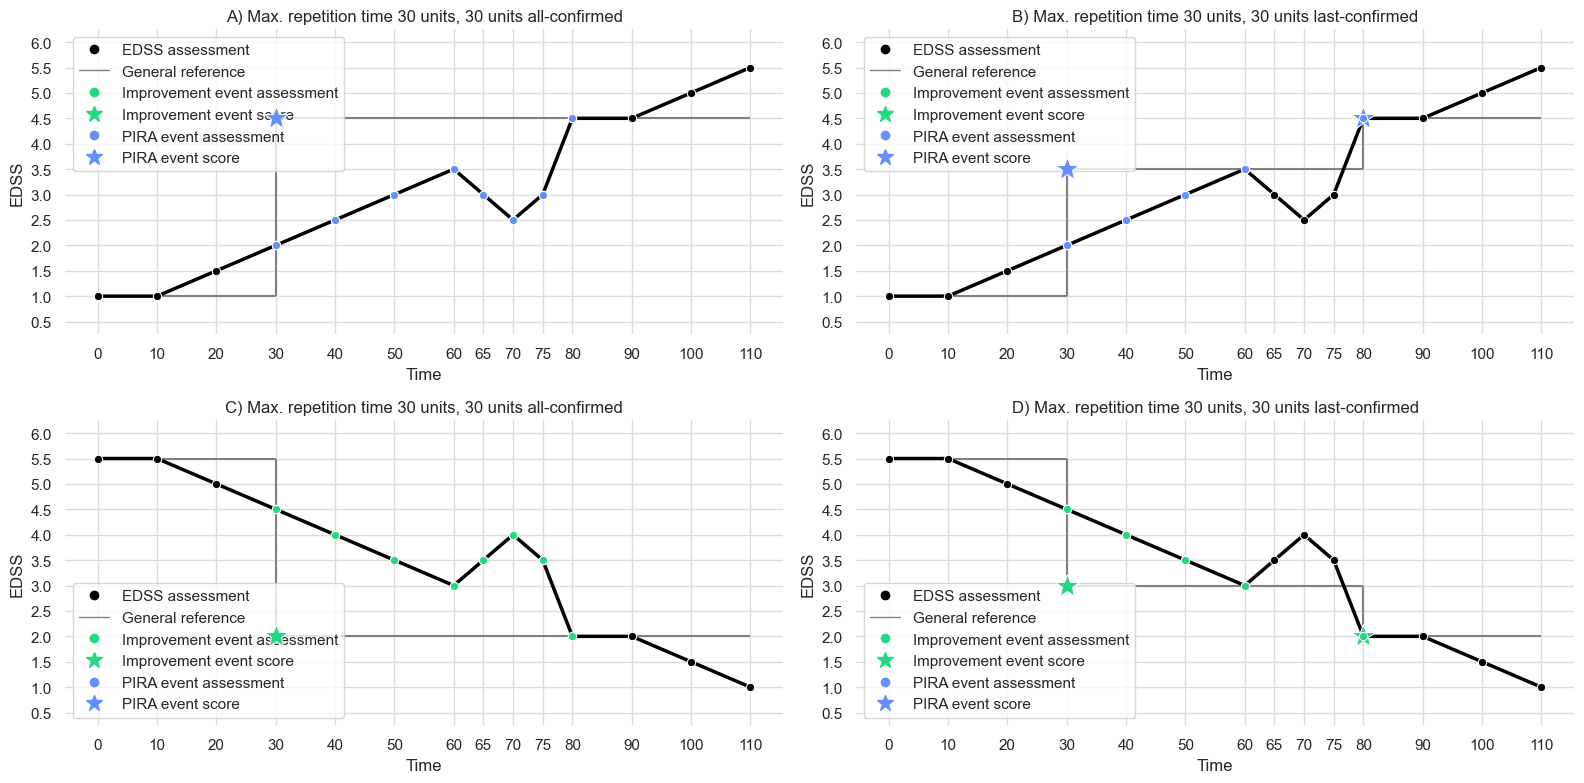

In [61]:
fig, axes = plt.subplots(2, 2, figsize=(16, 8))
example_follow_up = pd.DataFrame(
    {
        "days_after_baseline": [
            0,
            10,
            20,
            30,
            40,
            50,
            60,
            65,
            70,
            75,
            80,
            90,
            100,
            110,
        ],
        "edss_score": [
            1,
            1,
            1.5,
            2.0,
            2.5,
            3.0,
            3.5,
            3.0,
            2.5,
            3.0,
            4.5,
            4.5,
            5.0,
            5.5,
        ],
    }
)

for i, elt in enumerate(
    [
        ("all", "A) Max. repetition time 30 units, 30 units all-confirmed"),
        ("last", "B) Max. repetition time 30 units, 30 units last-confirmed"),
    ]
):
    visualization.annotate_plot_follow_up(
        follow_up_dataframe=example_follow_up,
        annotation_mode=SYMMETRIC_MODE_NAME,
        opt_baseline_type="fixed",
        opt_roving_reference_confirmation_time=0.5,
        merge_continuous_events=True,
        continuous_events_max_repetition_time=30,
        opt_require_confirmation=True,
        opt_confirmation_time=30,
        opt_confirmation_included_values=elt[0],
        show_legend=True,
        move_legend_out=False,
        ax=axes[0][i],
    )
    axes[0][i].set_title(elt[1])

example_follow_up["edss_score"] = 6.5 - example_follow_up["edss_score"]
for i, elt in enumerate(
    [
        ("all", "C) Max. repetition time 30 units, 30 units all-confirmed"),
        ("last", "D) Max. repetition time 30 units, 30 units last-confirmed"),
    ]
):
    visualization.annotate_plot_follow_up(
        follow_up_dataframe=example_follow_up,
        annotation_mode=SYMMETRIC_MODE_NAME,
        opt_baseline_type="fixed",
        opt_roving_reference_confirmation_time=0.5,
        merge_continuous_events=True,
        continuous_events_max_repetition_time=30,
        opt_require_confirmation=True,
        opt_confirmation_time=30,
        opt_confirmation_included_values=elt[0],
        show_legend=True,
        move_legend_out=False,
        ax=axes[1][i],
    )
    axes[1][i].set_title(elt[1])

fig.tight_layout()
sns.despine(bottom=True, left=True, right=True, top=True)
plt.show()

**Legend**: Event merging, max. repetition distance 30 units, 30 units event confirmation required. **A)** Confirmation
for all values within the confirmation interval. The confirmed score at step 50 is 2.5, and it is considered a
repetition measurement of the score at step 40 because it is within the maximum repetition distance. The same is
true for the confirmed scores at steps 60, 65, and 70. The confirmed score at step 75 is 3.0, so the merging
continues. **B)** Confirmation only for the first value that satisfies the minimal confirmation distance. The confirmed
event score at step 60 is 3.5, since the corresponding confirmation assessment is the one at step 90. The
following score is lower, thus the merging is terminated. **C)** Confirmation for all values within the confirmation
interval. The confirmed score at step 50 is 4.0, and it is considered a repetition measurement of the score at step
40 because it is within the maximum repetition distance. The same is true for the confirmed scores at steps 60, 65,
and 70. The confirmed score at step 75 is 3.5, so the merging continues. **D)** Confirmation only for the first value
that satisfies the minimal confirmation distance. The confirmed event score at step 60 is 3.0, since the corresponding
confirmation assessment is the one at step 90. The following score is higher, thus the merging is terminated.

# **Part 3 - Symmetric mode specific aspects**

## Minimal increase and decrease - illustrate default mode

### Plus 1.5 from 0

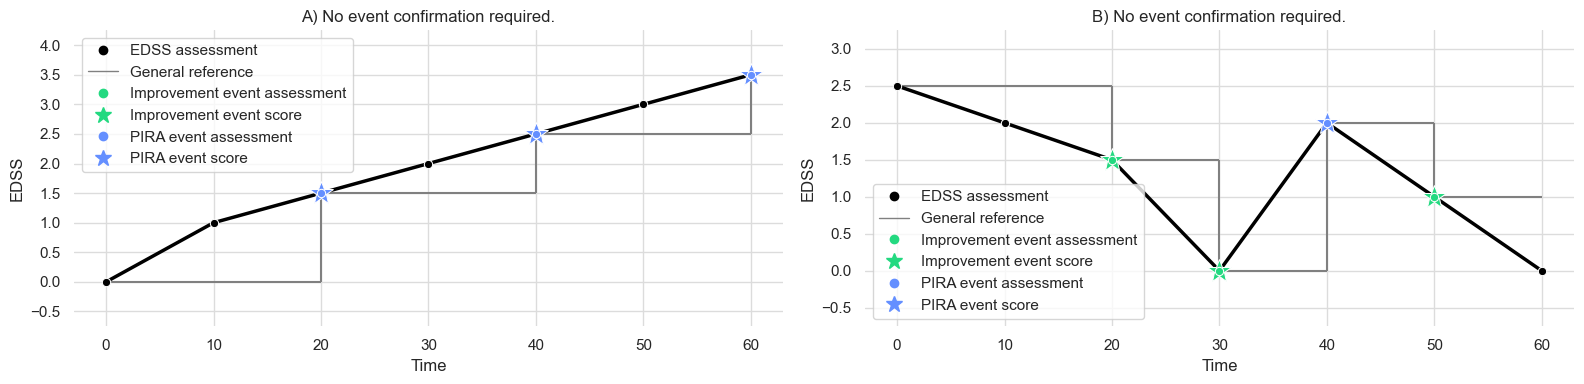

In [63]:
fig, axes = plt.subplots(1, 2, figsize=(16, 4))
example_follow_up = pd.DataFrame(
    {
        "days_after_baseline": [10 * i for i in range(7)],
        "edss_score": [0] + [1 + i * 0.5 for i in range(6)],
    }
)

visualization.annotate_plot_follow_up(
    follow_up_dataframe=example_follow_up,
    annotation_mode=SYMMETRIC_MODE_NAME,
    opt_baseline_type="fixed",
    opt_require_confirmation=False,
    show_legend=True,
    move_legend_out=False,
    ax=axes[0],
)

example_follow_up = pd.DataFrame(
    {
        "days_after_baseline": [10 * i for i in range(7)],
        "edss_score": [2.5, 2.0, 1.5, 0, 2.0, 1.0, 0],
    }
)
visualization.annotate_plot_follow_up(
    follow_up_dataframe=example_follow_up,
    annotation_mode=SYMMETRIC_MODE_NAME,
    opt_baseline_type="fixed",
    opt_require_confirmation=False,
    show_legend=True,
    move_legend_out=False,
    ax=axes[1],
)

axes[0].set_title("A) No event confirmation required.")
axes[1].set_title("B) No event confirmation required.")

fig.tight_layout()
sns.despine(bottom=True, left=True, right=True, top=True)
plt.show()

**Legend**: No event confirmation required. **A)** The increase at step 10 is not classified as disability accrual since the minimal increase from a reference of 0.0 is + 1.5. **B)** The decrease at step 60 is not a disability improvement event because the minimal decrease from 1.5 and lower is 1.5 points.

### Max. score that requires plus 1.0 is 5

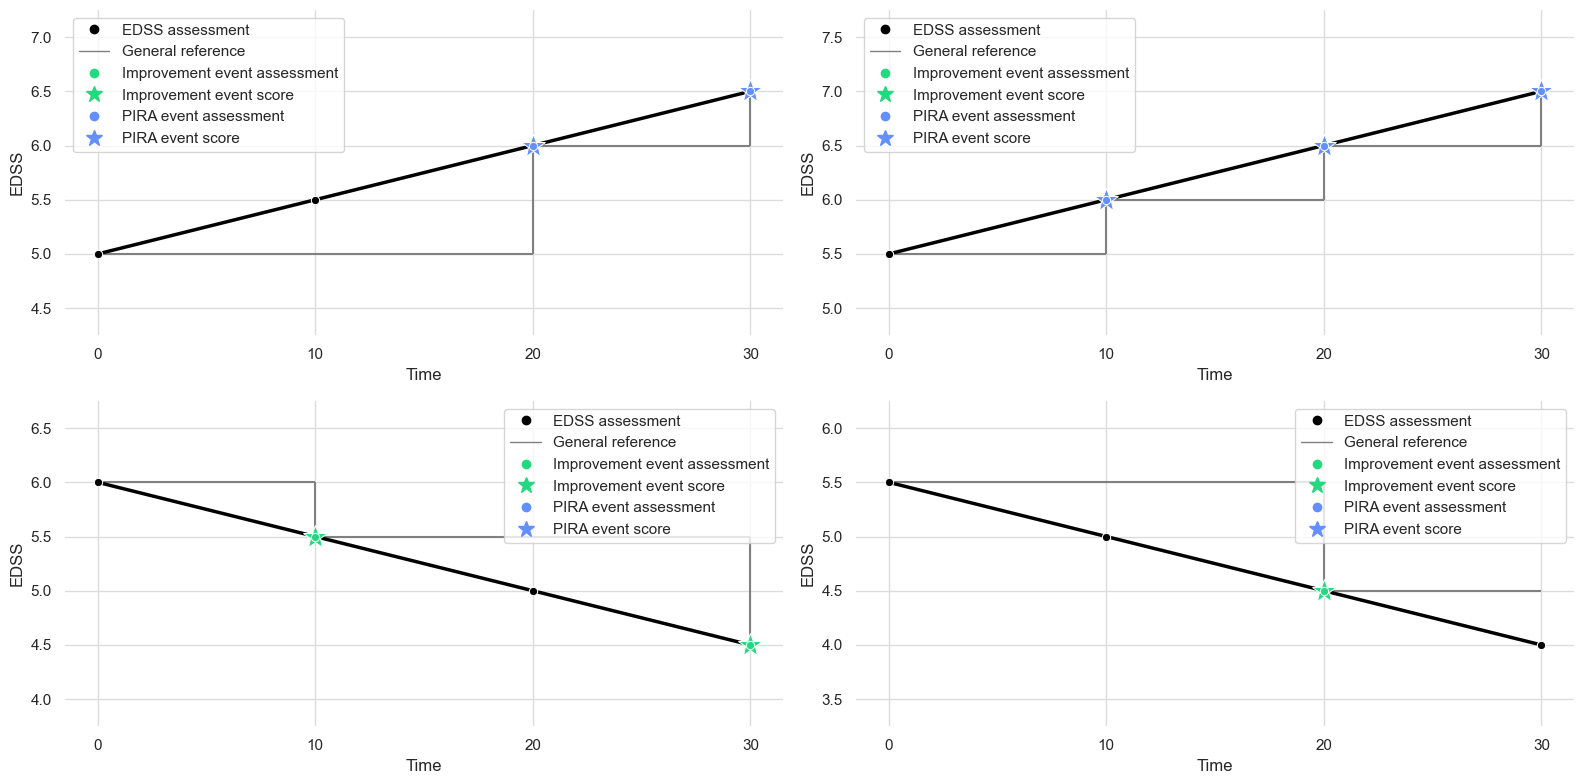

In [64]:
fig, axes = plt.subplots(2, 2, figsize=(16, 8))
example_follow_up = pd.DataFrame(
    {
        "days_after_baseline": [10 * i for i in range(4)],
        "edss_score": [5 + i * 0.5 for i in range(4)],
    }
)

visualization.annotate_plot_follow_up(
    follow_up_dataframe=example_follow_up,
    annotation_mode=SYMMETRIC_MODE_NAME,
    opt_baseline_type="fixed",
    opt_require_confirmation=False,
    show_legend=True,
    move_legend_out=False,
    ax=axes[0][0],
)
example_follow_up["edss_score"] = example_follow_up["edss_score"] + 0.5
visualization.annotate_plot_follow_up(
    follow_up_dataframe=example_follow_up,
    annotation_mode=SYMMETRIC_MODE_NAME,
    opt_baseline_type="fixed",
    opt_require_confirmation=False,
    show_legend=True,
    move_legend_out=False,
    ax=axes[0][1],
)
example_follow_up["edss_score"] = 11.5 - example_follow_up["edss_score"]
visualization.annotate_plot_follow_up(
    follow_up_dataframe=example_follow_up,
    annotation_mode=SYMMETRIC_MODE_NAME,
    opt_baseline_type="fixed",
    opt_require_confirmation=False,
    show_legend=True,
    move_legend_out=False,
    ax=axes[1][0],
)
example_follow_up["edss_score"] = example_follow_up["edss_score"] - 0.5
visualization.annotate_plot_follow_up(
    follow_up_dataframe=example_follow_up,
    annotation_mode=SYMMETRIC_MODE_NAME,
    opt_baseline_type="fixed",
    opt_require_confirmation=False,
    show_legend=True,
    move_legend_out=False,
    ax=axes[1][1],
)

fig.tight_layout()
sns.despine(bottom=True, left=True, right=True, top=True)
plt.show()

**Legend**: The improvement and symmetric mode use the increase arguments with a flipped sign for decrease, i.e. a
decrease is large enough if it is at least -1.0 from any reference smaller or equal to ``opt_max_score_that_requires_plus_1`` + 0.5,
and at least -0.5 for references above that. With the ``opt_larger_increment_from_0`` set to True, a reference score of 1.5 requires
a minimal decrease of 1.5 (i.e. from 1.5 to 0.0 counts as decrease, from 1.5 to 1.0 does not).

## Event merging - increases/decreases are not merged with each other

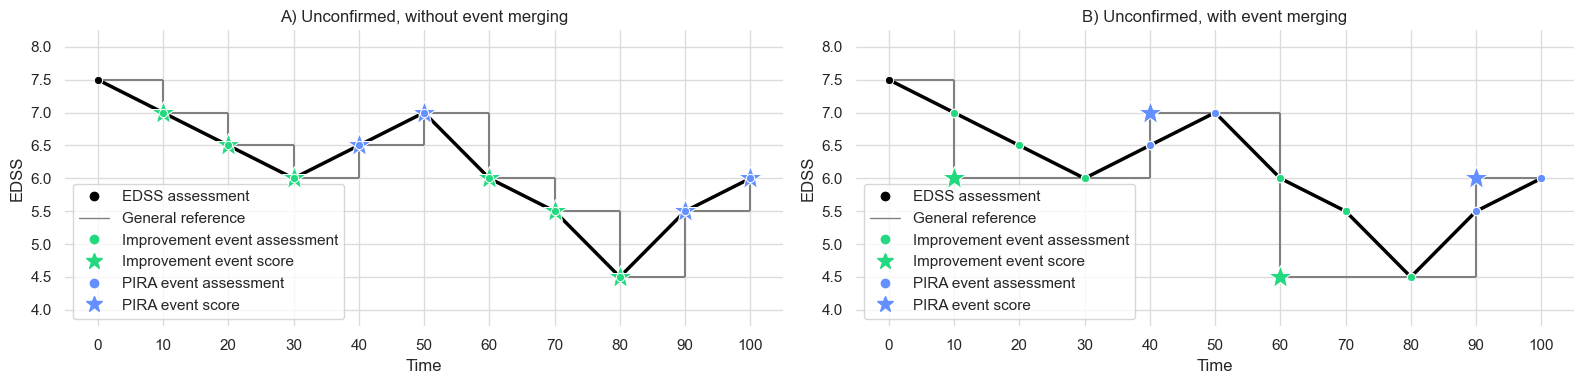

In [64]:
fig, axes = plt.subplots(1, 2, figsize=(16, 4))

example_follow_up = pd.DataFrame(
    {
        "days_after_baseline": [10 * i for i in range(11)],
        "edss_score": [7.5, 7.0, 6.5, 6.0, 6.5, 7.0, 6.0, 5.5, 4.5, 5.5, 6.0],
    }
)
visualization.annotate_plot_follow_up(
    follow_up_dataframe=example_follow_up,
    merge_continuous_events=False,
    annotation_mode=SYMMETRIC_MODE_NAME,
    opt_baseline_type="fixed",
    opt_require_confirmation=False,
    show_legend=True,
    move_legend_out=False,
    ax=axes[0],
)
visualization.annotate_plot_follow_up(
    follow_up_dataframe=example_follow_up,
    merge_continuous_events=True,
    annotation_mode=SYMMETRIC_MODE_NAME,
    opt_baseline_type="fixed",
    opt_require_confirmation=False,
    show_legend=True,
    move_legend_out=False,
    ax=axes[1],
)

axes[0].set_title("A) Unconfirmed, without event merging")
axes[1].set_title("B) Unconfirmed, with event merging")

fig.tight_layout()
sns.despine(bottom=True, left=True, right=True, top=True)
plt.show()

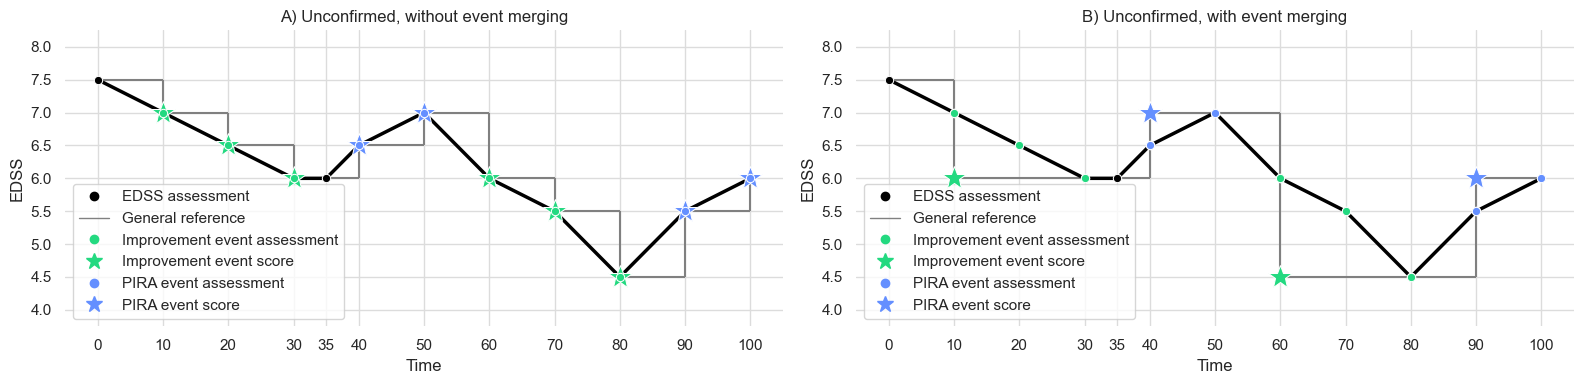

In [65]:
fig, axes = plt.subplots(1, 2, figsize=(16, 4))

example_follow_up = pd.DataFrame(
    {
        "days_after_baseline": sorted([10 * i for i in range(11)] + [35]),
        "edss_score": [7.5, 7.0, 6.5, 6.0, 6.0, 6.5, 7.0, 6.0, 5.5, 4.5, 5.5, 6.0],
    }
)
visualization.annotate_plot_follow_up(
    follow_up_dataframe=example_follow_up,
    merge_continuous_events=False,
    annotation_mode=SYMMETRIC_MODE_NAME,
    opt_baseline_type="fixed",
    opt_require_confirmation=False,
    show_legend=True,
    move_legend_out=False,
    ax=axes[0],
)
visualization.annotate_plot_follow_up(
    follow_up_dataframe=example_follow_up,
    merge_continuous_events=True,
    annotation_mode=SYMMETRIC_MODE_NAME,
    opt_baseline_type="fixed",
    opt_require_confirmation=False,
    show_legend=True,
    move_legend_out=False,
    ax=axes[1],
)

axes[0].set_title("A) Unconfirmed, without event merging")
axes[1].set_title("B) Unconfirmed, with event merging")

fig.tight_layout()
sns.despine(bottom=True, left=True, right=True, top=True)
plt.show()

# **Part 4 - Relapse-Related Definitions**

# Event types

## RAW, PIRA, and improvement

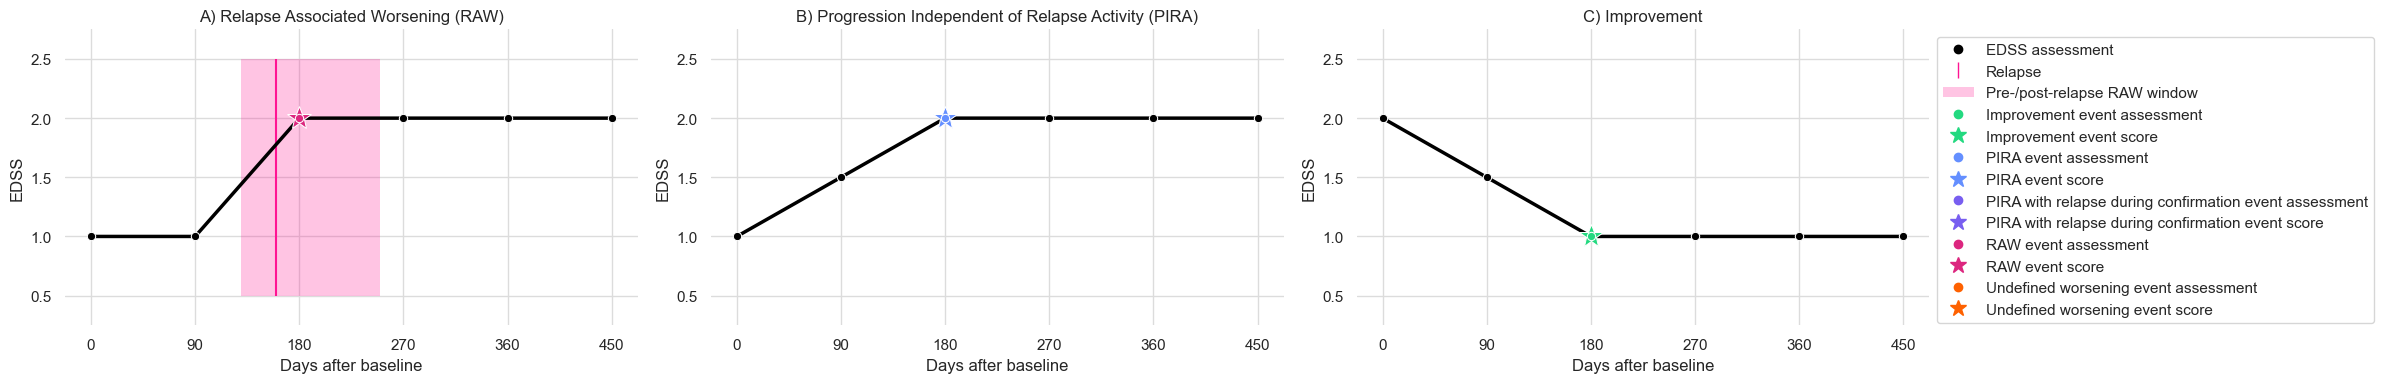

In [66]:
fig, axes = plt.subplots(1, 3, figsize=(24, 4))

visualization.annotate_plot_follow_up(
    annotation_mode=SYMMETRIC_MODE_NAME,
    follow_up_dataframe=pd.DataFrame(
        {
            "days_after_baseline": [0, 90, 180, 270, 360, 450],
            "edss_score": [1, 1, 2.0, 2, 2, 2],
        }
    ),
    relapse_timestamps=[160],
    opt_baseline_type="fixed",
    opt_require_confirmation=True,
    opt_confirmation_time=24 * 7,
    opt_raw_after_relapse_max_time=90,
    opt_raw_before_relapse_max_time=30,
    show_legend=False,
    move_legend_out=True,
    show_baselines=False,
    ax=axes[0],
)
axes[0].set_title("A) Relapse Associated Worsening (RAW)")

visualization.annotate_plot_follow_up(
    annotation_mode=SYMMETRIC_MODE_NAME,
    follow_up_dataframe=pd.DataFrame(
        {
            "days_after_baseline": [0, 90, 180, 270, 360, 450],
            "edss_score": [1, 1.5, 2, 2, 2, 2],
        }
    ),
    relapse_timestamps=[-100],
    opt_baseline_type="fixed",
    opt_require_confirmation=True,
    opt_confirmation_time=24 * 7,
    opt_raw_after_relapse_max_time=30,
    opt_raw_before_relapse_max_time=30,
    show_legend=False,
    move_legend_out=True,
    show_baselines=False,
    ax=axes[1],
)
axes[1].set_title("B) Progression Independent of Relapse Activity (PIRA)")
axes[1].set_xlim(axes[0].get_xlim())

visualization.annotate_plot_follow_up(
    annotation_mode=SYMMETRIC_MODE_NAME,
    follow_up_dataframe=pd.DataFrame(
        {
            "days_after_baseline": [0, 90, 180, 270, 360, 450],
            "edss_score": [2, 1.5, 1, 1, 1, 1],
        }
    ),
    relapse_timestamps=[-100],
    opt_baseline_type="fixed",
    opt_require_confirmation=True,
    opt_confirmation_time=24 * 7,
    opt_raw_after_relapse_max_time=30,
    opt_raw_before_relapse_max_time=30,
    show_legend=True,
    move_legend_out=True,
    show_baselines=False,
    ax=axes[2],
)
axes[2].set_title("C) Improvement")
axes[2].set_xlim(axes[0].get_xlim())

for ax in axes:
    ax.set_xlabel("Days after baseline")

fig.tight_layout()
sns.despine(bottom=True, left=True, right=True, top=True)
plt.show()

## PIRA in RAW and undefined

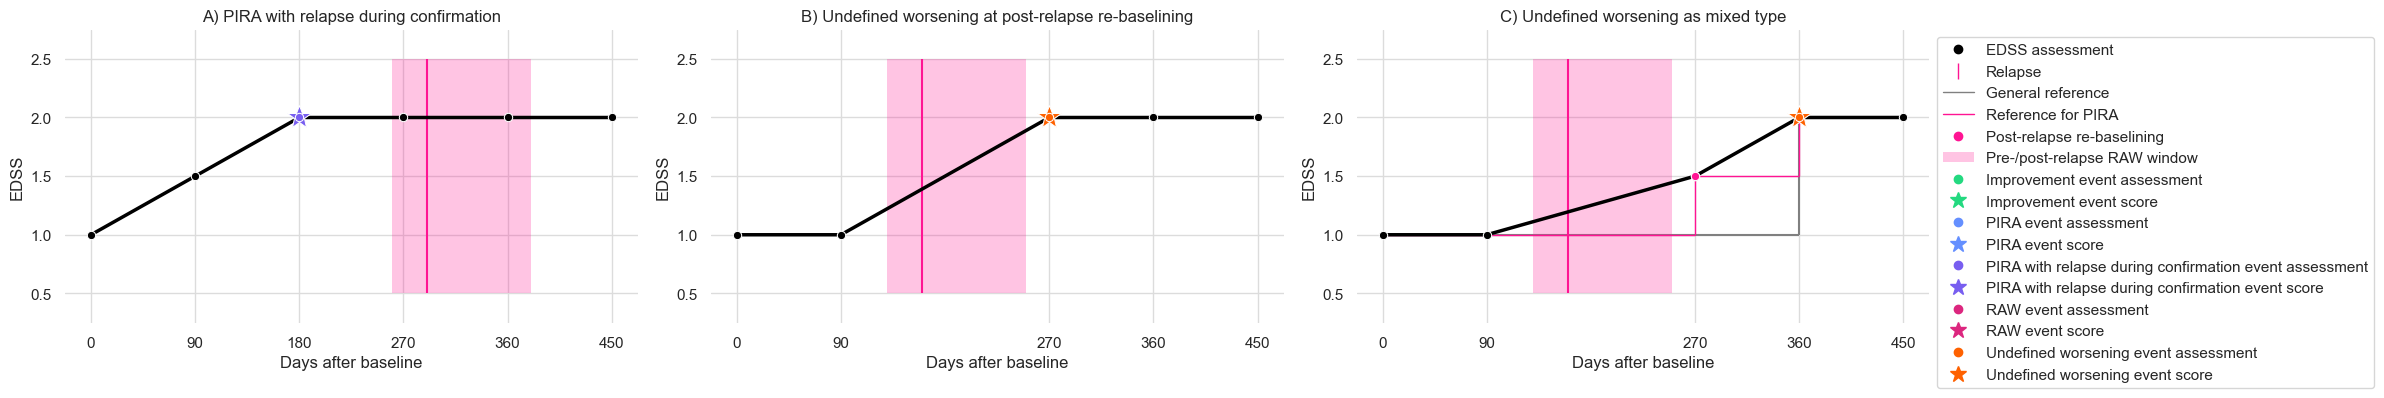

In [67]:
fig, axes = plt.subplots(1, 3, figsize=(24, 4))

visualization.annotate_plot_follow_up(
    annotation_mode=SYMMETRIC_MODE_NAME,
    follow_up_dataframe=pd.DataFrame(
        {
            "days_after_baseline": [0, 90, 180, 270, 360, 450],
            "edss_score": [1, 1.5, 2, 2, 2, 2],
        }
    ),
    relapse_timestamps=[290],
    opt_baseline_type="fixed",
    opt_require_confirmation=True,
    opt_confirmation_time=24 * 7,
    opt_raw_after_relapse_max_time=90,
    opt_raw_before_relapse_max_time=30,
    show_legend=False,
    move_legend_out=True,
    show_baselines=False,
    ax=axes[0],
)
axes[0].set_title("A) PIRA with relapse during confirmation")

visualization.annotate_plot_follow_up(
    annotation_mode=SYMMETRIC_MODE_NAME,
    follow_up_dataframe=pd.DataFrame(
        {"days_after_baseline": [0, 90, 270, 360, 450], "edss_score": [1, 1, 2, 2, 2]}
    ),
    relapse_timestamps=[160],
    opt_baseline_type="fixed",
    opt_require_confirmation=False,
    opt_confirmation_time=24 * 7,
    opt_raw_after_relapse_max_time=90,
    opt_raw_before_relapse_max_time=30,
    show_legend=False,
    move_legend_out=True,
    show_baselines=False,
    ax=axes[1],
)
axes[1].set_title("B) Undefined worsening at post-relapse re-baselining")

visualization.annotate_plot_follow_up(
    annotation_mode=SYMMETRIC_MODE_NAME,
    follow_up_dataframe=pd.DataFrame(
        {"days_after_baseline": [0, 90, 270, 360, 450], "edss_score": [1, 1, 1.5, 2, 2]}
    ),
    relapse_timestamps=[160],
    opt_baseline_type="fixed",
    opt_require_confirmation=False,
    opt_confirmation_time=24 * 7,
    opt_raw_after_relapse_max_time=90,
    opt_raw_before_relapse_max_time=30,
    show_legend=True,
    move_legend_out=True,
    show_baselines=True,
    ax=axes[2],
)
axes[2].set_title("C) Undefined worsening as mixed type")


for ax in axes:
    ax.set_xlabel("Days after baseline")

fig.tight_layout()
sns.despine(bottom=True, left=True, right=True, top=True)
plt.show()

# PIRA baseline vs. general baseline

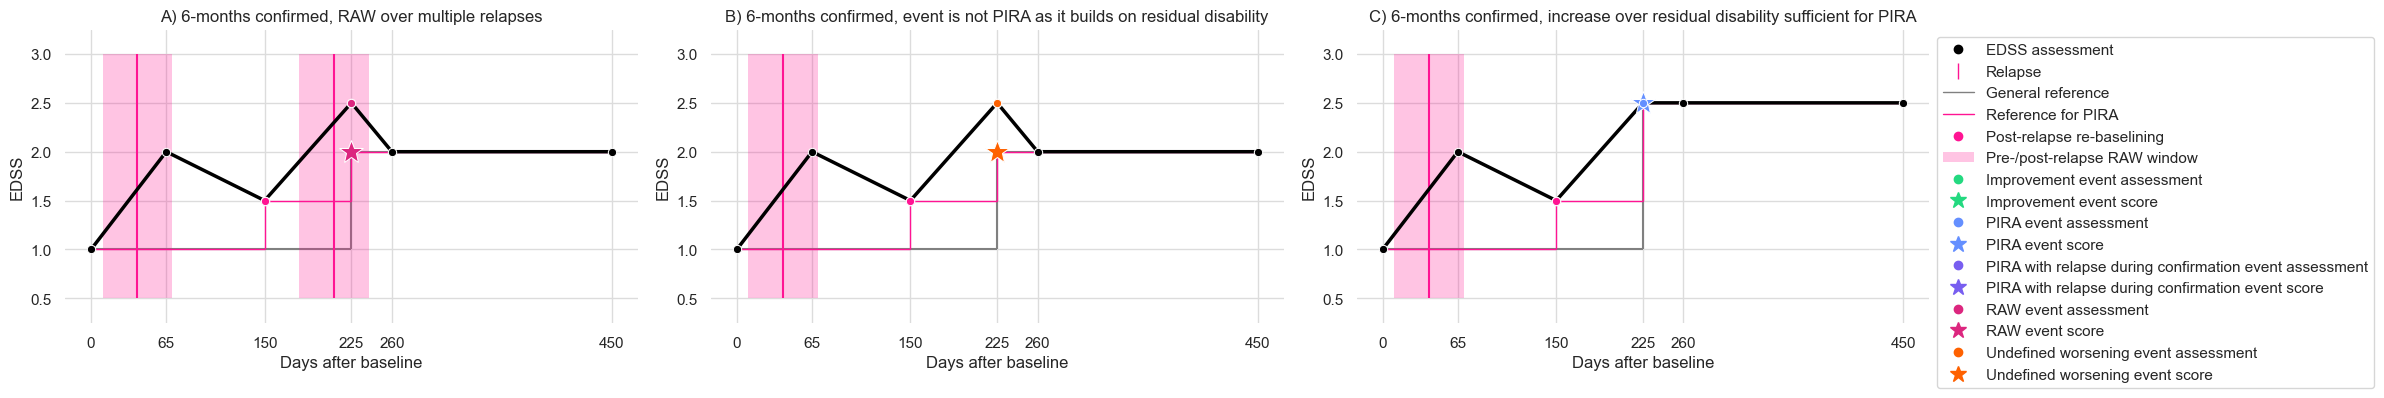

In [68]:
fig, axes = plt.subplots(1, 3, figsize=(24, 4))

visualization.annotate_plot_follow_up(
    follow_up_dataframe=pd.DataFrame(
        {
            "days_after_baseline": [0, 65, 150, 225, 260, 450],
            "edss_score": [1.0, 2.0, 1.5, 2.5, 2.0, 2.0],
        },
    ),
    relapse_timestamps=[40, 210],
    annotation_mode=SYMMETRIC_MODE_NAME,
    opt_baseline_type="fixed",
    opt_require_confirmation=True,
    opt_confirmation_time=24 * 7,
    opt_raw_after_relapse_max_time=30,
    opt_raw_before_relapse_max_time=30,
    show_legend=False,
    move_legend_out=True,
    show_baselines=True,
    ax=axes[0],
)
axes[0].set_title("A) 6-months confirmed, RAW over multiple relapses")
axes[0].set_xlabel("Days after baseline")

visualization.annotate_plot_follow_up(
    follow_up_dataframe=pd.DataFrame(
        {
            "days_after_baseline": [0, 65, 150, 225, 260, 450],
            "edss_score": [1.0, 2.0, 1.5, 2.5, 2.0, 2.0],
        },
    ),
    relapse_timestamps=[
        40,
    ],
    annotation_mode=SYMMETRIC_MODE_NAME,
    opt_baseline_type="fixed",
    opt_require_confirmation=True,
    opt_confirmation_time=24 * 7,
    opt_raw_after_relapse_max_time=30,
    opt_raw_before_relapse_max_time=30,
    show_legend=False,
    move_legend_out=True,
    show_baselines=True,
    ax=axes[1],
)
axes[1].set_title(
    "B) 6-months confirmed, event is not PIRA as it builds on residual disability"
)
axes[1].set_xlabel("Days after baseline")

visualization.annotate_plot_follow_up(
    follow_up_dataframe=pd.DataFrame(
        {
            "days_after_baseline": [0, 65, 150, 225, 260, 450],
            "edss_score": [1.0, 2.0, 1.5, 2.5, 2.5, 2.5],
        },
    ),
    relapse_timestamps=[
        40,
    ],
    annotation_mode=SYMMETRIC_MODE_NAME,
    opt_baseline_type="fixed",
    opt_require_confirmation=True,
    opt_confirmation_time=24 * 7,
    opt_raw_after_relapse_max_time=30,
    opt_raw_before_relapse_max_time=30,
    show_legend=True,
    move_legend_out=True,
    show_baselines=True,
    ax=axes[2],
)
axes[2].set_title(
    "C) 6-months confirmed, increase over residual disability sufficient for PIRA"
)
axes[2].set_xlabel("Days after baseline")


fig.tight_layout()
sns.despine(bottom=True, left=True, right=True, top=True)
plt.show()

### Roving reference consistent?

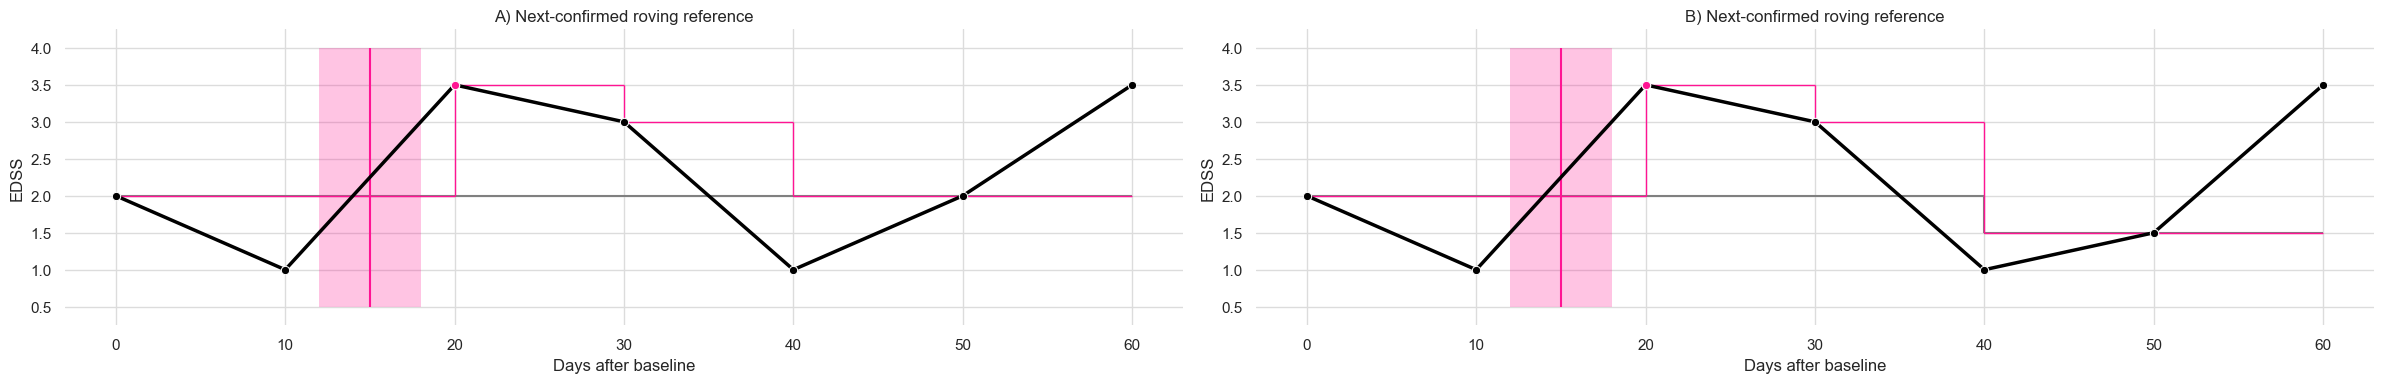

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(24, 4))

visualization.annotate_plot_follow_up(
    relapse_timestamps=[15],
    follow_up_dataframe=pd.DataFrame(
        {
            "days_after_baseline": [0, 10, 20, 30, 40, 50, 60],
            "edss_score": [2.0, 1.0, 3.5, 3.0, 1.0, 2.0, 3.5],
        }
    ),
    annotation_mode=ACCRUAL_MODE_NAME,
    opt_baseline_type="roving",
    opt_roving_reference_require_confirmation=True,
    opt_roving_reference_confirmation_time=0.5,
    opt_require_confirmation=True,
    opt_confirmation_time=-1,
    opt_raw_after_relapse_max_time=3,
    opt_raw_before_relapse_max_time=3,
    show_legend=False,
    move_legend_out=True,
    show_baselines=True,
    ax=axes[0],
)
axes[0].set_title("A) Next-confirmed roving reference")
axes[0].set_xlabel("Days after baseline")

visualization.annotate_plot_follow_up(
    relapse_timestamps=[15],
    follow_up_dataframe=pd.DataFrame(
        {
            "days_after_baseline": [0, 10, 20, 30, 40, 50, 60],
            "edss_score": [2.0, 1.0, 3.5, 3.0, 1.0, 1.5, 3.5],
        }
    ),
    annotation_mode=ACCRUAL_MODE_NAME,
    opt_baseline_type="roving",
    opt_roving_reference_require_confirmation=True,
    opt_roving_reference_confirmation_time=0.5,
    opt_require_confirmation=True,
    opt_confirmation_time=-1,
    opt_raw_after_relapse_max_time=3,
    opt_raw_before_relapse_max_time=3,
    show_legend=False,
    move_legend_out=True,
    show_baselines=True,
    ax=axes[1],
)
axes[1].set_title("B) Next-confirmed roving reference")
axes[1].set_xlabel("Days after baseline")

fig.tight_layout()
sns.despine(bottom=True, left=True, right=True, top=True)
plt.show()

## No improvement with respect to PIRA reference

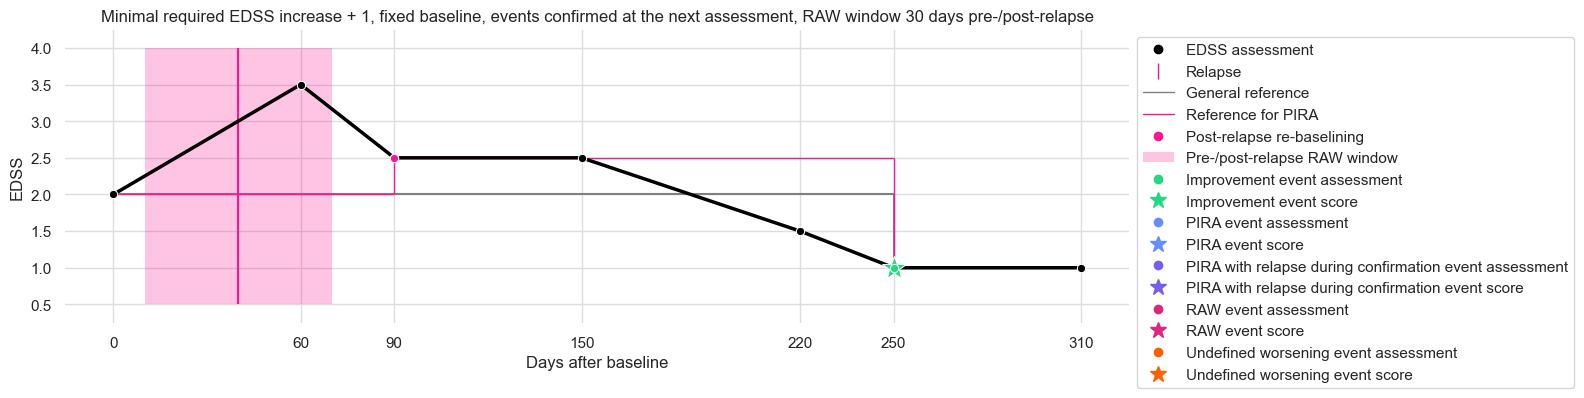

In [70]:
fig, ax = plt.subplots(1, 1, figsize=(16, 4))
example_follow_up = pd.DataFrame(
    [
        {"days_after_baseline": 0, "edss_score": 2.0},
        {"days_after_baseline": 60, "edss_score": 3.5},
        {"days_after_baseline": 90, "edss_score": 2.5},
        {"days_after_baseline": 150, "edss_score": 2.5},  # 1.5
        {"days_after_baseline": 220, "edss_score": 1.5},
        {"days_after_baseline": 250, "edss_score": 1.0},
        {"days_after_baseline": 310, "edss_score": 1.0},
    ]
)
visualization.annotate_plot_follow_up(
    annotation_mode=SYMMETRIC_MODE_NAME,
    follow_up_dataframe=example_follow_up,
    relapse_timestamps=[40],
    opt_baseline_type="fixed",
    opt_require_confirmation=True,
    opt_confirmation_time=0.5,
    opt_confirmation_included_values="all",
    opt_raw_before_relapse_max_time=30,
    opt_raw_after_relapse_max_time=30,
    show_legend=True,
    move_legend_out=True,
    ax=ax,
)
ax.set_title(
    "Minimal required EDSS increase + 1, fixed baseline, events confirmed at the next assessment, RAW window 30 days pre-/post-relapse"
)
ax.set_xlabel("Days after baseline")
fig.tight_layout()
sns.despine(bottom=True, left=True, right=True, top=True)
plt.show()

# Post-relapse re-baselining

## General rules

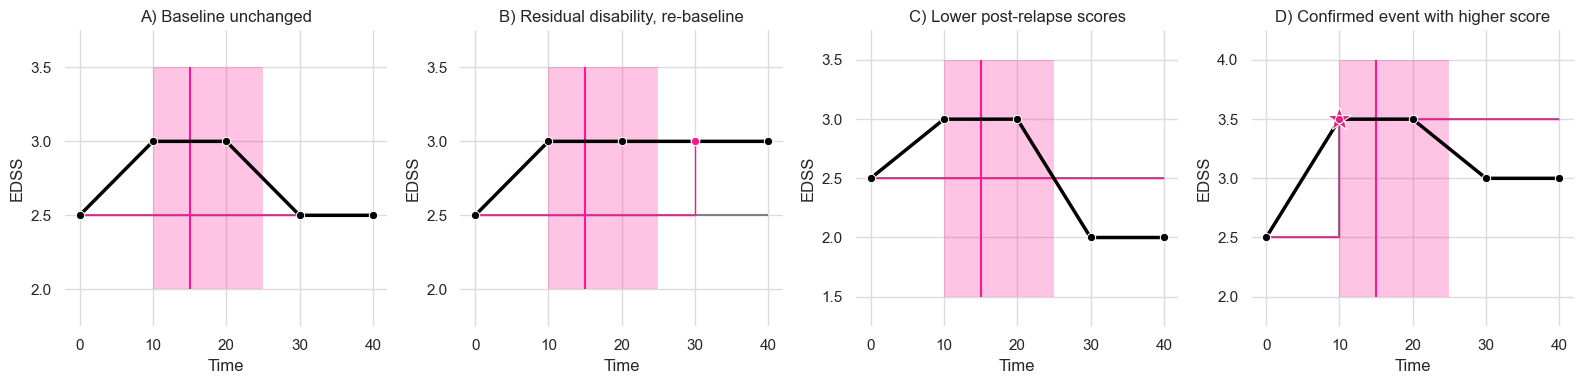

In [71]:
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
visualization.annotate_plot_follow_up(
    relapse_timestamps=[15],
    follow_up_dataframe=pd.DataFrame(
        {
            "days_after_baseline": [0, 10, 20, 30, 40],
            "edss_score": [2.5, 3, 3, 2.5, 2.5],
        }
    ),
    annotation_mode=SYMMETRIC_MODE_NAME,
    opt_baseline_type="fixed",
    opt_raw_before_relapse_max_time=5,
    opt_raw_after_relapse_max_time=10,
    opt_require_confirmation=True,
    opt_confirmation_time=0.5,
    show_baselines=True,
    show_raw_window=True,
    show_events=True,
    show_rebaselining=True,
    show_legend=False,
    ax=axes[0],
)
axes[0].set_title("A) Baseline unchanged")

visualization.annotate_plot_follow_up(
    relapse_timestamps=[15],
    follow_up_dataframe=pd.DataFrame(
        {"days_after_baseline": [0, 10, 20, 30, 40], "edss_score": [2.5, 3, 3, 3, 3]}
    ),
    annotation_mode=SYMMETRIC_MODE_NAME,
    opt_baseline_type="fixed",
    opt_raw_before_relapse_max_time=5,
    opt_raw_after_relapse_max_time=10,
    opt_require_confirmation=True,
    opt_confirmation_time=0.5,
    show_baselines=True,
    show_raw_window=True,
    show_events=True,
    show_rebaselining=True,
    show_legend=False,
    ax=axes[1],
)
axes[1].set_title("B) Residual disability, re-baseline")

visualization.annotate_plot_follow_up(
    relapse_timestamps=[15],
    follow_up_dataframe=pd.DataFrame(
        {"days_after_baseline": [0, 10, 20, 30, 40], "edss_score": [2.5, 3, 3, 2, 2]}
    ),
    annotation_mode=SYMMETRIC_MODE_NAME,
    opt_baseline_type="fixed",
    opt_raw_before_relapse_max_time=5,
    opt_raw_after_relapse_max_time=10,
    opt_require_confirmation=True,
    opt_confirmation_time=0.5,
    show_baselines=True,
    show_raw_window=True,
    show_events=True,
    show_rebaselining=True,
    show_legend=False,
    ax=axes[2],
)
axes[2].set_title("C) Lower post-relapse scores")

visualization.annotate_plot_follow_up(
    relapse_timestamps=[15],
    follow_up_dataframe=pd.DataFrame(
        {
            "days_after_baseline": [0, 10, 20, 30, 40],
            "edss_score": [2.5, 3.5, 3.5, 3, 3],
        }
    ),
    annotation_mode=SYMMETRIC_MODE_NAME,
    opt_baseline_type="fixed",
    opt_raw_before_relapse_max_time=5,
    opt_raw_after_relapse_max_time=10,
    opt_require_confirmation=True,
    opt_confirmation_time=0.5,
    show_baselines=True,
    show_raw_window=True,
    show_events=True,
    show_rebaselining=False,
    show_legend=False,
    ax=axes[3],
)
axes[3].set_title("D) Confirmed event with higher score")

fig.tight_layout()
sns.despine(bottom=True, left=True, right=True, top=True)
plt.show()

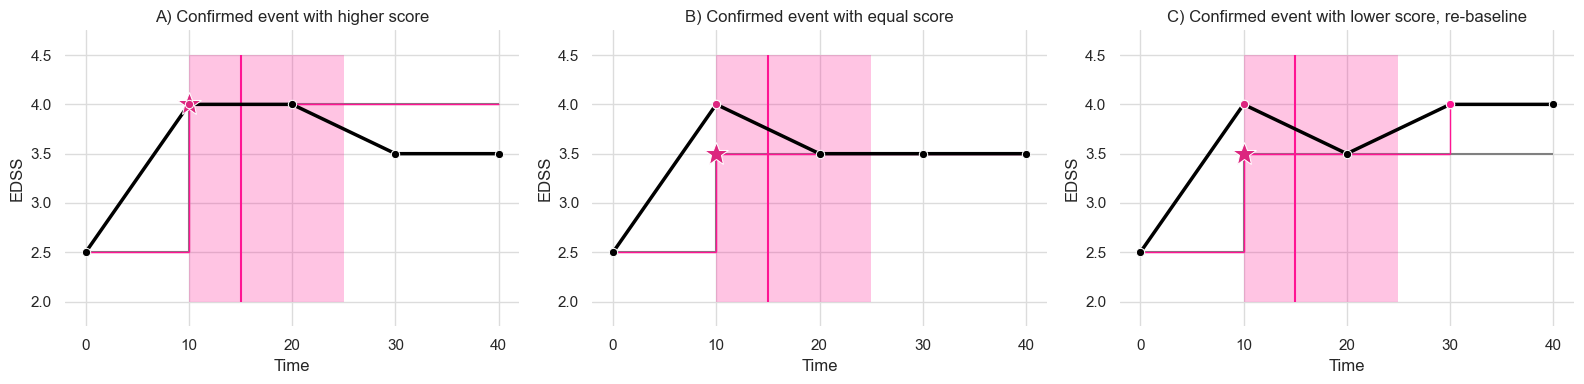

In [73]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

visualization.annotate_plot_follow_up(
    relapse_timestamps=[15],
    follow_up_dataframe=pd.DataFrame(
        {
            "days_after_baseline": [0, 10, 20, 30, 40],
            "edss_score": [2.5, 4.0, 4.0, 3.5, 3.5],
        }
    ),
    annotation_mode=SYMMETRIC_MODE_NAME,
    opt_baseline_type="fixed",
    opt_raw_before_relapse_max_time=5,
    opt_raw_after_relapse_max_time=10,
    opt_require_confirmation=True,
    opt_confirmation_time=0.5,
    show_baselines=True,
    show_raw_window=True,
    show_events=True,
    show_rebaselining=False,
    show_legend=False,
    ax=axes[0],
)

visualization.annotate_plot_follow_up(
    relapse_timestamps=[15],
    follow_up_dataframe=pd.DataFrame(
        {
            "days_after_baseline": [0, 10, 20, 30, 40],
            "edss_score": [2.5, 4.0, 3.5, 3.5, 3.5],
        }
    ),
    annotation_mode=SYMMETRIC_MODE_NAME,
    opt_baseline_type="fixed",
    opt_raw_before_relapse_max_time=5,
    opt_raw_after_relapse_max_time=10,
    opt_require_confirmation=True,
    opt_confirmation_time=0.5,
    show_baselines=True,
    show_raw_window=True,
    show_events=True,
    show_rebaselining=False,
    show_legend=False,
    ax=axes[1],
)

visualization.annotate_plot_follow_up(
    relapse_timestamps=[15],
    follow_up_dataframe=pd.DataFrame(
        {
            "days_after_baseline": [0, 10, 20, 30, 40],
            "edss_score": [2.5, 4.0, 3.5, 4.0, 4],
        }
    ),
    annotation_mode=SYMMETRIC_MODE_NAME,
    opt_baseline_type="fixed",
    opt_raw_before_relapse_max_time=5,
    opt_raw_after_relapse_max_time=10,
    opt_require_confirmation=True,
    opt_confirmation_time=0.5,
    show_baselines=True,
    show_raw_window=True,
    show_events=True,
    show_rebaselining=False,
    show_legend=False,
    ax=axes[2],
)

axes[0].set_title("A) Confirmed event with higher score")
axes[1].set_title("B) Confirmed event with equal score")
axes[2].set_title("C) Confirmed event with lower score, re-baseline")

fig.tight_layout()
sns.despine(bottom=True, left=True, right=True, top=True)
plt.show()

## Multiple relapses

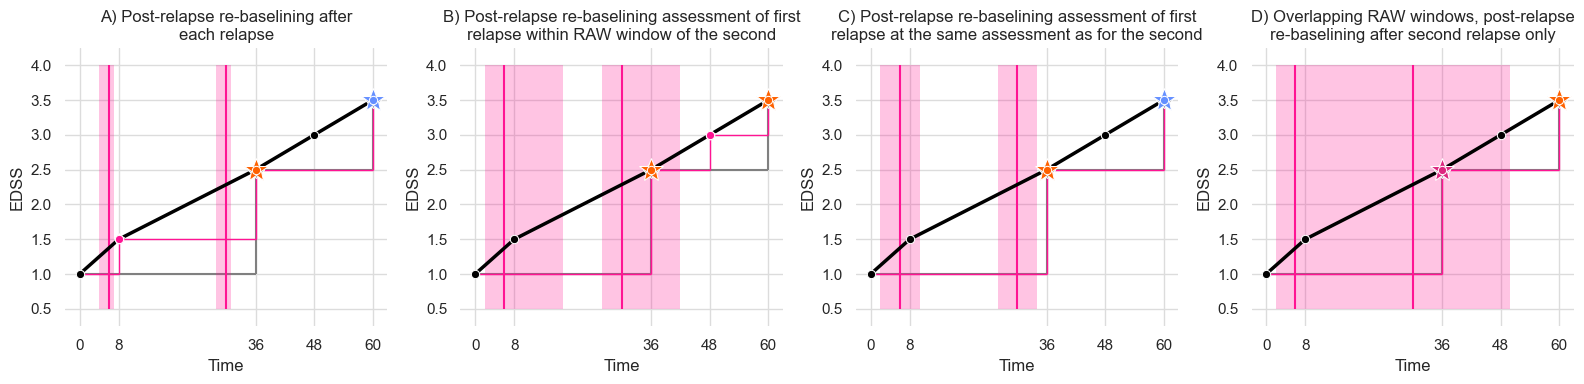

In [12]:
fig, axes = plt.subplots(1, 4, figsize=(16, 4))

visualization.annotate_plot_follow_up(
    relapse_timestamps=[6, 30],
    follow_up_dataframe=pd.DataFrame(
        {
            "days_after_baseline": [0, 8, 36, 48, 60],
            "edss_score": [1, 1.5, 2.5, 3, 3.5],
        }
    ),
    annotation_mode=SYMMETRIC_MODE_NAME,
    opt_baseline_type="fixed",
    opt_raw_before_relapse_max_time=2,
    opt_raw_after_relapse_max_time=1,
    opt_require_confirmation=False,
    show_baselines=True,
    show_raw_window=True,
    show_events=True,
    show_rebaselining=True,
    show_legend=False,
    ax=axes[0],
)

visualization.annotate_plot_follow_up(
    relapse_timestamps=[6, 30],
    follow_up_dataframe=pd.DataFrame(
        {
            "days_after_baseline": [0, 8, 36, 48, 60],
            "edss_score": [1, 1.5, 2.5, 3, 3.5],
        }
    ),
    annotation_mode=SYMMETRIC_MODE_NAME,
    opt_baseline_type="fixed",
    opt_raw_before_relapse_max_time=4,
    opt_raw_after_relapse_max_time=12,
    opt_require_confirmation=False,
    show_baselines=True,
    show_raw_window=True,
    show_events=True,
    show_rebaselining=True,
    show_legend=False,
    ax=axes[1],
)

visualization.annotate_plot_follow_up(
    relapse_timestamps=[6, 30],
    follow_up_dataframe=pd.DataFrame(
        {
            "days_after_baseline": [0, 8, 36, 48, 60],
            "edss_score": [1, 1.5, 2.5, 3, 3.5],
        }
    ),
    annotation_mode=SYMMETRIC_MODE_NAME,
    opt_baseline_type="fixed",
    opt_raw_before_relapse_max_time=4,
    opt_raw_after_relapse_max_time=4,
    opt_require_confirmation=False,
    show_baselines=True,
    show_raw_window=True,
    show_events=True,
    show_rebaselining=True,
    show_legend=False,
    ax=axes[2],
)

visualization.annotate_plot_follow_up(
    relapse_timestamps=[6, 30],
    follow_up_dataframe=pd.DataFrame(
        {
            "days_after_baseline": [0, 8, 36, 48, 60],
            "edss_score": [1, 1.5, 2.5, 3, 3.5],
        }
    ),
    annotation_mode=SYMMETRIC_MODE_NAME,
    opt_baseline_type="fixed",
    opt_raw_before_relapse_max_time=4,
    opt_raw_after_relapse_max_time=20,
    opt_require_confirmation=False,
    show_baselines=True,
    show_raw_window=True,
    show_events=True,
    show_rebaselining=True,
    show_legend=False,
    ax=axes[3],
)

axes[0].set_title("A) Post-relapse re-baselining after\neach relapse")
axes[1].set_title(
    "B) Post-relapse re-baselining assessment of first\nrelapse within RAW window of the second"
)
axes[2].set_title(
    "C) Post-relapse re-baselining assessment of first\nrelapse at the same assessment as for the second"
)
axes[3].set_title(
    "D) Overlapping RAW windows, post-relapse\nre-baselining after second relapse only"
)


fig.tight_layout()
sns.despine(bottom=True, left=True, right=True, top=True)
plt.show()

**Legend**: Note that events at post-relapse re-baselining assessment are always classified as undefined, even if they are within
the RAW window of a subsequent relapse.

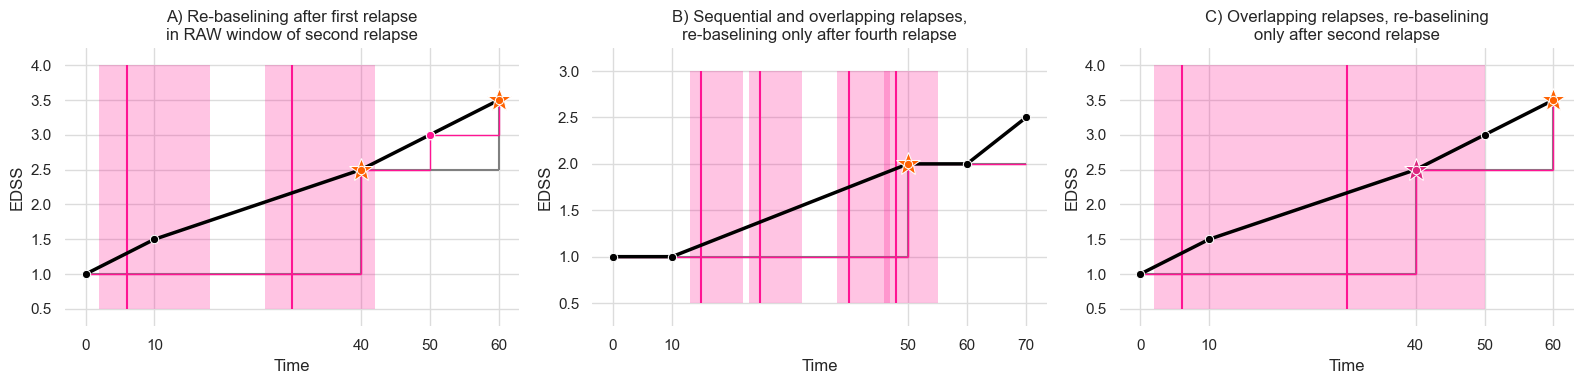

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

test_relapses_cases_1_2_3_4 = [6, 30]
test_dataframe_cases_1_2_3_4 = pd.DataFrame(
    {"days_after_baseline": [0, 10, 40, 50, 60], "edss_score": [1, 1.5, 2.5, 3, 3.5]}
)

visualization.annotate_plot_follow_up(
    relapse_timestamps=test_relapses_cases_1_2_3_4,
    follow_up_dataframe=test_dataframe_cases_1_2_3_4,
    annotation_mode=SYMMETRIC_MODE_NAME,
    opt_baseline_type="fixed",
    # PRA/RAW
    opt_raw_before_relapse_max_time=4,
    opt_raw_after_relapse_max_time=12,
    show_baselines=True,
    show_raw_window=True,
    show_rebaselining=False,
    show_legend=False,
    move_legend_out=False,
    legend_loc="best",
    ax=axes[0],
)
visualization.annotate_plot_follow_up(
    relapse_timestamps=[15, 25, 40, 48],
    follow_up_dataframe=pd.DataFrame(
        {
            "days_after_baseline": [0, 10, 50, 60, 70],
            "edss_score": [1, 1, 2, 2, 2.5],
        }
    ),
    annotation_mode=SYMMETRIC_MODE_NAME,
    opt_baseline_type="fixed",
    # PRA/RAW
    opt_raw_before_relapse_max_time=2,
    opt_raw_after_relapse_max_time=7,
    show_baselines=True,
    show_raw_window=True,
    show_rebaselining=False,
    show_legend=False,
    ax=axes[1],
)
visualization.annotate_plot_follow_up(
    relapse_timestamps=test_relapses_cases_1_2_3_4,
    follow_up_dataframe=test_dataframe_cases_1_2_3_4,
    annotation_mode=SYMMETRIC_MODE_NAME,
    opt_baseline_type="fixed",
    # PRA/RAW
    opt_raw_before_relapse_max_time=4,
    opt_raw_after_relapse_max_time=20,
    show_baselines=True,
    show_raw_window=True,
    show_rebaselining=False,
    show_legend=False,
    move_legend_out=False,
    legend_loc="best",
    ax=axes[2],
)

axes[0].set_title(
    "A) Re-baselining after first relapse\nin RAW window of second relapse"
)
axes[1].set_title(
    "B) Sequential and overlapping relapses,\nre-baselining only after fourth relapse"
)
axes[2].set_title("C) Overlapping relapses, re-baselining\nonly after second relapse")

fig.tight_layout()
sns.despine(bottom=True, left=True, right=True, top=True)
plt.show()

**Legend**: Events at post-relapse re-baselining assessment are always classified as undefined, even if they are within
the RAW window of a subsequent relapse.

## Undefined events with event scores that lower the PIRA reference from post-relapse re-baselining

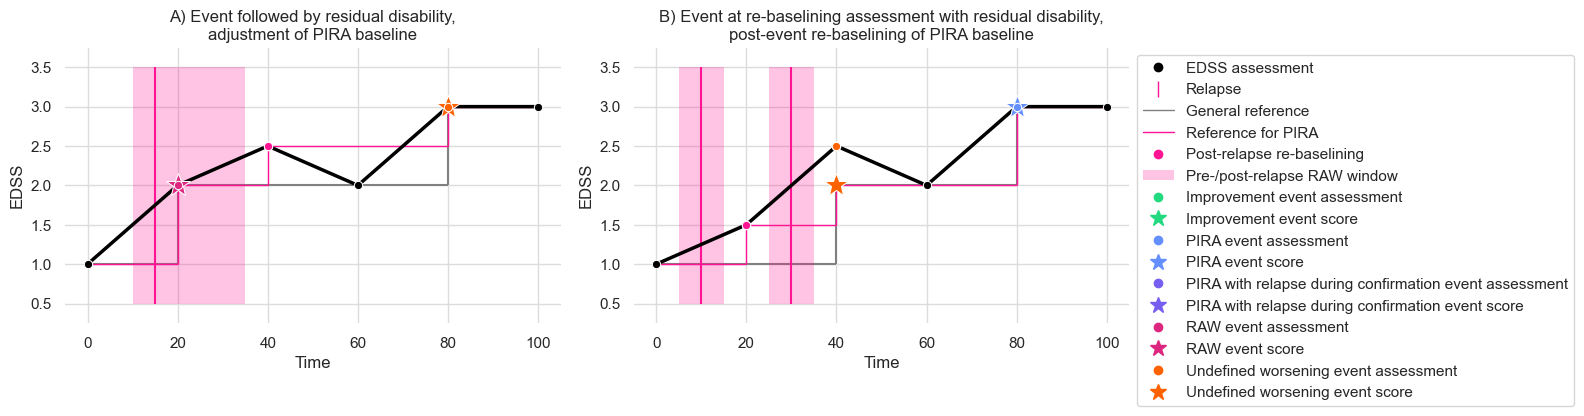

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(16, 4))

visualization.annotate_plot_follow_up(
    relapse_timestamps=[15],
    follow_up_dataframe=pd.DataFrame(
        {
            "days_after_baseline": [0, 20, 40, 60, 80, 100],
            "edss_score": [1, 2.0, 2.5, 2, 3, 3],
        }
    ),
    annotation_mode=SYMMETRIC_MODE_NAME,
    opt_baseline_type="fixed",
    opt_require_confirmation=True,
    opt_confirmation_time=0.5,
    opt_raw_before_relapse_max_time=5,
    opt_raw_after_relapse_max_time=20,
    show_baselines=True,
    show_raw_window=True,
    show_rebaselining=False,
    show_legend=False,
    ax=axes[0],
)

visualization.annotate_plot_follow_up(
    relapse_timestamps=[10, 30],
    follow_up_dataframe=pd.DataFrame(
        {
            "days_after_baseline": [0, 20, 40, 60, 80, 100],
            "edss_score": [1, 1.5, 2.5, 2, 3, 3],
        }
    ),
    annotation_mode=SYMMETRIC_MODE_NAME,
    opt_baseline_type="fixed",
    opt_require_confirmation=True,
    opt_confirmation_time=0.5,
    opt_raw_before_relapse_max_time=5,
    opt_raw_after_relapse_max_time=5,
    show_baselines=True,
    show_raw_window=True,
    show_rebaselining=False,
    show_legend=True,
    ax=axes[1],
)

axes[0].set_title(
    "A) Event followed by residual disability,\nadjustment of PIRA baseline"
)
axes[1].set_title(
    "B) Event at re-baselining assessment with residual disability,\npost-event re-baselining of PIRA baseline"
)

fig.tight_layout()
sns.despine(bottom=True, left=True, right=True, top=True)
plt.show()

**Legend**: After an event, both baselines are reset to the confirmed event score, even if there was residual disability.
The lower event score implies that this residual disability was not confirmed, so it is not considered as contributing
to subsequent events.

## With minimal distance

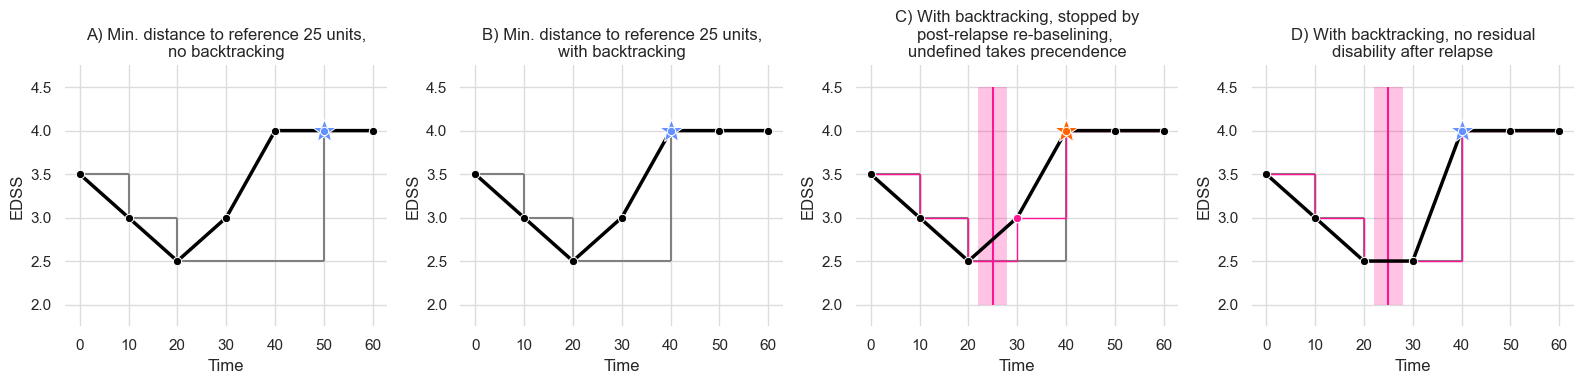

In [78]:
fig, axes = plt.subplots(1, 4, figsize=(16, 4))

test_dataframe = pd.DataFrame(
    {
        "days_after_baseline": [0, 10, 20, 30, 40, 50, 60],
        "edss_score": [3.5, 3, 2.5, 3, 4, 4, 4],
    }
)
test_options = [
    ([], 25, False, "A) Min. distance to reference 25 units,\nno backtracking"),
    ([], 25, True, "B) Min. distance to reference 25 units,\nwith backtracking"),
    (
        [25],
        25,
        True,
        "C) With backtracking, stopped by\npost-relapse re-baselining, \nundefined takes precendence",
    ),
    ([25], 25, True, "D) With backtracking, no residual\ndisability after relapse"),
]

for i, test_option in enumerate(test_options):
    if i < 3:
        visualization.annotate_plot_follow_up(
            relapse_timestamps=test_option[0],
            follow_up_dataframe=test_dataframe,
            annotation_mode=ACCRUAL_MODE_NAME,
            opt_baseline_type="roving",
            opt_roving_reference_require_confirmation=False,
            opt_raw_before_relapse_max_time=3,
            opt_raw_after_relapse_max_time=3,
            opt_require_confirmation=False,
            opt_minimal_distance_time=test_option[1],
            opt_minimal_distance_type="reference",
            opt_minimal_distance_backtrack_decrease=test_option[2],
            show_baselines=True,
            show_raw_window=True,
            show_rebaselining=False,
            show_legend=False,
            ax=axes[i],
        )
    else:
        test_dataframe.at[3, "edss_score"] = 2.5
        visualization.annotate_plot_follow_up(
            relapse_timestamps=test_option[0],
            follow_up_dataframe=test_dataframe,
            annotation_mode=ACCRUAL_MODE_NAME,
            opt_baseline_type="roving",
            opt_roving_reference_require_confirmation=False,
            opt_raw_before_relapse_max_time=3,
            opt_raw_after_relapse_max_time=3,
            opt_require_confirmation=False,
            opt_minimal_distance_time=test_option[1],
            opt_minimal_distance_type="reference",
            opt_minimal_distance_backtrack_decrease=test_option[2],
            show_baselines=True,
            show_raw_window=True,
            show_rebaselining=False,
            show_legend=False,
            ax=axes[i],
        )
    axes[i].set_title(test_option[3])


fig.tight_layout()
sns.despine(bottom=True, left=True, right=True, top=True)
plt.show()

**Legend**: Minimal distance to reference 25 units. **A)** No backtracking, event at 50 because 40 is too close.
**B)** With backtracking, event at 40 w.r.t. backtracked reference at 10. **C)** Post-relapse re-baselining stops
backtracking for PIRA reference but not for the general reference, thus there is an undefined event at step 40 (and
not a PIRA event at step 50). **D)** No residual disability, i.e. backtracking of PIRA reference possible, and the
event at step 40 is PIRA because PIRA takes precedence over undefined if they can happen at the same assessment.

# Undefined progression

## Reasons for undefined

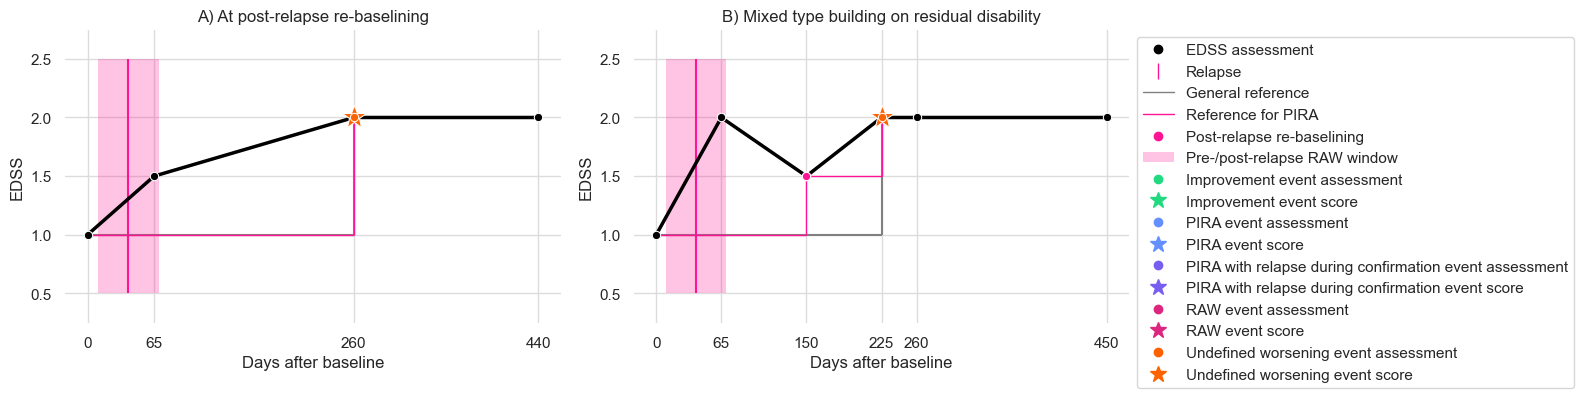

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(16, 4))

visualization.annotate_plot_follow_up(
    follow_up_dataframe=pd.DataFrame(
        {
            "days_after_baseline": [0, 65, 260, 440],
            "edss_score": [1.0, 1.5, 2.0, 2.0],
        }
    ),
    relapse_timestamps=[40],
    annotation_mode=SYMMETRIC_MODE_NAME,
    opt_baseline_type="fixed",
    opt_require_confirmation=False,
    opt_raw_after_relapse_max_time=30,
    opt_raw_before_relapse_max_time=30,
    show_legend=False,
    move_legend_out=True,
    show_baselines=True,
    ax=axes[0],
)
axes[0].set_title("A) At post-relapse re-baselining")

visualization.annotate_plot_follow_up(
    follow_up_dataframe=pd.DataFrame(
        {
            "days_after_baseline": [0, 65, 150, 225, 260, 450],
            "edss_score": [1.0, 2.0, 1.5, 2.0, 2.0, 2.0],
        },
    ),
    relapse_timestamps=[40],
    annotation_mode=SYMMETRIC_MODE_NAME,
    opt_baseline_type="fixed",
    opt_require_confirmation=True,
    opt_confirmation_time=24 * 7,
    opt_raw_after_relapse_max_time=30,
    opt_raw_before_relapse_max_time=30,
    show_legend=True,
    move_legend_out=True,
    show_baselines=True,
    ax=axes[1],
)
axes[1].set_title("B) Mixed type building on residual disability")

for ax in axes:
    ax.set_xlabel("Days after baseline")


fig.tight_layout()
sns.despine(bottom=True, left=True, right=True, top=True)
plt.show()

## No event masking in default 'all' mode

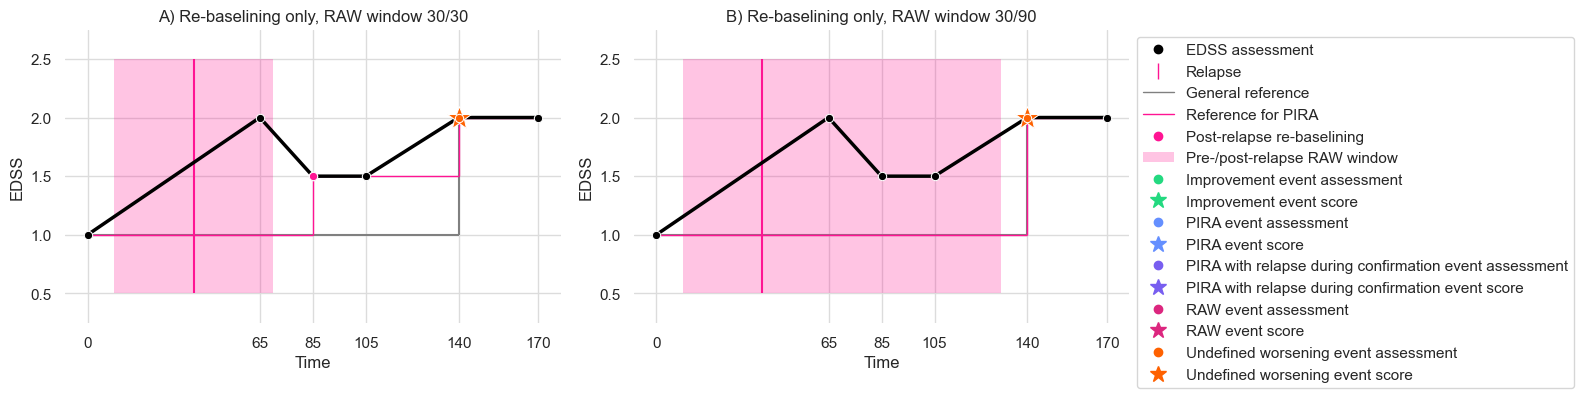

In [83]:
fig, axes = plt.subplots(1, 2, figsize=(16, 4))

test_dataframe = pd.DataFrame(
    {
        "days_after_baseline": [0, 65, 85, 105, 140, 170],
        "edss_score": [1, 2, 1.5, 1.5, 2, 2],
    }
)
test_options = [
    (False, 30, False),
    (False, 90, True),
]

for i, test_option in enumerate(test_options):
    visualization.annotate_plot_follow_up(
        relapse_timestamps=[40],
        follow_up_dataframe=test_dataframe,
        annotation_mode=SYMMETRIC_MODE_NAME,
        opt_baseline_type="fixed",
        return_first_event_only=test_option[0],
        opt_raw_before_relapse_max_time=30,
        opt_raw_after_relapse_max_time=test_option[1],
        opt_require_confirmation=True,
        opt_confirmation_time=0.5,
        show_baselines=True,
        show_raw_window=True,
        show_rebaselining=False,
        show_legend=test_option[2],
        ax=axes[i],
    )
axes[0].set_title("A) Re-baselining only, RAW window 30/30")
axes[1].set_title("B) Re-baselining only, RAW window 30/90")
fig.tight_layout()
sns.despine(bottom=True, left=True, right=True, top=True)
plt.show()

## Undefined events in RAW window

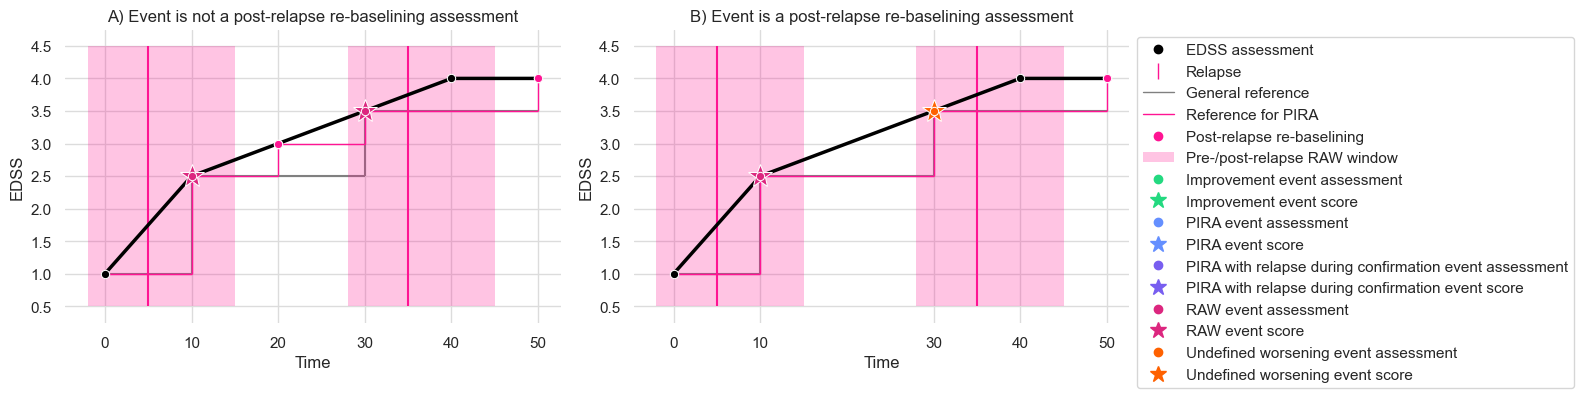

In [84]:
fig, axes = plt.subplots(1, 2, figsize=(16, 4))

visualization.annotate_plot_follow_up(
    relapse_timestamps=[5, 35],
    follow_up_dataframe=pd.DataFrame(
        {
            "days_after_baseline": [
                0,
                10,
                20,
                30,
                40,
                50,
            ],
            "edss_score": [1, 2.5, 3.0, 3.5, 4.0, 4.0],
        }
    ),
    annotation_mode=SYMMETRIC_MODE_NAME,
    opt_baseline_type="fixed",
    opt_raw_before_relapse_max_time=7,
    opt_raw_after_relapse_max_time=10,
    show_baselines=True,
    show_raw_window=True,
    show_rebaselining=False,
    show_legend=False,
    ax=axes[0],
)
axes[0].set_title("A) Event is not a post-relapse re-baselining assessment")

visualization.annotate_plot_follow_up(
    relapse_timestamps=[5, 35],
    follow_up_dataframe=pd.DataFrame(
        {
            "days_after_baseline": [
                0,
                10,
                30,
                40,
                50,
            ],
            "edss_score": [1, 2.5, 3.5, 4.0, 4.0],
        }
    ),
    annotation_mode=SYMMETRIC_MODE_NAME,
    opt_baseline_type="fixed",
    opt_raw_before_relapse_max_time=7,
    opt_raw_after_relapse_max_time=10,
    show_baselines=True,
    show_raw_window=True,
    show_rebaselining=False,
    show_legend=True,
    ax=axes[1],
)
axes[1].set_title("B) Event is a post-relapse re-baselining assessment")
fig.tight_layout()
sns.despine(bottom=True, left=True, right=True, top=True)
plt.show()

**Legend**: Events are classified as RAW if they happen within the RAW window of a relapse and not at a post-relapse
re-baselining assessment. Thus, it is possible to have events classified as undefined within a RAW window. In **B)**
we don't know if the increase from 2.5 to 3.5 happened within the RAW window of the first relapse or in the relapse-free
period between the first and second relapse.

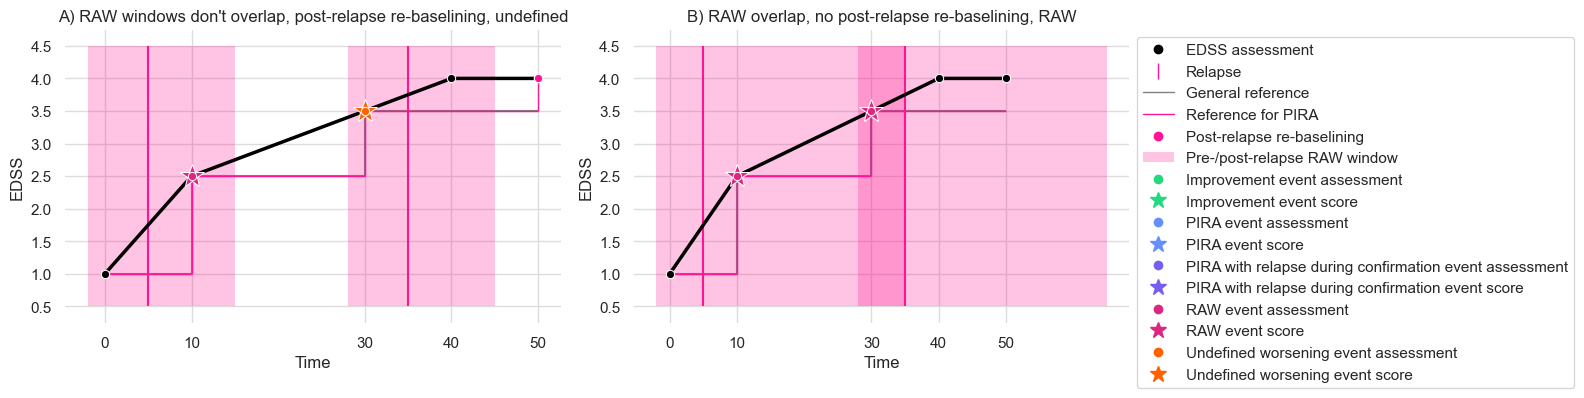

In [85]:
fig, axes = plt.subplots(1, 2, figsize=(16, 4))

example_follow_up = pd.DataFrame(
    {
        "days_after_baseline": [
            0,
            10,
            30,
            40,
            50,
        ],
        "edss_score": [1, 2.5, 3.5, 4.0, 4.0],
    }
)

visualization.annotate_plot_follow_up(
    relapse_timestamps=[5, 35],
    follow_up_dataframe=example_follow_up,
    annotation_mode=SYMMETRIC_MODE_NAME,
    opt_baseline_type="fixed",
    opt_raw_before_relapse_max_time=7,
    opt_raw_after_relapse_max_time=10,
    show_baselines=True,
    show_raw_window=True,
    show_rebaselining=False,
    show_legend=False,
    ax=axes[0],
)

visualization.annotate_plot_follow_up(
    relapse_timestamps=[5, 35],
    follow_up_dataframe=example_follow_up,
    annotation_mode=SYMMETRIC_MODE_NAME,
    opt_baseline_type="fixed",
    opt_raw_before_relapse_max_time=7,
    opt_raw_after_relapse_max_time=30,
    show_baselines=True,
    show_raw_window=True,
    show_rebaselining=False,
    show_legend=True,
    ax=axes[1],
)

axes[0].set_title("A) RAW windows don't overlap, post-relapse re-baselining, undefined")
axes[1].set_title("B) RAW overlap, no post-relapse re-baselining, RAW")

fig.tight_layout()
sns.despine(bottom=True, left=True, right=True, top=True)
plt.show()

## Example of cumulative RAW

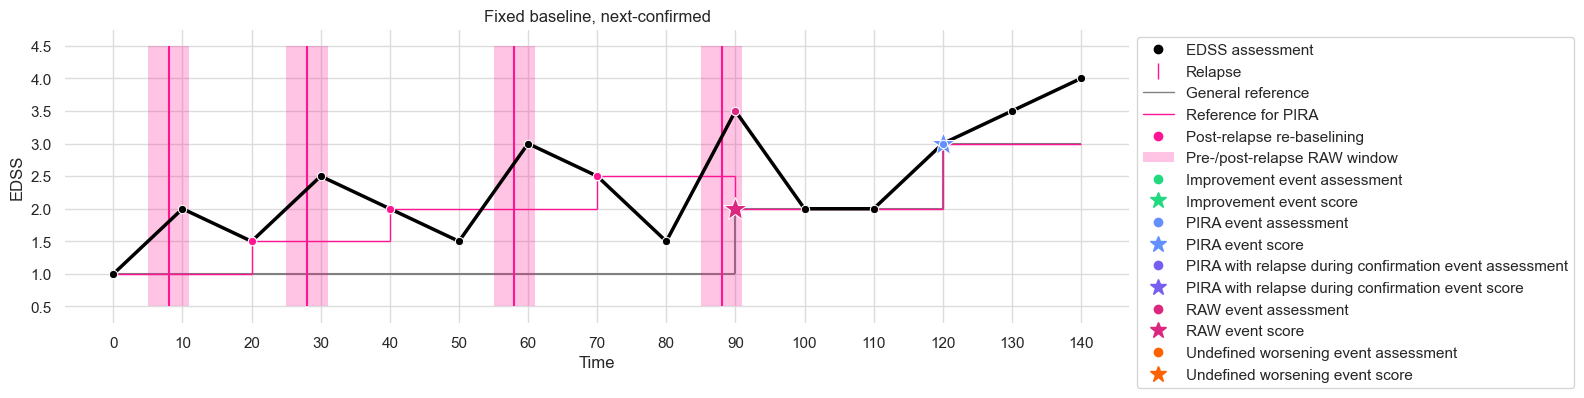

In [86]:
fig, ax = plt.subplots(1, 1, figsize=(16, 4))

test_df_4 = pd.DataFrame(
    {
        "days_after_baseline": [
            0,
            10,
            20,
            30,
            40,
            50,
            60,
            70,
            80,
            90,
            100,
            110,
            120,
            130,
            140,
        ],
        "edss_score": [
            1.0,
            2.0,
            1.5,
            2.5,
            2.0,
            1.5,
            3.0,
            2.5,
            1.5,
            3.5,
            2.0,
            2.0,
            3.0,
            3.5,
            4.0,
        ],
    }
)


visualization.annotate_plot_follow_up(
    follow_up_dataframe=test_df_4,
    relapse_timestamps=[8, 28, 58, 88],
    annotation_mode=SYMMETRIC_MODE_NAME,
    opt_baseline_type="fixed",
    opt_roving_reference_require_confirmation=True,
    opt_roving_reference_confirmation_time=0.5,
    opt_require_confirmation=True,
    opt_confirmation_time=-1,
    opt_raw_after_relapse_max_time=3,
    opt_raw_before_relapse_max_time=3,
    show_legend=True,
    move_legend_out=True,
    ax=ax,
)
ax.set_title("Fixed baseline, next-confirmed")

fig.tight_layout()
sns.despine(bottom=True, left=True, right=True, top=True)
plt.show()

# Undefined options - all (default), re-baselining only, never

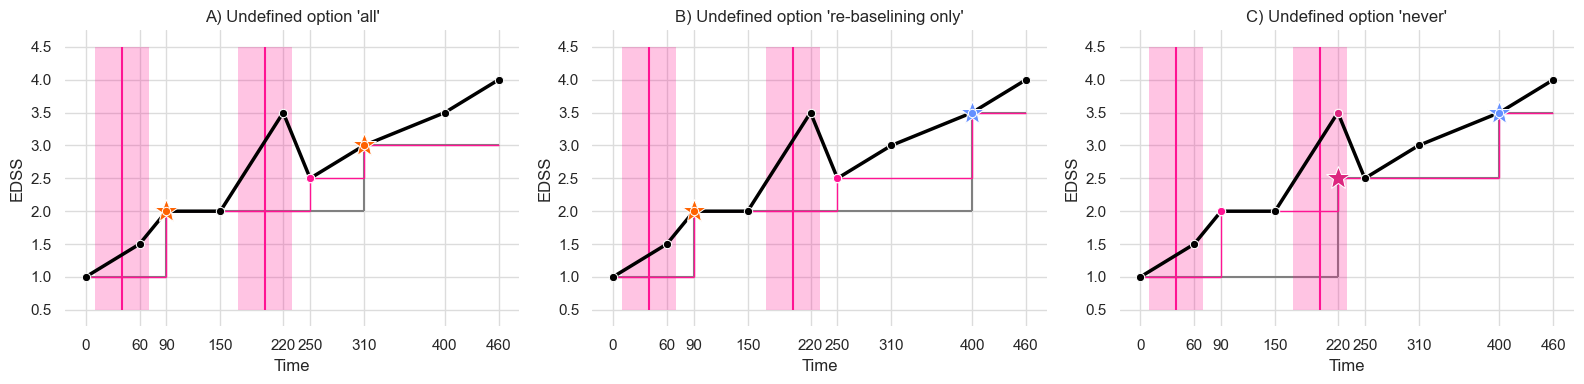

In [87]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

example_follow_up = pd.DataFrame(
    [
        {"days_after_baseline": 0, "edss_score": 1.0},
        {"days_after_baseline": 60, "edss_score": 1.5},
        {"days_after_baseline": 90, "edss_score": 2.0},
        {"days_after_baseline": 150, "edss_score": 2.0},
        {"days_after_baseline": 220, "edss_score": 3.5},
        {"days_after_baseline": 250, "edss_score": 2.5},
        {"days_after_baseline": 310, "edss_score": 3.0},
        {"days_after_baseline": 400, "edss_score": 3.5},
        {"days_after_baseline": 460, "edss_score": 4.0},
    ]
)

undef_options = ["all", "re-baselining only", "never"]

for i, undef_option in enumerate(undef_options):
    visualization.annotate_plot_follow_up(
        relapse_timestamps=[40, 200],
        follow_up_dataframe=example_follow_up,
        annotation_mode=SYMMETRIC_MODE_NAME,
        opt_baseline_type="fixed",
        undefined_events_annotation_mode=undef_option,
        opt_raw_before_relapse_max_time=30,
        opt_raw_after_relapse_max_time=30,
        opt_require_confirmation=True,
        opt_confirmation_time=0.5,
        show_baselines=True,
        show_raw_window=True,
        show_rebaselining=False,
        show_legend=False,
        ax=axes[i],
    )
    axes[i].set_title("ABC"[i] + ") Undefined option '" + undef_option + "'")

fig.tight_layout()
sns.despine(bottom=True, left=True, right=True, top=True)
plt.show()

# Relapses and confirmation

## Undefined events can be below the PIRA reference

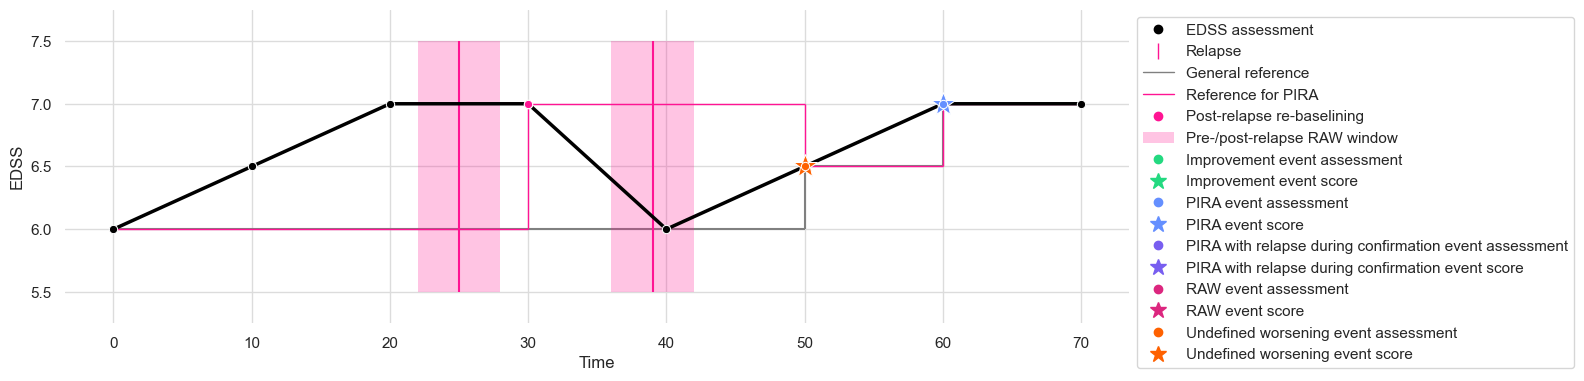

In [88]:
fig, ax = plt.subplots(1, 1, figsize=(16, 4))

visualization.annotate_plot_follow_up(
    relapse_timestamps=[25, 39],
    follow_up_dataframe=pd.DataFrame(
        {
            "days_after_baseline": [0, 10, 20, 30, 40, 50, 60, 70],
            "edss_score": [6.0, 6.5, 7.0, 7.0, 6.0, 6.5, 7.0, 7.0],
        }
    ),
    annotation_mode=SYMMETRIC_MODE_NAME,
    opt_baseline_type="fixed",
    opt_raw_before_relapse_max_time=3,
    opt_raw_after_relapse_max_time=3,
    opt_require_confirmation=True,
    opt_confirmation_time=-1,
    opt_confirmation_included_values="all",
    show_baselines=True,
    show_raw_window=True,
    show_rebaselining=False,
    show_legend=True,
    ax=ax,
)

fig.tight_layout()
sns.despine(bottom=True, left=True, right=True, top=True)
plt.show()

## Allow/don't allow relapses in confirmation interval for last-confirmed.

### Allow/don't allow

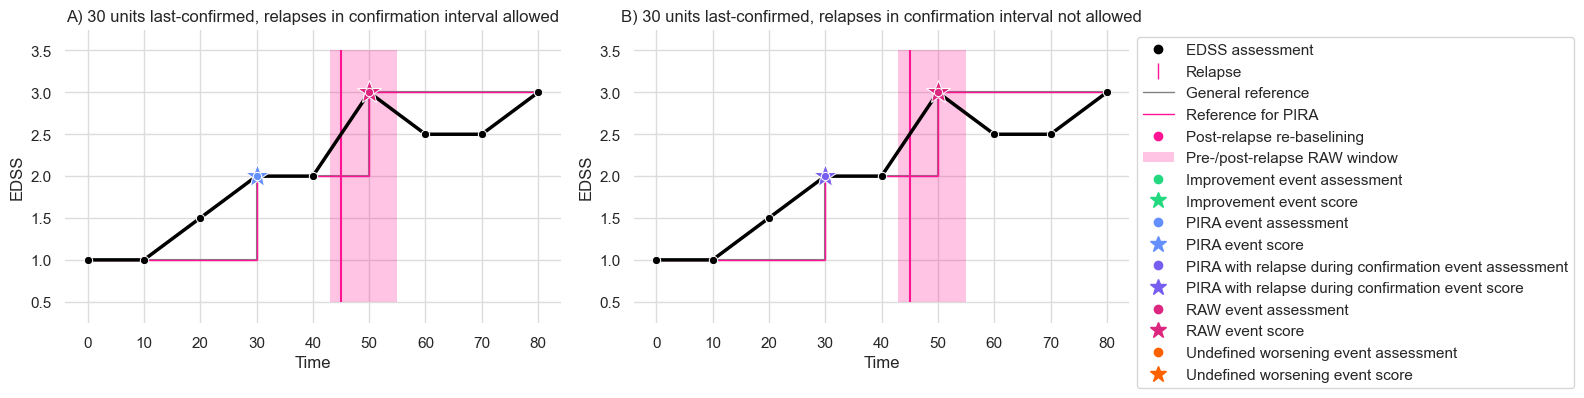

In [89]:
fig, axes = plt.subplots(1, 2, figsize=(16, 4))

test_dataframe = pd.DataFrame(
    {
        "days_after_baseline": [0, 10, 20, 30, 40, 50, 60, 70, 80],
        "edss_score": [1, 1, 1.5, 2.0, 2.0, 3.0, 2.5, 2.5, 3.0],
    }
)
test_options = [
    (
        2,
        10,
        True,
        30,
        "last",
        True,
        "A) 30 units last-confirmed, relapses in confirmation interval allowed",
    ),
    (
        2,
        10,
        True,
        30,
        "last",
        False,
        "B) 30 units last-confirmed, relapses in confirmation interval not allowed",
    ),
]

for i, test_option in enumerate(test_options):
    visualization.annotate_plot_follow_up(
        relapse_timestamps=[45],
        follow_up_dataframe=test_dataframe,
        annotation_mode=SYMMETRIC_MODE_NAME,
        opt_raw_before_relapse_max_time=test_option[0],
        opt_raw_after_relapse_max_time=test_option[1],
        opt_require_confirmation=test_option[2],
        opt_confirmation_time=test_option[3],
        opt_confirmation_included_values=test_option[4],
        opt_pira_allow_relapses_between_event_and_confirmation=test_option[5],
        opt_baseline_type="fixed",
        show_baselines=True,
        show_raw_window=True,
        show_rebaselining=False,
        show_legend=not test_option[5],
        ax=axes[i],
    )
    axes[i].set_title(test_option[6])

fig.tight_layout()
sns.despine(bottom=True, left=True, right=True, top=True)
plt.show()

### Effect of RAW window size

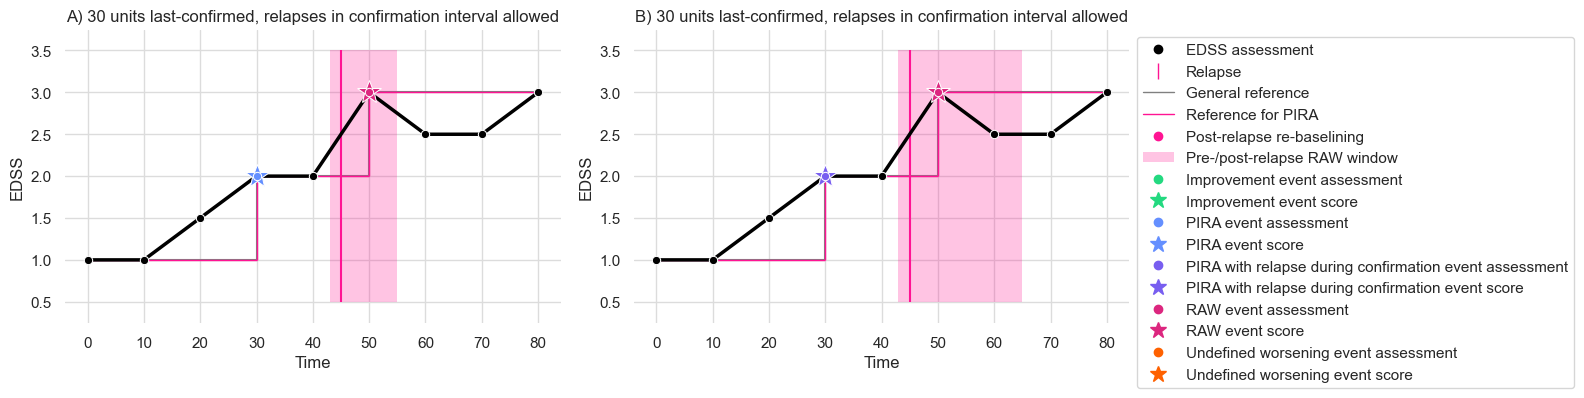

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 4))

test_dataframe = pd.DataFrame(
    {
        "days_after_baseline": [0, 10, 20, 30, 40, 50, 60, 70, 80],
        "edss_score": [1, 1, 1.5, 2.0, 2.0, 3.0, 2.5, 2.5, 3.0],
    }
)
test_options = [
    (
        2,
        10,
        True,
        30,
        "last",
        True,
        "A) 30 units last-confirmed, relapses in confirmation interval allowed",
        False,
    ),
    (
        2,
        20,
        True,
        30,
        "last",
        True,
        "B) 30 units last-confirmed, relapses in confirmation interval allowed",
        True,
    ),
]

for i, test_option in enumerate(test_options):
    visualization.annotate_plot_follow_up(
        relapse_timestamps=[45],
        follow_up_dataframe=test_dataframe,
        annotation_mode=SYMMETRIC_MODE_NAME,
        opt_raw_before_relapse_max_time=test_option[0],
        opt_raw_after_relapse_max_time=test_option[1],
        opt_require_confirmation=test_option[2],
        opt_confirmation_time=test_option[3],
        opt_confirmation_included_values=test_option[4],
        opt_pira_allow_relapses_between_event_and_confirmation=test_option[5],
        opt_baseline_type="fixed",
        show_baselines=True,
        show_raw_window=True,
        show_rebaselining=False,
        show_legend=test_option[7],
        ax=axes[i],
    )
    axes[i].set_title(test_option[6])

fig.tight_layout()
sns.despine(bottom=True, left=True, right=True, top=True)
plt.show()

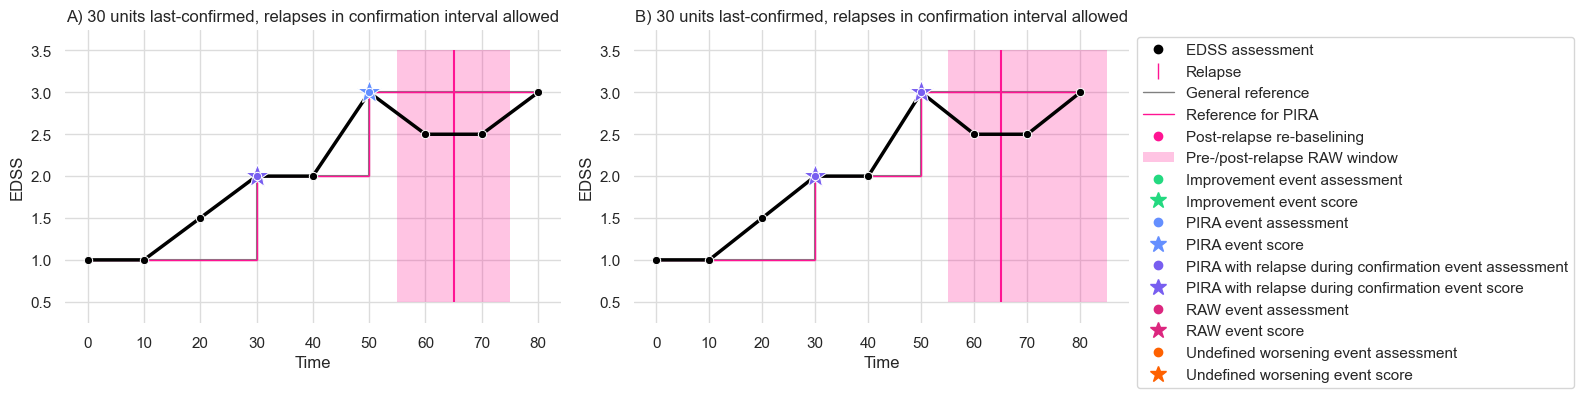

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 4))

test_dataframe = pd.DataFrame(
    {
        "days_after_baseline": [0, 10, 20, 30, 40, 50, 60, 70, 80],
        "edss_score": [1, 1, 1.5, 2.0, 2.0, 3.0, 2.5, 2.5, 3.0],
    }
)
test_options = [
    (
        10,
        10,
        True,
        30,
        "last",
        True,
        "A) 30 units last-confirmed, relapses in confirmation interval allowed",
        False,
    ),
    (
        10,
        20,
        True,
        30,
        "last",
        True,
        "B) 30 units last-confirmed, relapses in confirmation interval allowed",
        True,
    ),
]

for i, test_option in enumerate(test_options):
    visualization.annotate_plot_follow_up(
        relapse_timestamps=[65],
        follow_up_dataframe=test_dataframe,
        annotation_mode=SYMMETRIC_MODE_NAME,
        opt_raw_before_relapse_max_time=test_option[0],
        opt_raw_after_relapse_max_time=test_option[1],
        opt_require_confirmation=test_option[2],
        opt_confirmation_time=test_option[3],
        opt_confirmation_included_values=test_option[4],
        opt_pira_allow_relapses_between_event_and_confirmation=test_option[5],
        opt_baseline_type="fixed",
        show_baselines=True,
        show_raw_window=True,
        show_rebaselining=False,
        show_legend=test_option[7],
        ax=axes[i],
    )
    axes[i].set_title(test_option[6])

fig.tight_layout()
sns.despine(bottom=True, left=True, right=True, top=True)
plt.show()

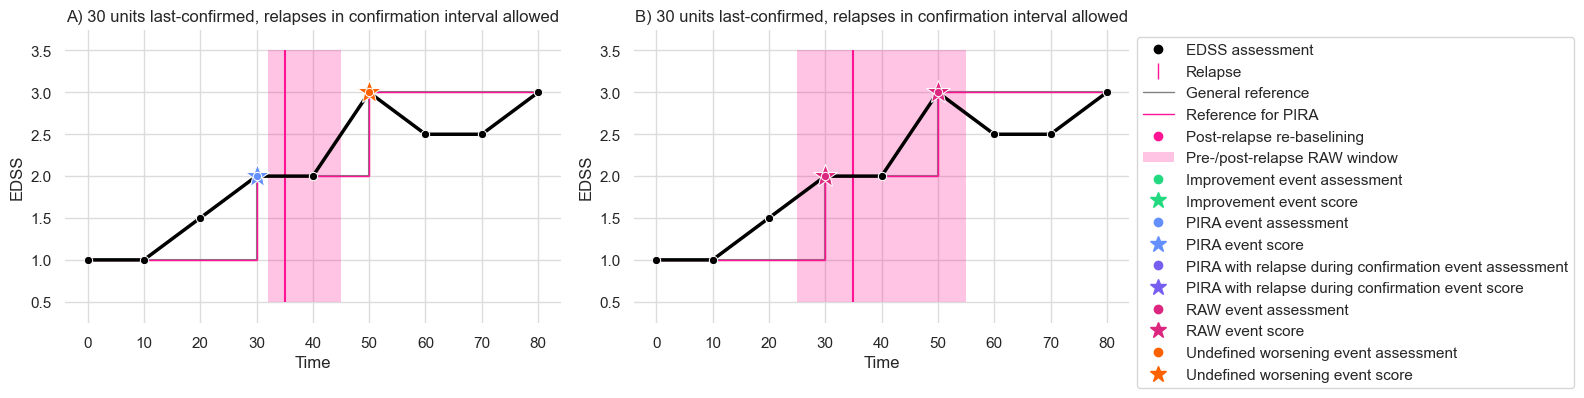

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 4))

test_dataframe = pd.DataFrame(
    {
        "days_after_baseline": [0, 10, 20, 30, 40, 50, 60, 70, 80],
        "edss_score": [1, 1, 1.5, 2.0, 2.0, 3.0, 2.5, 2.5, 3.0],
    }
)
test_options = [
    (
        3,
        10,
        True,
        30,
        "last",
        True,
        "A) 30 units last-confirmed, relapses in confirmation interval allowed",
        False,
    ),
    (
        10,
        20,
        True,
        30,
        "last",
        True,
        "B) 30 units last-confirmed, relapses in confirmation interval allowed",
        True,
    ),
]

for i, test_option in enumerate(test_options):
    visualization.annotate_plot_follow_up(
        relapse_timestamps=[35],
        follow_up_dataframe=test_dataframe,
        annotation_mode=SYMMETRIC_MODE_NAME,
        opt_raw_before_relapse_max_time=test_option[0],
        opt_raw_after_relapse_max_time=test_option[1],
        opt_require_confirmation=test_option[2],
        opt_confirmation_time=test_option[3],
        opt_confirmation_included_values=test_option[4],
        opt_pira_allow_relapses_between_event_and_confirmation=test_option[5],
        opt_baseline_type="fixed",
        show_baselines=True,
        show_raw_window=True,
        show_rebaselining=False,
        show_legend=test_option[7],
        ax=axes[i],
    )
    axes[i].set_title(test_option[6])

fig.tight_layout()
sns.despine(bottom=True, left=True, right=True, top=True)
plt.show()

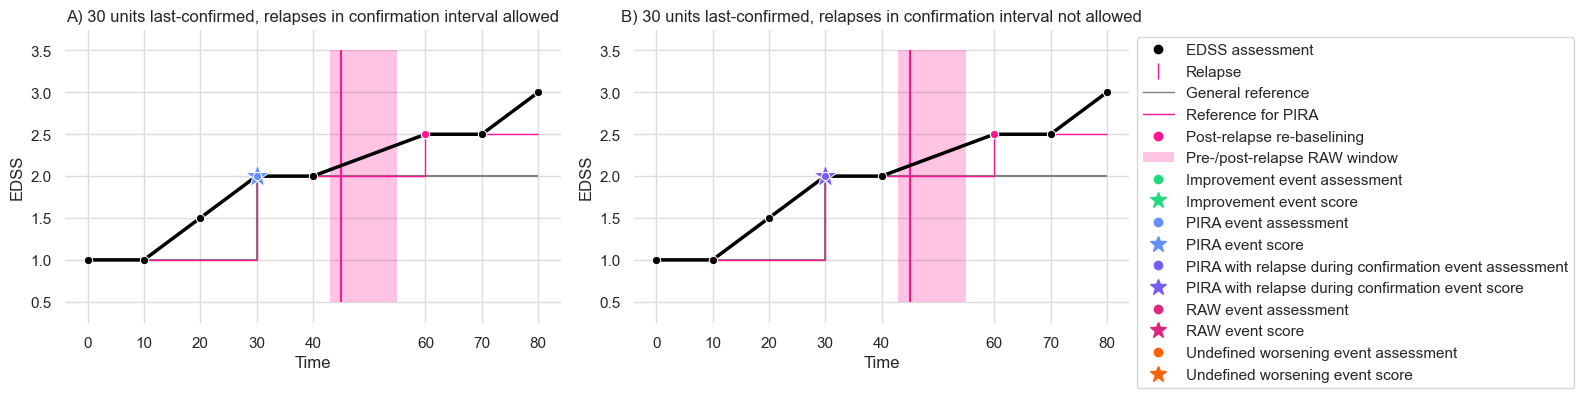

In [90]:
fig, axes = plt.subplots(1, 2, figsize=(16, 4))

test_dataframe = pd.DataFrame(
    {
        "days_after_baseline": [0, 10, 20, 30, 40, 60, 70, 80],
        "edss_score": [1, 1, 1.5, 2.0, 2.0, 2.5, 2.5, 3.0],
    }
)
test_options = [
    (
        2,
        10,
        True,
        30,
        "last",
        True,
        "A) 30 units last-confirmed, relapses in confirmation interval allowed",
    ),
    (
        2,
        10,
        True,
        30,
        "last",
        False,
        "B) 30 units last-confirmed, relapses in confirmation interval not allowed",
    ),
]

for i, test_option in enumerate(test_options):
    visualization.annotate_plot_follow_up(
        relapse_timestamps=[45],
        follow_up_dataframe=test_dataframe,
        annotation_mode=SYMMETRIC_MODE_NAME,
        opt_baseline_type="fixed",
        opt_raw_before_relapse_max_time=test_option[0],
        opt_raw_after_relapse_max_time=test_option[1],
        opt_require_confirmation=test_option[2],
        opt_confirmation_time=test_option[3],
        opt_confirmation_included_values=test_option[4],
        opt_pira_allow_relapses_between_event_and_confirmation=test_option[5],
        show_baselines=True,
        show_raw_window=True,
        show_rebaselining=False,
        show_legend=not test_option[5],
        ax=axes[i],
    )
    axes[i].set_title(test_option[6])

fig.tight_layout()
sns.despine(bottom=True, left=True, right=True, top=True)
plt.show()

# Event merging with different event types

## Different event types are never merged

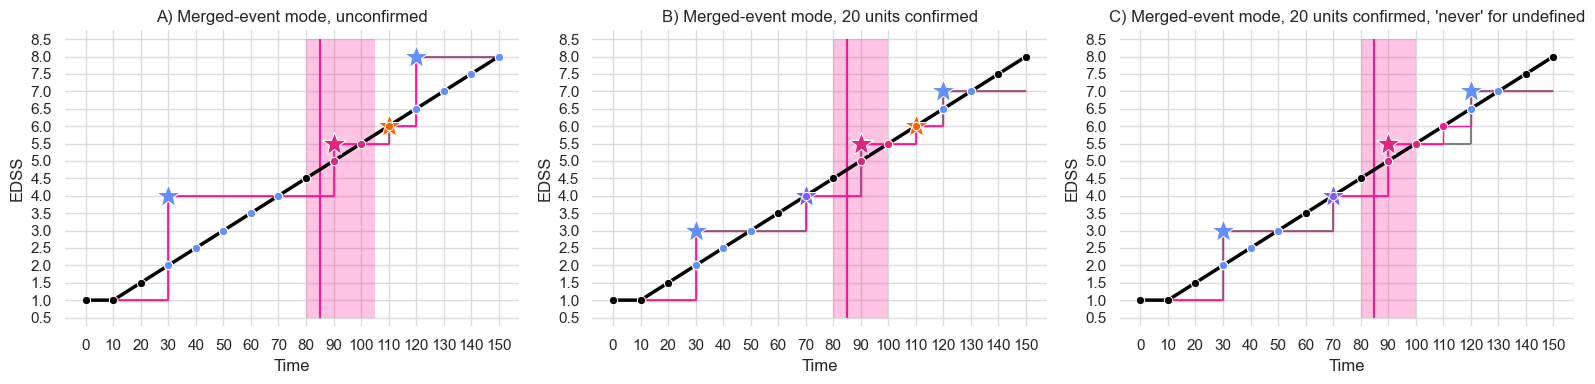

In [16]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
visualization.annotate_plot_follow_up(
    follow_up_dataframe=pd.DataFrame(
        {
            "days_after_baseline": [
                0,
                10,
                20,
                30,
                40,
                50,
                60,
                70,
                80,
                90,
                100,
                110,
                120,
                130,
                140,
                150,
            ],
            "edss_score": [
                1,
                1,
                1.5,
                2.0,
                2.5,
                3.0,
                3.5,
                4.0,
                4.5,
                5.0,
                5.5,
                6.0,
                6.5,
                7.0,
                7.5,
                8.0,
            ],
        }
    ),
    relapse_timestamps=[85],
    annotation_mode=SYMMETRIC_MODE_NAME,
    opt_baseline_type="fixed",
    opt_raw_before_relapse_max_time=5,
    opt_raw_after_relapse_max_time=20,
    merge_continuous_events=True,
    continuous_events_max_repetition_time=5,
    opt_require_confirmation=False,
    opt_confirmation_time=0.5,
    show_legend=False,
    move_legend_out=False,
    ax=axes[0],
)
axes[0].set_title("A) Merged-event mode, unconfirmed")
visualization.annotate_plot_follow_up(
    follow_up_dataframe=pd.DataFrame(
        {
            "days_after_baseline": [
                0,
                10,
                20,
                30,
                40,
                50,
                60,
                70,
                80,
                90,
                100,
                110,
                120,
                130,
                140,
                150,
            ],
            "edss_score": [
                1,
                1,
                1.5,
                2.0,
                2.5,
                3.0,
                3.5,
                4.0,
                4.5,
                5.0,
                5.5,
                6.0,
                6.5,
                7.0,
                7.5,
                8.0,
            ],
        }
    ),
    relapse_timestamps=[85],
    annotation_mode=SYMMETRIC_MODE_NAME,
    opt_baseline_type="fixed",
    opt_raw_before_relapse_max_time=5,
    opt_raw_after_relapse_max_time=15,
    merge_continuous_events=True,
    continuous_events_max_repetition_time=5,
    opt_require_confirmation=True,
    opt_confirmation_time=20,
    show_legend=False,
    move_legend_out=True,
    ax=axes[1],
)
axes[1].set_title("B) Merged-event mode, 20 units confirmed")

visualization.annotate_plot_follow_up(
    follow_up_dataframe=pd.DataFrame(
        {
            "days_after_baseline": [
                0,
                10,
                20,
                30,
                40,
                50,
                60,
                70,
                80,
                90,
                100,
                110,
                120,
                130,
                140,
                150,
            ],
            "edss_score": [
                1,
                1,
                1.5,
                2.0,
                2.5,
                3.0,
                3.5,
                4.0,
                4.5,
                5.0,
                5.5,
                6.0,
                6.5,
                7.0,
                7.5,
                8.0,
            ],
        }
    ),
    relapse_timestamps=[85],
    annotation_mode=SYMMETRIC_MODE_NAME,
    undefined_events_annotation_mode="never",
    opt_baseline_type="fixed",
    opt_raw_before_relapse_max_time=5,
    opt_raw_after_relapse_max_time=15,
    merge_continuous_events=True,
    continuous_events_max_repetition_time=5,
    opt_require_confirmation=True,
    opt_confirmation_time=20,
    show_legend=False,
    move_legend_out=True,
    ax=axes[2],
)
axes[2].set_title("C) Merged-event mode, 20 units confirmed, 'never' for undefined")
fig.tight_layout()
sns.despine(bottom=True, left=True, right=True, top=True)
plt.show()

## Relapses stop the merging of PIRA events

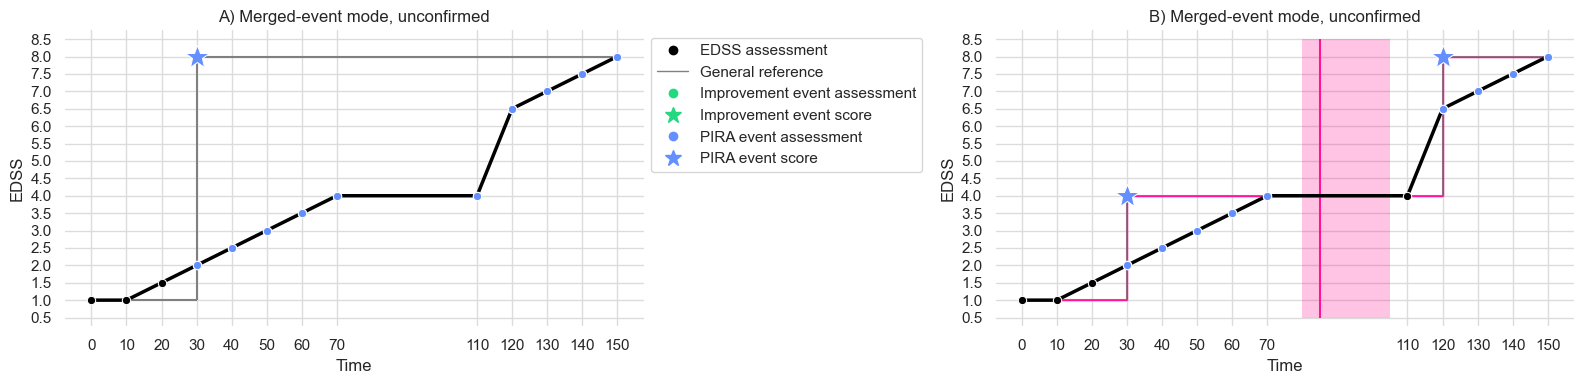

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(16, 4))

visualization.annotate_plot_follow_up(
    follow_up_dataframe=pd.DataFrame(
        {
            "days_after_baseline": [
                0,
                10,
                20,
                30,
                40,
                50,
                60,
                70,
                110,
                120,
                130,
                140,
                150,
            ],
            "edss_score": [
                1,
                1,
                1.5,
                2.0,
                2.5,
                3.0,
                3.5,
                4.0,
                4.0,
                6.5,
                7.0,
                7.5,
                8.0,
            ],
        }
    ),
    relapse_timestamps=[],
    annotation_mode=SYMMETRIC_MODE_NAME,
    opt_baseline_type="fixed",
    opt_raw_before_relapse_max_time=5,
    opt_raw_after_relapse_max_time=25,
    merge_continuous_events=True,
    continuous_events_max_repetition_time=80,
    opt_require_confirmation=False,
    show_legend=True,
    move_legend_out=True,
    ax=axes[0],
)
axes[0].set_title("A) Merged-event mode, unconfirmed")

visualization.annotate_plot_follow_up(
    follow_up_dataframe=pd.DataFrame(
        {
            "days_after_baseline": [
                0,
                10,
                20,
                30,
                40,
                50,
                60,
                70,
                110,
                120,
                130,
                140,
                150,
            ],
            "edss_score": [
                1,
                1,
                1.5,
                2.0,
                2.5,
                3.0,
                3.5,
                4.0,
                4.0,
                6.5,
                7.0,
                7.5,
                8.0,
            ],
        }
    ),
    relapse_timestamps=[85],
    annotation_mode=SYMMETRIC_MODE_NAME,
    opt_baseline_type="fixed",
    opt_raw_before_relapse_max_time=5,
    opt_raw_after_relapse_max_time=20,
    merge_continuous_events=True,
    continuous_events_max_repetition_time=80,
    opt_require_confirmation=False,
    opt_confirmation_time=0.5,
    show_legend=False,
    move_legend_out=False,
    ax=axes[1],
)
axes[1].set_title("B) Merged-event mode, unconfirmed")

fig.tight_layout()
sns.despine(bottom=True, left=True, right=True, top=True)
plt.show()

### Does not rely on undefined

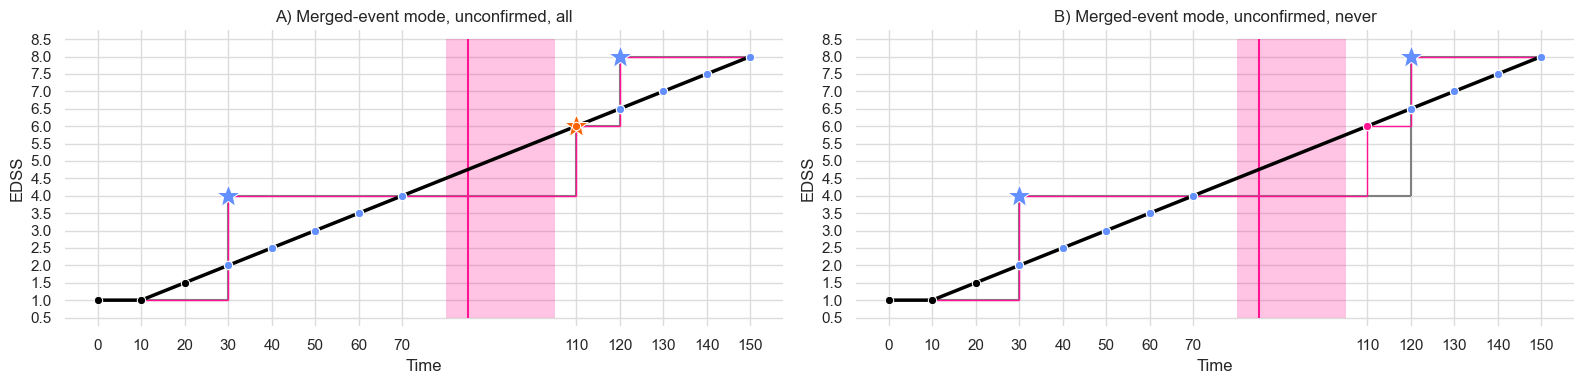

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(16, 4))
visualization.annotate_plot_follow_up(
    follow_up_dataframe=pd.DataFrame(
        {
            "days_after_baseline": [
                0,
                10,
                20,
                30,
                40,
                50,
                60,
                70,
                110,
                120,
                130,
                140,
                150,
            ],
            "edss_score": [
                1,
                1,
                1.5,
                2.0,
                2.5,
                3.0,
                3.5,
                4.0,
                6.0,
                6.5,
                7.0,
                7.5,
                8.0,
            ],
        }
    ),
    relapse_timestamps=[85],
    annotation_mode=SYMMETRIC_MODE_NAME,
    opt_baseline_type="fixed",
    opt_raw_before_relapse_max_time=5,
    opt_raw_after_relapse_max_time=20,
    merge_continuous_events=True,
    continuous_events_max_repetition_time=5,
    opt_require_confirmation=False,
    opt_confirmation_time=0.5,
    show_legend=False,
    move_legend_out=False,
    ax=axes[0],
)
axes[0].set_title("A) Merged-event mode, unconfirmed, all")

visualization.annotate_plot_follow_up(
    follow_up_dataframe=pd.DataFrame(
        {
            "days_after_baseline": [
                0,
                10,
                20,
                30,
                40,
                50,
                60,
                70,
                110,
                120,
                130,
                140,
                150,
            ],
            "edss_score": [
                1,
                1,
                1.5,
                2.0,
                2.5,
                3.0,
                3.5,
                4.0,
                6.0,
                6.5,
                7.0,
                7.5,
                8.0,
            ],
        }
    ),
    relapse_timestamps=[85],
    annotation_mode=SYMMETRIC_MODE_NAME,
    undefined_events_annotation_mode="never",
    opt_baseline_type="fixed",
    opt_raw_before_relapse_max_time=5,
    opt_raw_after_relapse_max_time=20,
    merge_continuous_events=True,
    continuous_events_max_repetition_time=5,
    opt_require_confirmation=False,
    opt_confirmation_time=0.5,
    show_legend=False,
    move_legend_out=False,
    ax=axes[1],
)
axes[1].set_title("B) Merged-event mode, unconfirmed, never")

fig.tight_layout()
sns.despine(bottom=True, left=True, right=True, top=True)
plt.show()

## Relapse-free periods stop the merging of RAW

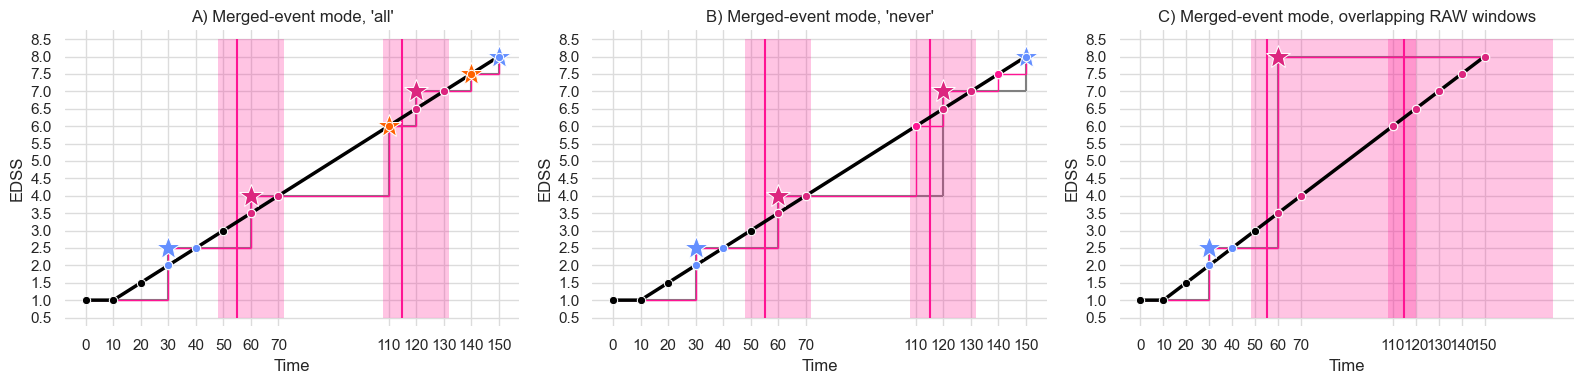

In [19]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

visualization.annotate_plot_follow_up(
    follow_up_dataframe=pd.DataFrame(
        {
            "days_after_baseline": [
                0,
                10,
                20,
                30,
                40,
                50,
                60,
                70,
                110,
                120,
                130,
                140,
                150,
            ],
            "edss_score": [
                1,
                1,
                1.5,
                2.0,
                2.5,
                3.0,
                3.5,
                4.0,
                6.0,
                6.5,
                7.0,
                7.5,
                8.0,
            ],
        }
    ),
    relapse_timestamps=[55, 115],
    annotation_mode=SYMMETRIC_MODE_NAME,
    opt_baseline_type="fixed",
    opt_raw_before_relapse_max_time=7,
    opt_raw_after_relapse_max_time=17,
    merge_continuous_events=True,
    continuous_events_max_merge_distance=np.inf,
    continuous_events_max_repetition_time=np.inf,
    opt_require_confirmation=False,
    show_legend=False,
    move_legend_out=True,
    ax=axes[0],
)
axes[0].set_title("A) Merged-event mode, 'all'")

visualization.annotate_plot_follow_up(
    follow_up_dataframe=pd.DataFrame(
        {
            "days_after_baseline": [
                0,
                10,
                20,
                30,
                40,
                50,
                60,
                70,
                110,
                120,
                130,
                140,
                150,
            ],
            "edss_score": [
                1,
                1,
                1.5,
                2.0,
                2.5,
                3.0,
                3.5,
                4.0,
                6.0,
                6.5,
                7.0,
                7.5,
                8.0,
            ],
        }
    ),
    relapse_timestamps=[55, 115],
    annotation_mode=SYMMETRIC_MODE_NAME,
    undefined_events_annotation_mode="never",
    opt_baseline_type="fixed",
    opt_raw_before_relapse_max_time=7,
    opt_raw_after_relapse_max_time=17,
    merge_continuous_events=True,
    continuous_events_max_merge_distance=np.inf,
    continuous_events_max_repetition_time=np.inf,
    opt_require_confirmation=False,
    show_legend=False,
    move_legend_out=True,
    ax=axes[1],
)
axes[1].set_title("B) Merged-event mode, 'never'")

visualization.annotate_plot_follow_up(
    follow_up_dataframe=pd.DataFrame(
        {
            "days_after_baseline": [
                0,
                10,
                20,
                30,
                40,
                50,
                60,
                70,
                110,
                120,
                130,
                140,
                150,
            ],
            "edss_score": [
                1,
                1,
                1.5,
                2.0,
                2.5,
                3.0,
                3.5,
                4.0,
                6.0,
                6.5,
                7.0,
                7.5,
                8.0,
            ],
        }
    ),
    relapse_timestamps=[55, 115],
    annotation_mode=SYMMETRIC_MODE_NAME,
    undefined_events_annotation_mode="all",
    opt_baseline_type="fixed",
    opt_raw_before_relapse_max_time=7,
    opt_raw_after_relapse_max_time=65,
    merge_continuous_events=True,
    continuous_events_max_merge_distance=np.inf,
    continuous_events_max_repetition_time=np.inf,
    opt_require_confirmation=False,
    show_legend=False,
    move_legend_out=True,
    ax=axes[2],
)
axes[2].set_title("C) Merged-event mode, overlapping RAW windows")
fig.tight_layout()
sns.despine(bottom=True, left=True, right=True, top=True)
plt.show()

### Does not rely on post-relapse re-baselining

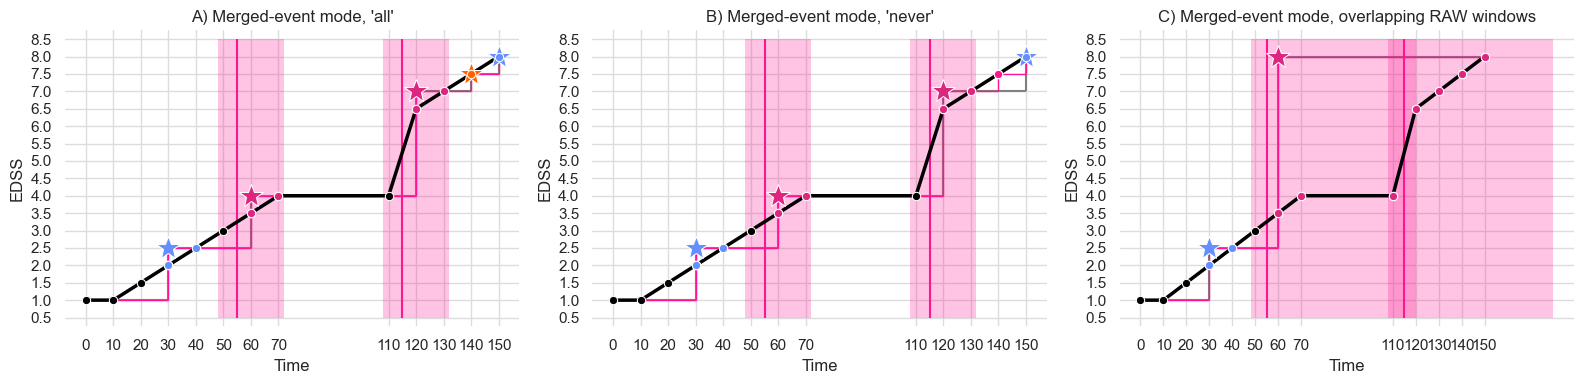

In [20]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

visualization.annotate_plot_follow_up(
    follow_up_dataframe=pd.DataFrame(
        {
            "days_after_baseline": [
                0,
                10,
                20,
                30,
                40,
                50,
                60,
                70,
                110,
                120,
                130,
                140,
                150,
            ],
            "edss_score": [
                1,
                1,
                1.5,
                2.0,
                2.5,
                3.0,
                3.5,
                4.0,
                4.0,
                6.5,
                7.0,
                7.5,
                8.0,
            ],
        }
    ),
    relapse_timestamps=[55, 115],
    annotation_mode=SYMMETRIC_MODE_NAME,
    opt_baseline_type="fixed",
    opt_raw_before_relapse_max_time=7,
    opt_raw_after_relapse_max_time=17,
    merge_continuous_events=True,
    continuous_events_max_merge_distance=np.inf,
    continuous_events_max_repetition_time=np.inf,
    opt_require_confirmation=False,
    show_legend=False,
    move_legend_out=True,
    ax=axes[0],
)
axes[0].set_title("A) Merged-event mode, 'all'")

visualization.annotate_plot_follow_up(
    follow_up_dataframe=pd.DataFrame(
        {
            "days_after_baseline": [
                0,
                10,
                20,
                30,
                40,
                50,
                60,
                70,
                110,
                120,
                130,
                140,
                150,
            ],
            "edss_score": [
                1,
                1,
                1.5,
                2.0,
                2.5,
                3.0,
                3.5,
                4.0,
                4.0,
                6.5,
                7.0,
                7.5,
                8.0,
            ],
        }
    ),
    relapse_timestamps=[55, 115],
    annotation_mode=SYMMETRIC_MODE_NAME,
    undefined_events_annotation_mode="never",
    opt_baseline_type="fixed",
    opt_raw_before_relapse_max_time=7,
    opt_raw_after_relapse_max_time=17,
    merge_continuous_events=True,
    continuous_events_max_merge_distance=np.inf,
    continuous_events_max_repetition_time=np.inf,
    opt_require_confirmation=False,
    show_legend=False,
    move_legend_out=True,
    ax=axes[1],
)
axes[1].set_title("B) Merged-event mode, 'never'")

visualization.annotate_plot_follow_up(
    follow_up_dataframe=pd.DataFrame(
        {
            "days_after_baseline": [
                0,
                10,
                20,
                30,
                40,
                50,
                60,
                70,
                110,
                120,
                130,
                140,
                150,
            ],
            "edss_score": [
                1,
                1,
                1.5,
                2.0,
                2.5,
                3.0,
                3.5,
                4.0,
                4.0,
                6.5,
                7.0,
                7.5,
                8.0,
            ],
        }
    ),
    relapse_timestamps=[55, 115],
    annotation_mode=SYMMETRIC_MODE_NAME,
    undefined_events_annotation_mode="all",
    opt_baseline_type="fixed",
    opt_raw_before_relapse_max_time=7,
    opt_raw_after_relapse_max_time=65,
    merge_continuous_events=True,
    continuous_events_max_merge_distance=np.inf,
    continuous_events_max_repetition_time=np.inf,
    opt_require_confirmation=False,
    show_legend=False,
    move_legend_out=True,
    ax=axes[2],
)
axes[2].set_title("C) Merged-event mode, overlapping RAW windows")
fig.tight_layout()
sns.despine(bottom=True, left=True, right=True, top=True)
plt.show()

### Relapses don't affect merging of undefined events

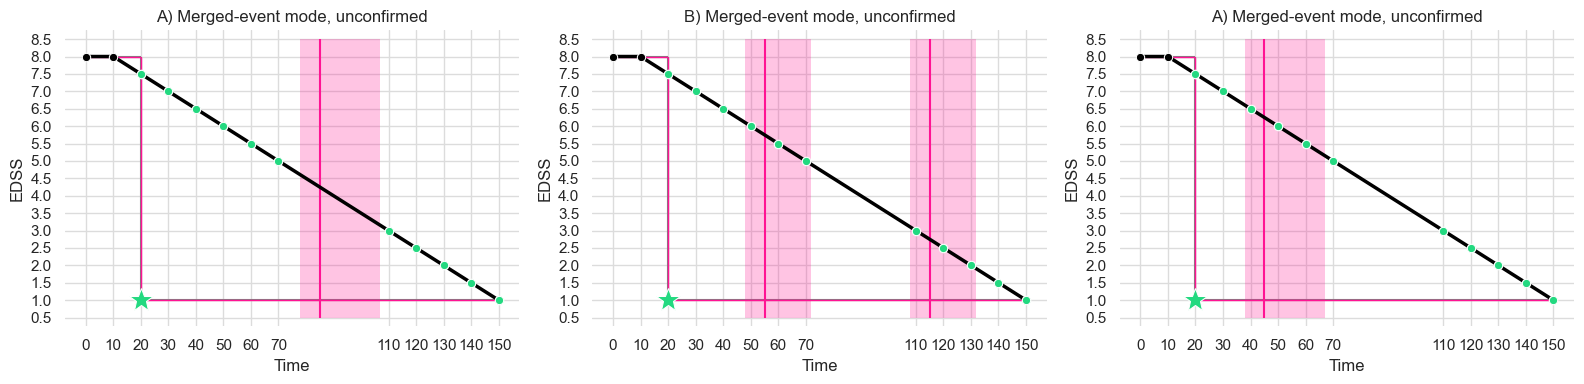

In [21]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
example_df = pd.DataFrame(
    {
        "days_after_baseline": [
            0,
            10,
            20,
            30,
            40,
            50,
            60,
            70,
            110,
            120,
            130,
            140,
            150,
        ],
        "edss_score": [
            1,
            1,
            1.5,
            2.0,
            2.5,
            3.0,
            3.5,
            4.0,
            6.0,
            6.5,
            7.0,
            7.5,
            8.0,
        ],
    }
)
example_df["edss_score"] = 9 - example_df["edss_score"]
visualization.annotate_plot_follow_up(
    follow_up_dataframe=example_df,
    relapse_timestamps=[85],
    annotation_mode=SYMMETRIC_MODE_NAME,
    undefined_events_annotation_mode="never",
    opt_baseline_type="fixed",
    opt_raw_before_relapse_max_time=7,
    opt_raw_after_relapse_max_time=22,
    merge_continuous_events=True,
    continuous_events_max_repetition_time=5,
    continuous_events_max_merge_distance=100,
    opt_require_confirmation=False,
    opt_confirmation_time=0.5,
    show_legend=False,
    move_legend_out=False,
    ax=axes[0],
)
axes[0].set_title("A) Merged-event mode, unconfirmed")
visualization.annotate_plot_follow_up(
    follow_up_dataframe=example_df,
    relapse_timestamps=[55, 115],
    annotation_mode=SYMMETRIC_MODE_NAME,
    undefined_events_annotation_mode="never",
    opt_baseline_type="fixed",
    opt_raw_before_relapse_max_time=7,
    opt_raw_after_relapse_max_time=17,
    merge_continuous_events=True,
    continuous_events_max_repetition_time=5,
    continuous_events_max_merge_distance=100,
    opt_require_confirmation=False,
    show_legend=False,
    move_legend_out=True,
    ax=axes[1],
)
axes[1].set_title("B) Merged-event mode, unconfirmed")


visualization.annotate_plot_follow_up(
    follow_up_dataframe=example_df,
    relapse_timestamps=[45],
    annotation_mode=SYMMETRIC_MODE_NAME,
    undefined_events_annotation_mode="never",
    opt_baseline_type="fixed",
    opt_raw_before_relapse_max_time=7,
    opt_raw_after_relapse_max_time=22,
    merge_continuous_events=True,
    continuous_events_max_repetition_time=5,
    continuous_events_max_merge_distance=100,
    opt_require_confirmation=False,
    opt_confirmation_time=0.5,
    show_legend=False,
    move_legend_out=False,
    ax=axes[2],
)
axes[2].set_title("A) Merged-event mode, unconfirmed")
fig.tight_layout()
sns.despine(bottom=True, left=True, right=True, top=True)
plt.show()

## Undefined events are not merged

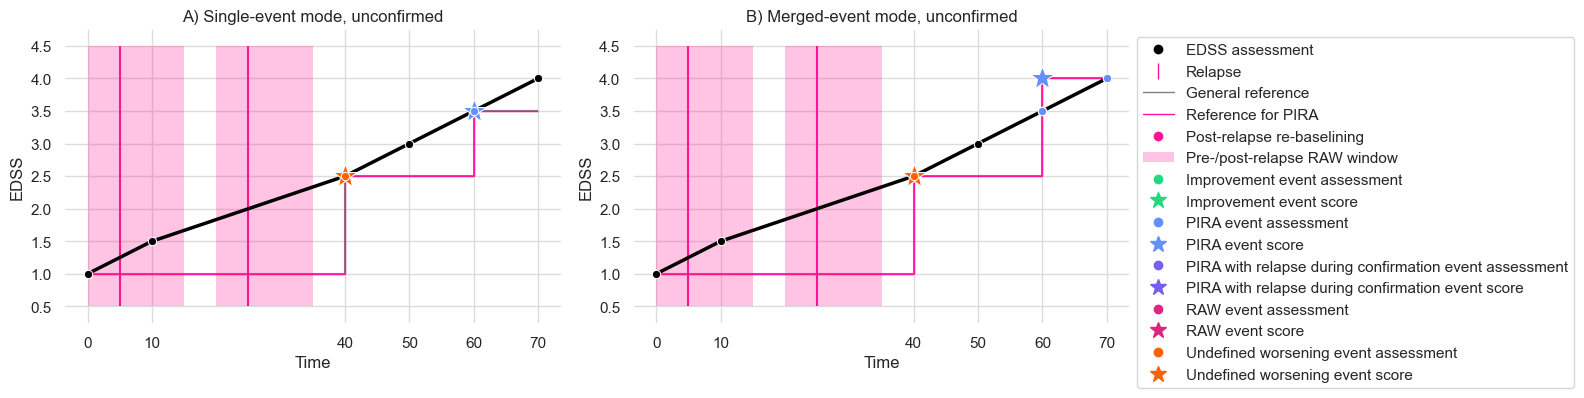

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(16, 4))

test_dataframe = pd.DataFrame(
    {
        "days_after_baseline": [0, 10, 40, 50, 60, 70],
        "edss_score": [1, 1.5, 2.5, 3, 3.5, 4.0],
    }
)

for i, elt in enumerate(
    [
        (False, [5, 25], "A) Single-event mode, unconfirmed"),
        (True, [5, 25], "B) Merged-event mode, unconfirmed"),
    ]
):
    visualization.annotate_plot_follow_up(
        relapse_timestamps=elt[1],
        # Input data general description
        follow_up_dataframe=test_dataframe,
        annotation_mode=SYMMETRIC_MODE_NAME,
        opt_baseline_type="fixed",
        merge_continuous_events=elt[0],
        continuous_events_max_repetition_time=10,
        # PRA/RAW
        opt_raw_before_relapse_max_time=5,
        opt_raw_after_relapse_max_time=10,
        show_baselines=True,
        show_raw_window=True,
        show_rebaselining=False,
        show_legend=elt[0],
        move_legend_out=True,
        legend_loc="best",
        ax=axes[i],
    )
    axes[i].set_title(elt[2])

fig.tight_layout()
sns.despine(bottom=True, left=True, right=True, top=True)
plt.show()